# CLSA retinal and epigenetic aging

## Quick use

Run this notebook after Algorithm Fairness notebook 01 has completed.
It reuses the complete quality-passing participant-visit RETFound vector
rollup, reads the six released baseline methylation phenotypes directly
from CoPv7_Qx_CANUE_PA_BS.csv, and writes a separate resumable analysis
under 08_epigenetics.

The notebook performs nine related analyses:

1. Fit a participant-grouped, out-of-fold RETFound head for chronological
   age across the full eligible CLSA cohort and report standard regression
   metrics, calibration, Bland-Altman plots, and age-stratified accuracy.
2. Fit separate participant-grouped heads for the two absolute epigenetic
   ages (Horvath DNAmAge and Hannum age) among baseline participants with
   each measurement. These are secondary prediction analyses.
3. Compare chronological age, out-of-fold retinal age from the
   chronological-age head, and each absolute epigenetic age, including
   three-dimensional plots and participant-paired distance tests.
4. Quantify whether released racial/cultural background, spirometry
   ethnicity, or sex explains variation in the age gaps using adjusted
   nested regression and incremental R-squared.
5. Scan every analyzable baseline questionnaire response after the
   prespecified comorbidity models, with global FDR correction, explicit
   procedural-variable exclusions, categorical level-count audits, and
   a separate manuscript-eligibility threshold.
6. Retest acuity and grip-strength signals after combining duplicate
   cataract modules into one covariate and after rebuilding the retinal
   age model from a stricter image-quality subset.
7. Benchmark retinal prediction of Horvath and Hannum age against
   chronological age alone and test residual prediction beyond age.
8. Repeat representative epigenetic associations across the released
   residual, difference, IEAA, EEAA, Horvath, and Hannum definitions.
9. Quantify longitudinal retinal-age change, participant-specific
   repeatability, same-eye stability, and technical-quality drift.

Important guardrails:

- Epigenetic measurements are baseline phenotypes, so three-way analyses
  use baseline fundus vectors only.
- DNAmAge_COM and Hannum_Age_COM are ages in years. The released
  acceleration difference, residual, IEAA, and EEAA variables remain on
  their released acceleration scales and are never treated as ages.
- The primary retinal-versus-epigenetic comparison uses retinal age
  predicted by a chronological-age model that never used epigenetic
  outcomes. Agreement from an epigenetic-trained retinal head is reported
  separately because using it to prove shared biology would be circular.
- All model assessment is out of fold, all splitting is by participant,
  and all inferential rows are participant-level.
- Positive retinal-age gap means older-appearing retina; negative means
  younger-appearing retina. A gap is a relative biomarker, not a diagnosis.

In [0]:
%pip install statsmodels
from pathlib import Path
import gc
import hashlib
import importlib
import json
import math
import os
import re
import shutil
import sys
import uuid
import zipfile
from textwrap import fill

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.18,
    rc={
        "axes.titleweight": "semibold",
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "figure.titlesize": 16,
        "legend.fontsize": 10.5,
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "figure.constrained_layout.h_pad": 0.10,
        "figure.constrained_layout.w_pad": 0.10,
        "figure.constrained_layout.hspace": 0.08,
        "figure.constrained_layout.wspace": 0.08,
        "savefig.dpi": 300,
    },
)
pd.set_option("display.max_columns", 100)

CLSA_VARIABLE_LABEL_SOURCE = (
    "https://www.unb.ca/datanb/data/holdings/_resources/pdf/"
    "clsa01_variablelist1.pdf"
)
CLSA_VARIABLE_LABELS = {
    "ICQ_CATRCT_COM": "Ever had cataracts",
    "VIS_CATRCT_COM": "Cataracts noted during vision testing",
    "BAL_BEST_COM": "Best attained time - Standing Balance",
    "VA_ETDRS_BOTH_NB_COM": (
        "Last row all 5 letters identified correctly - Both eyes (20/)"
    ),
    "VA_ETDRS_R_NB_COM": (
        "Last row all 5 letters identified correctly - Right eye (20/)"
    ),
    "VA_ETDRS_L_NB_COM": (
        "Last row all 5 letters identified correctly - Left eye (20/)"
    ),
    "VA_ETDRS_R_PO_NB_COM": (
        "Last row all 5 letters identified correctly - Right eye with pinhole (20/)"
    ),
    "VA_ETDRS_L_PO_NB_COM": (
        "Last row all 5 letters identified correctly - Left eye with pinhole (20/)"
    ),
    "GS_TRIAL1_MAX_COM": "Grip strength measurement attained at 1st trial",
    "GS_TRIAL2_MAX_COM": "Grip strength measurement attained at 2nd trial",
    "GS_TRIAL3_MAX_COM": "Grip strength measurement attained at 3rd trial",
    "GS_EXAM_MAX_COM": "Max grip strength attained on all trials",
    "GS_EXAM_AVG_COM": "Average grip strength for all trials",
    "VIS_SGHT_COM": "Eyesight rating",
    "TON_CRF_L_COM": "Corneal resistance factor - left eye",
    "BLD_RBC_COM": "Red blood cells",
    "BLD_Hct_COM": "Hematocrit",
    "BLD_Hgb_COM": "Hemoglobin",
    "CR2_FAM_ML_COM": (
        "Received nonprofessional help with meal preparation"
    ),
    "INT_FRQWBSTS_MCQ": "Website-access frequency",
    "CR2_DEVC_WK_COM": "Used a walker",
    "CR2_FAM_AC_COM": "Received nonprofessional help with activities",
    "SDC_FTLG_DE_COM": "Language first learned at home - German",
    "CR2_FAM_NONE_COM": "Did not require nonprofessional assistance",
    "CR2_FRHC_COM": (
        "Received informal home care during preceding 12 months"
    ),
    "CR2_DRMC_COM": "Relationship of main caregiver",
    "GEN_OWNAG_COM": "Self-rated healthy aging",
    "PER_SYMPAGR_MCQ": (
        "Agreement with seeing oneself as sympathetic and warm"
    ),
    "CR2_DTHC_COM": (
        "Received formal or informal home care during preceding 12 months"
    ),
    "NUT_CHSE_NB_COM": "Regular-cheese consumption frequency",
}
PUBLICATION_SHORT_LABELS = {
    "ICQ_CATRCT_COM": "Ever had cataracts",
    "VIS_CATRCT_COM": "Cataracts noted on vision testing",
    "BAL_BEST_COM": "Best standing-balance time",
    "VA_ETDRS_BOTH_NB_COM": "Bilateral ETDRS visual acuity",
    "VA_ETDRS_R_NB_COM": "Right-eye ETDRS visual acuity",
    "VA_ETDRS_L_NB_COM": "Left-eye ETDRS visual acuity",
    "VA_ETDRS_R_PO_NB_COM": "Right-eye pinhole ETDRS visual acuity",
    "VA_ETDRS_L_PO_NB_COM": "Left-eye pinhole ETDRS visual acuity",
    "GS_TRIAL1_MAX_COM": "Grip strength, trial 1",
    "GS_TRIAL2_MAX_COM": "Grip strength, trial 2",
    "GS_TRIAL3_MAX_COM": "Grip strength, trial 3",
    "GS_EXAM_MAX_COM": "Maximum grip strength",
    "GS_EXAM_AVG_COM": "Average grip strength",
    "VIS_SGHT_COM": "Self-rated eyesight",
    "TON_CRF_L_COM": "Left corneal resistance factor",
    "BLD_RBC_COM": "Red blood cell count",
    "BLD_Hct_COM": "Hematocrit",
    "BLD_Hgb_COM": "Hemoglobin",
    "CR2_FAM_ML_COM": "Help with meal preparation",
    "INT_FRQWBSTS_MCQ": "Website-access frequency",
    "CR2_DEVC_WK_COM": "Walker use",
    "CR2_FAM_AC_COM": "Help with activities",
    "SDC_FTLG_DE_COM": "German first learned at home",
    "CR2_FAM_NONE_COM": "No nonprofessional assistance",
    "CR2_FRHC_COM": "Informal home care",
    "CR2_DRMC_COM": "Main-caregiver relationship",
    "GEN_OWNAG_COM": "Self-rated healthy aging",
    "PER_SYMPAGR_MCQ": "Sympathetic and warm self-view",
    "CR2_DTHC_COM": "Formal or informal home care",
    "NUT_CHSE_NB_COM": "Regular-cheese frequency",
}


def clsa_variable_label(variable):
    value = str(variable)
    return CLSA_VARIABLE_LABELS.get(value, value)


def publication_variable_label(variable, width=34):
    value = str(variable)
    label = PUBLICATION_SHORT_LABELS.get(
        value,
        CLSA_VARIABLE_LABELS.get(value, value),
    )
    return fill(label, width=width)


def prepare_publication_figure(figure, *, suptitle_y=0.985):
    # Apply consistent spacing and prevent title-panel collisions.
    if getattr(figure, "_suptitle", None) is not None:
        figure._suptitle.set_y(suptitle_y)
    if figure.get_constrained_layout():
        figure.set_constrained_layout_pads(
            w_pad=0.10,
            h_pad=0.12,
            wspace=0.08,
            hspace=0.10,
        )
    for axis in figure.axes:
        axis.tick_params(axis="both", labelsize=10.5, pad=4)
        axis.xaxis.labelpad = max(axis.xaxis.labelpad, 8)
        axis.yaxis.labelpad = max(axis.yaxis.labelpad, 8)
    return figure

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 141.5 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
repo_root = Path(
    "/Workspace/Users/ad0038@pennmedicine.upenn.edu/CLSA/CLSA_retina"
)
dataset_root = Path(
    "/Volumes/ophthalmology_analytics/dev_optic/clsa_dataset"
)
derived_root = dataset_root / "derived" / "clsa_retinal_aging"
retfound_root = derived_root / "fundus_retfound"
fairness_root = derived_root / "Age_Glaucoma" / "16_algorithm_fairness"

participant_embedding_path = (
    fairness_root / "01_private" / "participant_visit_embeddings.parquet"
)
race_path = fairness_root / "01_private" / "racial_background_private.parquet"
sap_questionnaire_path = derived_root / "sap_questionnaire_visit"
baseline_archive_path = (
    dataset_root / "2209017_UOttawa_EFreeman_BL.zip"
)
baseline_member_suffix = "CoPv7_Qx_CANUE_PA_BS.csv"
quality_path = (
    retfound_root / "01_quality" / "fundus_quality_manifest.parquet"
)
embedding_root = retfound_root / "02_embeddings"
fairness_embedding_root = (
    fairness_root / "00_full_image_pipeline" / "02_embedding_batches"
)

output_root = fairness_root / "08_epigenetics"
private_root = output_root / "01_private"
model_root = output_root / "02_models"
statistics_root = output_root / "03_statistics"
figure_root = output_root / "04_figures"
checkpoint_root = output_root / "05_checkpoints"
for directory in (
    private_root,
    model_root,
    statistics_root,
    figure_root,
    checkpoint_root,
):
    directory.mkdir(parents=True, exist_ok=True)

expected_embedding_dim = 1024
ridge_alpha = 10.0
cv_folds = 5
bootstrap_repetitions = 2000
permutation_repetitions = 10000
minimum_model_participants = 50
minimum_reporting_group_n = 10
minimum_age_bin_n = 30
baseline_chunk_size = 100_000
maximum_scatter_points = 5000
prediction_bootstrap_repetitions = 500
minimum_binary_outcome_events = 30
acceleration_extreme_quantile = 0.80
questionnaire_row_chunk_size = 500
minimum_questionnaire_observed = 100
minimum_questionnaire_level_n = 30
minimum_questionnaire_manuscript_n = 300
maximum_questionnaire_categorical_levels = 20
strict_quality_retained_fraction = 0.75
locked_validation_fraction = 0.30
full_questionnaire_column_batch_size = 50
publication_bootstrap_repetitions = 1000
manual_quality_review_n = 200
quality_threshold_retained_fractions = (0.50, 0.60, 0.70, 0.80, 0.90)
random_state = 20260903
resume_completed_outputs = True

module_root = repo_root / "src"
if not module_root.exists():
    raise FileNotFoundError(f"Repository source directory missing: {module_root}")
if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

import fundus_retfound_pipeline as _fundus
import retfound_fairness as _fairness
_fundus = importlib.reload(_fundus)
_fairness = importlib.reload(_fairness)
from fundus_retfound_pipeline import (
    AgeModelConfig,
    train_age_head,
    write_frame,
    write_json,
)
from retfound_fairness import benjamini_hochberg

print("Output root:", output_root)
print("Retinal vectors:", participant_embedding_path)

Output root: /Volumes/ophthalmology_analytics/dev_optic/clsa_dataset/derived/clsa_retinal_aging/Age_Glaucoma/16_algorithm_fairness/08_epigenetics
Retinal vectors: /Volumes/ophthalmology_analytics/dev_optic/clsa_dataset/derived/clsa_retinal_aging/Age_Glaucoma/16_algorithm_fairness/01_private/participant_visit_embeddings.parquet


## 1. Reusable statistical and checkpoint helpers

Confidence intervals and permutation tests resample participants. The
training checkpoint signature includes participant, visit, outcome, image
count, and the consolidated embedding source metadata.

In [0]:
def normalize_identifier(series):
    return series.astype("string").str.strip()


def normalize_visit(series):
    return (
        series.astype("string")
        .str.strip()
        .str.upper()
        .replace({"FUP1": "F1"})
    )


def normalized_code(series):
    return (
        series.astype("string")
        .str.strip()
        .str.upper()
        .str.replace(r"\.0$", "", regex=True)
    )


def harmonize_sex(series):
    return normalized_code(series).map(
        {"F": "Female", "2": "Female", "M": "Male", "1": "Male"}
    )


def label_spirometry_ethnicity(series):
    labels = {
        "1": "Caucasian",
        "2": "Asian",
        "3": "African",
        "4": "Hispanic",
        "5": "Other ethnicity",
    }
    codes = normalized_code(series)
    missing_codes = {
        "",
        "-77771",
        "-77772",
        "-88880",
        "-88888",
        "-99991",
        "-99993",
        "-99999",
    }
    released_text = (
        series.astype("string").str.strip().replace("", pd.NA)
    )
    released_text = released_text.mask(codes.isin(missing_codes))
    return codes.map(labels).fillna(released_text)


def stable_value(series):
    values = series.dropna()
    if values.empty:
        return None
    modes = values.mode(dropna=True)
    return modes.iloc[0] if not modes.empty else values.iloc[0]


def source_signature(path):
    path = Path(path)
    stat = path.stat()
    return f"{path}|{stat.st_size}|{stat.st_mtime_ns}"


def frame_signature(frame, target_column, source_token):
    rows = (
        frame[["participant_id", "visit", target_column, "n_embedded_images"]]
        .astype(str)
        .agg("|".join, axis=1)
        .sort_values()
    )
    digest = hashlib.sha256()
    digest.update(source_token.encode("utf-8"))
    for value in rows:
        digest.update(value.encode("utf-8"))
        digest.update(b"\n")
    return digest.hexdigest()


def publish_file(local_path, destination_path):
    local_path = Path(local_path)
    destination_path = Path(destination_path)
    destination_path.parent.mkdir(parents=True, exist_ok=True)
    partial = destination_path.with_name(
        f".{destination_path.name}.{uuid.uuid4().hex}.partial"
    )
    try:
        shutil.copy2(local_path, partial)
        if partial.stat().st_size != local_path.stat().st_size:
            raise OSError("Published file size mismatch")
        os.replace(partial, destination_path)
    finally:
        partial.unlink(missing_ok=True)
    return destination_path


def assign_group_folds(frame, max_splits):
    groups = frame["participant_id"].astype(str).to_numpy()
    n_splits = min(max_splits, len(np.unique(groups)))
    fold = np.zeros(len(frame), dtype=int)
    splitter = GroupKFold(n_splits=n_splits)
    dummy = np.zeros((len(frame), 1), dtype=float)
    target = frame["age"].to_numpy(float)
    for fold_number, (_, test_index) in enumerate(
        splitter.split(dummy, target, groups), 1
    ):
        fold[test_index] = fold_number
    if not np.all(fold > 0):
        raise RuntimeError("Some training rows were not assigned an OOF fold")
    return fold


def fit_or_resume_head(frame, target_column, model_name):
    work = frame[
        [
            "participant_id",
            "visit",
            target_column,
            "embedding",
            "n_embedded_images",
        ]
    ].copy()
    work.attrs = {}
    work[target_column] = pd.to_numeric(work[target_column], errors="coerce")
    work = work.dropna(
        subset=["participant_id", "visit", target_column, "embedding"]
    ).reset_index(drop=True)
    if work["participant_id"].nunique() < minimum_model_participants:
        raise ValueError(
            f"{model_name} has only {work['participant_id'].nunique()} "
            f"participants; at least {minimum_model_participants} required"
        )
    work = work.rename(columns={target_column: "age"})
    signature = frame_signature(
        work,
        "age",
        (
            source_signature(participant_embedding_path)
            + f"|{model_name}|alpha={ridge_alpha}|folds={cv_folds}"
            + f"|seed={random_state}|calibration=intercept"
        ),
    )
    destination = model_root / model_name
    destination.mkdir(parents=True, exist_ok=True)
    model_path = destination / f"{model_name}.joblib"
    oof_path = destination / f"{model_name}_oof.parquet"
    metadata_path = destination / f"{model_name}_metadata.json"
    can_resume = False
    if (
        resume_completed_outputs
        and model_path.is_file()
        and oof_path.is_file()
        and metadata_path.is_file()
    ):
        metadata = json.loads(metadata_path.read_text())
        can_resume = metadata.get("training_signature") == signature
    if can_resume:
        oof = pd.read_parquet(oof_path)
        bundle = joblib.load(model_path)
        print(f"Resumed {model_name}: {len(oof):,} OOF rows")
        return oof, bundle

    local_root = (
        Path("/local_disk0/tmp")
        / f"epigenetics-{model_name}-{uuid.uuid4().hex}"
    )
    local_root.mkdir(parents=True, exist_ok=True)
    oof, bundle = train_age_head(
        work,
        local_root,
        AgeModelConfig(
            alpha=ridge_alpha,
            max_splits=cv_folds,
            calibration="intercept",
            random_state=random_state,
        ),
        write_metadata=False,
    )
    oof.attrs = {}
    oof["cv_fold"] = assign_group_folds(work, cv_folds)
    oof["target_name"] = target_column
    bundle.update(
        {
            "model_name": model_name,
            "target_name": target_column,
            "training_signature": signature,
        }
    )
    local_model = local_root / f"{model_name}.joblib"
    local_oof = local_root / f"{model_name}_oof.parquet"
    joblib.dump(bundle, local_model)
    write_frame(oof, local_oof)
    publish_file(local_model, model_path)
    publish_file(local_oof, oof_path)
    write_json(
        {
            "training_signature": signature,
            "target_name": target_column,
            "n_participants": int(work["participant_id"].nunique()),
            "n_participant_visits": int(len(work)),
            "n_images_represented": int(work["n_embedded_images"].sum()),
            "ridge_alpha": ridge_alpha,
            "cv_folds": int(oof["cv_splits"].iloc[0]),
            "grouped_by_participant": True,
            "model_path": str(model_path),
            "oof_path": str(oof_path),
        },
        metadata_path,
    )
    shutil.rmtree(local_root, ignore_errors=True)
    print(f"Fitted {model_name}: {len(oof):,} OOF rows")
    return oof, bundle


def concordance_correlation(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    covariance = np.cov(x, y, ddof=1)[0, 1]
    denominator = (
        np.var(x, ddof=1)
        + np.var(y, ddof=1)
        + (np.mean(x) - np.mean(y)) ** 2
    )
    return float(2 * covariance / denominator) if denominator > 0 else np.nan


def regression_metrics(frame, target_column, prediction_column, label):
    work = frame[[target_column, prediction_column]].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()
    target = work[target_column].to_numpy(float)
    prediction = work[prediction_column].to_numpy(float)
    error = prediction - target
    if len(work) < 3:
        raise ValueError(f"Insufficient observations for {label}")
    slope, intercept = np.polyfit(target, prediction, 1)
    pearson = stats.pearsonr(target, prediction)
    spearman = stats.spearmanr(target, prediction)
    return {
        "analysis": label,
        "n": int(len(work)),
        "target_mean": float(np.mean(target)),
        "target_sd": float(np.std(target, ddof=1)),
        "prediction_mean": float(np.mean(prediction)),
        "prediction_sd": float(np.std(prediction, ddof=1)),
        "mae": float(mean_absolute_error(target, prediction)),
        "median_absolute_error": float(np.median(np.abs(error))),
        "rmse": float(np.sqrt(mean_squared_error(target, prediction))),
        "r2": float(r2_score(target, prediction)),
        "pearson_r": float(pearson.statistic),
        "pearson_p": float(pearson.pvalue),
        "spearman_rho": float(spearman.statistic),
        "spearman_p": float(spearman.pvalue),
        "calibration_slope": float(slope),
        "calibration_intercept": float(intercept),
        "mean_error": float(np.mean(error)),
        "sd_error": float(np.std(error, ddof=1)),
        "ccc": concordance_correlation(target, prediction),
    }


def bootstrap_mean_ci(values, repetitions, seed):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    estimates = np.empty(repetitions, dtype=float)
    for index in range(repetitions):
        estimates[index] = np.mean(
            values[rng.integers(0, len(values), len(values))]
        )
    return tuple(np.quantile(estimates, [0.025, 0.975]))


def signflip_less_test(differences, repetitions, seed):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    if len(differences) < 2:
        return np.nan
    observed = float(np.mean(differences))
    rng = np.random.default_rng(seed)
    exceed = 1
    for _ in range(repetitions):
        signs = rng.choice([-1.0, 1.0], size=len(differences))
        exceed += float(np.mean(differences * signs)) <= observed
    return float(exceed / (repetitions + 1))


def coerce_binary(series):
    codes = normalized_code(series)
    mapped = codes.map(
        {
            "1": 1.0,
            "Y": 1.0,
            "YES": 1.0,
            "TRUE": 1.0,
            "T": 1.0,
            "0": 0.0,
            "2": 0.0,
            "N": 0.0,
            "NO": 0.0,
            "FALSE": 0.0,
            "F": 0.0,
        }
    )
    numeric = pd.to_numeric(series, errors="coerce")
    mapped = mapped.fillna(
        numeric.where(numeric.isin([0, 1]))
    )
    return mapped.astype(float)


def safe_zscore(series):
    values = pd.to_numeric(series, errors="coerce")
    standard_deviation = float(values.std(ddof=1))
    if not np.isfinite(standard_deviation) or standard_deviation <= 0:
        return pd.Series(np.nan, index=series.index, dtype=float)
    return (values - float(values.mean())) / standard_deviation


def cross_fitted_spline_residual(
    frame,
    estimate_column,
    age_column,
    group_column,
    n_splits=cv_folds,
):
    work = frame[
        [estimate_column, age_column, group_column]
    ].copy()
    work[estimate_column] = pd.to_numeric(
        work[estimate_column], errors="coerce"
    )
    work[age_column] = pd.to_numeric(
        work[age_column], errors="coerce"
    )
    valid = work[
        [estimate_column, age_column, group_column]
    ].notna().all(axis=1)
    expected = pd.Series(np.nan, index=frame.index, dtype=float)
    valid_work = work.loc[valid]
    groups = valid_work[group_column].astype(str).to_numpy()
    splits = min(n_splits, len(np.unique(groups)))
    if splits < 2:
        raise ValueError(
            f"Cannot cross-fit {estimate_column}: fewer than two groups"
        )
    splitter = GroupKFold(n_splits=splits)
    x = valid_work[[age_column]].to_numpy(float)
    y = valid_work[estimate_column].to_numpy(float)
    for train_index, test_index in splitter.split(x, y, groups):
        calibration = Pipeline(
            [
                (
                    "spline",
                    SplineTransformer(
                        n_knots=5,
                        degree=3,
                        include_bias=False,
                    ),
                ),
                ("ridge", Ridge(alpha=1.0)),
            ]
        )
        calibration.fit(x[train_index], y[train_index])
        expected.loc[
            valid_work.index[test_index]
        ] = calibration.predict(x[test_index])
    residual = (
        pd.to_numeric(frame[estimate_column], errors="coerce")
        - expected
    )
    return residual, expected


def bootstrap_metric_difference(
    outcome,
    full_prediction,
    base_prediction,
    metric,
    repetitions,
    seed,
):
    outcome = np.asarray(outcome, dtype=float)
    full_prediction = np.asarray(full_prediction, dtype=float)
    base_prediction = np.asarray(base_prediction, dtype=float)
    rng = np.random.default_rng(seed)
    differences = []
    for _ in range(repetitions):
        sample = rng.integers(0, len(outcome), len(outcome))
        sampled_outcome = outcome[sample]
        if np.unique(sampled_outcome).size < 2:
            continue
        differences.append(
            metric(
                sampled_outcome,
                full_prediction[sample],
            )
            - metric(
                sampled_outcome,
                base_prediction[sample],
            )
        )
    if not differences:
        return np.nan, np.nan
    return tuple(np.quantile(differences, [0.025, 0.975]))

## 2. Load complete participant-visit vectors and questionnaire covariates

The consolidated input was produced from every completed RETFound embedding
batch after technical-quality filtering in notebook 01. No images or
vectors are recalculated here.

In [0]:
required_paths = {
    "participant-visit embedding rollup": participant_embedding_path,
    "racial-background table": race_path,
    "baseline questionnaire ZIP": baseline_archive_path,
    "SAP questionnaire Delta table": sap_questionnaire_path,
    "consolidated image-quality ledger": quality_path,
}
missing_paths = [
    f"{label}: {path}"
    for label, path in required_paths.items()
    if not path.exists()
]
if missing_paths:
    raise FileNotFoundError(
        "Required completed inputs are missing:\n- "
        + "\n- ".join(missing_paths)
    )

embeddings = pd.read_parquet(participant_embedding_path)
embeddings.attrs = {}
required_embedding_columns = {
    "participant_id",
    "visit",
    "embedding",
    "n_embedded_images",
}
missing = required_embedding_columns - set(embeddings.columns)
if missing:
    raise ValueError(f"Embedding rollup missing columns: {sorted(missing)}")
embeddings["participant_id"] = normalize_identifier(
    embeddings["participant_id"]
)
embeddings["visit"] = normalize_visit(embeddings["visit"])
if embeddings.duplicated(["participant_id", "visit"]).any():
    raise ValueError("Embedding rollup is not unique by participant and visit")
dimensions = embeddings["embedding"].map(
    lambda value: np.asarray(value).reshape(-1).size
)
if set(dimensions) != {expected_embedding_dim}:
    raise ValueError(
        f"Unexpected embedding dimensions: {sorted(set(dimensions))}"
    )

candidate_sap_columns = [
    "participant_id",
    "visit",
    "age_at_fundus_years",
    "sex_at_birth",
    "ethnicity_spirometry",
    "diabetes",
    "hypertension",
    "heart_disease",
    "stroke",
    "kidney_disease",
    "chronic_kidney_disease",
    "arthritis_any",
    "osteoporosis",
    "asthma_or_copd",
    "cancer",
    "low_back_pain",
    "depression_cesd10",
    "smoking_status",
    "bmi",
    "body_mass_index",
    "physical_activity",
    "self_rated_health",
    "multimorbidity_selected_count",
    "education_level_sap_harmonized",
    "household_income_band",
]
sap_spark = spark.read.format("delta").load(str(sap_questionnaire_path))
required_sap = {"participant_id", "visit", "age_at_fundus_years"}
missing = required_sap - set(sap_spark.columns)
if missing:
    raise ValueError(f"SAP questionnaire table missing: {sorted(missing)}")
available_sap_columns = [
    column for column in candidate_sap_columns
    if column in sap_spark.columns
]
sap = sap_spark.select(*available_sap_columns).toPandas()
sap.attrs = {}
sap["participant_id"] = normalize_identifier(sap["participant_id"])
sap["visit"] = normalize_visit(sap["visit"])
sap["age_at_fundus_years"] = pd.to_numeric(
    sap["age_at_fundus_years"], errors="coerce"
)
aggregations = {"age_at_fundus_years": "median"}
for column in available_sap_columns:
    if column not in {"participant_id", "visit", "age_at_fundus_years"}:
        aggregations[column] = stable_value
sap = (
    sap.groupby(["participant_id", "visit"], as_index=False)
    .agg(aggregations)
)
if sap.duplicated(["participant_id", "visit"]).any():
    raise ValueError("Collapsed SAP table remains non-unique")
if "sex_at_birth" in sap:
    sap["sex_labeled"] = harmonize_sex(sap["sex_at_birth"])
if "ethnicity_spirometry" in sap:
    sap["ethnicity_spirometry_labeled"] = label_spirometry_ethnicity(
        sap["ethnicity_spirometry"]
    )

race = pd.read_parquet(race_path)
race.attrs = {}
race["participant_id"] = normalize_identifier(race["participant_id"])
race = race.drop_duplicates("participant_id", keep="last")
race_columns = [
    column for column in (
        "participant_id",
        "racial_background",
        "racial_background_detail",
        "racial_background_status",
    )
    if column in race.columns
]
race = race[race_columns]

participant_visit = (
    embeddings.merge(
        sap,
        on=["participant_id", "visit"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        race,
        on="participant_id",
        how="left",
        validate="many_to_one",
    )
)
participant_visit["chronological_age"] = pd.to_numeric(
    participant_visit["age_at_fundus_years"], errors="coerce"
)
write_frame(
    participant_visit.drop(columns=["embedding"]),
    private_root / "participant_visit_covariates_private.parquet",
)
print(
    f"Loaded {len(participant_visit):,} participant-visits from "
    f"{participant_visit['participant_id'].nunique():,} participants, "
    f"representing {int(participant_visit['n_embedded_images'].sum()):,} "
    "quality-passing images"
)

Loaded 52,928 participant-visits from 29,425 participants, representing 102,368 quality-passing images


## 3. Read every released baseline epigenetic phenotype

The large CSV is streamed in chunks and the matched six-column result is
checkpointed. Any participant with at least one released measurement is
retained. Missing-value sentinels are converted to missing without
inventing additional epigenetic variables or QC fields.

In [0]:
EPIGENETIC_SOURCE_VARIABLES = {
    "DNAmAge_COM": "epigenetic_dnam_age",
    "AgeAccelerationDifference_COM": (
        "epigenetic_age_acceleration_difference"
    ),
    "AgeAccelerationResidual_COM": (
        "epigenetic_age_acceleration_residual"
    ),
    "IEAA_COM": "epigenetic_ieaa",
    "EEAA_COM": "epigenetic_eeaa",
    "Hannum_Age_COM": "epigenetic_hannum_age",
}
ABSOLUTE_CLOCKS = {
    "epigenetic_dnam_age": "Horvath DNAm age",
    "epigenetic_hannum_age": "Hannum epigenetic age",
}
EPIGENETIC_MODEL_NAMES = {
    "epigenetic_dnam_age": "retfound_epigenetic_dnam_age",
    "epigenetic_hannum_age": "retfound_epigenetic_hannum_age",
}
ACCELERATION_MEASURES = {
    "epigenetic_age_acceleration_difference": (
        "Released age-acceleration difference"
    ),
    "epigenetic_age_acceleration_residual": (
        "Released age-acceleration residual"
    ),
    "epigenetic_ieaa": "IEAA",
    "epigenetic_eeaa": "EEAA",
}
numeric_missing_codes = {
    "",
    "-8",
    "-77771",
    "-77772",
    "-88880",
    "-88888",
    "-99991",
    "-99993",
    "-99999",
}

with zipfile.ZipFile(baseline_archive_path) as archive:
    member_matches = [
        name for name in archive.namelist()
        if name.endswith(baseline_member_suffix)
    ]
    if len(member_matches) != 1:
        raise ValueError(
            f"Expected one member ending {baseline_member_suffix!r}; "
            f"found {len(member_matches)}"
        )
    baseline_member = member_matches[0]
    with archive.open(baseline_member) as stream:
        baseline_header = pd.read_csv(stream, nrows=0).columns.tolist()

id_candidates = [
    "entity_id",
    "participant_id",
    "ID",
    "id",
    "Entity_ID",
    "ENTITY_ID",
]
baseline_id_column = next(
    (column for column in id_candidates if column in baseline_header),
    None,
)
if baseline_id_column is None:
    raise ValueError("Unable to identify baseline participant ID column")
required_raw = {
    baseline_id_column,
    *EPIGENETIC_SOURCE_VARIABLES,
}
missing = required_raw - set(baseline_header)
if missing:
    raise ValueError(
        "Baseline questionnaire CSV is missing supplied epigenetic "
        f"columns: {sorted(missing)}"
    )
clsa_label_table = pd.DataFrame(
    [
        {
            "variable": variable,
            "clsa_label": label,
            "publication_label": PUBLICATION_SHORT_LABELS.get(
                variable,
                label,
            ),
            "source": CLSA_VARIABLE_LABEL_SOURCE,
        }
        for variable, label in CLSA_VARIABLE_LABELS.items()
    ]
).sort_values("variable")
write_frame(
    clsa_label_table,
    statistics_root / "clsa_variable_labels_used_in_figures.csv",
)

epigenetic_checkpoint = (
    checkpoint_root / "baseline_epigenetic_phenotypes_private.parquet"
)
epigenetic_metadata_path = (
    checkpoint_root / "baseline_epigenetic_phenotypes_metadata.json"
)
epigenetic_signature = hashlib.sha256(
    (
        source_signature(baseline_archive_path)
        + "|"
        + baseline_member
        + "|"
        + "|".join(sorted(EPIGENETIC_SOURCE_VARIABLES))
    ).encode("utf-8")
).hexdigest()
resume_epigenetic = False
if (
    resume_completed_outputs
    and epigenetic_checkpoint.is_file()
    and epigenetic_metadata_path.is_file()
):
    metadata = json.loads(epigenetic_metadata_path.read_text())
    resume_epigenetic = (
        metadata.get("source_signature") == epigenetic_signature
    )

if resume_epigenetic:
    epigenetic = pd.read_parquet(epigenetic_checkpoint)
    print("Resumed baseline epigenetic checkpoint")
else:
    eligible_ids = set(
        participant_visit["participant_id"].dropna().astype(str)
    )
    retained_chunks = []
    scanned_rows = 0
    with zipfile.ZipFile(baseline_archive_path) as archive:
        with archive.open(baseline_member) as stream:
            for chunk_number, chunk in enumerate(
                pd.read_csv(
                    stream,
                    usecols=[
                        baseline_id_column,
                        *EPIGENETIC_SOURCE_VARIABLES,
                    ],
                    dtype="string",
                    chunksize=baseline_chunk_size,
                    low_memory=False,
                ),
                1,
            ):
                scanned_rows += len(chunk)
                chunk[baseline_id_column] = normalize_identifier(
                    chunk[baseline_id_column]
                )
                retained = chunk[
                    chunk[baseline_id_column].isin(eligible_ids)
                ].copy()
                if not retained.empty:
                    retained_chunks.append(retained)
                print(
                    f"[epigenetic {chunk_number}] scanned "
                    f"{scanned_rows:,}; retained {len(retained):,}",
                    flush=True,
                )
    raw = (
        pd.concat(retained_chunks, ignore_index=True)
        if retained_chunks
        else pd.DataFrame(
            columns=[
                baseline_id_column,
                *EPIGENETIC_SOURCE_VARIABLES,
            ]
        )
    )
    raw = raw.rename(columns={baseline_id_column: "participant_id"})
    raw["participant_id"] = normalize_identifier(raw["participant_id"])
    if raw["participant_id"].duplicated().any():
        raise ValueError(
            "Baseline epigenetic source is not unique by participant"
        )
    epigenetic = raw[["participant_id"]].copy()
    for source_column, analysis_column in (
        EPIGENETIC_SOURCE_VARIABLES.items()
    ):
        values = raw[source_column].astype("string").str.strip()
        values = values.mask(values.isin(numeric_missing_codes))
        epigenetic[analysis_column] = pd.to_numeric(
            values, errors="coerce"
        )
    epigenetic["any_epigenetic_measure"] = epigenetic[
        list(EPIGENETIC_SOURCE_VARIABLES.values())
    ].notna().any(axis=1)
    epigenetic = epigenetic[
        epigenetic["any_epigenetic_measure"]
    ].reset_index(drop=True)
    write_frame(epigenetic, epigenetic_checkpoint)
    write_json(
        {
            "source_signature": epigenetic_signature,
            "baseline_member": baseline_member,
            "n_participants_any_measure": int(len(epigenetic)),
            "columns": list(EPIGENETIC_SOURCE_VARIABLES.values()),
        },
        epigenetic_metadata_path,
    )

epigenetic_columns = list(EPIGENETIC_SOURCE_VARIABLES.values())
coverage = pd.DataFrame(
    [
        {
            "measure": column,
            "label": {
                **ABSOLUTE_CLOCKS,
                **ACCELERATION_MEASURES,
            }[column],
            "participants": int(epigenetic[column].notna().sum()),
        }
        for column in epigenetic_columns
    ]
)
coverage.loc[len(coverage)] = {
    "measure": "any_epigenetic_measure",
    "label": "Any released epigenetic phenotype",
    "participants": int(
        epigenetic["any_epigenetic_measure"].sum()
    ),
}
write_frame(coverage, statistics_root / "epigenetic_coverage.csv")
display(coverage)

Resumed baseline epigenetic checkpoint


measure,label,participants
epigenetic_dnam_age,Horvath DNAm age,1445
epigenetic_age_acceleration_difference,Released age-acceleration difference,1445
epigenetic_age_acceleration_residual,Released age-acceleration residual,1445
epigenetic_ieaa,IEAA,1445
epigenetic_eeaa,EEAA,1445
epigenetic_hannum_age,Hannum epigenetic age,1445
any_epigenetic_measure,Any released epigenetic phenotype,1445


## 4. Fit or resume participant-grouped out-of-fold retinal heads

The chronological head uses every participant-visit with age. Each
epigenetic head uses every baseline participant with that absolute clock.
Both eyes and repeated images have already been averaged within
participant-visit, preventing image-rich participants from dominating.

In [0]:
chronological_training = participant_visit.dropna(
    subset=["chronological_age", "embedding"]
).copy()
chronological_oof, chronological_bundle = fit_or_resume_head(
    chronological_training,
    "chronological_age",
    "retfound_chronological_age",
)

baseline_vectors = (
    participant_visit[participant_visit["visit"].eq("BL")]
    .merge(
        epigenetic,
        on="participant_id",
        how="inner",
        validate="one_to_one",
    )
)
if baseline_vectors["participant_id"].duplicated().any():
    raise ValueError(
        "Baseline epigenetic model frame is not participant-unique"
    )

epigenetic_oof = {}
epigenetic_bundles = {}
for clock_column in ABSOLUTE_CLOCKS:
    available = baseline_vectors.dropna(
        subset=[clock_column, "embedding"]
    ).copy()
    model_name = EPIGENETIC_MODEL_NAMES[clock_column]
    oof, bundle = fit_or_resume_head(
        available,
        clock_column,
        model_name,
    )
    epigenetic_oof[clock_column] = oof
    epigenetic_bundles[clock_column] = bundle

print(
    "Chronological model participants:",
    chronological_oof["participant_id"].nunique(),
)
for clock_column, oof in epigenetic_oof.items():
    print(
        ABSOLUTE_CLOCKS[clock_column],
        "model participants:",
        oof["participant_id"].nunique(),
    )

Resumed retfound_chronological_age: 52,928 OOF rows
Resumed retfound_epigenetic_dnam_age: 1,406 OOF rows
Resumed retfound_epigenetic_hannum_age: 1,406 OOF rows
Chronological model participants: 29425
Horvath DNAm age model participants: 1406
Hannum epigenetic age model participants: 1406


## 5. Standard model metrics and age-distribution accuracy

Primary chronological performance is one record per participant, choosing
baseline before follow-up. Participant-visit results are retained as a
sensitivity analysis. The central 80% and two tails are prespecified from
chronological-age deciles; fixed five-year bins show where calibration or
MAE deteriorates without selecting a favorable range after seeing results.

In [0]:
chronological_oof["participant_id"] = normalize_identifier(
    chronological_oof["participant_id"]
)
chronological_oof["visit"] = normalize_visit(
    chronological_oof["visit"]
)
chronological_oof = chronological_oof.rename(
    columns={
        "age": "chronological_age",
        "retinal_age_prediction_oof": "retinal_age_oof",
        "retinal_age_raw_oof": "retinal_age_raw_oof",
    }
)
chronological_oof["retinal_chronological_gap"] = (
    chronological_oof["retinal_age_oof"]
    - chronological_oof["chronological_age"]
)
visit_priority = {"BL": 0, "F1": 1}
chronological_oof["_visit_priority"] = (
    chronological_oof["visit"].map(visit_priority).fillna(99)
)
chronological_participant = (
    chronological_oof.sort_values(
        ["participant_id", "_visit_priority"],
        kind="stable",
    )
    .drop_duplicates("participant_id", keep="first")
    .drop(columns="_visit_priority")
    .reset_index(drop=True)
)

metric_rows = [
    regression_metrics(
        chronological_oof,
        "chronological_age",
        "retinal_age_oof",
        "Chronological age head: participant-visit",
    ),
    regression_metrics(
        chronological_participant,
        "chronological_age",
        "retinal_age_oof",
        "Chronological age head: participant",
    ),
]
for clock_column, oof in epigenetic_oof.items():
    metric_rows.append(
        regression_metrics(
            oof,
            "age",
            "retinal_age_prediction_oof",
            f"{ABSOLUTE_CLOCKS[clock_column]} head: baseline participant",
        )
    )
model_metrics = pd.DataFrame(metric_rows)
write_frame(model_metrics, statistics_root / "model_standard_metrics.csv")
display(model_metrics.round(4))

age_values = chronological_participant["chronological_age"].to_numpy(float)
age_q10, age_q90 = np.quantile(age_values, [0.10, 0.90])
chronological_participant["age_distribution_stratum"] = np.select(
    [
        chronological_participant["chronological_age"] < age_q10,
        chronological_participant["chronological_age"] > age_q90,
    ],
    ["Lower 10% age tail", "Upper 10% age tail"],
    default="Central 80%",
)
lower_edge = math.floor(np.nanmin(age_values) / 5) * 5
upper_edge = math.ceil(np.nanmax(age_values) / 5) * 5 + 5
age_edges = np.arange(lower_edge, upper_edge + 0.1, 5)
chronological_participant["age_bin_5y"] = pd.cut(
    chronological_participant["chronological_age"],
    bins=age_edges,
    right=False,
    include_lowest=True,
)

def grouped_performance(frame, group_column, analysis):
    rows = []
    for group, subset in frame.groupby(group_column, observed=True):
        if len(subset) < minimum_age_bin_n:
            continue
        row = regression_metrics(
            subset,
            "chronological_age",
            "retinal_age_oof",
            analysis,
        )
        row[group_column] = str(group)
        rows.append(row)
    return pd.DataFrame(rows)

tail_performance = grouped_performance(
    chronological_participant,
    "age_distribution_stratum",
    "Chronological head by age-distribution stratum",
)
age_bin_performance = grouped_performance(
    chronological_participant,
    "age_bin_5y",
    "Chronological head by five-year age bin",
)
overall_mae = float(
    model_metrics.loc[
        model_metrics["analysis"].eq(
            "Chronological age head: participant"
        ),
        "mae",
    ].iloc[0]
)
if not age_bin_performance.empty:
    age_bin_performance["exploratory_accuracy_flag"] = (
        age_bin_performance["mae"].le(overall_mae)
        & age_bin_performance["mean_error"].abs().le(1.0)
    )
write_frame(
    tail_performance,
    statistics_root / "chronological_model_tail_performance.csv",
)
write_frame(
    age_bin_performance,
    statistics_root / "chronological_model_5y_age_bin_performance.csv",
)
display(tail_performance.round(4))
display(age_bin_performance.round(4))

analysis,n,target_mean,target_sd,prediction_mean,prediction_sd,mae,median_absolute_error,rmse,r2,pearson_r,pearson_p,spearman_rho,spearman_p,calibration_slope,calibration_intercept,mean_error,sd_error,ccc
Chronological age head: participant-visit,52928,63.8994,10.125,63.8991,8.4728,4.2945,3.5261,5.4807,0.707,0.8408,0.0,0.8498,0.0,0.7036,18.9379,-2.0E-4,5.4808,0.8277
Chronological age head: participant,29425,62.9157,10.229,63.2572,8.5036,4.3476,3.5762,5.5453,0.7061,0.841,0.0,0.8494,0.0,0.6992,19.2693,0.3415,5.5349,0.8263
Horvath DNAm age head: baseline participant,1406,57.7647,8.8677,57.7559,6.2391,5.108,4.17,6.5669,0.4512,0.6724,0.0,0.6906,0.0,0.4731,30.4268,-0.0088,6.5692,0.6329
Hannum epigenetic age head: baseline participant,1406,63.0767,12.2558,63.0616,8.5113,7.2797,6.0522,9.3227,0.421,0.6503,0.0,0.6695,0.0,0.4516,34.5745,-0.0151,9.326,0.6094


analysis,n,target_mean,target_sd,prediction_mean,prediction_sd,mae,median_absolute_error,rmse,r2,pearson_r,pearson_p,spearman_rho,spearman_p,calibration_slope,calibration_intercept,mean_error,sd_error,ccc,age_distribution_stratum
Chronological head by age-distribution stratum,24087,62.7277,7.9264,63.2257,7.4244,3.9763,3.2954,5.0783,0.5895,0.7851,0.0,0.7942,0.0,0.7354,17.0955,0.4979,5.0539,0.7818,Central 80%
Chronological head by age-distribution stratum,2772,47.3932,1.3486,52.4729,4.5951,5.4777,4.8114,6.8134,-24.5353,0.1861,0.0,0.1849,0.0,0.6342,22.414,5.0797,4.5416,0.0473,Lower 10% age tail
Chronological head by age-distribution stratum,2566,81.4489,2.0001,75.2033,4.5422,6.6128,6.24,7.7715,-14.1039,0.178,0.0,0.1671,0.0,0.4044,42.2693,-6.2456,4.6257,0.0508,Upper 10% age tail


analysis,n,target_mean,target_sd,prediction_mean,prediction_sd,mae,median_absolute_error,rmse,r2,pearson_r,pearson_p,spearman_rho,spearman_p,calibration_slope,calibration_intercept,mean_error,sd_error,ccc,age_bin_5y,exploratory_accuracy_flag
Chronological head by five-year age bin,2772,47.3932,1.3486,52.4729,4.5951,5.4777,4.8114,6.8134,-24.5353,0.1861,0.0,0.1849,0.0,0.6342,22.414,5.0797,4.5416,0.0473,"[45.0, 50.0)",false
Chronological head by five-year age bin,4680,52.0944,1.4245,55.365,4.608,4.3216,3.4971,5.6202,-14.5702,0.1804,0.0,0.1891,0.0,0.5835,24.9675,3.2706,4.5711,0.0697,"[50.0, 55.0)",false
Chronological head by five-year age bin,4549,57.0943,1.4099,59.0009,4.7303,3.9129,3.1913,5.0378,-11.7702,0.196,0.0,0.1966,0.0,0.6576,21.4554,1.9066,4.6636,0.0934,"[55.0, 60.0)",false
Chronological head by five-year age bin,5126,61.9893,1.412,62.6513,4.8431,3.7083,3.0395,4.7596,-10.3643,0.2361,0.0,0.2387,0.0,0.8098,12.4552,0.6621,4.7138,0.1247,"[60.0, 65.0)",true
Chronological head by five-year age bin,4251,66.9134,1.4224,66.552,4.7306,3.6375,3.0569,4.5862,-9.3992,0.2596,0.0,0.2643,0.0,0.8634,8.7794,-0.3615,4.5725,0.1424,"[65.0, 70.0)",true
Chronological head by five-year age bin,2971,71.8172,1.3916,70.0905,4.6241,3.9091,3.3264,4.8875,-11.3391,0.1869,0.0,0.182,0.0,0.6211,25.4847,-1.7267,4.5731,0.0915,"[70.0, 75.0)",false
Chronological head by five-year age bin,3058,76.8855,1.407,73.1954,4.52,4.76,4.202,5.831,-16.1804,0.1588,0.0,0.1643,0.0,0.5103,33.9623,-3.6902,4.5155,0.0561,"[75.0, 80.0)",false
Chronological head by five-year age bin,1796,81.7127,1.3636,75.2796,4.5154,6.7674,6.3796,7.8787,-32.4011,0.1256,0.0,0.1253,0.0,0.416,41.2833,-6.433,4.5499,0.0243,"[80.0, 85.0)",false
Chronological head by five-year age bin,222,85.3604,0.7219,76.7998,4.6596,8.6658,8.7271,9.7061,-180.5926,0.1804,0.007,0.1237,0.0659,1.1646,-22.6124,-8.5606,4.5847,0.0127,"[85.0, 90.0)",false


In [ ]:
# Persistence-only input for Figure S1; no model is fitted here.
figure_s1_diagnostic_frames = [
    chronological_participant[
        ["chronological_age", "retinal_age_oof"]
    ].rename(
        columns={
            "chronological_age": "target_age",
            "retinal_age_oof": "predicted_age",
        }
    ).assign(analysis="Retinal age")
]
for clock_column, oof in epigenetic_oof.items():
    figure_s1_diagnostic_frames.append(
        oof[["age", "retinal_age_prediction_oof"]]
        .rename(
            columns={
                "age": "target_age",
                "retinal_age_prediction_oof": "predicted_age",
            }
        )
        .assign(analysis=ABSOLUTE_CLOCKS[clock_column])
    )
write_frame(
    pd.concat(figure_s1_diagnostic_frames, ignore_index=True),
    statistics_root / "figure_S1_age_diagnostic_points.parquet",
)


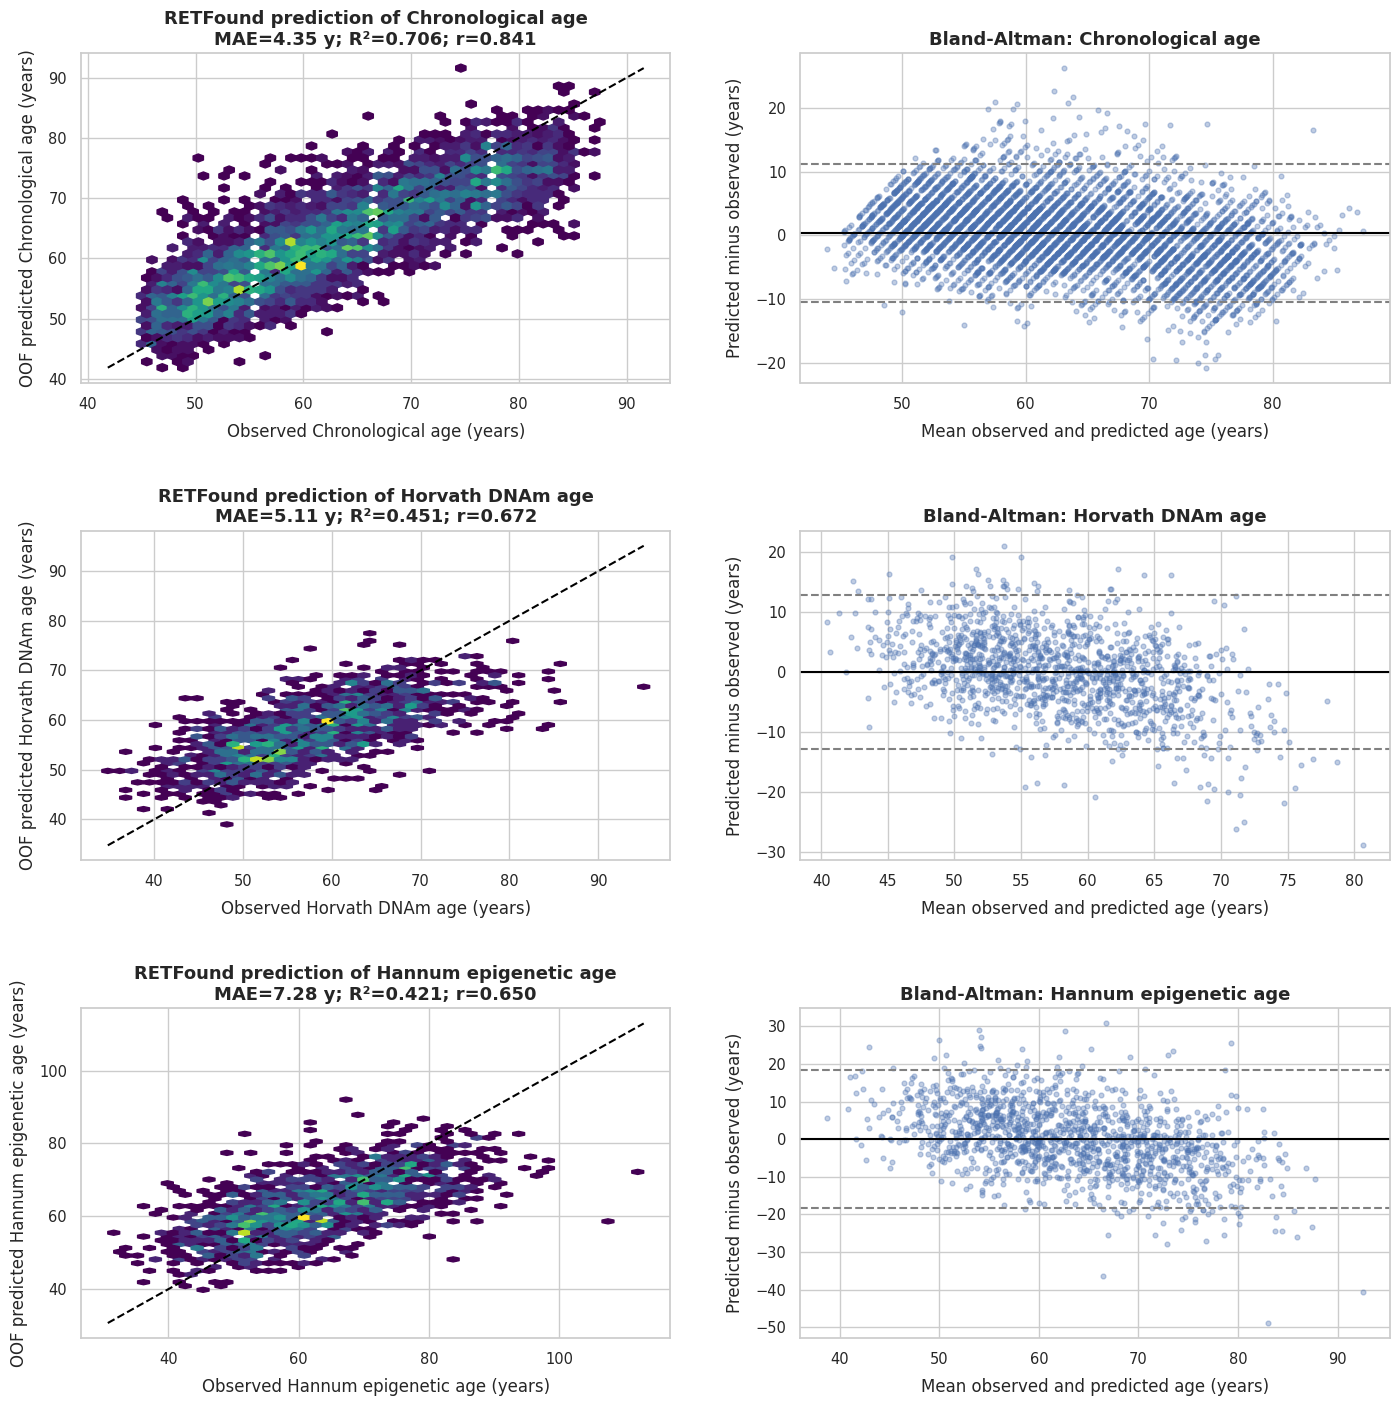

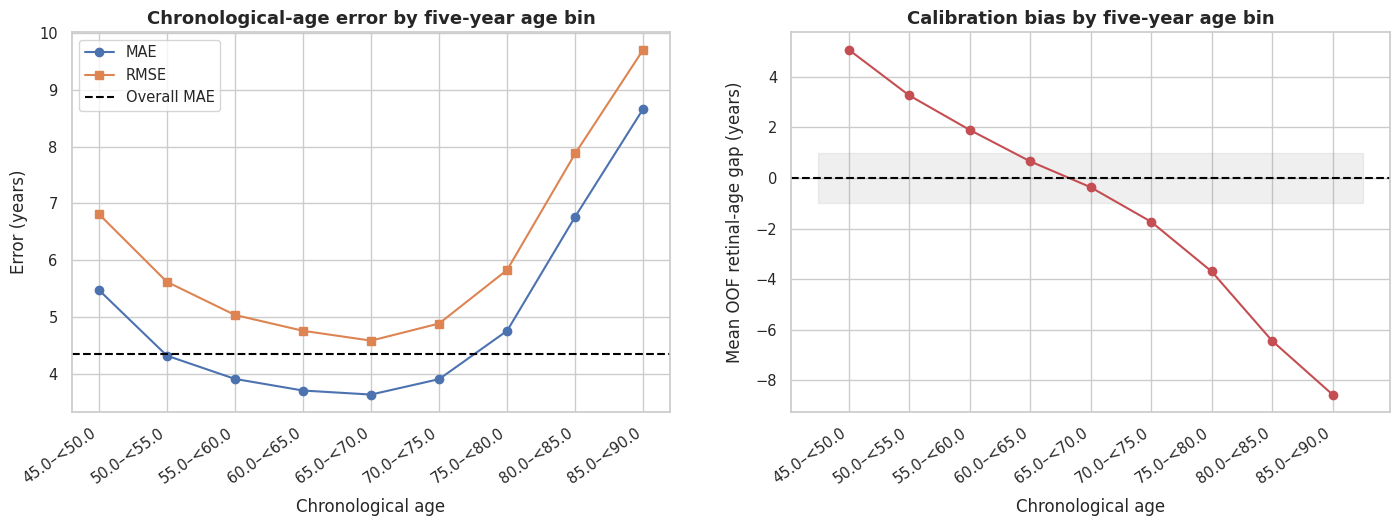

In [0]:
performance_panels = [
    (
        "Chronological age",
        chronological_participant,
        "chronological_age",
        "retinal_age_oof",
        model_metrics.iloc[1],
    )
]
for clock_column, oof in epigenetic_oof.items():
    metric = model_metrics[
        model_metrics["analysis"].str.startswith(
            ABSOLUTE_CLOCKS[clock_column]
        )
    ].iloc[0]
    performance_panels.append(
        (
            ABSOLUTE_CLOCKS[clock_column],
            oof,
            "age",
            "retinal_age_prediction_oof",
            metric,
        )
    )

figure, axes = plt.subplots(
    len(performance_panels),
    2,
    figsize=(14, 4.7 * len(performance_panels)),
    squeeze=False,
    layout="constrained",
)
for row_index, (
    label,
    frame,
    target_column,
    prediction_column,
    metric,
) in enumerate(performance_panels):
    plot = frame[[target_column, prediction_column]].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()
    if len(plot) > maximum_scatter_points:
        plot = plot.sample(
            maximum_scatter_points,
            random_state=random_state + row_index,
        )
    target = plot[target_column].to_numpy(float)
    prediction = plot[prediction_column].to_numpy(float)
    limits = [
        min(target.min(), prediction.min()),
        max(target.max(), prediction.max()),
    ]
    axes[row_index, 0].hexbin(
        target,
        prediction,
        gridsize=45,
        mincnt=1,
        cmap="viridis",
    )
    axes[row_index, 0].plot(limits, limits, "--", color="black")
    axes[row_index, 0].set(
        title=(
            f"RETFound prediction of {label}\n"
            f"MAE={metric['mae']:.2f} y; "
            f"R²={metric['r2']:.3f}; r={metric['pearson_r']:.3f}"
        ),
        xlabel=f"Observed {label} (years)",
        ylabel=f"OOF predicted {label} (years)",
    )
    mean_pair = (target + prediction) / 2
    difference = prediction - target
    mean_difference = float(np.mean(difference))
    loa = 1.96 * float(np.std(difference, ddof=1))
    axes[row_index, 1].scatter(
        mean_pair,
        difference,
        s=12,
        alpha=0.35,
    )
    axes[row_index, 1].axhline(
        mean_difference,
        color="black",
        linewidth=1.5,
    )
    axes[row_index, 1].axhline(
        mean_difference + loa,
        color="gray",
        linestyle="--",
    )
    axes[row_index, 1].axhline(
        mean_difference - loa,
        color="gray",
        linestyle="--",
    )
    axes[row_index, 1].set(
        title=f"Bland-Altman: {label}",
        xlabel="Mean observed and predicted age (years)",
        ylabel="Predicted minus observed (years)",
    )
model_performance_figure = (
    figure_root / "figure_1_oof_model_performance.png"
)
prepare_publication_figure(figure)
figure.savefig(
    model_performance_figure,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)
plt.show()
plt.close(figure)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.3),
    layout="constrained",
)
if not age_bin_performance.empty:
    x = np.arange(len(age_bin_performance))
    age_bin_labels = [
        str(value)
        .replace("[", "")
        .replace(")", "")
        .replace(", ", "–<")
        for value in age_bin_performance["age_bin_5y"]
    ]
    axes[0].plot(
        x,
        age_bin_performance["mae"],
        marker="o",
        label="MAE",
    )
    axes[0].plot(
        x,
        age_bin_performance["rmse"],
        marker="s",
        label="RMSE",
    )
    axes[0].axhline(
        overall_mae,
        color="black",
        linestyle="--",
        label="Overall MAE",
    )
    axes[0].set_xticks(
        x,
        age_bin_labels,
        rotation=35,
        ha="right",
    )
    axes[0].set(
        title="Chronological-age error by five-year age bin",
        xlabel="Chronological age",
        ylabel="Error (years)",
    )
    axes[0].legend()
    axes[1].plot(
        x,
        age_bin_performance["mean_error"],
        marker="o",
        color="#C44E52",
    )
    axes[1].axhline(0, color="black", linestyle="--")
    axes[1].fill_between(
        [-0.5, len(x) - 0.5],
        [-1, -1],
        [1, 1],
        color="gray",
        alpha=0.12,
    )
    axes[1].set_xticks(
        x,
        age_bin_labels,
        rotation=35,
        ha="right",
    )
    axes[1].set(
        title="Calibration bias by five-year age bin",
        xlabel="Chronological age",
        ylabel="Mean OOF retinal-age gap (years)",
    )
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_2_chronological_age_operating_range.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)
plt.show()
plt.close(figure)

## 6. Assemble the baseline three-age cohort

Retinal age comes only from the chronological-age head's held-out
prediction. The two epigenetic-trained head predictions are attached under
explicitly secondary names.

In [0]:
retinal_baseline = chronological_oof[
    chronological_oof["visit"].eq("BL")
][
    [
        "participant_id",
        "chronological_age",
        "retinal_age_oof",
        "retinal_chronological_gap",
        "cv_fold",
        "n_embedded_images",
    ]
].copy()
master = (
    retinal_baseline.merge(
        epigenetic,
        on="participant_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        participant_visit[
            participant_visit["visit"].eq("BL")
        ].drop(columns=["embedding", "chronological_age"], errors="ignore"),
        on=["participant_id"],
        how="left",
        validate="one_to_one",
        suffixes=("", "_questionnaire"),
    )
)
for clock_column, oof in epigenetic_oof.items():
    secondary = oof[
        ["participant_id", "retinal_age_prediction_oof"]
    ].rename(
        columns={
            "retinal_age_prediction_oof": (
                f"retfound_prediction_of_{clock_column}_oof"
            )
        }
    )
    master = master.merge(
        secondary,
        on="participant_id",
        how="left",
        validate="one_to_one",
    )

for clock_column in ABSOLUTE_CLOCKS:
    short = (
        "dnam"
        if clock_column == "epigenetic_dnam_age"
        else "hannum"
    )
    master[f"{short}_chronological_gap"] = (
        master[clock_column] - master["chronological_age"]
    )
    master[f"retinal_{short}_gap"] = (
        master["retinal_age_oof"] - master[clock_column]
    )
    master[f"absolute_retinal_{short}_distance"] = (
        master[f"retinal_{short}_gap"].abs()
    )
    master[f"absolute_chronological_{short}_distance"] = (
        master[f"{short}_chronological_gap"].abs()
    )
master["absolute_retinal_chronological_distance"] = (
    master["retinal_chronological_gap"].abs()
)

# Residual retinal age acceleration uses the full participant-level OOF
# cohort to estimate the expected age trend, then applies it to the
# epigenetic subset.
valid_retinal = chronological_participant[
    ["retinal_age_oof", "chronological_age"]
].dropna()
retinal_slope, retinal_intercept = np.polyfit(
    valid_retinal["chronological_age"],
    valid_retinal["retinal_age_oof"],
    1,
)
master["retinal_age_acceleration_residual"] = (
    master["retinal_age_oof"]
    - (
        retinal_intercept
        + retinal_slope * master["chronological_age"]
    )
)
write_frame(
    master,
    private_root / "baseline_three_age_master_private.parquet",
)
print(
    f"Baseline participants with any epigenetic phenotype and OOF retinal "
    f"age: {len(master):,}"
)

Baseline participants with any epigenetic phenotype and OOF retinal age: 1,406


## 7. Chronological age versus released epigenetic ages

Correlation alone is insufficient for agreement, so the table also reports
MAE, RMSE, signed bias, calibration, and concordance correlation.

analysis,n,target_mean,target_sd,prediction_mean,prediction_sd,mae,median_absolute_error,rmse,r2,pearson_r,pearson_p,spearman_rho,spearman_p,calibration_slope,calibration_intercept,mean_error,sd_error,ccc
Horvath DNAm age versus chronological age,1406,62.99,10.2613,57.7647,8.8677,6.0253,5.3841,7.3453,0.4872,0.8641,0.0,0.879,0.0,0.7468,10.7255,-5.2253,5.1642,0.7445
Retinal age versus chronological age: Horvath DNAm age subset,1406,62.99,10.2613,63.6241,8.6522,4.5027,3.7054,5.8051,0.6797,0.8269,0.0,0.8335,0.0,0.6973,19.7038,0.6341,5.7724,0.8132
Retinal age versus Horvath DNAm age,1406,57.7647,8.8677,63.6241,8.6522,7.1811,6.4119,8.8305,0.0077,0.7157,0.0,0.7316,0.0,0.6983,23.288,5.8594,6.6089,0.5847
Hannum epigenetic age versus chronological age,1406,62.99,10.2613,63.0767,12.2558,5.0201,4.0627,6.4944,0.5992,0.848,0.0,0.8604,0.0,1.0129,-0.7241,0.0867,6.4961,0.8348
Retinal age versus chronological age: Hannum epigenetic age subset,1406,62.99,10.2613,63.6241,8.6522,4.5027,3.7054,5.8051,0.6797,0.8269,0.0,0.8335,0.0,0.6973,19.7038,0.6341,5.7724,0.8132
Retinal age versus Hannum epigenetic age,1406,63.0767,12.2558,63.6241,8.6522,6.8344,5.671,8.7212,0.4933,0.7037,0.0,0.7184,0.0,0.4968,32.2859,0.5474,8.7071,0.6623


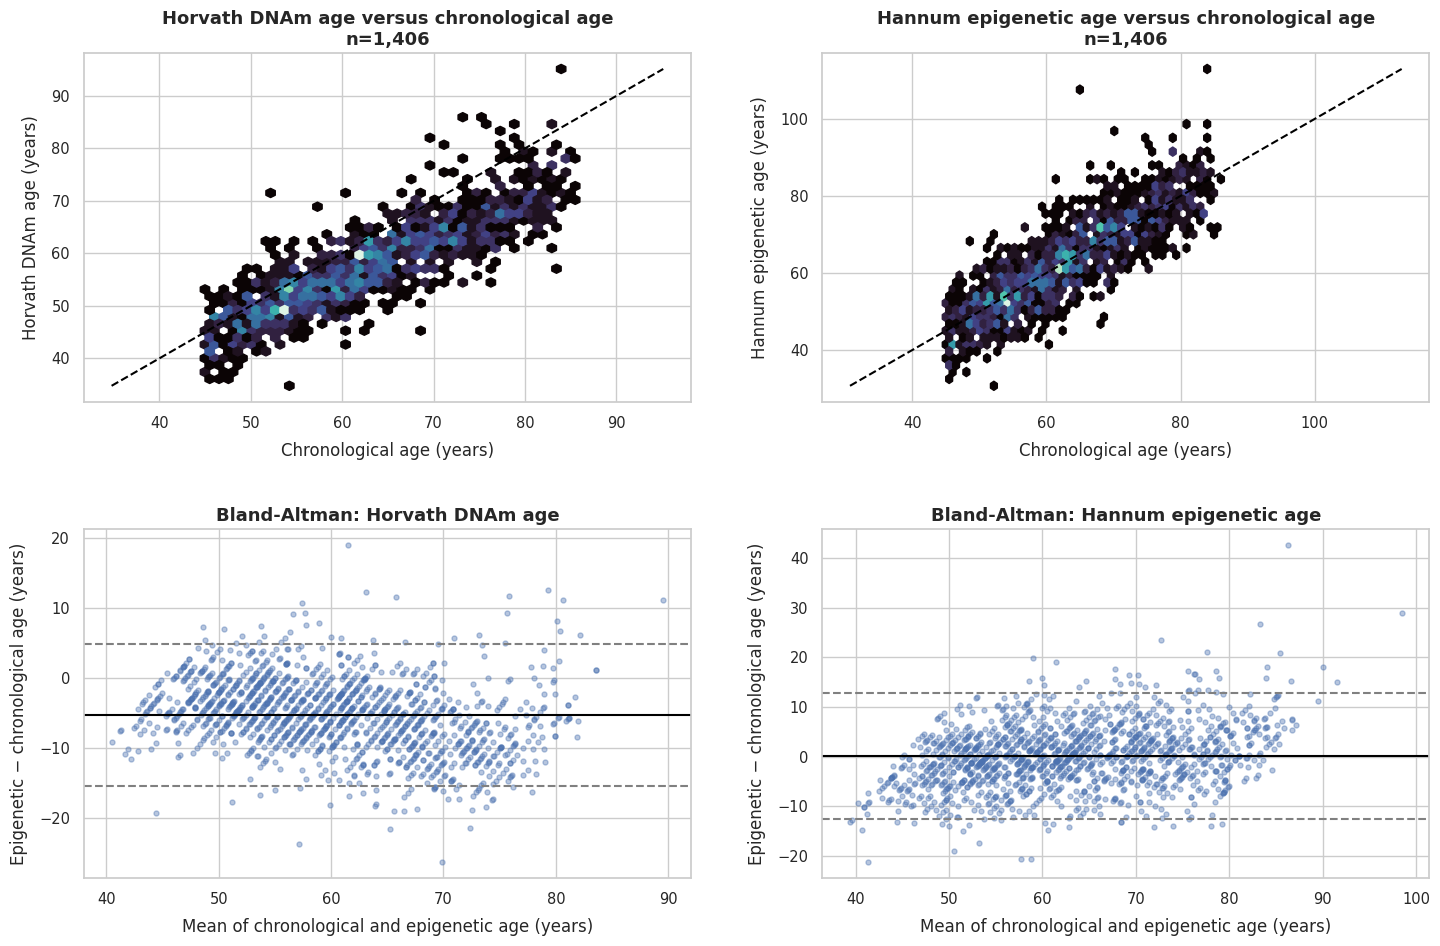

In [0]:
agreement_rows = []
for clock_column, clock_label in ABSOLUTE_CLOCKS.items():
    subset = master.dropna(
        subset=[
            "chronological_age",
            "retinal_age_oof",
            clock_column,
        ]
    )
    agreement_rows.extend(
        [
            regression_metrics(
                subset,
                "chronological_age",
                clock_column,
                f"{clock_label} versus chronological age",
            ),
            regression_metrics(
                subset,
                "chronological_age",
                "retinal_age_oof",
                f"Retinal age versus chronological age: {clock_label} subset",
            ),
            regression_metrics(
                subset,
                clock_column,
                "retinal_age_oof",
                f"Retinal age versus {clock_label}",
            ),
        ]
    )
agreement = pd.DataFrame(agreement_rows)
write_frame(
    agreement,
    statistics_root / "three_age_agreement_metrics.csv",
)
display(agreement.round(4))

figure, axes = plt.subplots(
    2,
    len(ABSOLUTE_CLOCKS),
    figsize=(7.2 * len(ABSOLUTE_CLOCKS), 9.5),
    squeeze=False,
    layout="constrained",
)
for column_index, (clock_column, clock_label) in enumerate(
    ABSOLUTE_CLOCKS.items()
):
    subset = master.dropna(
        subset=["chronological_age", clock_column]
    ).copy()
    x = subset["chronological_age"].to_numpy(float)
    y = subset[clock_column].to_numpy(float)
    limits = [min(x.min(), y.min()), max(x.max(), y.max())]
    axes[0, column_index].hexbin(
        x,
        y,
        gridsize=40,
        mincnt=1,
        cmap="mako",
    )
    axes[0, column_index].plot(limits, limits, "--", color="black")
    axes[0, column_index].set(
        title=(
            f"{clock_label} versus chronological age\n"
            f"n={len(subset):,}"
        ),
        xlabel="Chronological age (years)",
        ylabel=f"{clock_label} (years)",
    )
    difference = y - x
    axes[1, column_index].scatter(
        (x + y) / 2,
        difference,
        s=13,
        alpha=0.4,
    )
    mean_difference = np.mean(difference)
    loa = 1.96 * np.std(difference, ddof=1)
    axes[1, column_index].axhline(
        mean_difference,
        color="black",
    )
    axes[1, column_index].axhline(
        mean_difference + loa,
        color="gray",
        linestyle="--",
    )
    axes[1, column_index].axhline(
        mean_difference - loa,
        color="gray",
        linestyle="--",
    )
    axes[1, column_index].set(
        title=f"Bland-Altman: {clock_label}",
        xlabel="Mean of chronological and epigenetic age (years)",
        ylabel="Epigenetic − chronological age (years)",
    )
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_3_epigenetic_vs_chronological_age.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)
plt.show()
plt.close(figure)

In [ ]:
# Persistence-only input for Figure 2; identifiers are excluded.
write_frame(
    master[
        [
            "chronological_age",
            "retinal_age_oof",
            "epigenetic_dnam_age",
            "epigenetic_hannum_age",
        ]
    ].sort_values(
        ["chronological_age", "retinal_age_oof"],
        kind="stable",
    ),
    statistics_root / "figure_02_three_age_points.parquet",
)


## 8. Demographic stratification and explanatory contribution

Released racial/cultural background, spirometry ethnicity, and sex are
evaluated separately. Categories below the minimum reporting count are
excluded from group-specific inference. Nested models first include
chronological age (linear and quadratic), available cardiometabolic
comorbidities, and the complementary demographic covariate; the full model
then adds the demographic factor. Incremental R-squared quantifies how much
additional variance the demographic factor explains.

demographic,demographic_label,outcome,outcome_label,n,n_levels,base_r2,full_r2,incremental_r2,nested_f_statistic,nested_f_p_value,df_difference,covariance,status,fdr_q_value,significant_fdr_0_05
sex_labeled,Sex at birth,retinal_hannum_gap,Retinal minus Hannum age,1344,2,0.15675,0.21308,0.05633,95.35478,0.0,1.0,HC3 for coefficients; classical nested F,ok,0.0,true
sex_labeled,Sex at birth,hannum_chronological_gap,Hannum minus chronological age,1344,2,0.0161,0.08057,0.06446,93.38872,0.0,1.0,HC3 for coefficients; classical nested F,ok,0.0,true
sex_labeled,Sex at birth,dnam_chronological_gap,Horvath minus chronological age,1344,2,0.24975,0.28434,0.03459,64.37289,0.0,1.0,HC3 for coefficients; classical nested F,ok,0.0,true
sex_labeled,Sex at birth,retinal_dnam_gap,Retinal minus Horvath age,1344,2,0.0181,0.06183,0.04373,62.08573,0.0,1.0,HC3 for coefficients; classical nested F,ok,0.0,true
sex_labeled,Sex at birth,retinal_age_acceleration_residual,Age-residualized retinal age acceleration,1344,2,0.01775,0.02532,0.00757,10.34931,0.00133,1.0,HC3 for coefficients; classical nested F,ok,0.00398,true
sex_labeled,Sex at birth,retinal_chronological_gap,Retinal minus chronological age,1344,2,0.30347,0.30884,0.00537,10.34931,0.00133,1.0,HC3 for coefficients; classical nested F,ok,0.00398,true
ethnicity_spirometry_labeled,Spirometry ethnicity,retinal_hannum_gap,Retinal minus Hannum age,1030,3,0.21402,0.21709,0.00307,1.99742,0.13622,2.0,HC3 for coefficients; classical nested F,ok,0.35027,false
racial_background,Self-reported racial/cultural background,retinal_hannum_gap,Retinal minus Hannum age,1344,4,0.21032,0.21308,0.00277,1.56103,0.19707,3.0,HC3 for coefficients; classical nested F,ok,0.41465,false
ethnicity_spirometry_labeled,Spirometry ethnicity,retinal_age_acceleration_residual,Age-residualized retinal age acceleration,1030,3,0.02423,0.02686,0.00263,1.37465,0.2534,2.0,HC3 for coefficients; classical nested F,ok,0.41465,false
ethnicity_spirometry_labeled,Spirometry ethnicity,hannum_chronological_gap,Hannum minus chronological age,1030,3,0.08717,0.08978,0.00261,1.46098,0.23249,2.0,HC3 for coefficients; classical nested F,ok,0.41465,false


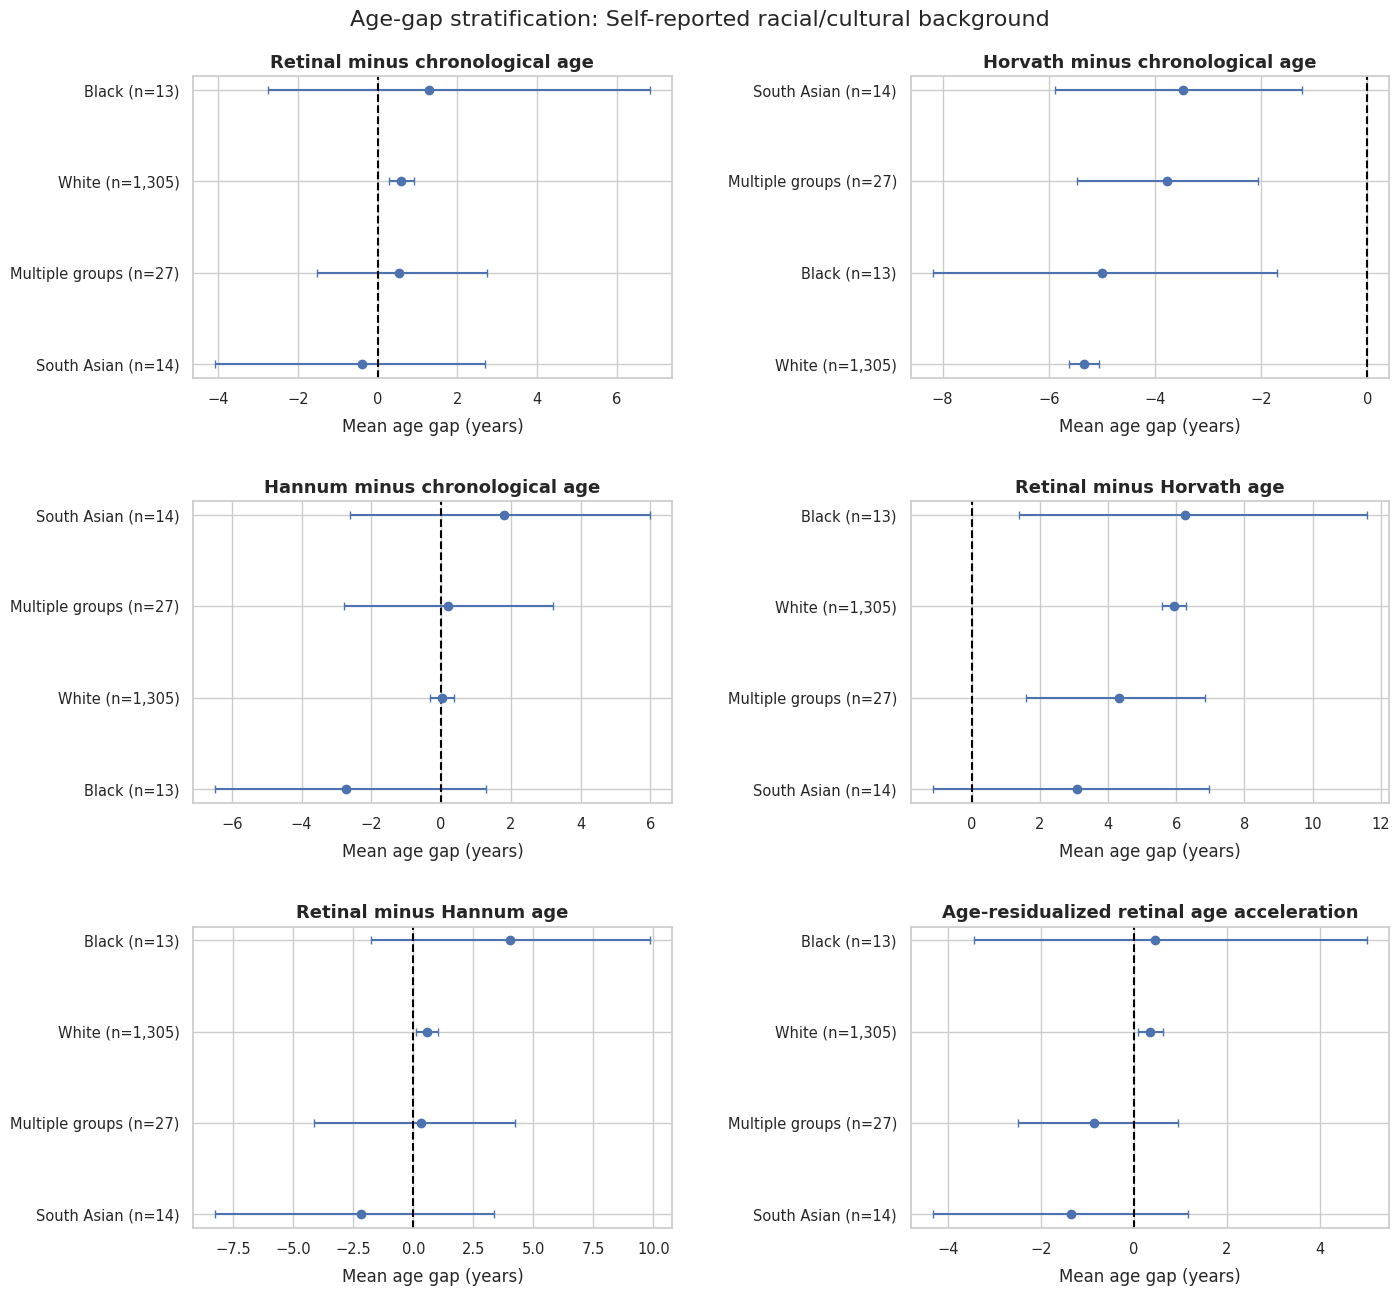

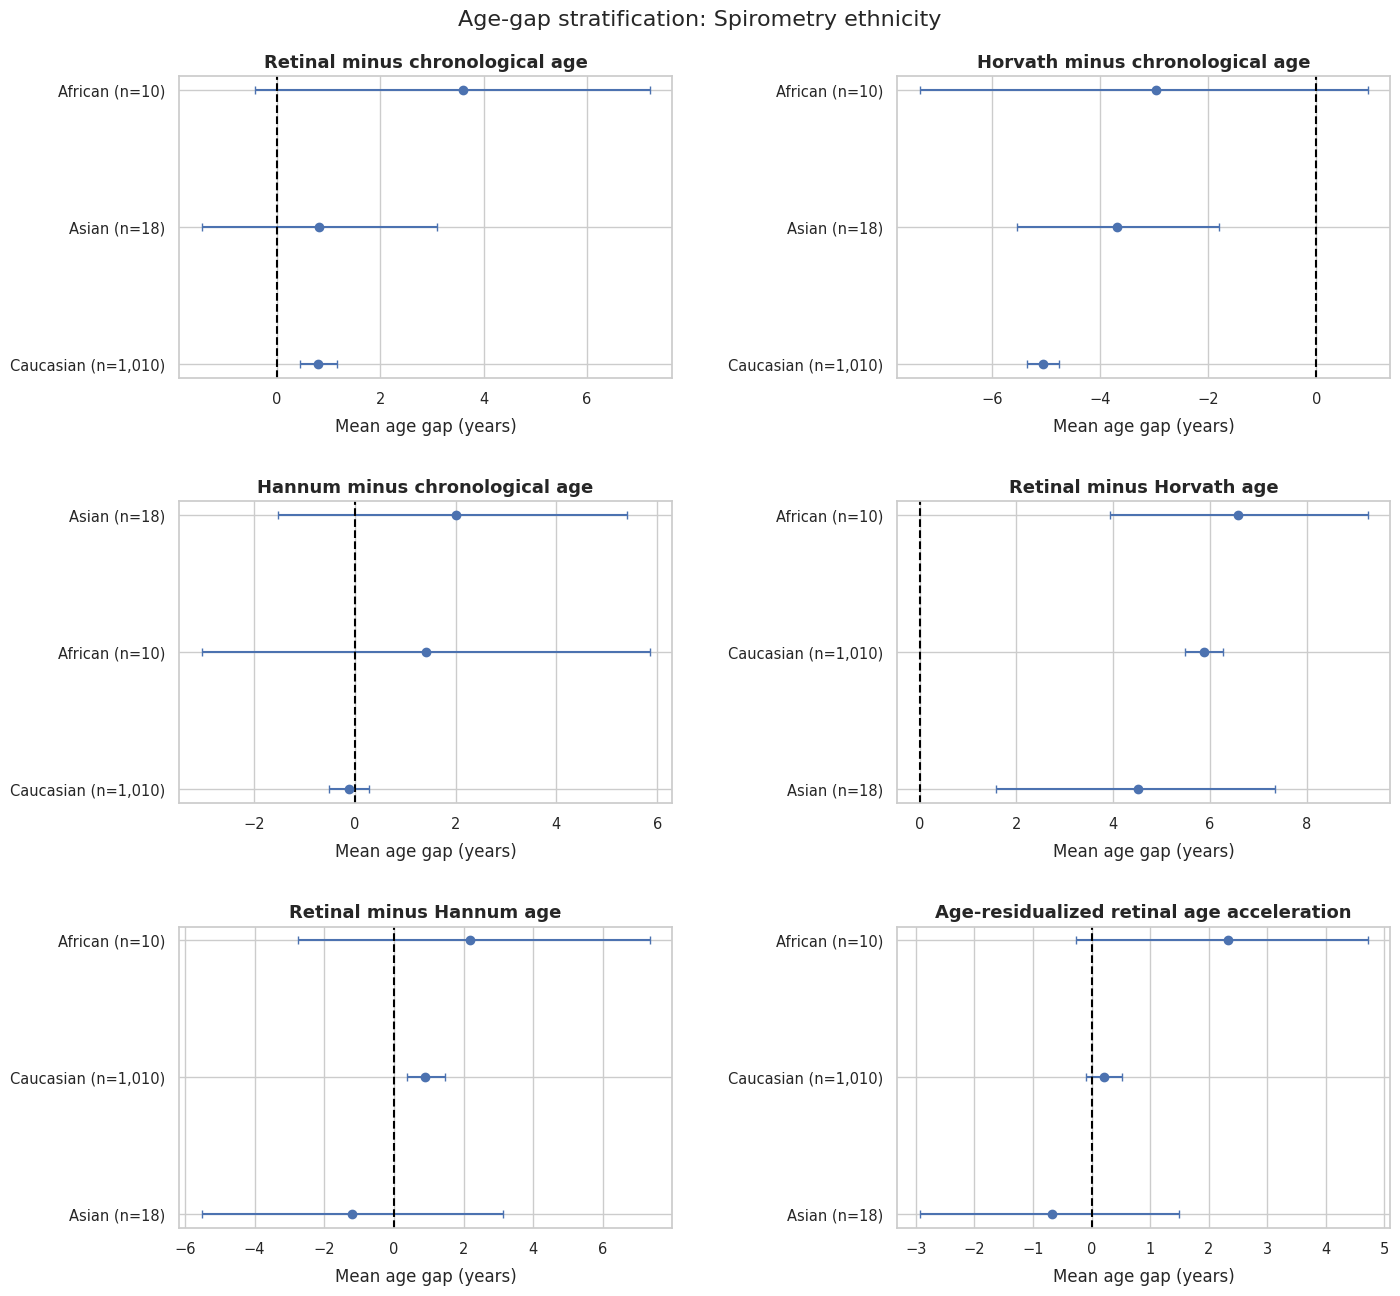

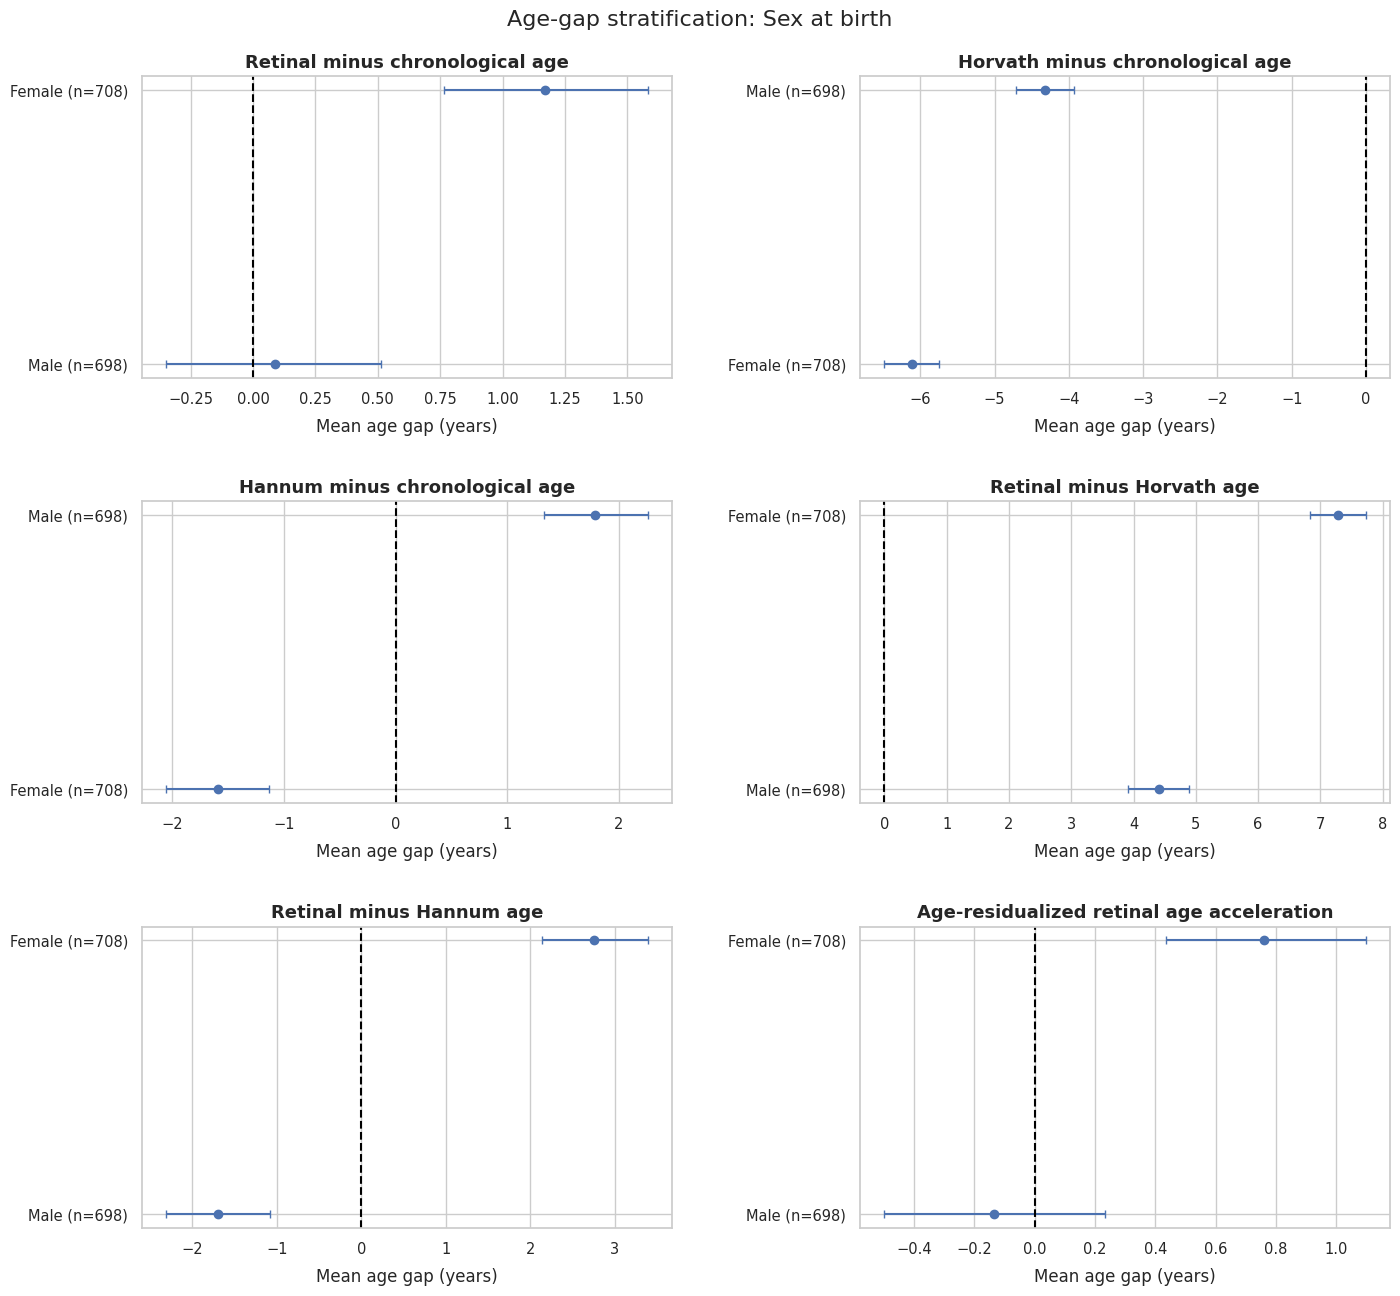

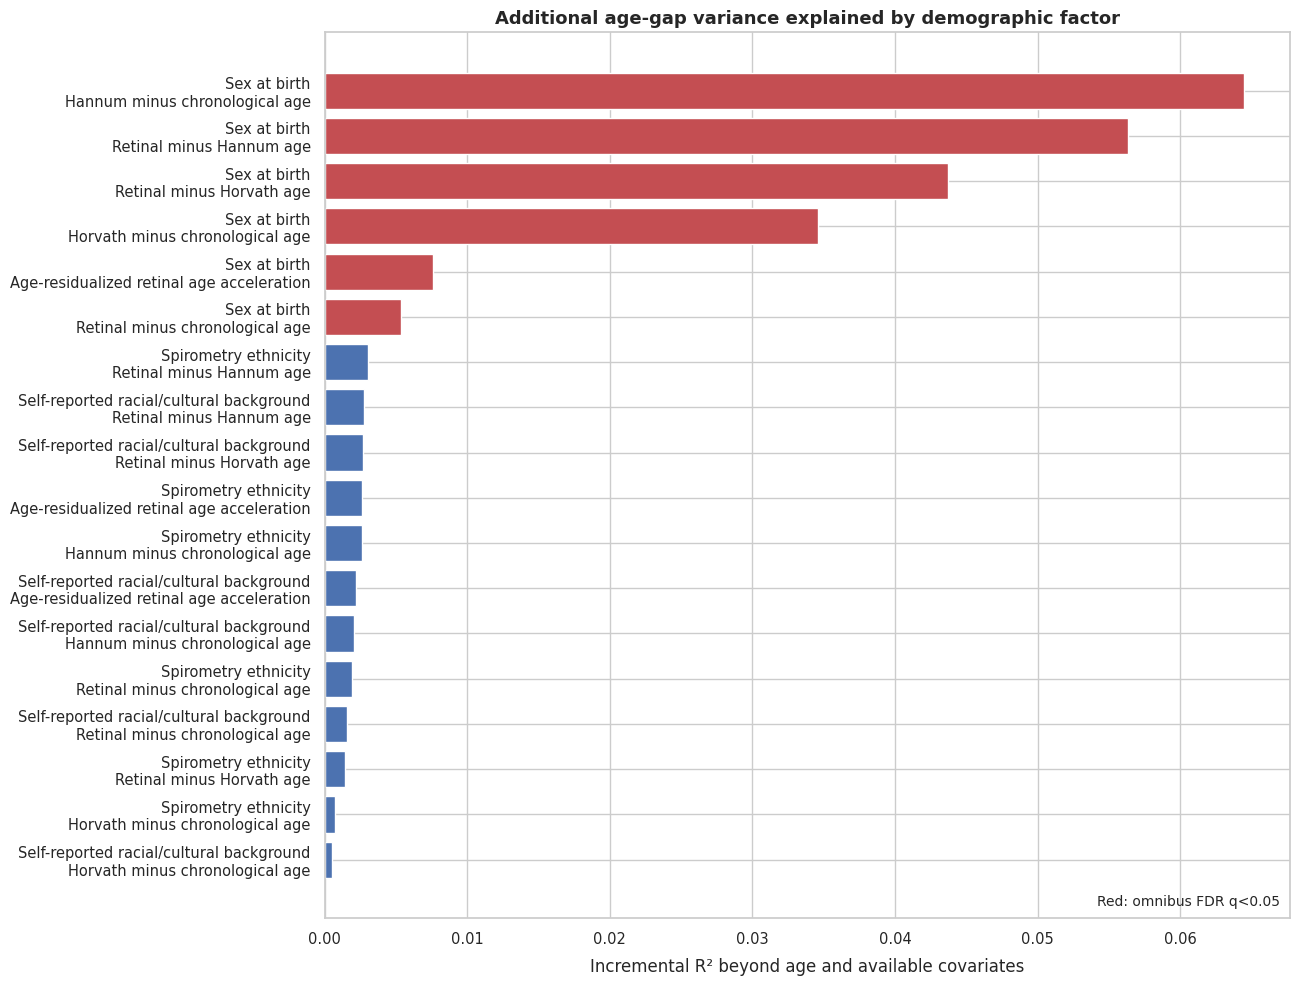

In [0]:
demographic_variables = {
    "racial_background": "Self-reported racial/cultural background",
    "ethnicity_spirometry_labeled": "Spirometry ethnicity",
    "sex_labeled": "Sex at birth",
}
gap_variables = {
    "retinal_chronological_gap": "Retinal minus chronological age",
    "dnam_chronological_gap": "Horvath minus chronological age",
    "hannum_chronological_gap": "Hannum minus chronological age",
    "retinal_dnam_gap": "Retinal minus Horvath age",
    "retinal_hannum_gap": "Retinal minus Hannum age",
    "retinal_age_acceleration_residual": (
        "Age-residualized retinal age acceleration"
    ),
}

comorbidity_covariates = [
    column
    for column in (
        "diabetes",
        "hypertension",
        "heart_disease",
        "stroke",
        "multimorbidity_selected_count",
    )
    if column in master.columns
]
for column in comorbidity_covariates:
    master[column] = pd.to_numeric(master[column], errors="coerce")

# Model performance stratification is reported separately from the
# adjusted age-gap models below.
participant_demographics = participant_visit[
    [
        column
        for column in (
            "participant_id",
            "visit",
            *demographic_variables,
        )
        if column in participant_visit.columns
    ]
].copy()
participant_demographics["_visit_priority"] = (
    participant_demographics["visit"]
    .map({"BL": 0, "F1": 1})
    .fillna(99)
)
participant_demographics = (
    participant_demographics.sort_values(
        ["participant_id", "_visit_priority"],
        kind="stable",
    )
    .drop_duplicates("participant_id")
    .drop(columns=["visit", "_visit_priority"])
)
head_frames = [
    (
        "Chronological age head",
        chronological_participant.rename(
            columns={
                "chronological_age": "target_age",
                "retinal_age_oof": "prediction_age",
            }
        ),
    )
]
for clock_column, oof in epigenetic_oof.items():
    head_frames.append(
        (
            f"{ABSOLUTE_CLOCKS[clock_column]} head",
            oof.rename(
                columns={
                    "age": "target_age",
                    "retinal_age_prediction_oof": "prediction_age",
                }
            ),
        )
    )
stratified_performance_rows = []
for head_label, head_frame in head_frames:
    head_frame = head_frame.merge(
        participant_demographics,
        on="participant_id",
        how="left",
        validate="many_to_one",
    )
    for demographic, demographic_label in (
        demographic_variables.items()
    ):
        if demographic not in head_frame.columns:
            continue
        counts = head_frame[demographic].value_counts(dropna=True)
        for level, count in counts.items():
            if count < minimum_reporting_group_n:
                continue
            subset = head_frame[
                head_frame[demographic].eq(level)
            ]
            metrics = regression_metrics(
                subset,
                "target_age",
                "prediction_age",
                head_label,
            )
            metrics.update(
                {
                    "demographic": demographic,
                    "demographic_label": demographic_label,
                    "level": str(level),
                }
            )
            stratified_performance_rows.append(metrics)
stratified_head_performance = pd.DataFrame(
    stratified_performance_rows
)
write_frame(
    stratified_head_performance,
    statistics_root
    / "retfound_heads_demographic_performance.csv",
)

demographic_descriptive_rows = []
demographic_model_rows = []
demographic_coefficient_rows = []
for demographic_index, (
    demographic,
    demographic_label,
) in enumerate(demographic_variables.items()):
    if demographic not in master.columns:
        continue
    counts = master[demographic].value_counts(dropna=True)
    eligible_levels = counts[
        counts >= minimum_reporting_group_n
    ].index.astype(str)
    for outcome_index, (outcome, outcome_label) in enumerate(
        gap_variables.items()
    ):
        if outcome not in master.columns:
            continue
        work = master[
            master[demographic].astype("string").isin(eligible_levels)
        ].copy()
        work[outcome] = pd.to_numeric(work[outcome], errors="coerce")
        work = work.dropna(subset=[demographic, outcome])
        if work.empty or work[demographic].nunique() < 2:
            continue
        for level, subset in work.groupby(demographic):
            values = subset[outcome].to_numpy(float)
            low, high = bootstrap_mean_ci(
                values,
                bootstrap_repetitions,
                random_state
                + 100 * demographic_index
                + 10 * outcome_index,
            )
            demographic_descriptive_rows.append(
                {
                    "demographic": demographic,
                    "demographic_label": demographic_label,
                    "level": str(level),
                    "outcome": outcome,
                    "outcome_label": outcome_label,
                    "n": int(len(values)),
                    "mean": float(np.mean(values)),
                    "sd": float(np.std(values, ddof=1)),
                    "median": float(np.median(values)),
                    "ci_low": low,
                    "ci_high": high,
                }
            )

        work = work.copy()
        work["chronological_age_sq"] = (
            work["chronological_age"] ** 2
        )
        base_terms = [
            "chronological_age",
            "chronological_age_sq",
            *comorbidity_covariates,
        ]
        if demographic != "sex_labeled" and "sex_labeled" in work:
            base_terms.append("C(sex_labeled)")
        if (
            demographic == "sex_labeled"
            and "racial_background" in work
            and work["racial_background"].value_counts().ge(
                minimum_reporting_group_n
            ).sum() >= 2
        ):
            frequent_race = work[
                "racial_background"
            ].value_counts()
            frequent_race = frequent_race[
                frequent_race >= minimum_reporting_group_n
            ].index
            work = work[
                work["racial_background"].isin(frequent_race)
            ].copy()
            base_terms.append("C(racial_background)")
        model_columns = [
            outcome,
            demographic,
            "chronological_age",
            "chronological_age_sq",
            *comorbidity_covariates,
        ]
        if "C(sex_labeled)" in base_terms:
            model_columns.append("sex_labeled")
        if "C(racial_background)" in base_terms:
            model_columns.append("racial_background")
        model_work = work[
            list(dict.fromkeys(model_columns))
        ].dropna()
        if (
            len(model_work) < 30
            or model_work[demographic].nunique() < 2
        ):
            continue
        # statsmodels/formulaic can reject pandas StringDtype even
        # though the values are valid labels. Convert every formula
        # categorical to an explicit pandas category first.
        formula_categoricals = [demographic]
        if "C(sex_labeled)" in base_terms:
            formula_categoricals.append("sex_labeled")
        if "C(racial_background)" in base_terms:
            formula_categoricals.append("racial_background")
        for categorical in dict.fromkeys(formula_categoricals):
            model_work[categorical] = pd.Categorical(
                model_work[categorical].astype(str)
            )
        base_formula = (
            f"{outcome} ~ " + " + ".join(base_terms)
        )
        full_formula = (
            base_formula + f" + C({demographic})"
        )
        try:
            base_fit = smf.ols(
                base_formula,
                data=model_work,
            ).fit()
            full_fit = smf.ols(
                full_formula,
                data=model_work,
            ).fit(cov_type="HC3")
            classical_full = smf.ols(
                full_formula,
                data=model_work,
            ).fit()
            nested_f, nested_p, df_difference = (
                classical_full.compare_f_test(base_fit)
            )
            demographic_model_rows.append(
                {
                    "demographic": demographic,
                    "demographic_label": demographic_label,
                    "outcome": outcome,
                    "outcome_label": outcome_label,
                    "n": int(len(model_work)),
                    "n_levels": int(
                        model_work[demographic].nunique()
                    ),
                    "base_r2": float(base_fit.rsquared),
                    "full_r2": float(full_fit.rsquared),
                    "incremental_r2": float(
                        full_fit.rsquared - base_fit.rsquared
                    ),
                    "nested_f_statistic": float(nested_f),
                    "nested_f_p_value": float(nested_p),
                    "df_difference": float(df_difference),
                    "covariance": "HC3 for coefficients; classical nested F",
                    "status": "ok",
                }
            )
            confidence = full_fit.conf_int()
            term_prefix = f"C({demographic})[T."
            for term in full_fit.params.index:
                if not term.startswith(term_prefix):
                    continue
                demographic_coefficient_rows.append(
                    {
                        "demographic": demographic,
                        "demographic_label": demographic_label,
                        "outcome": outcome,
                        "outcome_label": outcome_label,
                        "term": term,
                        "comparison_level": (
                            term[len(term_prefix):-1]
                        ),
                        "n": int(len(model_work)),
                        "adjusted_coefficient": float(
                            full_fit.params[term]
                        ),
                        "ci_low": float(confidence.loc[term, 0]),
                        "ci_high": float(confidence.loc[term, 1]),
                        "p_value": float(full_fit.pvalues[term]),
                        "covariance": "HC3",
                    }
                )
        except Exception as error:
            demographic_model_rows.append(
                {
                    "demographic": demographic,
                    "demographic_label": demographic_label,
                    "outcome": outcome,
                    "outcome_label": outcome_label,
                    "n": int(len(model_work)),
                    "status": f"failed:{type(error).__name__}",
                    "error_message": str(error)[:500],
                }
            )

demographic_descriptives = pd.DataFrame(
    demographic_descriptive_rows
)
demographic_models = pd.DataFrame(demographic_model_rows)
demographic_coefficients = pd.DataFrame(
    demographic_coefficient_rows
)
if not demographic_models.empty:
    if "nested_f_p_value" not in demographic_models.columns:
        demographic_models["nested_f_p_value"] = np.nan
    if "incremental_r2" not in demographic_models.columns:
        demographic_models["incremental_r2"] = np.nan
    valid_p = pd.to_numeric(
        demographic_models["nested_f_p_value"],
        errors="coerce",
    )
    demographic_models["fdr_q_value"] = benjamini_hochberg(
        valid_p.to_numpy(float)
    )
    demographic_models["significant_fdr_0_05"] = (
        demographic_models["fdr_q_value"] < 0.05
    )
if not demographic_coefficients.empty:
    demographic_coefficients["fdr_q_value"] = benjamini_hochberg(
        demographic_coefficients["p_value"].to_numpy(float)
    )
    demographic_coefficients["significant_fdr_0_05"] = (
        demographic_coefficients["fdr_q_value"] < 0.05
    )
write_frame(
    demographic_descriptives,
    statistics_root / "demographic_gap_descriptives.csv",
)
write_frame(
    demographic_models,
    statistics_root / "demographic_incremental_models.csv",
)
write_frame(
    demographic_coefficients,
    statistics_root / "demographic_adjusted_coefficients.csv",
)
demographic_failures = demographic_models[
    ~demographic_models["status"].eq("ok")
].copy()
write_frame(
    demographic_failures,
    statistics_root / "demographic_model_failures.csv",
)
if not demographic_failures.empty:
    display(demographic_failures)
    first_failure = demographic_failures.iloc[0]
    raise RuntimeError(
        "Adjusted demographic models failed; the notebook will not "
        "report 'no demographic differences' from an incomplete run. "
        f"First failure: {first_failure['demographic_label']} / "
        f"{first_failure['outcome_label']}: "
        f"{first_failure.get('error_message', first_failure['status'])}. "
        "See demographic_model_failures.csv."
    )
display(
    demographic_models.sort_values(
        ["fdr_q_value", "incremental_r2"],
        ascending=[True, False],
    ).round(5)
)

selected_outcomes = list(gap_variables)
plot_data = demographic_descriptives[
    demographic_descriptives["outcome"].isin(selected_outcomes)
].copy()
if not plot_data.empty:
    for demographic, demographic_label in (
        demographic_variables.items()
    ):
        figure, axes = plt.subplots(
            3,
            2,
            figsize=(14, 13),
            squeeze=False,
            layout="constrained",
        )
        for axis, outcome in zip(
            axes.ravel(),
            selected_outcomes,
        ):
            subset = plot_data[
                plot_data["demographic"].eq(demographic)
                & plot_data["outcome"].eq(outcome)
            ].sort_values("mean")
            if subset.empty:
                axis.set_visible(False)
                continue
            point = subset["mean"].to_numpy(float)
            low = subset["ci_low"].to_numpy(float)
            high = subset["ci_high"].to_numpy(float)
            xerr = np.vstack(
                [
                    np.maximum(
                        point - np.minimum(low, point),
                        0.0,
                    ),
                    np.maximum(
                        np.maximum(high, point) - point,
                        0.0,
                    ),
                ]
            )
            position = np.arange(len(subset))
            axis.errorbar(
                point,
                position,
                xerr=xerr,
                fmt="o",
                capsize=3,
            )
            labels = [
                f"{level} (n={int(n):,})"
                for level, n in zip(
                    subset["level"],
                    subset["n"],
                )
            ]
            axis.set_yticks(position, labels)
            axis.axvline(0, color="black", linestyle="--")
            axis.set(
                title=(
                    gap_variables[outcome]
                ),
                xlabel="Mean age gap (years)",
                ylabel="",
            )
        figure.suptitle(
            f"Age-gap stratification: {demographic_label}",
        )
        prepare_publication_figure(figure)
        figure.savefig(
            figure_root
            / f"figure_4_{demographic}_age_gaps.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.25,
        )
        plt.show()
        plt.close(figure)

model_plot = demographic_models[
    demographic_models["status"].eq("ok")
].copy()
if not model_plot.empty:
    model_plot["label"] = (
        model_plot["demographic_label"]
        + "\n"
        + model_plot["outcome_label"]
    )
    model_plot = model_plot.sort_values(
        "incremental_r2",
        ascending=True,
    )
    figure, axis = plt.subplots(
        figsize=(13, max(7, 0.55 * len(model_plot))),
        layout="constrained",
    )
    colors = np.where(
        model_plot["significant_fdr_0_05"],
        "#C44E52",
        "#4C72B0",
    )
    axis.barh(
        np.arange(len(model_plot)),
        model_plot["incremental_r2"],
        color=colors,
    )
    axis.set_yticks(
        np.arange(len(model_plot)),
        model_plot["label"],
    )
    axis.set(
        title=(
            "Additional age-gap variance explained by demographic factor"
        ),
        xlabel="Incremental R² beyond age and available covariates",
        ylabel="",
    )
    axis.text(
        0.99,
        0.01,
        "Red: omnibus FDR q<0.05",
        transform=axis.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
    )
    prepare_publication_figure(figure)
    figure.savefig(
        figure_root
        / "figure_4d_demographic_incremental_r2.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.25,
    )
    plt.show()
    plt.close(figure)

## 9. Three-way paired distance tests

For each absolute epigenetic clock, the prespecified hypotheses are:

- absolute retinal-epigenetic distance is smaller than absolute
  retinal-chronological distance; and
- absolute retinal-epigenetic distance is smaller than absolute
  epigenetic-chronological distance.

Both one-sided Wilcoxon signed-rank and participant-level sign-flip tests
are reported, with FDR correction. These tests establish relative
closeness—not interchangeability, causality, or a shared biological
mechanism.

In [0]:
distance_rows = []
distance_summary_rows = []
for clock_index, (clock_column, clock_label) in enumerate(
    ABSOLUTE_CLOCKS.items()
):
    short = (
        "dnam"
        if clock_column == "epigenetic_dnam_age"
        else "hannum"
    )
    subset = master.dropna(
        subset=[
            "retinal_age_oof",
            "chronological_age",
            clock_column,
        ]
    ).copy()
    distances = {
        "Retinal–epigenetic": np.abs(
            subset["retinal_age_oof"] - subset[clock_column]
        ).to_numpy(float),
        "Retinal–chronological": np.abs(
            subset["retinal_age_oof"]
            - subset["chronological_age"]
        ).to_numpy(float),
        "Epigenetic–chronological": np.abs(
            subset[clock_column]
            - subset["chronological_age"]
        ).to_numpy(float),
    }
    for pair_index, (pair_label, values) in enumerate(
        distances.items()
    ):
        low, high = bootstrap_mean_ci(
            values,
            bootstrap_repetitions,
            random_state + 1000 * clock_index + pair_index,
        )
        distance_summary_rows.append(
            {
                "clock": clock_column,
                "clock_label": clock_label,
                "pair": pair_label,
                "n": int(len(values)),
                "mean_absolute_distance": float(np.mean(values)),
                "median_absolute_distance": float(np.median(values)),
                "ci_low": low,
                "ci_high": high,
            }
        )

    retinal_epigenetic = distances["Retinal–epigenetic"]
    for comparison_index, comparator in enumerate(
        (
            "Retinal–chronological",
            "Epigenetic–chronological",
        )
    ):
        difference = (
            retinal_epigenetic - distances[comparator]
        )
        low, high = bootstrap_mean_ci(
            difference,
            bootstrap_repetitions,
            random_state
            + 5000
            + 100 * clock_index
            + comparison_index,
        )
        try:
            wilcoxon_p = float(
                stats.wilcoxon(
                    retinal_epigenetic,
                    distances[comparator],
                    alternative="less",
                    zero_method="wilcox",
                ).pvalue
            )
        except ValueError:
            wilcoxon_p = np.nan
        distance_rows.append(
            {
                "clock": clock_column,
                "clock_label": clock_label,
                "hypothesis": (
                    "Retinal–epigenetic absolute distance < "
                    f"{comparator} absolute distance"
                ),
                "n": int(len(difference)),
                "mean_distance_difference": float(
                    np.mean(difference)
                ),
                "mean_difference_ci_low": low,
                "mean_difference_ci_high": high,
                "proportion_retinal_epigenetic_smaller": float(
                    np.mean(difference < 0)
                ),
                "wilcoxon_one_sided_p": wilcoxon_p,
                "signflip_one_sided_p": signflip_less_test(
                    difference,
                    permutation_repetitions,
                    random_state
                    + 7000
                    + 100 * clock_index
                    + comparison_index,
                ),
            }
        )

distance_tests = pd.DataFrame(distance_rows)
distance_summary = pd.DataFrame(distance_summary_rows)
distance_tests["wilcoxon_fdr_q"] = benjamini_hochberg(
    distance_tests["wilcoxon_one_sided_p"].to_numpy(float)
)
distance_tests["signflip_fdr_q"] = benjamini_hochberg(
    distance_tests["signflip_one_sided_p"].to_numpy(float)
)
distance_tests["supports_closer_after_fdr"] = (
    distance_tests["mean_difference_ci_high"].lt(0)
    & distance_tests["wilcoxon_fdr_q"].lt(0.05)
    & distance_tests["signflip_fdr_q"].lt(0.05)
)
write_frame(
    distance_tests,
    statistics_root / "three_age_paired_distance_tests.csv",
)
write_frame(
    distance_summary,
    statistics_root / "three_age_distance_summary.csv",
)
display(distance_tests.round(5))

acceleration_rows = []
for measure, label in ACCELERATION_MEASURES.items():
    subset = master[
        ["retinal_age_acceleration_residual", measure]
    ].apply(pd.to_numeric, errors="coerce").dropna()
    if len(subset) < minimum_reporting_group_n:
        continue
    pearson = stats.pearsonr(
        subset["retinal_age_acceleration_residual"],
        subset[measure],
    )
    spearman = stats.spearmanr(
        subset["retinal_age_acceleration_residual"],
        subset[measure],
    )
    acceleration_rows.append(
        {
            "measure": measure,
            "label": label,
            "n": int(len(subset)),
            "pearson_r": float(pearson.statistic),
            "pearson_p": float(pearson.pvalue),
            "spearman_rho": float(spearman.statistic),
            "spearman_p": float(spearman.pvalue),
        }
    )
acceleration_correlations = pd.DataFrame(acceleration_rows)
if not acceleration_correlations.empty:
    acceleration_correlations["pearson_fdr_q"] = (
        benjamini_hochberg(
            acceleration_correlations["pearson_p"].to_numpy(float)
        )
    )
    acceleration_correlations["spearman_fdr_q"] = (
        benjamini_hochberg(
            acceleration_correlations["spearman_p"].to_numpy(float)
        )
    )
write_frame(
    acceleration_correlations,
    statistics_root / "retinal_epigenetic_acceleration_correlations.csv",
)
display(acceleration_correlations.round(5))

clock,clock_label,hypothesis,n,mean_distance_difference,mean_difference_ci_low,mean_difference_ci_high,proportion_retinal_epigenetic_smaller,wilcoxon_one_sided_p,signflip_one_sided_p,wilcoxon_fdr_q,signflip_fdr_q,supports_closer_after_fdr
epigenetic_dnam_age,Horvath DNAm age,Retinal–epigenetic absolute distance < Retinal–chronological absolute distance,1406,2.67839,2.42172,2.93449,0.30939,1.0,1.0,1.0,1.0,false
epigenetic_dnam_age,Horvath DNAm age,Retinal–epigenetic absolute distance < Epigenetic–chronological absolute distance,1406,1.15578,0.90119,1.42957,0.42176,1.0,1.0,1.0,1.0,false
epigenetic_hannum_age,Hannum epigenetic age,Retinal–epigenetic absolute distance < Retinal–chronological absolute distance,1406,2.33175,2.07143,2.5944,0.33428,1.0,1.0,1.0,1.0,false
epigenetic_hannum_age,Hannum epigenetic age,Retinal–epigenetic absolute distance < Epigenetic–chronological absolute distance,1406,1.81437,1.57866,2.05114,0.37696,1.0,1.0,1.0,1.0,false


measure,label,n,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_fdr_q,spearman_fdr_q
epigenetic_age_acceleration_difference,Released age-acceleration difference,1406,0.00537,0.84062,-0.00781,0.76995,0.96059,0.8078
epigenetic_age_acceleration_residual,Released age-acceleration residual,1406,0.0039,0.88379,-0.00952,0.72127,0.96059,0.8078
epigenetic_ieaa,IEAA,1406,0.01609,0.54673,-0.00649,0.8078,0.96059,0.8078
epigenetic_eeaa,EEAA,1406,-0.00132,0.96059,0.00876,0.74281,0.96059,0.8078


In [ ]:
# Persistence-only confidence intervals for Figure 2B and Figure S3C.
# These intervals are derived from the correlations computed immediately above;
# no model is fitted or updated in this cell.
figure_02_acceleration_forest = acceleration_correlations.copy()
if not figure_02_acceleration_forest.empty:
    fisher_z = np.arctanh(
        figure_02_acceleration_forest["pearson_r"].clip(
            lower=-0.999999,
            upper=0.999999,
        )
    )
    fisher_se = 1.0 / np.sqrt(
        figure_02_acceleration_forest["n"].astype(float) - 3.0
    )
    critical_value = float(stats.norm.ppf(0.975))
    figure_02_acceleration_forest["pearson_ci_low"] = np.tanh(
        fisher_z - critical_value * fisher_se
    )
    figure_02_acceleration_forest["pearson_ci_high"] = np.tanh(
        fisher_z + critical_value * fisher_se
    )
write_frame(
    figure_02_acceleration_forest,
    statistics_root / "figure_02_acceleration_correlation_forest.csv",
)


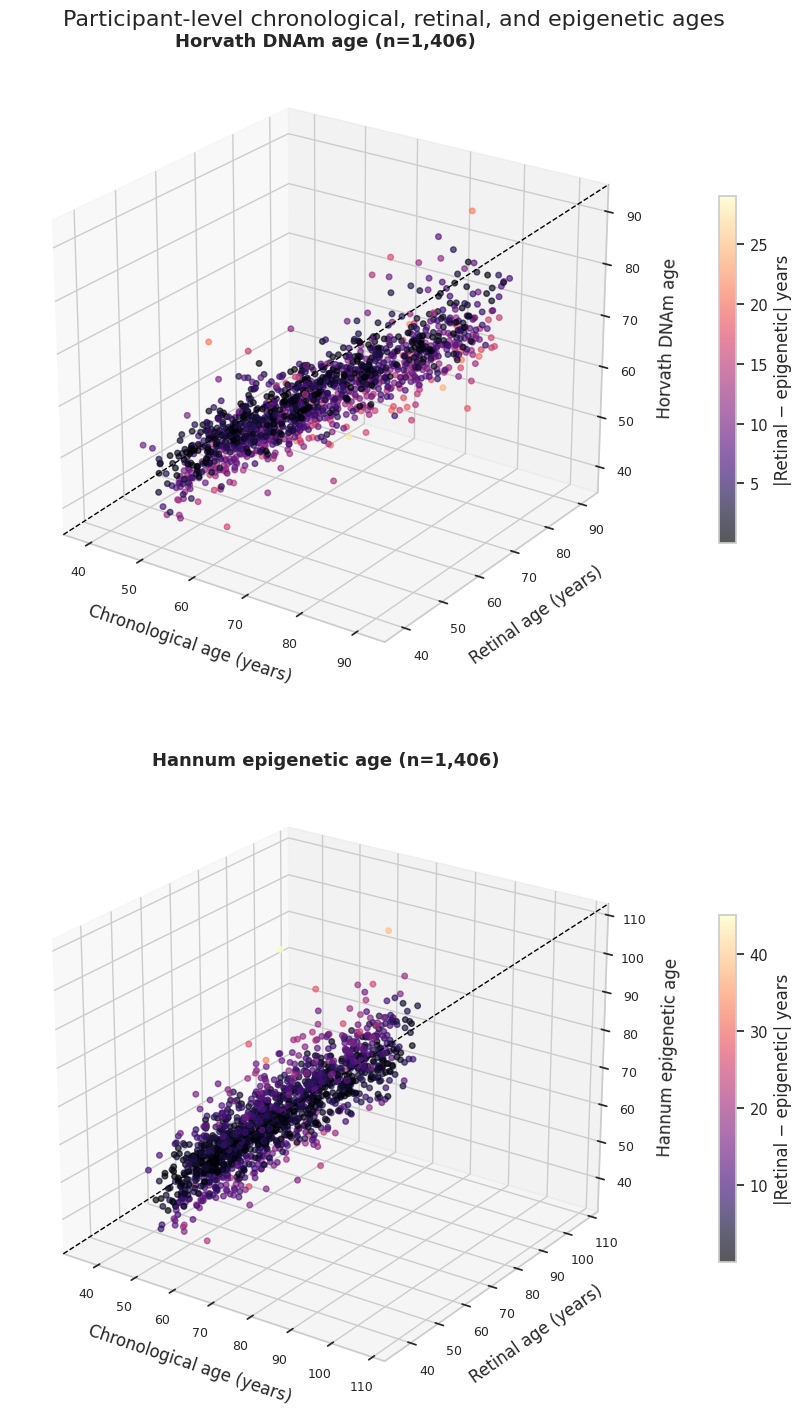

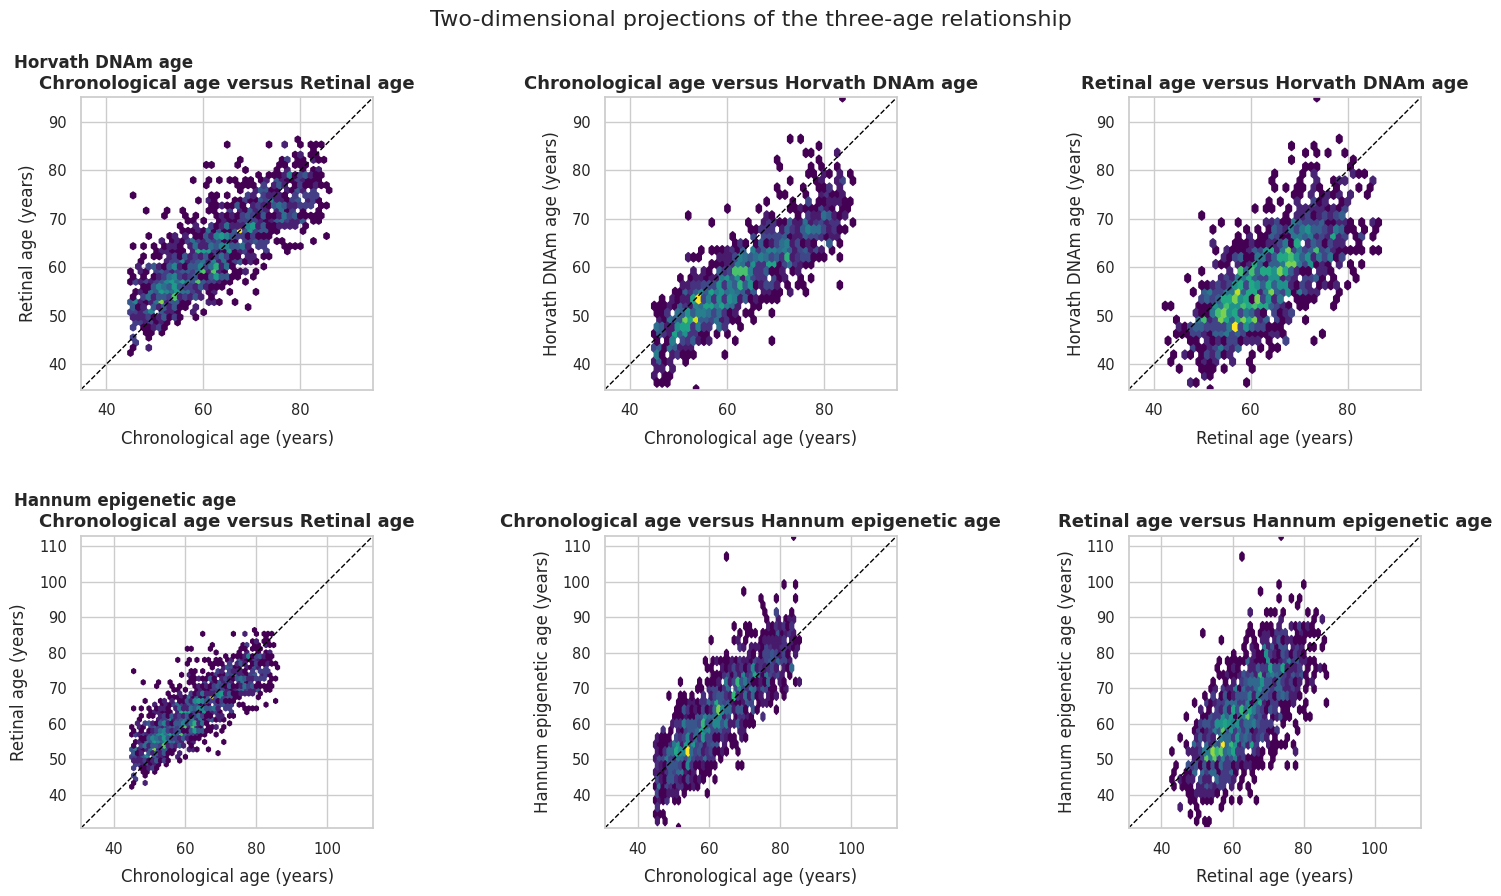

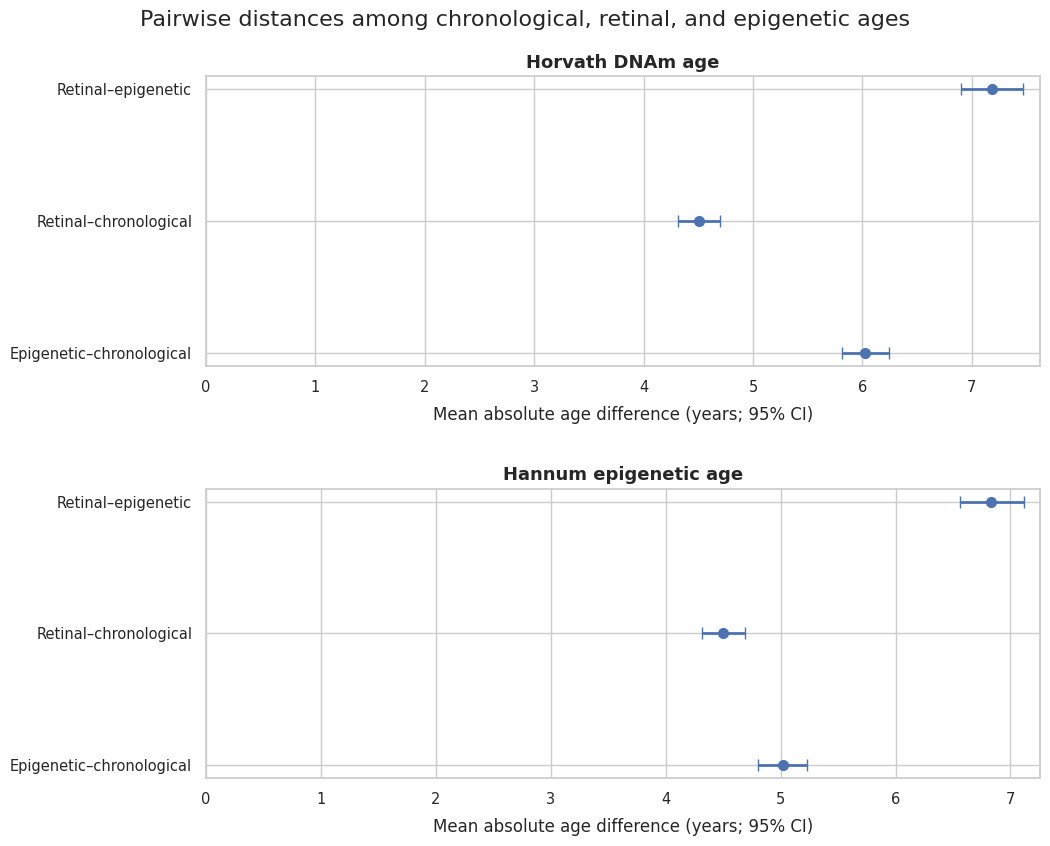

In [0]:
figure = plt.figure(figsize=(11.5, 15))
three_age_plot_data = {}
for index, (clock_column, clock_label) in enumerate(
    ABSOLUTE_CLOCKS.items(),
    1,
):
    axis = figure.add_subplot(
        len(ABSOLUTE_CLOCKS),
        1,
        index,
        projection="3d",
    )
    subset = master.dropna(
        subset=[
            "chronological_age",
            "retinal_age_oof",
            clock_column,
        ]
    ).copy()
    if len(subset) > maximum_scatter_points:
        subset = subset.sample(
            maximum_scatter_points,
            random_state=random_state + index,
        )
    three_age_plot_data[clock_column] = subset
    color = np.abs(
        subset["retinal_age_oof"] - subset[clock_column]
    )
    scatter = axis.scatter(
        subset["chronological_age"],
        subset["retinal_age_oof"],
        subset[clock_column],
        c=color,
        cmap="magma",
        s=16,
        alpha=0.65,
    )
    lower = float(
        subset[
            [
                "chronological_age",
                "retinal_age_oof",
                clock_column,
            ]
        ].min().min()
    )
    upper = float(
        subset[
            [
                "chronological_age",
                "retinal_age_oof",
                clock_column,
            ]
        ].max().max()
    )
    diagonal = np.linspace(lower, upper, 100)
    axis.plot(
        diagonal,
        diagonal,
        diagonal,
        "--",
        color="black",
        linewidth=1,
    )
    axis.set_xlim(lower, upper)
    axis.set_ylim(lower, upper)
    axis.set_zlim(lower, upper)
    axis.set_box_aspect((1.15, 1.15, 1.0))
    axis.set(
        title=f"{clock_label} (n={len(subset):,})",
        xlabel="Chronological age (years)",
        ylabel="Retinal age (years)",
        zlabel=clock_label,
    )
    axis.tick_params(axis="both", which="major", labelsize=9)
    axis.xaxis.labelpad = 8
    axis.yaxis.labelpad = 8
    axis.zaxis.labelpad = 8
    axis.view_init(elev=24, azim=-55)
    figure.colorbar(
        scatter,
        ax=axis,
        shrink=0.55,
        pad=0.08,
        label="|Retinal − epigenetic| years",
    )
figure.suptitle(
    "Participant-level chronological, retinal, and epigenetic ages",
    y=0.97,
)
figure.subplots_adjust(
    left=0.06,
    right=0.91,
    bottom=0.04,
    top=0.94,
    hspace=0.14,
)
figure.savefig(
    figure_root / "figure_5_three_age_3d.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()
plt.close(figure)

# Orthogonal projections make the geometry auditable without relying
# on a single 3D viewing angle.
figure, axes = plt.subplots(
    len(ABSOLUTE_CLOCKS),
    3,
    figsize=(15.5, 9),
    squeeze=False,
    layout="constrained",
)
for row, (clock_column, clock_label) in enumerate(
    ABSOLUTE_CLOCKS.items()
):
    subset = three_age_plot_data[clock_column]
    panels = (
        (
            "chronological_age",
            "retinal_age_oof",
            "Chronological age",
            "Retinal age",
        ),
        (
            "chronological_age",
            clock_column,
            "Chronological age",
            clock_label,
        ),
        (
            "retinal_age_oof",
            clock_column,
            "Retinal age",
            clock_label,
        ),
    )
    shared_lower = float(
        subset[
            ["chronological_age", "retinal_age_oof", clock_column]
        ].min().min()
    )
    shared_upper = float(
        subset[
            ["chronological_age", "retinal_age_oof", clock_column]
        ].max().max()
    )
    for column, (
        x_column,
        y_column,
        x_label,
        y_label,
    ) in enumerate(panels):
        axis = axes[row, column]
        axis.hexbin(
            subset[x_column],
            subset[y_column],
            gridsize=38,
            mincnt=1,
            cmap="viridis",
        )
        axis.plot(
            [shared_lower, shared_upper],
            [shared_lower, shared_upper],
            "--",
            color="black",
            linewidth=1,
        )
        axis.set_xlim(shared_lower, shared_upper)
        axis.set_ylim(shared_lower, shared_upper)
        axis.set_aspect("equal", adjustable="box")
        axis.set(
            title=f"{x_label} versus {y_label}",
            xlabel=f"{x_label} (years)",
            ylabel=f"{y_label} (years)",
        )
        if column == 0:
            axis.text(
                -0.23,
                1.10,
                clock_label,
                transform=axis.transAxes,
                fontsize=12,
                fontweight="semibold",
                ha="left",
            )
figure.suptitle(
    "Two-dimensional projections of the three-age relationship",
)
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_5b_three_age_pairwise_projections.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()
plt.close(figure)

figure, axes = plt.subplots(
    len(ABSOLUTE_CLOCKS),
    1,
    figsize=(10.5, 8.5),
    squeeze=False,
    layout="constrained",
)
for axis, (clock_column, clock_label) in zip(
    axes.ravel(),
    ABSOLUTE_CLOCKS.items(),
):
    plot = distance_summary[
        distance_summary["clock"].eq(clock_column)
    ].copy()
    point = plot["mean_absolute_distance"].to_numpy(float)
    low = plot["ci_low"].to_numpy(float)
    high = plot["ci_high"].to_numpy(float)
    xerr = np.vstack(
        [
            np.maximum(
                point - np.minimum(low, point),
                0.0,
            ),
            np.maximum(
                np.maximum(high, point) - point,
                0.0,
            ),
        ]
    )
    position = np.arange(len(plot))
    axis.errorbar(
        point,
        position,
        xerr=xerr,
        fmt="o",
        markersize=7,
        color="#4C72B0",
        ecolor="#4C72B0",
        elinewidth=2,
        capsize=4,
    )
    axis.set_yticks(
        position,
        plot["pair"],
    )
    axis.set(
        title=clock_label,
        xlabel="Mean absolute age difference (years; 95% CI)",
        ylabel="",
    )
    axis.set_xlim(left=0)
    axis.invert_yaxis()
figure.suptitle(
    "Pairwise distances among chronological, retinal, and epigenetic ages",
)
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_6_three_age_absolute_distances.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()
plt.close(figure)

## 10. Central-age and tail sensitivity

The same paired distance hypotheses are repeated in the prespecified
central 80%, lower 10%, and upper 10% chronological-age strata. These
results reveal whether apparent agreement is concentrated in the age range
where the chronological RETFound model is best calibrated.

In [0]:
master["age_distribution_stratum"] = np.select(
    [
        master["chronological_age"] < age_q10,
        master["chronological_age"] > age_q90,
    ],
    ["Lower 10% age tail", "Upper 10% age tail"],
    default="Central 80%",
)
sensitivity_rows = []
for stratum_index, (stratum, stratum_frame) in enumerate(
    master.groupby("age_distribution_stratum")
):
    for clock_index, (clock_column, clock_label) in enumerate(
        ABSOLUTE_CLOCKS.items()
    ):
        subset = stratum_frame.dropna(
            subset=[
                "chronological_age",
                "retinal_age_oof",
                clock_column,
            ]
        )
        if len(subset) < minimum_reporting_group_n:
            continue
        retinal_epigenetic = np.abs(
            subset["retinal_age_oof"] - subset[clock_column]
        ).to_numpy(float)
        comparators = {
            "Retinal–chronological": np.abs(
                subset["retinal_age_oof"]
                - subset["chronological_age"]
            ).to_numpy(float),
            "Epigenetic–chronological": np.abs(
                subset[clock_column]
                - subset["chronological_age"]
            ).to_numpy(float),
        }
        for comparison_index, (
            comparator_label,
            comparator,
        ) in enumerate(comparators.items()):
            difference = retinal_epigenetic - comparator
            low, high = bootstrap_mean_ci(
                difference,
                bootstrap_repetitions,
                random_state
                + 9000
                + 1000 * stratum_index
                + 100 * clock_index
                + comparison_index,
            )
            sensitivity_rows.append(
                {
                    "age_distribution_stratum": stratum,
                    "clock": clock_column,
                    "clock_label": clock_label,
                    "comparator": comparator_label,
                    "n": int(len(subset)),
                    "mean_distance_difference": float(
                        np.mean(difference)
                    ),
                    "ci_low": low,
                    "ci_high": high,
                    "proportion_retinal_epigenetic_smaller": float(
                        np.mean(difference < 0)
                    ),
                    "signflip_one_sided_p": signflip_less_test(
                        difference,
                        permutation_repetitions,
                        random_state
                        + 12000
                        + 1000 * stratum_index
                        + 100 * clock_index
                        + comparison_index,
                    ),
                }
            )
age_stratified_distance_tests = pd.DataFrame(sensitivity_rows)
if not age_stratified_distance_tests.empty:
    age_stratified_distance_tests["signflip_fdr_q"] = (
        benjamini_hochberg(
            age_stratified_distance_tests[
                "signflip_one_sided_p"
            ].to_numpy(float)
        )
    )
    stratum_bias = (
        tail_performance.set_index("age_distribution_stratum")[
            "mean_error"
        ]
    )
    age_stratified_distance_tests[
        "retinal_model_mean_error"
    ] = age_stratified_distance_tests[
        "age_distribution_stratum"
    ].map(stratum_bias)
    age_stratified_distance_tests[
        "supports_closer_statistically"
    ] = (
        age_stratified_distance_tests["ci_high"].lt(0)
        & age_stratified_distance_tests[
            "signflip_fdr_q"
        ].lt(0.05)
    )
    age_stratified_distance_tests[
        "tail_calibration_warning"
    ] = (
        age_stratified_distance_tests[
            "age_distribution_stratum"
        ].ne("Central 80%")
        & age_stratified_distance_tests[
            "retinal_model_mean_error"
        ].abs().ge(2.0)
    )
    age_stratified_distance_tests[
        "publication_support_flag"
    ] = (
        age_stratified_distance_tests[
            "supports_closer_statistically"
        ]
        & ~age_stratified_distance_tests[
            "tail_calibration_warning"
        ]
    )
    age_stratified_distance_tests["interpretation"] = np.select(
        [
            age_stratified_distance_tests[
                "supports_closer_statistically"
            ]
            & age_stratified_distance_tests[
                "tail_calibration_warning"
            ],
            age_stratified_distance_tests[
                "supports_closer_statistically"
            ],
        ],
        [
            (
                "Statistically positive but calibration-sensitive: "
                "do not interpret as biological convergence"
            ),
            "Statistically positive within the calibrated age range",
        ],
        default="No evidence that retinal–epigenetic distance is smaller",
    )
write_frame(
    age_stratified_distance_tests,
    statistics_root / "age_stratified_three_age_distance_tests.csv",
)
display(age_stratified_distance_tests.round(5))

age_distribution_stratum,clock,clock_label,comparator,n,mean_distance_difference,ci_low,ci_high,proportion_retinal_epigenetic_smaller,signflip_one_sided_p,signflip_fdr_q,retinal_model_mean_error,supports_closer_statistically,tail_calibration_warning,publication_support_flag,interpretation
Central 80%,epigenetic_dnam_age,Horvath DNAm age,Retinal–chronological,1153,2.96898,2.69015,3.25032,0.28448,1.0,1.0,0.49795,false,false,false,No evidence that retinal–epigenetic distance is smaller
Central 80%,epigenetic_dnam_age,Horvath DNAm age,Epigenetic–chronological,1153,1.26251,0.98267,1.53253,0.41023,1.0,1.0,0.49795,false,false,false,No evidence that retinal–epigenetic distance is smaller
Central 80%,epigenetic_hannum_age,Hannum epigenetic age,Retinal–chronological,1153,2.44723,2.1478,2.73671,0.32003,1.0,1.0,0.49795,false,false,false,No evidence that retinal–epigenetic distance is smaller
Central 80%,epigenetic_hannum_age,Hannum epigenetic age,Epigenetic–chronological,1153,1.63282,1.39084,1.88848,0.37814,1.0,1.0,0.49795,false,false,false,No evidence that retinal–epigenetic distance is smaller
Lower 10% age tail,epigenetic_dnam_age,Horvath DNAm age,Retinal–chronological,127,2.23529,1.58469,2.8664,0.34646,1.0,1.0,5.07971,false,true,false,No evidence that retinal–epigenetic distance is smaller
Lower 10% age tail,epigenetic_dnam_age,Horvath DNAm age,Epigenetic–chronological,127,4.63072,3.68011,5.54268,0.1811,1.0,1.0,5.07971,false,true,false,No evidence that retinal–epigenetic distance is smaller
Lower 10% age tail,epigenetic_hannum_age,Hannum epigenetic age,Retinal–chronological,127,1.57025,0.72733,2.42747,0.43307,0.9994,1.0,5.07971,false,true,false,No evidence that retinal–epigenetic distance is smaller
Lower 10% age tail,epigenetic_hannum_age,Hannum epigenetic age,Epigenetic–chronological,127,2.65868,1.67509,3.66185,0.35433,1.0,1.0,5.07971,false,true,false,No evidence that retinal–epigenetic distance is smaller
Upper 10% age tail,epigenetic_dnam_age,Horvath DNAm age,Retinal–chronological,126,0.46592,-0.74194,1.61703,0.5,0.76212,1.0,-6.24565,false,true,false,No evidence that retinal–epigenetic distance is smaller
Upper 10% age tail,epigenetic_dnam_age,Horvath DNAm age,Epigenetic–chronological,126,-3.32346,-4.19572,-2.37199,0.76984,1.0E-4,0.0012,-6.24565,true,true,false,Statistically positive but calibration-sensitive: do not interpret as biological convergence


## 11. Patient-level three-clock acceleration and discordance

Raw age gaps inherit regression-to-the-mean from each clock. This section
therefore fits age splines in held-out participants and defines
acceleration as the cross-fitted residual from the expected clock value
at that chronological age. Residuals are standardized before combining
clocks. Continuous phenotypes are primary; percentile groups are
descriptive only.

component_role,original_component_number,explained_variance_ratio,loading_retinal,loading_horvath,loading_hannum
shared_aging_pc,1,0.5118,0.0271,0.7069,0.7068
retina_vs_epigenetic_pc,2,0.3332,0.9996,-0.0164,-0.0219
horvath_vs_hannum_pc,3,0.155,-0.0039,0.7071,-0.7071


three_clock_profile,participants,mean_shared_acceleration,mean_retina_specific,mean_clock_dispersion,mean_comorbidity_burden
Concordantly accelerated,29,1.5776,-0.2689,0.5364,2.2759
Concordantly decelerated,21,-1.3902,0.0311,0.4108,1.619
Epigenetic-only accelerated,109,0.8938,-1.5977,1.2799,1.8624
Mixed or intermediate,994,-0.2172,-0.1251,0.6542,1.6539
Retina-only accelerated,253,0.4029,1.2082,1.0606,1.9246


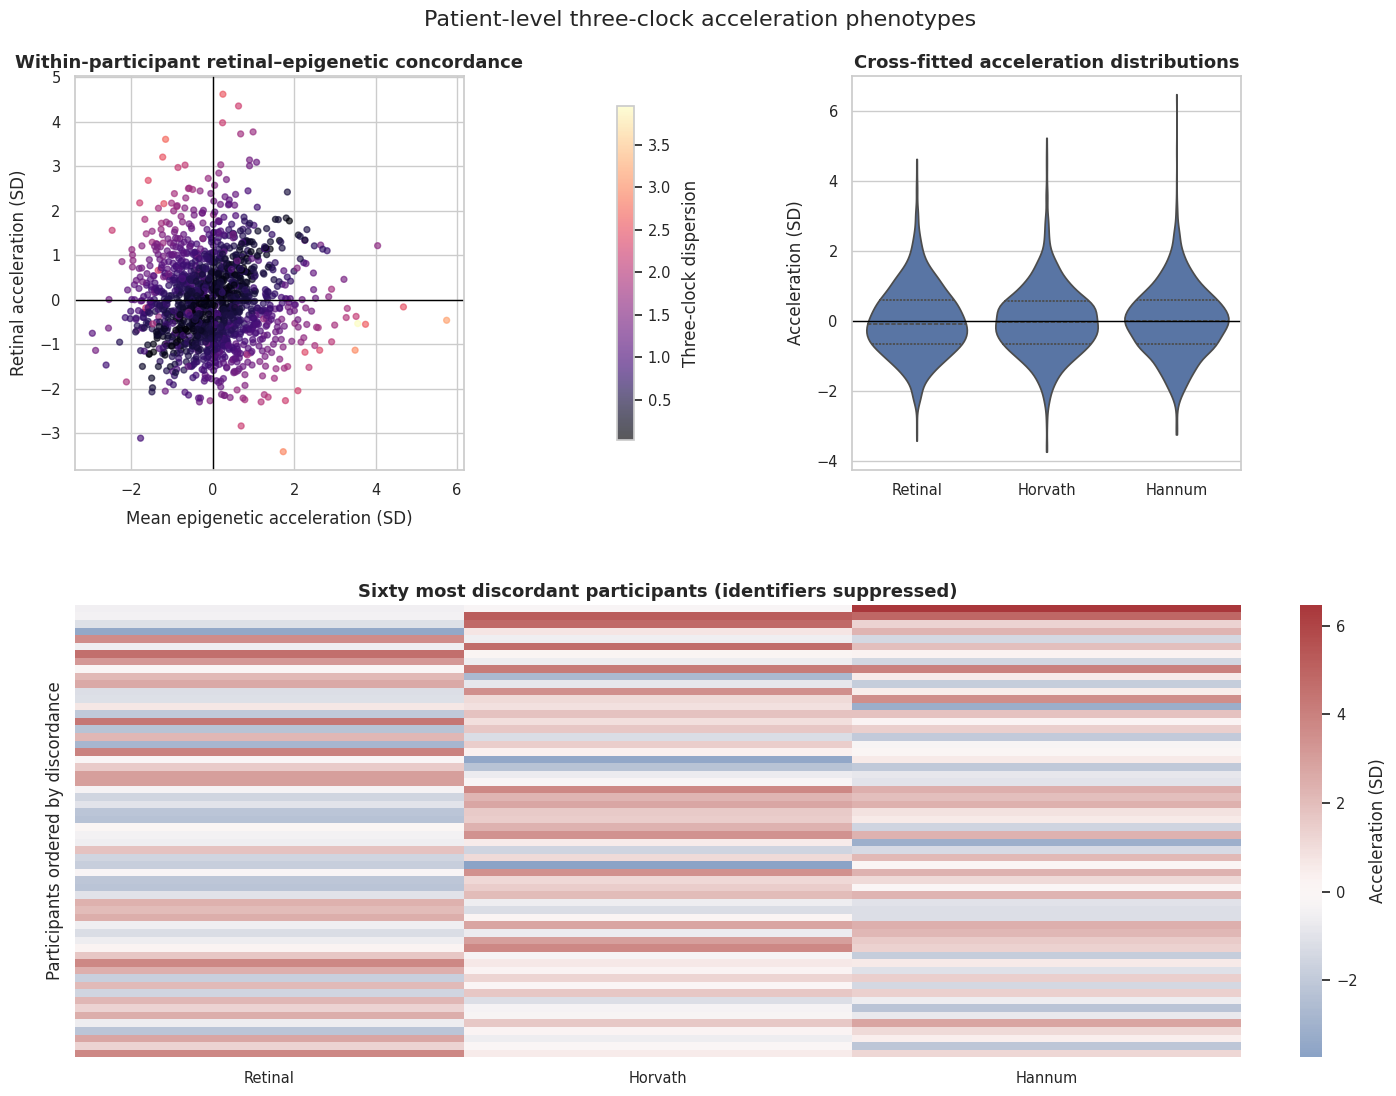

In [0]:
tri_age = master.dropna(
    subset=[
        "participant_id",
        "chronological_age",
        "retinal_age_oof",
        "epigenetic_dnam_age",
        "epigenetic_hannum_age",
    ]
).copy()
if tri_age["participant_id"].duplicated().any():
    raise ValueError("Three-clock cohort must be participant-unique")

clock_definitions = {
    "retinal": "retinal_age_oof",
    "horvath": "epigenetic_dnam_age",
    "hannum": "epigenetic_hannum_age",
}
for clock_name, estimate_column in clock_definitions.items():
    residual, expected = cross_fitted_spline_residual(
        tri_age,
        estimate_column,
        "chronological_age",
        "participant_id",
    )
    tri_age[f"{clock_name}_age_expected_cf"] = expected
    tri_age[f"{clock_name}_acceleration_cf"] = residual
    tri_age[f"z_{clock_name}_acceleration"] = safe_zscore(
        residual
    )

acceleration_columns = [
    "z_retinal_acceleration",
    "z_horvath_acceleration",
    "z_hannum_acceleration",
]
tri_age["epigenetic_mean_acceleration"] = tri_age[
    ["z_horvath_acceleration", "z_hannum_acceleration"]
].mean(axis=1)
tri_age["z_epigenetic_mean_acceleration"] = safe_zscore(
    tri_age["epigenetic_mean_acceleration"]
)
tri_age["shared_acceleration_mean"] = tri_age[
    acceleration_columns
].mean(axis=1)
tri_age["z_shared_acceleration_mean"] = safe_zscore(
    tri_age["shared_acceleration_mean"]
)
tri_age["retina_specific_discordance"] = safe_zscore(
    tri_age["z_retinal_acceleration"]
    - tri_age["epigenetic_mean_acceleration"]
)
tri_age["epigenetic_specific_discordance"] = (
    -tri_age["retina_specific_discordance"]
)
tri_age["three_clock_dispersion"] = tri_age[
    acceleration_columns
].std(axis=1, ddof=1)
tri_age["z_three_clock_dispersion"] = safe_zscore(
    tri_age["three_clock_dispersion"]
)
tri_age["horvath_hannum_discordance"] = safe_zscore(
    tri_age["z_horvath_acceleration"]
    - tri_age["z_hannum_acceleration"]
)

acceleration_matrix = tri_age[
    acceleration_columns
].to_numpy(float)
pca = PCA(n_components=3, random_state=random_state)
raw_scores = pca.fit_transform(acceleration_matrix)
oriented_loadings = pca.components_.copy()
score_signs = np.ones(3)

shared_index = int(
    np.argmax(np.abs(oriented_loadings.sum(axis=1)))
)
if oriented_loadings[shared_index].mean() < 0:
    score_signs[shared_index] = -1
remaining = [index for index in range(3) if index != shared_index]
retina_index = max(
    remaining,
    key=lambda index: abs(
        oriented_loadings[index, 0]
        - oriented_loadings[index, 1:].mean()
    ),
)
if (
    oriented_loadings[retina_index, 0]
    - oriented_loadings[retina_index, 1:].mean()
) < 0:
    score_signs[retina_index] = -1
epigenetic_index = next(
    index
    for index in range(3)
    if index not in {shared_index, retina_index}
)
if (
    oriented_loadings[epigenetic_index, 1]
    - oriented_loadings[epigenetic_index, 2]
) < 0:
    score_signs[epigenetic_index] = -1

oriented_loadings = oriented_loadings * score_signs[:, None]
oriented_scores = raw_scores * score_signs[None, :]
component_roles = {
    "shared_aging_pc": shared_index,
    "retina_vs_epigenetic_pc": retina_index,
    "horvath_vs_hannum_pc": epigenetic_index,
}
for role, component_index in component_roles.items():
    tri_age[role] = safe_zscore(
        pd.Series(
            oriented_scores[:, component_index],
            index=tri_age.index,
        )
    )

pca_rows = []
for role, component_index in component_roles.items():
    pca_rows.append(
        {
            "component_role": role,
            "original_component_number": component_index + 1,
            "explained_variance_ratio": float(
                pca.explained_variance_ratio_[component_index]
            ),
            **{
                f"loading_{name}": float(
                    oriented_loadings[component_index, position]
                )
                for position, name in enumerate(
                    ("retinal", "horvath", "hannum")
                )
            },
        }
    )
pca_loadings = pd.DataFrame(pca_rows)
write_frame(
    pca_loadings,
    statistics_root / "three_clock_pca_loadings.csv",
)

low_thresholds = tri_age[
    acceleration_columns
].quantile(1 - acceleration_extreme_quantile)
high_thresholds = tri_age[
    acceleration_columns
].quantile(acceleration_extreme_quantile)
retinal_high = (
    tri_age["z_retinal_acceleration"]
    >= high_thresholds["z_retinal_acceleration"]
)
retinal_low = (
    tri_age["z_retinal_acceleration"]
    <= low_thresholds["z_retinal_acceleration"]
)
epigenetic_high = (
    tri_age["z_horvath_acceleration"]
    >= high_thresholds["z_horvath_acceleration"]
) & (
    tri_age["z_hannum_acceleration"]
    >= high_thresholds["z_hannum_acceleration"]
)
epigenetic_low = (
    tri_age["z_horvath_acceleration"]
    <= low_thresholds["z_horvath_acceleration"]
) & (
    tri_age["z_hannum_acceleration"]
    <= low_thresholds["z_hannum_acceleration"]
)
tri_age["three_clock_profile"] = np.select(
    [
        retinal_high & epigenetic_high,
        retinal_low & epigenetic_low,
        retinal_high & ~epigenetic_high,
        ~retinal_high & epigenetic_high,
    ],
    [
        "Concordantly accelerated",
        "Concordantly decelerated",
        "Retina-only accelerated",
        "Epigenetic-only accelerated",
    ],
    default="Mixed or intermediate",
)

COMORBIDITY_LABELS = {
    "diabetes": "Diabetes",
    "hypertension": "Hypertension",
    "heart_disease": "Heart disease",
    "stroke": "Stroke",
    "kidney_disease": "Kidney disease",
    "chronic_kidney_disease": "Chronic kidney disease",
    "arthritis_any": "Arthritis",
    "osteoporosis": "Osteoporosis",
    "asthma_or_copd": "Asthma or COPD",
    "cancer": "Cancer",
    "low_back_pain": "Low back pain",
}
available_binary_comorbidities = {}
binary_columns = []
for source_column, label in COMORBIDITY_LABELS.items():
    if source_column not in tri_age.columns:
        continue
    binary_column = f"{source_column}_binary"
    tri_age[binary_column] = coerce_binary(
        tri_age[source_column]
    )
    if tri_age[binary_column].notna().sum() == 0:
        continue
    available_binary_comorbidities[binary_column] = label
    binary_columns.append(binary_column)
tri_age["comorbidity_observed_count"] = tri_age[
    binary_columns
].notna().sum(axis=1)
tri_age["comorbidity_burden"] = tri_age[
    binary_columns
].sum(axis=1, min_count=1)
tri_age["comorbidity_fraction"] = (
    tri_age["comorbidity_burden"]
    / tri_age["comorbidity_observed_count"].replace(0, np.nan)
)

dispersion_cutoff = tri_age[
    "three_clock_dispersion"
].quantile(0.95)
retina_specific_low = tri_age[
    "retina_specific_discordance"
].quantile(0.05)
retina_specific_high = tri_age[
    "retina_specific_discordance"
].quantile(0.95)
tri_age["extreme_discordance_group"] = np.select(
    [
        tri_age["three_clock_dispersion"] >= dispersion_cutoff,
        tri_age["retina_specific_discordance"]
        <= retina_specific_low,
        tri_age["retina_specific_discordance"]
        >= retina_specific_high,
    ],
    [
        "Highest 5% overall disagreement",
        "Retina younger than epigenetic clocks",
        "Retina older than epigenetic clocks",
    ],
    default="Not extreme",
)
write_frame(
    tri_age,
    private_root / "patient_three_clock_phenotypes_private.parquet",
)
write_frame(
    tri_age[
        tri_age["extreme_discordance_group"].ne("Not extreme")
    ],
    private_root
    / "extreme_discordance_explainability_cohort_private.parquet",
)
profile_summary = (
    tri_age.groupby("three_clock_profile", as_index=False)
    .agg(
        participants=("participant_id", "nunique"),
        mean_shared_acceleration=("shared_acceleration_mean", "mean"),
        mean_retina_specific=(
            "retina_specific_discordance",
            "mean",
        ),
        mean_clock_dispersion=("three_clock_dispersion", "mean"),
        mean_comorbidity_burden=("comorbidity_burden", "mean"),
    )
)
profile_comorbidity_rows = []
for outcome_column, outcome_label in (
    available_binary_comorbidities.items()
):
    for profile, subset in tri_age.groupby(
        "three_clock_profile"
    ):
        observed = subset[outcome_column].dropna()
        if observed.empty:
            continue
        profile_comorbidity_rows.append(
            {
                "three_clock_profile": profile,
                "outcome": outcome_column,
                "outcome_label": outcome_label,
                "n_observed": int(len(observed)),
                "events": int(observed.eq(1).sum()),
                "prevalence": float(observed.mean()),
            }
        )
profile_comorbidity_summary = pd.DataFrame(
    profile_comorbidity_rows
)
write_frame(
    profile_summary,
    statistics_root / "three_clock_profile_summary.csv",
)
write_frame(
    profile_comorbidity_summary,
    statistics_root
    / "three_clock_profile_comorbidity_prevalence.csv",
)
display(pca_loadings.round(4))
display(profile_summary.round(4))

figure = plt.figure(figsize=(14, 11), layout="constrained")
grid = figure.add_gridspec(2, 2, height_ratios=[1, 1.15])
scatter_axis = figure.add_subplot(grid[0, 0])
violin_axis = figure.add_subplot(grid[0, 1])
heatmap_axis = figure.add_subplot(grid[1, :])

scatter = scatter_axis.scatter(
    tri_age["z_epigenetic_mean_acceleration"],
    tri_age["z_retinal_acceleration"],
    c=tri_age["three_clock_dispersion"],
    cmap="magma",
    s=18,
    alpha=0.65,
)
scatter_axis.axhline(0, color="black", linewidth=1)
scatter_axis.axvline(0, color="black", linewidth=1)
scatter_axis.set(
    title="Within-participant retinal–epigenetic concordance",
    xlabel="Mean epigenetic acceleration (SD)",
    ylabel="Retinal acceleration (SD)",
)
figure.colorbar(
    scatter,
    ax=scatter_axis,
    label="Three-clock dispersion",
    shrink=0.85,
)

acceleration_long = tri_age[
    acceleration_columns
].rename(
    columns={
        "z_retinal_acceleration": "Retinal",
        "z_horvath_acceleration": "Horvath",
        "z_hannum_acceleration": "Hannum",
    }
).melt(var_name="Clock", value_name="Acceleration")
sns.violinplot(
    data=acceleration_long,
    x="Clock",
    y="Acceleration",
    inner="quartile",
    cut=0,
    ax=violin_axis,
)
violin_axis.axhline(0, color="black", linewidth=1)
violin_axis.set(
    title="Cross-fitted acceleration distributions",
    xlabel="",
    ylabel="Acceleration (SD)",
)

heatmap_data = (
    tri_age.nlargest(60, "three_clock_dispersion")[
        acceleration_columns
    ]
    .rename(
        columns={
            "z_retinal_acceleration": "Retinal",
            "z_horvath_acceleration": "Horvath",
            "z_hannum_acceleration": "Hannum",
        }
    )
    .apply(pd.to_numeric, errors="coerce")
    .astype("float64")
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=0, how="any")
    .reset_index(drop=True)
)
if not heatmap_data.empty:
    sns.heatmap(
        heatmap_data.to_numpy(dtype=float),
        cmap="vlag",
        center=0,
        yticklabels=False,
        xticklabels=heatmap_data.columns.tolist(),
        ax=heatmap_axis,
        cbar_kws={"label": "Acceleration (SD)"},
    )
    heatmap_axis.set(
        title=(
            "Sixty most discordant participants "
            "(identifiers suppressed)"
        ),
        xlabel="",
        ylabel="Participants ordered by discordance",
    )
else:
    heatmap_axis.text(
        0.5,
        0.5,
        "No complete numeric acceleration records available",
        ha="center",
        va="center",
        transform=heatmap_axis.transAxes,
    )
    heatmap_axis.set_axis_off()
figure.suptitle(
    "Patient-level three-clock acceleration phenotypes",
)
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_7_patient_three_clock_phenotypes.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()
plt.close(figure)

## 12. Comorbidity associations and unique clock information

Binary diseases are treated as outcomes. The primary mutually adjusted
model includes retinal and mean epigenetic acceleration together, while
an orthogonal PCA model separates shared aging, retina-versus-epigenetic
discordance, and Horvath-versus-Hannum discordance. Associations are
cross-sectional and cannot establish causation.

outcome,outcome_label,framework,predictor,n,events,log_odds_coefficient,odds_ratio,ci_low,ci_high,p_value,fdr_q_value,significant_fdr_0_05
diabetes_binary,Diabetes,mutually_adjusted_clocks,z_retinal_acceleration,1403,239,0.18669,1.20525,1.04464,1.39054,0.01051,0.20174,false
diabetes_binary,Diabetes,mutually_adjusted_clocks,z_epigenetic_mean_acceleration,1403,239,0.0526,1.05401,0.91993,1.20763,0.4486,0.84301,false
diabetes_binary,Diabetes,orthogonal_three_clock_components,shared_aging_pc,1403,239,0.05915,1.06093,0.92618,1.21529,0.39343,0.76558,false
diabetes_binary,Diabetes,orthogonal_three_clock_components,retina_vs_epigenetic_pc,1403,239,0.18555,1.20388,1.04306,1.38951,0.01121,0.20174,false
diabetes_binary,Diabetes,orthogonal_three_clock_components,horvath_vs_hannum_pc,1403,239,-0.0194,0.98079,0.84667,1.13615,0.79597,0.95659,false
diabetes_binary,Diabetes,direct_clock_discordance,z_shared_acceleration_mean,1403,239,0.17208,1.18778,1.03363,1.36492,0.01525,0.21967,false
diabetes_binary,Diabetes,direct_clock_discordance,retina_specific_discordance,1403,239,0.13852,1.14858,0.9878,1.33553,0.0718,0.29947,false
diabetes_binary,Diabetes,direct_clock_discordance,horvath_hannum_discordance,1403,239,-0.01852,0.98165,0.8458,1.13932,0.80748,0.95659,false
diabetes_binary,Diabetes,direct_clock_discordance,z_three_clock_dispersion,1403,239,-0.02389,0.97639,0.8459,1.127,0.74409,0.95659,false
hypertension_binary,Hypertension,mutually_adjusted_clocks,z_retinal_acceleration,1401,554,0.03021,1.03067,0.92004,1.15461,0.60203,0.92939,false


framework,predictor,n,rate_ratio,ci_low,ci_high,p_value,fdr_q_value
mutually_adjusted_clocks,z_retinal_acceleration,1405,1.05764,1.01678,1.10014,0.00531,0.01524
mutually_adjusted_clocks,z_epigenetic_mean_acceleration,1405,1.05518,1.0135,1.09858,0.009,0.0162
orthogonal_three_clock_components,shared_aging_pc,1405,1.05716,1.01547,1.10057,0.00677,0.01524
orthogonal_three_clock_components,retina_vs_epigenetic_pc,1405,1.05637,1.0155,1.09888,0.00644,0.01524
orthogonal_three_clock_components,horvath_vs_hannum_pc,1405,1.00104,0.96153,1.04216,0.95974,0.95974
direct_clock_discordance,z_shared_acceleration_mean,1405,1.08835,1.04557,1.13289,4.0E-5,3.2E-4
direct_clock_discordance,retina_specific_discordance,1405,1.02292,0.98116,1.06647,0.28664,0.36853
direct_clock_discordance,horvath_hannum_discordance,1405,1.0021,0.9627,1.0431,0.91853,0.95974
direct_clock_discordance,z_three_clock_dispersion,1405,0.97068,0.93214,1.01082,0.1501,0.22515


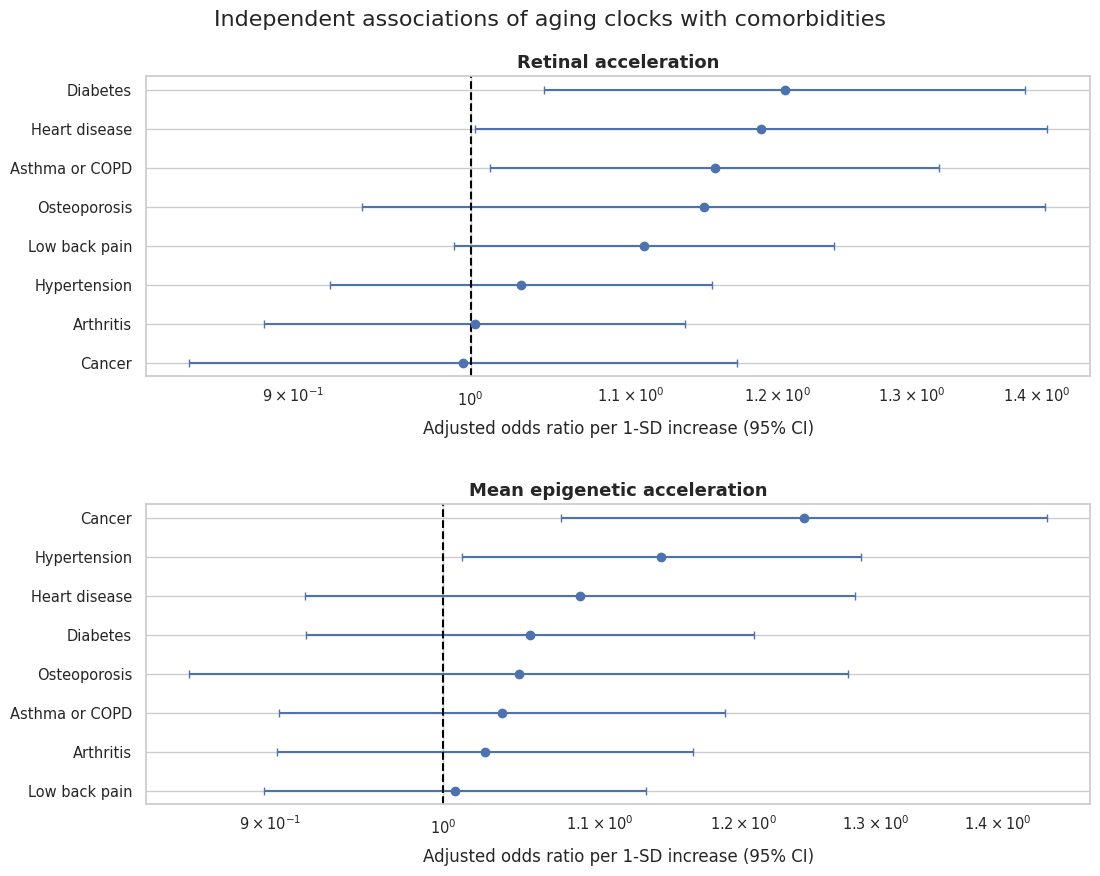

In [0]:
association_covariate_terms = [
    "chronological_age",
    "chronological_age_sq",
]
tri_age["chronological_age_sq"] = tri_age[
    "chronological_age"
] ** 2
tri_age["log_n_embedded_images"] = np.log1p(
    pd.to_numeric(
        tri_age["n_embedded_images"],
        errors="coerce",
    ).fillna(0)
)
association_covariate_terms.append("log_n_embedded_images")
association_categorical_columns = []
for categorical in (
    "sex_labeled",
    "racial_background",
    "smoking_status",
):
    if categorical not in tri_age.columns:
        continue
    counts = tri_age[categorical].value_counts(dropna=True)
    if len(counts) < 2:
        continue
    frequent = counts[counts >= minimum_reporting_group_n].index
    model_column = f"{categorical}_association"
    category_source = tri_age[categorical].astype("string")
    tri_age[model_column] = (
        category_source
        .where(
            category_source.isna()
            | category_source.isin(frequent.astype(str)),
            "Other/low-frequency",
        )
        .fillna("Missing")
        .astype(str)
    )
    tri_age[model_column] = pd.Categorical(
        tri_age[model_column]
    )
    association_categorical_columns.append(model_column)
    association_covariate_terms.append(f"C({model_column})")

for continuous in ("bmi", "body_mass_index"):
    if continuous in tri_age.columns:
        tri_age[continuous] = pd.to_numeric(
            tri_age[continuous], errors="coerce"
        )
        if tri_age[continuous].notna().sum() >= 100:
            association_covariate_terms.append(continuous)
            break

clock_predictor_sets = {
    "mutually_adjusted_clocks": [
        "z_retinal_acceleration",
        "z_epigenetic_mean_acceleration",
    ],
    "orthogonal_three_clock_components": [
        "shared_aging_pc",
        "retina_vs_epigenetic_pc",
        "horvath_vs_hannum_pc",
    ],
    "direct_clock_discordance": [
        "z_shared_acceleration_mean",
        "retina_specific_discordance",
        "horvath_hannum_discordance",
        "z_three_clock_dispersion",
    ],
}
association_rows = []
association_contrasts = []
association_failures = []
for outcome_index, (
    outcome_column,
    outcome_label,
) in enumerate(available_binary_comorbidities.items()):
    outcome = pd.to_numeric(
        tri_age[outcome_column], errors="coerce"
    )
    event_count = int(outcome.eq(1).sum())
    nonevent_count = int(outcome.eq(0).sum())
    if min(event_count, nonevent_count) < minimum_binary_outcome_events:
        association_failures.append(
            {
                "outcome": outcome_column,
                "outcome_label": outcome_label,
                "status": "skipped_insufficient_events",
                "events": event_count,
                "non_events": nonevent_count,
            }
        )
        continue
    for framework, predictors in clock_predictor_sets.items():
        formula = (
            f"{outcome_column} ~ "
            + " + ".join(
                [*association_covariate_terms, *predictors]
            )
        )
        try:
            fit = smf.glm(
                formula,
                data=tri_age,
                family=sm.families.Binomial(),
                missing="drop",
            ).fit(cov_type="HC3")
            confidence = fit.conf_int()
            for predictor in predictors:
                association_rows.append(
                    {
                        "outcome": outcome_column,
                        "outcome_label": outcome_label,
                        "framework": framework,
                        "predictor": predictor,
                        "n": int(fit.nobs),
                        "events": event_count,
                        "log_odds_coefficient": float(
                            fit.params[predictor]
                        ),
                        "odds_ratio": float(
                            np.exp(fit.params[predictor])
                        ),
                        "ci_low": float(
                            np.exp(confidence.loc[predictor, 0])
                        ),
                        "ci_high": float(
                            np.exp(confidence.loc[predictor, 1])
                        ),
                        "p_value": float(
                            fit.pvalues[predictor]
                        ),
                    }
                )
            if framework == "mutually_adjusted_clocks":
                contrast = fit.t_test(
                    "z_retinal_acceleration "
                    "- z_epigenetic_mean_acceleration = 0"
                )
                association_contrasts.append(
                    {
                        "outcome": outcome_column,
                        "outcome_label": outcome_label,
                        "n": int(fit.nobs),
                        "events": event_count,
                        "retinal_minus_epigenetic_log_odds": float(
                            np.asarray(contrast.effect).reshape(-1)[0]
                        ),
                        "p_value": float(contrast.pvalue),
                    }
                )
        except Exception as error:
            association_failures.append(
                {
                    "outcome": outcome_column,
                    "outcome_label": outcome_label,
                    "framework": framework,
                    "status": f"failed:{type(error).__name__}",
                    "error_message": str(error)[:500],
                    "events": event_count,
                    "non_events": nonevent_count,
                }
            )

comorbidity_associations = pd.DataFrame(association_rows)
comorbidity_clock_contrasts = pd.DataFrame(
    association_contrasts
)
comorbidity_association_failures = pd.DataFrame(
    association_failures
)
if not comorbidity_associations.empty:
    comorbidity_associations["fdr_q_value"] = (
        benjamini_hochberg(
            comorbidity_associations["p_value"].to_numpy(float)
        )
    )
    comorbidity_associations["significant_fdr_0_05"] = (
        comorbidity_associations["fdr_q_value"] < 0.05
    )
if not comorbidity_clock_contrasts.empty:
    comorbidity_clock_contrasts["fdr_q_value"] = (
        benjamini_hochberg(
            comorbidity_clock_contrasts[
                "p_value"
            ].to_numpy(float)
        )
    )

multimorbidity_rows = []
if tri_age["comorbidity_burden"].notna().sum() >= 100:
    for framework, predictors in clock_predictor_sets.items():
        formula = (
            "comorbidity_burden ~ "
            + " + ".join(
                [*association_covariate_terms, *predictors]
            )
        )
        try:
            fit = smf.glm(
                formula,
                data=tri_age,
                family=sm.families.NegativeBinomial(alpha=1.0),
                missing="drop",
            ).fit(cov_type="HC3")
            confidence = fit.conf_int()
            for predictor in predictors:
                multimorbidity_rows.append(
                    {
                        "framework": framework,
                        "predictor": predictor,
                        "n": int(fit.nobs),
                        "rate_ratio": float(
                            np.exp(fit.params[predictor])
                        ),
                        "ci_low": float(
                            np.exp(confidence.loc[predictor, 0])
                        ),
                        "ci_high": float(
                            np.exp(confidence.loc[predictor, 1])
                        ),
                        "p_value": float(
                            fit.pvalues[predictor]
                        ),
                    }
                )
        except Exception as error:
            association_failures.append(
                {
                    "outcome": "comorbidity_burden",
                    "outcome_label": "Comorbidity burden",
                    "framework": framework,
                    "status": f"failed:{type(error).__name__}",
                    "error_message": str(error)[:500],
                }
            )
multimorbidity_associations = pd.DataFrame(multimorbidity_rows)
if not multimorbidity_associations.empty:
    multimorbidity_associations["fdr_q_value"] = (
        benjamini_hochberg(
            multimorbidity_associations[
                "p_value"
            ].to_numpy(float)
        )
    )

write_frame(
    comorbidity_associations,
    statistics_root / "patient_clock_comorbidity_associations.csv",
)
write_frame(
    comorbidity_clock_contrasts,
    statistics_root / "retinal_vs_epigenetic_effect_contrasts.csv",
)
write_frame(
    pd.DataFrame(association_failures),
    statistics_root / "comorbidity_association_failures.csv",
)
write_frame(
    multimorbidity_associations,
    statistics_root / "multimorbidity_clock_associations.csv",
)
display(comorbidity_associations.round(5))
display(multimorbidity_associations.round(5))

if not comorbidity_associations.empty:
    forest_data = comorbidity_associations[
        comorbidity_associations["framework"].eq(
            "mutually_adjusted_clocks"
        )
    ].copy()
    figure, axes = plt.subplots(
        2,
        1,
        figsize=(11, max(8, 0.55 * len(forest_data))),
        layout="constrained",
    )
    predictor_labels = {
        "z_retinal_acceleration": "Retinal acceleration",
        "z_epigenetic_mean_acceleration": (
            "Mean epigenetic acceleration"
        ),
    }
    for axis, predictor in zip(
        axes,
        predictor_labels,
    ):
        plot = forest_data[
            forest_data["predictor"].eq(predictor)
        ].sort_values("odds_ratio")
        point = plot["odds_ratio"].to_numpy(float)
        low = plot["ci_low"].to_numpy(float)
        high = plot["ci_high"].to_numpy(float)
        error = np.vstack(
            [
                np.maximum(point - low, 0),
                np.maximum(high - point, 0),
            ]
        )
        positions = np.arange(len(plot))
        colors = np.where(
            plot["significant_fdr_0_05"],
            "#C44E52",
            "#4C72B0",
        )
        for position, estimate, interval, color in zip(
            positions,
            point,
            error.T,
            colors,
        ):
            axis.errorbar(
                estimate,
                position,
                xerr=interval.reshape(2, 1),
                fmt="o",
                color=color,
                capsize=3,
            )
        axis.axvline(1, color="black", linestyle="--")
        axis.set_xscale("log")
        axis.set_yticks(
            positions,
            plot["outcome_label"],
        )
        axis.set(
            title=predictor_labels[predictor],
            xlabel="Adjusted odds ratio per 1-SD increase (95% CI)",
            ylabel="",
        )
    figure.suptitle(
        "Independent associations of aging clocks with comorbidities",
    )
    prepare_publication_figure(figure)
    figure.savefig(
        figure_root
        / "figure_8_clock_comorbidity_association_forest.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.25,
    )
    plt.show()
    plt.close(figure)

## 13. Incremental disease-prediction value

Five-fold stratified out-of-fold predictions compare chronological and
demographic covariates alone with retinal, epigenetic, combined, and
orthogonal three-clock models. This evaluates incremental information
without reporting optimistic in-sample AUC.

outcome,outcome_label,model,n,events,oof_auc,oof_brier,delta_auc_vs_base,delta_auc_ci_low,delta_auc_ci_high,brier_improvement_vs_base,brier_improvement_ci_low,brier_improvement_ci_high
diabetes_binary,Diabetes,base,1403,239,0.63282,0.13739,null,null,null,null,null,null
diabetes_binary,Diabetes,base_plus_retinal,1403,239,0.63772,0.13689,null,null,null,null,null,null
diabetes_binary,Diabetes,base_plus_epigenetic,1403,239,0.62947,0.13756,null,null,null,null,null,null
diabetes_binary,Diabetes,base_plus_both,1403,239,0.63501,0.13708,null,null,null,null,null,null
diabetes_binary,Diabetes,base_plus_orthogonal_components,1403,239,0.62802,0.13793,null,null,null,null,null,null
diabetes_binary,Diabetes,base_plus_direct_discordance,1403,239,0.62554,0.13816,null,null,null,null,null,null
diabetes_binary,Diabetes,base_plus_retinal_increment_vs_base,1403,239,0.63772,null,0.00491,-0.00848,0.01723,5.0E-4,-5.2E-4,0.0015
diabetes_binary,Diabetes,base_plus_epigenetic_increment_vs_base,1403,239,0.62947,null,-0.00335,-0.00933,0.00218,-1.7E-4,-6.4E-4,3.3E-4
diabetes_binary,Diabetes,base_plus_both_increment_vs_base,1403,239,0.63501,null,0.00219,-0.0128,0.01596,3.1E-4,-0.001,0.0015
diabetes_binary,Diabetes,base_plus_orthogonal_components_increment_vs_base,1403,239,0.62802,null,-0.0048,-0.01999,0.00898,-5.4E-4,-0.00197,7.9E-4


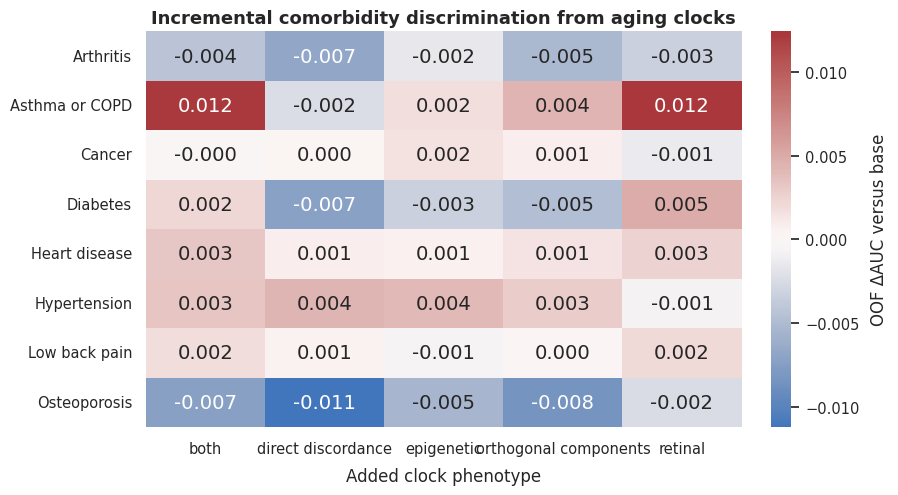

In [0]:
prediction_continuous_base = [
    "chronological_age",
    "chronological_age_sq",
    "log_n_embedded_images",
]
prediction_categorical_base = association_categorical_columns
prediction_model_sets = {
    "base": [],
    "base_plus_retinal": ["z_retinal_acceleration"],
    "base_plus_epigenetic": [
        "z_epigenetic_mean_acceleration"
    ],
    "base_plus_both": [
        "z_retinal_acceleration",
        "z_epigenetic_mean_acceleration",
    ],
    "base_plus_orthogonal_components": [
        "shared_aging_pc",
        "retina_vs_epigenetic_pc",
        "horvath_vs_hannum_pc",
    ],
    "base_plus_direct_discordance": [
        "z_shared_acceleration_mean",
        "retina_specific_discordance",
        "horvath_hannum_discordance",
        "z_three_clock_dispersion",
    ],
}

def cross_validated_binary_prediction(
    frame,
    outcome_column,
    additional_continuous,
    seed,
):
    continuous = [
        *prediction_continuous_base,
        *additional_continuous,
    ]
    columns = [
        outcome_column,
        *continuous,
        *prediction_categorical_base,
    ]
    work = frame[columns].copy()
    work[outcome_column] = pd.to_numeric(
        work[outcome_column], errors="coerce"
    )
    work = work.dropna(subset=[outcome_column])
    outcome = work[outcome_column].astype(int).to_numpy()
    event_count = int(outcome.sum())
    nonevent_count = int(len(outcome) - event_count)
    splits = min(5, event_count, nonevent_count)
    if splits < 2:
        raise ValueError("Insufficient events for stratified CV")
    transformers = [
        (
            "continuous",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            continuous,
        )
    ]
    if prediction_categorical_base:
        transformers.append(
            (
                "categorical",
                Pipeline(
                    [
                        (
                            "impute",
                            SimpleImputer(
                                strategy="most_frequent"
                            ),
                        ),
                        (
                            "one_hot",
                            OneHotEncoder(
                                handle_unknown="ignore"
                            ),
                        ),
                    ]
                ),
                prediction_categorical_base,
            )
        )
    estimator = Pipeline(
        [
            (
                "preprocess",
                ColumnTransformer(transformers),
            ),
            (
                "logistic",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="liblinear",
                    max_iter=2000,
                    random_state=seed,
                ),
            ),
        ]
    )
    splitter = StratifiedKFold(
        n_splits=splits,
        shuffle=True,
        random_state=seed,
    )
    prediction = cross_val_predict(
        estimator,
        work.drop(columns=[outcome_column]),
        outcome,
        cv=splitter,
        method="predict_proba",
    )[:, 1]
    return work.index, outcome, prediction

predictive_metric_rows = []
predictive_prediction_frames = []
for outcome_index, (
    outcome_column,
    outcome_label,
) in enumerate(available_binary_comorbidities.items()):
    outcome = pd.to_numeric(
        tri_age[outcome_column], errors="coerce"
    )
    if min(
        int(outcome.eq(1).sum()),
        int(outcome.eq(0).sum()),
    ) < minimum_binary_outcome_events:
        continue
    model_predictions = {}
    common_index = None
    common_outcome = None
    for model_index, (
        model_name,
        added_predictors,
    ) in enumerate(prediction_model_sets.items()):
        index, y, prediction = cross_validated_binary_prediction(
            tri_age,
            outcome_column,
            added_predictors,
            random_state + 100 * outcome_index,
        )
        if common_index is None:
            common_index = index
            common_outcome = y
        elif not index.equals(common_index):
            raise RuntimeError(
                "Nested prediction models used different participants"
            )
        model_predictions[model_name] = prediction
        predictive_metric_rows.append(
            {
                "outcome": outcome_column,
                "outcome_label": outcome_label,
                "model": model_name,
                "n": int(len(y)),
                "events": int(y.sum()),
                "oof_auc": float(roc_auc_score(y, prediction)),
                "oof_brier": float(
                    brier_score_loss(y, prediction)
                ),
            }
        )
    base_prediction = model_predictions["base"]
    for model_index, (
        model_name,
        prediction,
    ) in enumerate(model_predictions.items()):
        if model_name == "base":
            continue
        auc_low, auc_high = bootstrap_metric_difference(
            common_outcome,
            prediction,
            base_prediction,
            roc_auc_score,
            prediction_bootstrap_repetitions,
            random_state
            + 10000
            + 100 * outcome_index
            + model_index,
        )
        brier_low, brier_high = bootstrap_metric_difference(
            common_outcome,
            prediction,
            base_prediction,
            lambda observed, predicted: -brier_score_loss(
                observed, predicted
            ),
            prediction_bootstrap_repetitions,
            random_state
            + 20000
            + 100 * outcome_index
            + model_index,
        )
        predictive_metric_rows.append(
            {
                "outcome": outcome_column,
                "outcome_label": outcome_label,
                "model": f"{model_name}_increment_vs_base",
                "n": int(len(common_outcome)),
                "events": int(common_outcome.sum()),
                "oof_auc": float(
                    roc_auc_score(
                        common_outcome,
                        prediction,
                    )
                ),
                "delta_auc_vs_base": float(
                    roc_auc_score(
                        common_outcome,
                        prediction,
                    )
                    - roc_auc_score(
                        common_outcome,
                        base_prediction,
                    )
                ),
                "delta_auc_ci_low": auc_low,
                "delta_auc_ci_high": auc_high,
                "brier_improvement_vs_base": float(
                    brier_score_loss(
                        common_outcome,
                        base_prediction,
                    )
                    - brier_score_loss(
                        common_outcome,
                        prediction,
                    )
                ),
                "brier_improvement_ci_low": brier_low,
                "brier_improvement_ci_high": brier_high,
            }
        )
    predictive_prediction_frames.append(
        pd.DataFrame(
            {
                "participant_id": tri_age.loc[
                    common_index,
                    "participant_id",
                ].astype(str).to_numpy(),
                "outcome": outcome_column,
                "observed": common_outcome,
                **model_predictions,
            }
        )
    )

predictive_metrics = pd.DataFrame(predictive_metric_rows)
predictive_predictions = (
    pd.concat(
        predictive_prediction_frames,
        ignore_index=True,
    )
    if predictive_prediction_frames
    else pd.DataFrame()
)
write_frame(
    predictive_metrics,
    statistics_root
    / "comorbidity_incremental_prediction_metrics.csv",
)
write_frame(
    predictive_predictions,
    private_root
    / "comorbidity_oof_predictions_private.parquet",
)
display(predictive_metrics.round(5))

increment_plot = (
    predictive_metrics[
        predictive_metrics["model"].str.endswith(
            "_increment_vs_base",
            na=False,
        )
    ].copy()
    if not predictive_metrics.empty
    else pd.DataFrame()
)
if not increment_plot.empty:
    increment_plot["model"] = (
        increment_plot["model"]
        .str.replace("_increment_vs_base", "", regex=False)
        .str.replace("base_plus_", "", regex=False)
        .str.replace("_", " ")
    )
    heatmap = increment_plot.pivot(
        index="outcome_label",
        columns="model",
        values="delta_auc_vs_base",
    )
    figure, axis = plt.subplots(
        figsize=(
            max(9, 1.8 * heatmap.shape[1]),
            max(5, 0.6 * heatmap.shape[0]),
        ),
        layout="constrained",
    )
    sns.heatmap(
        heatmap,
        annot=True,
        fmt=".3f",
        center=0,
        cmap="vlag",
        ax=axis,
        cbar_kws={"label": "OOF ΔAUC versus base"},
    )
    axis.set(
        title="Incremental comorbidity discrimination from aging clocks",
        xlabel="Added clock phenotype",
        ylabel="",
    )
    prepare_publication_figure(figure)
    figure.savefig(
        figure_root
        / "figure_9_comorbidity_incremental_auc.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.25,
    )
    plt.show()
    plt.close(figure)

## 14. Questionnaire-wide phenome scan

Every field in the raw baseline CoPv7_Qx_CANUE_PA_BS questionnaire CSV
is loaded for the three-clock cohort in resumable row batches.
Identifiers, dates, age leakage,
epigenetic variables, demographics already modeled separately, and the
comorbidities analyzed above are retained in the private extract but
excluded from this scan. Numeric questions receive standardized linear
effects; categorical questions receive omnibus nested-model tests.
False-discovery control is applied globally and within each aging
phenotype.

In [0]:
questionnaire_source_columns = [
    column
    for column in baseline_header
    if column != baseline_id_column
]
questionnaire_schema_token = hashlib.sha256(
    (
        source_signature(baseline_archive_path)
        + "|"
        + baseline_member
        + "|"
        + "|".join(questionnaire_source_columns)
    ).encode("utf-8")
).hexdigest()[:12]
questionnaire_batch_root = (
    checkpoint_root
    / "questionnaire_all_baseline_fields"
    / f"schema_{questionnaire_schema_token}"
)
questionnaire_batch_root.mkdir(
    parents=True,
    exist_ok=True,
)
three_clock_participant_ids = (
    tri_age["participant_id"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)
questionnaire_cohort_token = hashlib.sha256(
    "|".join(sorted(three_clock_participant_ids)).encode("utf-8")
).hexdigest()[:12]
questionnaire_batch_root = (
    questionnaire_batch_root
    / f"cohort_{questionnaire_cohort_token}"
)
questionnaire_batch_root.mkdir(
    parents=True,
    exist_ok=True,
)
eligible_questionnaire_ids = set(three_clock_participant_ids)
questionnaire_batches = []
questionnaire_batch_manifest_rows = []
scanned_questionnaire_rows = 0
with zipfile.ZipFile(baseline_archive_path) as archive:
    with archive.open(baseline_member) as stream:
        raw_questionnaire_chunks = pd.read_csv(
            stream,
            dtype="string",
            chunksize=questionnaire_row_chunk_size,
            low_memory=False,
        )
        for batch_number, raw_chunk in enumerate(
            raw_questionnaire_chunks,
            1,
        ):
            start_row = scanned_questionnaire_rows
            scanned_questionnaire_rows += len(raw_chunk)
            stop_row = scanned_questionnaire_rows
            batch_path = (
                questionnaire_batch_root
                / f"rows_{start_row:09d}_{stop_row:09d}.parquet"
            )
            if (
                resume_completed_outputs
                and batch_path.is_file()
            ):
                batch_frame = pd.read_parquet(batch_path)
                status = "resumed"
            else:
                raw_chunk[baseline_id_column] = normalize_identifier(
                    raw_chunk[baseline_id_column]
                )
                batch_frame = raw_chunk[
                    raw_chunk[baseline_id_column].isin(
                        eligible_questionnaire_ids
                    )
                ].copy()
                batch_frame = batch_frame.rename(
                    columns={baseline_id_column: "participant_id"}
                )
                batch_frame.attrs = {}
                write_frame(batch_frame, batch_path)
                status = "written"
            questionnaire_batches.append(batch_frame)
            questionnaire_batch_manifest_rows.append(
                {
                    "batch_number": batch_number,
                    "start_row": start_row,
                    "stop_row": stop_row,
                    "source_rows": int(len(raw_chunk)),
                    "retained_participants": int(
                        batch_frame["participant_id"].nunique()
                    ),
                    "n_questionnaire_fields": int(
                        len(questionnaire_source_columns)
                    ),
                    "path": str(batch_path),
                    "status": status,
                }
            )
            print(
                f"[questionnaire {batch_number}] {status} raw rows "
                f"{start_row:,}:{stop_row:,}; retained "
                f"{batch_frame['participant_id'].nunique():,}",
                flush=True,
            )

matched_questionnaire_rows = (
    pd.concat(questionnaire_batches, ignore_index=True)
    if questionnaire_batches
    else pd.DataFrame(
        columns=["participant_id", *questionnaire_source_columns]
    )
)
if matched_questionnaire_rows["participant_id"].duplicated().any():
    matched_questionnaire_rows = (
        matched_questionnaire_rows.groupby(
            "participant_id",
            as_index=False,
        ).agg(
            {
                column: stable_value
                for column in questionnaire_source_columns
            }
        )
    )
all_questionnaire_answers = tri_age[["participant_id"]].merge(
    matched_questionnaire_rows,
    on="participant_id",
    how="left",
    validate="one_to_one",
)
if all_questionnaire_answers["participant_id"].duplicated().any():
    raise ValueError(
        "Matched all-questionnaire extract is not participant-unique"
    )
write_frame(
    all_questionnaire_answers,
    private_root
    / "all_baseline_questionnaire_answers_private.parquet",
)
questionnaire_batch_manifest = pd.DataFrame(
    questionnaire_batch_manifest_rows
)
write_frame(
    questionnaire_batch_manifest,
    statistics_root / "questionnaire_batch_manifest.csv",
)

questionnaire_missing_codes = {
    *numeric_missing_codes,
    "-77777",
    "-88889",
    "-99998",
    "NA",
    "N/A",
    "NAN",
    "NONE",
    "NULL",
    "MISSING",
    "DON'T KNOW",
    "DO NOT KNOW",
    "REFUSED",
}
questionnaire_reserved_columns = {
    "age_at_fundus_years",
    "sex_at_birth",
    "ethnicity_spirometry",
    "smoking_status",
    "bmi",
    "body_mass_index",
    "multimorbidity_selected_count",
    *COMORBIDITY_LABELS.keys(),
    *EPIGENETIC_SOURCE_VARIABLES.keys(),
    *EPIGENETIC_SOURCE_VARIABLES.values(),
}
questionnaire_explicit_exclusions = {
    "TRA_CMNTY_OT_MCQ",
}
questionnaire_identifier_pattern = re.compile(
    r"(?i)(^|_)(participant|entity|record|subject|person)_?id($|_)"
)
questionnaire_time_pattern = re.compile(
    r"(?i)(^|_)(date|time|timestamp|dob|birth_year|age)($|_)"
)
questionnaire_procedural_pattern = re.compile(
    r"(?i)(^VA_DONE_|COG_REY.*_META_AUDIO_STATUS$)"
)
cataract_status_pattern = re.compile(
    r"(?i)^(ICQ|VIS)_CATRCT(?:_|$)"
)
cataract_construct_pattern = re.compile(
    r"(?i)^(ICQ|VIS)_CATRCT\d*(?:_|$)"
)
visual_acuity_score_pattern = re.compile(
    r"(?i)^VA_ETDRS_(?:BOTH|L|R)(?:_PO)?_NB_COM$"
)
grip_strength_pattern = re.compile(
    r"(?i)^GS_(?:EXAM_(?:MAX|AVG)|TRIAL[123]_MAX)_COM$"
)


def questionnaire_construct_family(variable):
    if cataract_construct_pattern.search(variable):
        return "cataract"
    if visual_acuity_score_pattern.search(variable):
        return "etdrs_visual_acuity"
    if grip_strength_pattern.search(variable):
        return "grip_strength"
    if re.search(r"(?i)^BLD_(?:RBC|HGB|HCT)_COM$", variable):
        return "red_cell_indices"
    if re.search(r"(?i)^DXA_.*BMD_COM$", variable):
        return "dxa_bone_mineral_density"
    return None

questionnaire_audit_rows = []
analyzable_questionnaire = {
    "participant_id": all_questionnaire_answers[
        "participant_id"
    ]
}
questionnaire_variable_types = {}
upper_missing_codes = {
    str(code).upper() for code in questionnaire_missing_codes
}
for variable in questionnaire_source_columns:
    raw = all_questionnaire_answers[variable]
    text_values = raw.astype("string").str.strip()
    missing_mask = (
        text_values.str.upper().isin(upper_missing_codes)
        | text_values.isna()
    )
    cleaned_text = text_values.mask(missing_mask)
    observed_count = int(cleaned_text.notna().sum())
    unique_count = int(cleaned_text.nunique(dropna=True))
    numeric_values = pd.to_numeric(
        cleaned_text,
        errors="coerce",
    )
    numeric_fraction = (
        float(numeric_values.notna().sum() / observed_count)
        if observed_count
        else 0.0
    )
    skip_reason = None
    variable_type = None
    if variable in questionnaire_reserved_columns:
        skip_reason = "already_analyzed_or_adjustment_variable"
    elif variable in questionnaire_explicit_exclusions:
        skip_reason = "explicit_publication_exclusion"
    elif questionnaire_identifier_pattern.search(variable):
        skip_reason = "identifier"
    elif questionnaire_time_pattern.search(variable):
        skip_reason = "age_or_time_leakage"
    elif questionnaire_procedural_pattern.search(variable):
        skip_reason = "procedural_or_recording_metadata"
    elif observed_count < minimum_questionnaire_observed:
        skip_reason = "insufficient_observed_participants"
    elif unique_count < 2:
        skip_reason = "constant"
    elif numeric_fraction >= 0.95 and unique_count > 10:
        variable_type = "numeric"
        analyzable_questionnaire[variable] = numeric_values
    elif unique_count <= maximum_questionnaire_categorical_levels:
        variable_type = "categorical"
        analyzable_questionnaire[variable] = cleaned_text
    else:
        skip_reason = "high_cardinality_or_free_text"
    questionnaire_audit_rows.append(
        {
            "variable": variable,
            "variable_label": clsa_variable_label(variable),
            "source_type": "raw_csv_string",
            "observed_participants": observed_count,
            "missing_fraction": float(
                1 - observed_count / len(all_questionnaire_answers)
            ),
            "unique_values": unique_count,
            "numeric_fraction": numeric_fraction,
            "analysis_type": variable_type,
            "construct_family": questionnaire_construct_family(
                variable
            ),
            "analyzed": variable_type is not None,
            "skip_reason": skip_reason,
        }
    )
    if variable_type:
        questionnaire_variable_types[variable] = variable_type

questionnaire_clean = pd.DataFrame(
    analyzable_questionnaire
)
questionnaire_variable_audit = pd.DataFrame(
    questionnaire_audit_rows
)
write_frame(
    questionnaire_variable_audit,
    statistics_root / "questionnaire_variable_audit.csv",
)
write_frame(
    questionnaire_clean,
    private_root
    / "analyzable_questionnaire_answers_private.parquet",
)
print(
    f"Loaded {len(questionnaire_source_columns):,} scalar questionnaire "
    f"fields; {len(questionnaire_variable_types):,} passed analysis rules"
)
display(
    questionnaire_variable_audit.groupby(
        ["analyzed", "analysis_type", "skip_reason"],
        dropna=False,
    ).size().reset_index(name="variables")
)

[questionnaire 1] resumed raw rows 0:500; retained 21
[questionnaire 2] resumed raw rows 500:1,000; retained 23
[questionnaire 3] resumed raw rows 1,000:1,500; retained 29
[questionnaire 4] resumed raw rows 1,500:2,000; retained 29
[questionnaire 5] resumed raw rows 2,000:2,500; retained 21
[questionnaire 6] resumed raw rows 2,500:3,000; retained 18
[questionnaire 7] resumed raw rows 3,000:3,500; retained 28
[questionnaire 8] resumed raw rows 3,500:4,000; retained 16
[questionnaire 9] resumed raw rows 4,000:4,500; retained 20
[questionnaire 10] resumed raw rows 4,500:5,000; retained 10
[questionnaire 11] resumed raw rows 5,000:5,500; retained 25
[questionnaire 12] resumed raw rows 5,500:6,000; retained 25
[questionnaire 13] resumed raw rows 6,000:6,500; retained 32
[questionnaire 14] resumed raw rows 6,500:7,000; retained 32
[questionnaire 15] resumed raw rows 7,000:7,500; retained 16
[questionnaire 16] resumed raw rows 7,500:8,000; retained 21
[questionnaire 17] resumed raw rows 8,000

analyzed,analysis_type,skip_reason,variables
false,null,age_or_time_leakage,25
false,null,already_analyzed_or_adjustment_variable,6
false,null,constant,161
false,null,explicit_publication_exclusion,1
false,null,high_cardinality_or_free_text,104
false,null,insufficient_observed_participants,1419
false,null,procedural_or_recording_metadata,15
true,categorical,null,1476
true,numeric,null,804


### Questionnaire association models

Each retained answer is evaluated against retinal acceleration, mean
epigenetic acceleration, retina-specific discordance, and overall
three-clock dispersion using the same demographic and age adjustment
set as the comorbidity analyses.

variable,variable_label,analysis_type,outcome,outcome_label,n,observed_levels,base_r2,full_r2,incremental_r2,omnibus_f,p_value,df_difference,minimum_modeled_level_n,construct_family,standardized_coefficient,coefficient_ci_low,coefficient_ci_high,robust_coefficient_p,fdr_q_global,fdr_q_within_outcome,significant_global_fdr_0_05,small_sample_warning,manuscript_eligible
ICQ_CATRCT_COM,Ever had cataracts,categorical,z_retinal_acceleration,Retinal acceleration,1360,2,0.021741,0.071288,0.049547,71.916122,0.0,1.0,441.0,cataract,null,null,null,null,0.0,0.0,true,false,true
VIS_CATRCT_COM,Cataracts noted during vision testing,categorical,z_retinal_acceleration,Retinal acceleration,1406,2,0.01895,0.062958,0.044008,65.468658,0.0,1.0,441.0,cataract,null,null,null,null,0.0,0.0,true,false,true
ICQ_CATRCT_COM,Ever had cataracts,categorical,retina_specific_discordance,Retina-specific discordance,1360,2,0.077019,0.106585,0.029565,44.608911,0.0,1.0,441.0,cataract,null,null,null,null,0.0,0.0,true,false,true
VIS_CATRCT_COM,Cataracts noted during vision testing,categorical,retina_specific_discordance,Retina-specific discordance,1406,2,0.071626,0.095506,0.02388,36.80401,0.0,1.0,441.0,cataract,null,null,null,null,3.0E-6,1.0E-6,true,false,true
BAL_BEST_COM,Best attained time - Standing Balance,numeric,z_retinal_acceleration,Retinal acceleration,1329,594,0.017131,0.040456,0.023325,32.014485,0.0,1.0,null,null,-0.181338,-0.249437,-0.113239,0.0,2.7E-5,1.1E-5,true,false,true
VA_ETDRS_BOTH_NB_COM,Last row all 5 letters identified correctly - Both eyes (20/),numeric,z_retinal_acceleration,Retinal acceleration,1400,14,0.01734,0.038376,0.021036,30.363244,0.0,1.0,null,etdrs_visual_acuity,0.151295,0.07692,0.22567,6.7E-5,5.0E-5,1.9E-5,true,false,true
GS_TRIAL3_MAX_COM,Grip strength measurement attained at 3rd trial,numeric,z_retinal_acceleration,Retinal acceleration,1337,1250,0.021746,0.043084,0.021338,29.545396,0.0,1.0,null,grip_strength,-0.232505,-0.320391,-0.144619,0.0,6.6E-5,2.3E-5,true,false,true
GS_EXAM_MAX_COM,Max grip strength attained on all trials,numeric,z_retinal_acceleration,Retinal acceleration,1340,1262,0.021668,0.039492,0.017824,24.642837,1.0E-6,1.0,null,grip_strength,-0.225418,-0.321707,-0.129129,4.0E-6,6.62E-4,2.13E-4,true,false,true
VIS_SGHT_COM,Eyesight rating,categorical,z_retinal_acceleration,Retinal acceleration,1381,4,0.016882,0.038936,0.022055,10.456729,1.0E-6,3.0,108.0,null,null,null,null,null,6.62E-4,2.13E-4,true,false,true
GS_EXAM_AVG_COM,Average grip strength for all trials,numeric,z_retinal_acceleration,Retinal acceleration,1340,1333,0.021668,0.038988,0.01732,23.934044,1.0E-6,1.0,null,grip_strength,-0.218346,-0.312621,-0.124071,6.0E-6,7.95E-4,2.48E-4,true,false,true


CCC_CANTP_LK_COM is retained only in the exploratory table; its level counts and manuscript eligibility are shown below.


variable,level,count,meets_minimum_level_n
CCC_CANTP_LK_COM,0,203,true
CCC_CANTP_LK_COM,1,1,false
CCC_CANTP_LK_COM,0,203,true
CCC_CANTP_LK_COM,1,1,false
CCC_CANTP_LK_COM,0,203,true
CCC_CANTP_LK_COM,1,1,false
CCC_CANTP_LK_COM,0,203,true
CCC_CANTP_LK_COM,1,1,false


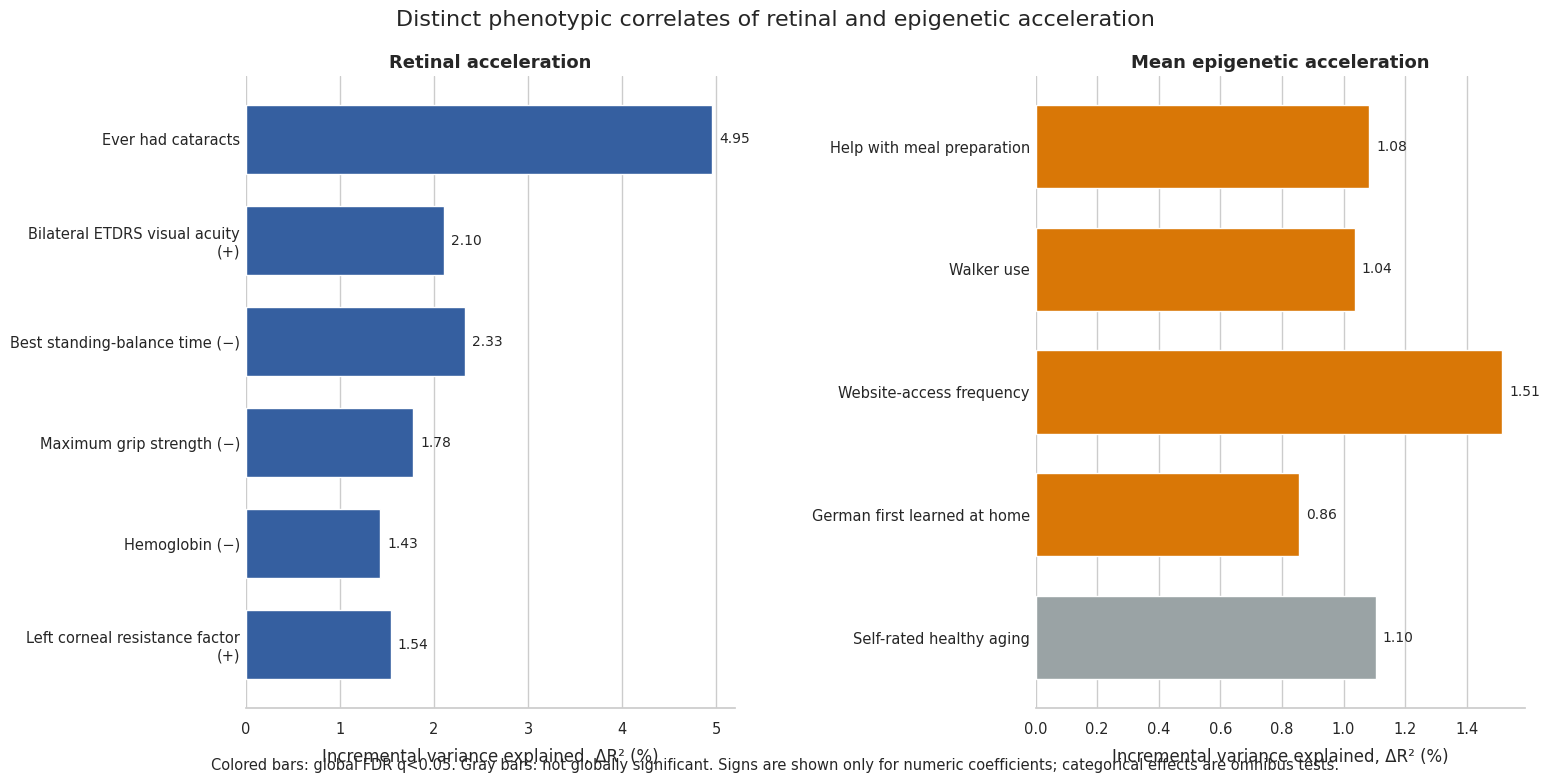

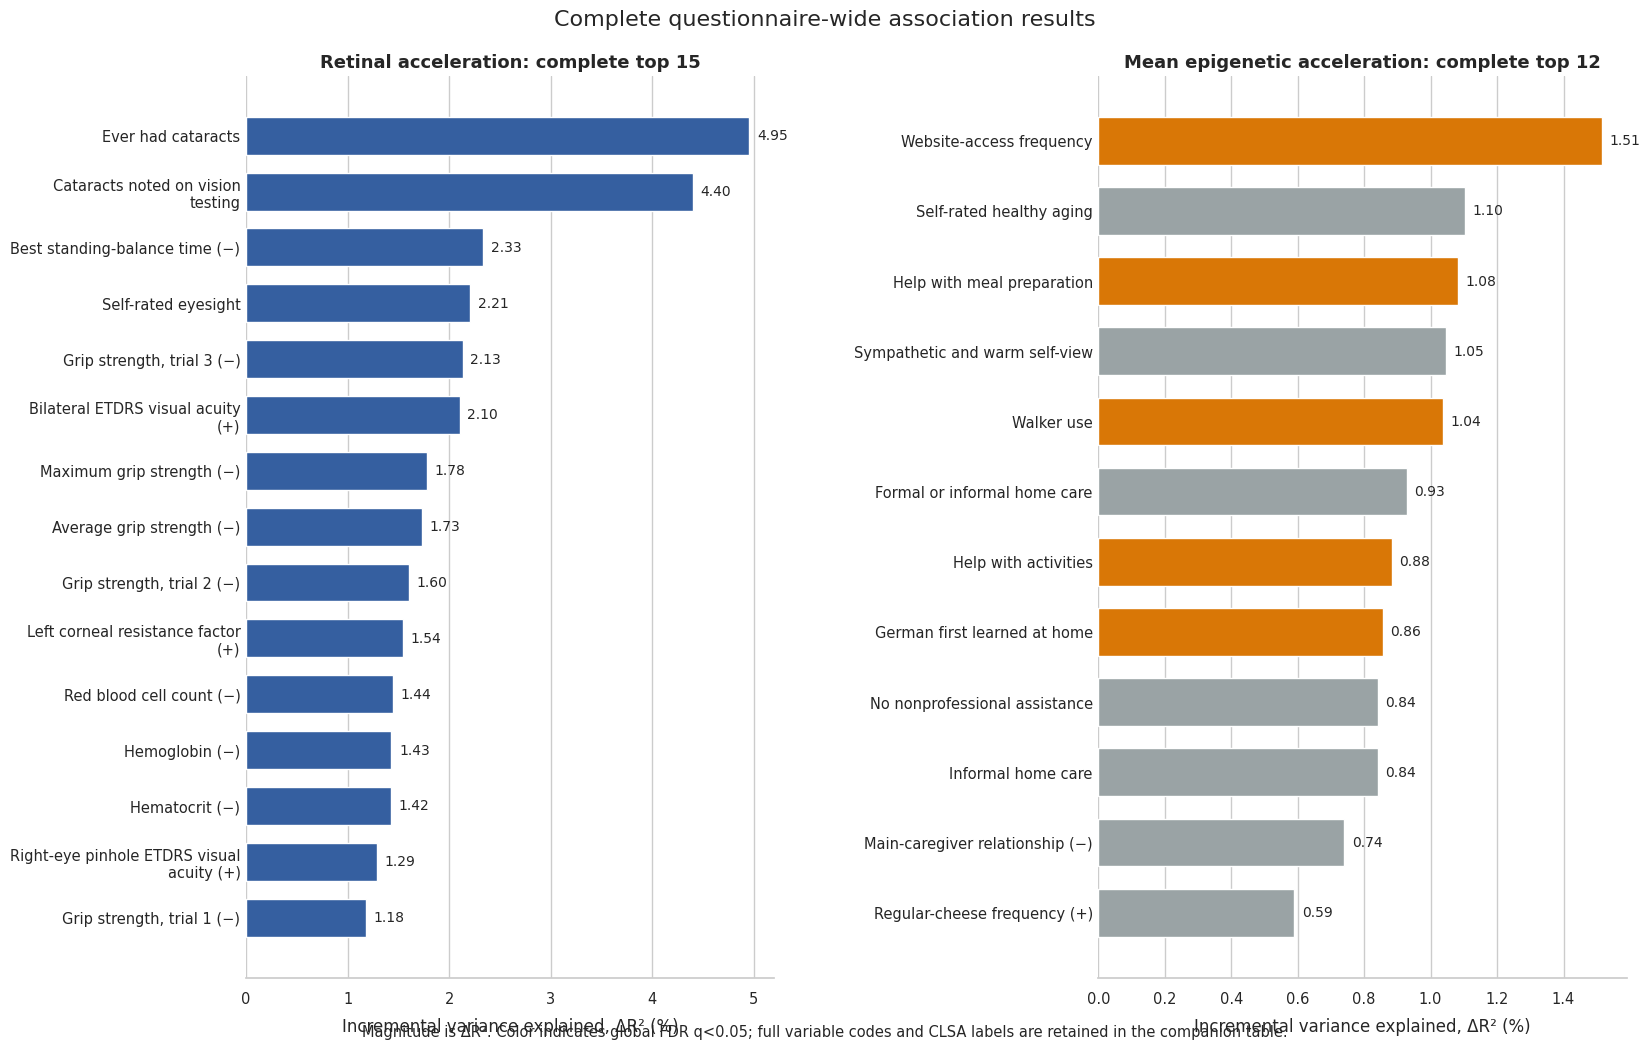

In [0]:
questionnaire_aging_outcomes = {
    "z_retinal_acceleration": "Retinal acceleration",
    "z_epigenetic_mean_acceleration": (
        "Mean epigenetic acceleration"
    ),
    "retina_specific_discordance": (
        "Retina-specific discordance"
    ),
    "z_three_clock_dispersion": (
        "Overall three-clock dispersion"
    ),
}
questionnaire_analysis_base_columns = [
    "participant_id",
    *questionnaire_aging_outcomes,
    "chronological_age",
    "chronological_age_sq",
    "log_n_embedded_images",
    *association_categorical_columns,
]
for continuous in ("bmi", "body_mass_index"):
    if continuous in association_covariate_terms:
        questionnaire_analysis_base_columns.append(continuous)
questionnaire_analysis_frame = tri_age[
    list(dict.fromkeys(questionnaire_analysis_base_columns))
].merge(
    questionnaire_clean,
    on="participant_id",
    how="left",
    validate="one_to_one",
)

questionnaire_test_rows = []
questionnaire_level_rows = []
questionnaire_level_count_rows = []
questionnaire_failure_rows = []
for variable, variable_type in (
    questionnaire_variable_types.items()
):
    for outcome, outcome_label in (
        questionnaire_aging_outcomes.items()
    ):
        model_columns = [
            outcome,
            "chronological_age",
            "chronological_age_sq",
            "log_n_embedded_images",
            *association_categorical_columns,
            variable,
        ]
        for continuous in ("bmi", "body_mass_index"):
            if continuous in association_covariate_terms:
                model_columns.append(continuous)
        work = questionnaire_analysis_frame[
            list(dict.fromkeys(model_columns))
        ].copy()
        work[outcome] = pd.to_numeric(
            work[outcome], errors="coerce"
        )
        if variable_type == "numeric":
            work["question_value_numeric"] = safe_zscore(
                pd.to_numeric(work[variable], errors="coerce")
            )
            work = work.dropna(
                subset=[outcome, "question_value_numeric"]
            )
            question_term = "question_value_numeric"
        else:
            question_values = (
                work[variable].astype("string").str.strip()
            )
            level_counts = question_values.value_counts(
                dropna=True
            )
            frequent_levels = level_counts[
                level_counts >= minimum_questionnaire_level_n
            ].index
            for level, count in level_counts.items():
                questionnaire_level_count_rows.append(
                    {
                        "variable": variable,
                        "level": str(level),
                        "count": int(count),
                        "meets_minimum_level_n": bool(
                            count >= minimum_questionnaire_level_n
                        ),
                    }
                )
            question_values = question_values.where(
                question_values.isna()
                | question_values.isin(frequent_levels),
                "Other/low-frequency",
            )
            collapsed_counts = question_values.value_counts(
                dropna=True
            )
            if (
                "Other/low-frequency" in collapsed_counts
                and collapsed_counts["Other/low-frequency"]
                < minimum_questionnaire_level_n
            ):
                question_values = question_values.mask(
                    question_values.eq("Other/low-frequency")
                )
            work["question_value_categorical"] = pd.Categorical(
                question_values.astype("object")
            )
            work = work.dropna(
                subset=[
                    outcome,
                    "question_value_categorical",
                ]
            )
            question_term = "C(question_value_categorical)"
            if work[
                "question_value_categorical"
            ].nunique() < 2:
                questionnaire_failure_rows.append(
                    {
                        "variable": variable,
                        "outcome": outcome,
                        "status": "skipped_fewer_than_two_levels",
                    }
                )
                continue
        complete_case_columns = [
            outcome,
            "chronological_age",
            "chronological_age_sq",
            "log_n_embedded_images",
            *association_categorical_columns,
            (
                "question_value_numeric"
                if variable_type == "numeric"
                else "question_value_categorical"
            ),
        ]
        for continuous in ("bmi", "body_mass_index"):
            if continuous in association_covariate_terms:
                complete_case_columns.append(continuous)
        work = work.dropna(
            subset=list(dict.fromkeys(complete_case_columns))
        )
        for categorical_covariate in association_categorical_columns:
            if isinstance(
                work[categorical_covariate].dtype,
                pd.CategoricalDtype,
            ):
                work[categorical_covariate] = (
                    work[categorical_covariate]
                    .cat.remove_unused_categories()
                )
        if variable_type == "categorical":
            work["question_value_categorical"] = (
                work["question_value_categorical"]
                .cat.remove_unused_categories()
            )
            if work[
                "question_value_categorical"
            ].nunique() < 2:
                questionnaire_failure_rows.append(
                    {
                        "variable": variable,
                        "outcome": outcome,
                        "status": (
                            "skipped_fewer_than_two_complete_case_levels"
                        ),
                        "n": int(len(work)),
                    }
                )
                continue
        if len(work) < minimum_questionnaire_observed:
            questionnaire_failure_rows.append(
                {
                    "variable": variable,
                    "outcome": outcome,
                    "status": "skipped_insufficient_complete_cases",
                    "n": int(len(work)),
                }
            )
            continue
        base_formula = (
            f"{outcome} ~ "
            + " + ".join(association_covariate_terms)
        )
        full_formula = base_formula + f" + {question_term}"
        try:
            base_model = smf.ols(
                base_formula,
                data=work,
                missing="drop",
            )
            full_model = smf.ols(
                full_formula,
                data=work,
                missing="drop",
            )
            base_rank = int(
                np.linalg.matrix_rank(base_model.exog)
            )
            full_rank = int(
                np.linalg.matrix_rank(full_model.exog)
            )
            if (
                base_rank < base_model.exog.shape[1]
                or full_rank < full_model.exog.shape[1]
            ):
                questionnaire_failure_rows.append(
                    {
                        "variable": variable,
                        "analysis_type": variable_type,
                        "outcome": outcome,
                        "status": "skipped_rank_deficient_design",
                        "n": int(len(work)),
                        "base_rank": base_rank,
                        "base_columns": int(
                            base_model.exog.shape[1]
                        ),
                        "full_rank": full_rank,
                        "full_columns": int(
                            full_model.exog.shape[1]
                        ),
                    }
                )
                continue
            base_fit = base_model.fit()
            classical_full = full_model.fit()
            robust_full = full_model.fit(cov_type="HC3")
            nested_f, nested_p, df_difference = (
                classical_full.compare_f_test(base_fit)
            )
            result = {
                "variable": variable,
                "variable_label": clsa_variable_label(variable),
                "analysis_type": variable_type,
                "outcome": outcome,
                "outcome_label": outcome_label,
                "n": int(classical_full.nobs),
                "observed_levels": int(
                    (
                        work["question_value_categorical"].nunique()
                        if variable_type == "categorical"
                        else work["question_value_numeric"].nunique(dropna=True)
                    )
                ),
                "base_r2": float(base_fit.rsquared),
                "full_r2": float(classical_full.rsquared),
                "incremental_r2": float(
                    classical_full.rsquared - base_fit.rsquared
                ),
                "omnibus_f": float(nested_f),
                "p_value": float(nested_p),
                "df_difference": float(df_difference),
                "minimum_modeled_level_n": (
                    int(
                        work[
                            "question_value_categorical"
                        ].value_counts().min()
                    )
                    if variable_type == "categorical"
                    else np.nan
                ),
                "construct_family": questionnaire_construct_family(
                    variable
                ),
            }
            if variable_type == "numeric":
                confidence = robust_full.conf_int().loc[
                    "question_value_numeric"
                ]
                result.update(
                    {
                        "standardized_coefficient": float(
                            robust_full.params[
                                "question_value_numeric"
                            ]
                        ),
                        "coefficient_ci_low": float(
                            confidence.iloc[0]
                        ),
                        "coefficient_ci_high": float(
                            confidence.iloc[1]
                        ),
                        "robust_coefficient_p": float(
                            robust_full.pvalues[
                                "question_value_numeric"
                            ]
                        ),
                    }
                )
            else:
                confidence = robust_full.conf_int()
                prefix = "C(question_value_categorical)[T."
                for term in robust_full.params.index:
                    if not term.startswith(prefix):
                        continue
                    questionnaire_level_rows.append(
                        {
                            "variable": variable,
                            "variable_label": clsa_variable_label(variable),
                            "outcome": outcome,
                            "outcome_label": outcome_label,
                            "term": term,
                            "comparison_level": term[
                                len(prefix):-1
                            ],
                            "n": int(robust_full.nobs),
                            "coefficient": float(
                                robust_full.params[term]
                            ),
                            "ci_low": float(
                                confidence.loc[term, 0]
                            ),
                            "ci_high": float(
                                confidence.loc[term, 1]
                            ),
                            "p_value": float(
                                robust_full.pvalues[term]
                            ),
                        }
                    )
            questionnaire_test_rows.append(result)
        except Exception as error:
            questionnaire_failure_rows.append(
                {
                    "variable": variable,
                    "analysis_type": variable_type,
                    "outcome": outcome,
                    "status": f"failed:{type(error).__name__}",
                    "error_message": str(error)[:500],
                    "n": int(len(work)),
                }
            )

questionnaire_tests = pd.DataFrame(questionnaire_test_rows)
questionnaire_level_coefficients = pd.DataFrame(
    questionnaire_level_rows
)
questionnaire_level_counts = pd.DataFrame(
    questionnaire_level_count_rows
)
questionnaire_failures = pd.DataFrame(
    questionnaire_failure_rows
)
if not questionnaire_tests.empty:
    questionnaire_tests["fdr_q_global"] = (
        benjamini_hochberg(
            questionnaire_tests["p_value"].to_numpy(float)
        )
    )
    questionnaire_tests["fdr_q_within_outcome"] = np.nan
    for outcome, index in questionnaire_tests.groupby(
        "outcome"
    ).groups.items():
        questionnaire_tests.loc[
            index,
            "fdr_q_within_outcome",
        ] = benjamini_hochberg(
            questionnaire_tests.loc[
                index,
                "p_value",
            ].to_numpy(float)
        )
    questionnaire_tests["significant_global_fdr_0_05"] = (
        questionnaire_tests["fdr_q_global"] < 0.05
    )
    questionnaire_tests["small_sample_warning"] = (
        questionnaire_tests["n"]
        < minimum_questionnaire_manuscript_n
    )
    questionnaire_tests["manuscript_eligible"] = (
        ~questionnaire_tests["small_sample_warning"]
        & (
            questionnaire_tests["analysis_type"].eq("numeric")
            | questionnaire_tests[
                "minimum_modeled_level_n"
            ].ge(minimum_questionnaire_level_n)
        )
    )
if not questionnaire_level_coefficients.empty:
    questionnaire_level_coefficients["fdr_q_global"] = (
        benjamini_hochberg(
            questionnaire_level_coefficients[
                "p_value"
            ].to_numpy(float)
        )
    )
manuscript_questionnaire_tests = (
    questionnaire_tests[
        questionnaire_tests.get(
            "manuscript_eligible",
            pd.Series(False, index=questionnaire_tests.index),
        ).fillna(False)
    ]
    .sort_values(["fdr_q_global", "p_value"])
    .copy()
    if not questionnaire_tests.empty
    else pd.DataFrame()
)
if not manuscript_questionnaire_tests.empty:
    manuscript_questionnaire_tests["construct_key"] = (
        manuscript_questionnaire_tests["construct_family"]
        .fillna(manuscript_questionnaire_tests["variable"])
    )
    manuscript_questionnaire_tests = (
        manuscript_questionnaire_tests.drop_duplicates(
            ["outcome", "construct_key"],
            keep="first",
        )
    )
write_frame(
    questionnaire_tests,
    statistics_root / "questionnaire_phenome_scan_tests.csv",
)
write_frame(
    questionnaire_level_coefficients,
    statistics_root
    / "questionnaire_categorical_level_coefficients.csv",
)
write_frame(
    questionnaire_level_counts,
    statistics_root
    / "questionnaire_categorical_level_counts.csv",
)
write_frame(
    questionnaire_failures,
    statistics_root / "questionnaire_phenome_scan_failures.csv",
)
write_frame(
    manuscript_questionnaire_tests,
    statistics_root
    / "questionnaire_phenome_scan_manuscript_candidates.csv",
)
display(
    questionnaire_tests.sort_values(
        ["fdr_q_global", "p_value"]
    ).head(100).round(6)
    if not questionnaire_tests.empty
    else questionnaire_tests
)
ccc_level_audit = questionnaire_level_counts[
    questionnaire_level_counts["variable"].eq(
        "CCC_CANTP_LK_COM"
    )
].copy()
if not ccc_level_audit.empty:
    print(
        "CCC_CANTP_LK_COM is retained only in the exploratory table; "
        "its level counts and manuscript eligibility are shown below."
    )
    display(ccc_level_audit)

if not questionnaire_tests.empty:
    publication_associations = questionnaire_tests[
        questionnaire_tests["manuscript_eligible"].fillna(False)
        & ~questionnaire_tests["variable"].isin(
            questionnaire_explicit_exclusions
        )
    ].copy()
    publication_associations["variable_label"] = (
        publication_associations["variable"].map(
            clsa_variable_label
        )
    )
    publication_associations["incremental_r2_percent"] = (
        100 * publication_associations["incremental_r2"]
    )
    publication_associations["global_fdr_significant"] = (
        publication_associations["fdr_q_global"].lt(0.05)
    )

    def association_axis_label(row, width=31):
        label = PUBLICATION_SHORT_LABELS.get(
            row["variable"],
            row["variable_label"],
        )
        coefficient = row.get("standardized_coefficient", np.nan)
        if row["analysis_type"] == "numeric" and pd.notna(coefficient):
            label += " (+)" if coefficient > 0 else " (−)"
        return fill(str(label), width=width)


    def draw_incremental_r2_panel(
        axis,
        plot,
        *,
        significant_color,
        title,
        xmax=None,
    ):
        positions = np.arange(len(plot))
        values = plot["incremental_r2_percent"].to_numpy(float)
        colors = np.where(
            plot["global_fdr_significant"],
            significant_color,
            "#9AA3A5",
        )
        axis.barh(positions, values, color=colors, height=0.68)
        axis.set_yticks(
            positions,
            [association_axis_label(row) for _, row in plot.iterrows()],
        )
        axis.set(
            title=title,
            xlabel="Incremental variance explained, ΔR² (%)",
            ylabel="",
        )
        if xmax is not None:
            axis.set_xlim(0, xmax)
        axis.grid(axis="y", visible=False)
        axis.spines[["top", "right", "left"]].set_visible(False)
        axis.tick_params(axis="y", length=0)
        offset = 0.015 * max(float(values.max()), 1.0)
        for position, value in zip(positions, values):
            axis.text(
                value + offset,
                position,
                f"{value:.2f}",
                ha="left",
                va="center",
                fontsize=10,
            )


    main_publication_variables = {
        "z_retinal_acceleration": [
            "ICQ_CATRCT_COM",
            "VA_ETDRS_BOTH_NB_COM",
            "BAL_BEST_COM",
            "GS_EXAM_MAX_COM",
            "BLD_Hgb_COM",
            "TON_CRF_L_COM",
        ],
        "z_epigenetic_mean_acceleration": [
            "CR2_FAM_ML_COM",
            "CR2_DEVC_WK_COM",
            "INT_FRQWBSTS_MCQ",
            "SDC_FTLG_DE_COM",
            "GEN_OWNAG_COM",
        ],
    }
    main_titles = {
        "z_retinal_acceleration": "Retinal acceleration",
        "z_epigenetic_mean_acceleration": "Mean epigenetic acceleration",
    }
    main_colors = {
        "z_retinal_acceleration": "#355FA0",
        "z_epigenetic_mean_acceleration": "#D97706",
    }
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(15.5, 7.8),
        layout="constrained",
    )
    for axis, outcome in zip(axes, main_publication_variables):
        variable_order = main_publication_variables[outcome]
        plot = publication_associations[
            publication_associations["outcome"].eq(outcome)
            & publication_associations["variable"].isin(variable_order)
        ].copy()
        order = {
            variable: index
            for index, variable in enumerate(variable_order)
        }
        plot["publication_order"] = plot["variable"].map(order)
        plot = plot.sort_values("publication_order", ascending=False)
        draw_incremental_r2_panel(
            axis,
            plot,
            significant_color=main_colors[outcome],
            title=main_titles[outcome],
        )
    figure.suptitle(
        "Distinct phenotypic correlates of retinal and epigenetic acceleration"
    )
    figure.text(
        0.5,
        0.01,
        "Colored bars: global FDR q<0.05. Gray bars: not globally significant. "
        "Signs are shown only for numeric coefficients; categorical effects are omnibus tests.",
        ha="center",
        fontsize=10.5,
    )
    prepare_publication_figure(figure, suptitle_y=0.99)
    figure.savefig(
        figure_root / "figure_10a_main_representative_associations.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.35,
        facecolor="white",
    )
    # Retain the historical filename used by downstream notebook
    # contracts while making the representative panel the main figure.
    figure.savefig(
        figure_root / "figure_10_questionnaire_phenome_scan.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.35,
        facecolor="white",
    )
    plt.show()
    plt.close(figure)

    supplementary_limits = {
        "z_retinal_acceleration": 15,
        "z_epigenetic_mean_acceleration": 12,
    }
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(16.5, 10.5),
        layout="constrained",
    )
    for axis, outcome in zip(axes, supplementary_limits):
        plot = (
            publication_associations[
                publication_associations["outcome"].eq(outcome)
            ]
            .nsmallest(
                supplementary_limits[outcome],
                ["fdr_q_global", "p_value"],
            )
            .sort_values("incremental_r2_percent")
        )
        draw_incremental_r2_panel(
            axis,
            plot,
            significant_color=main_colors[outcome],
            title=(
                "Retinal acceleration: complete top 15"
                if outcome == "z_retinal_acceleration"
                else "Mean epigenetic acceleration: complete top 12"
            ),
        )
    figure.suptitle(
        "Complete questionnaire-wide association results"
    )
    figure.text(
        0.5,
        0.01,
        "Magnitude is ΔR². Color indicates global FDR q<0.05; "
        "full variable codes and CLSA labels are retained in the companion table.",
        ha="center",
        fontsize=10.5,
    )
    prepare_publication_figure(figure, suptitle_y=0.99)
    figure.savefig(
        figure_root / "figure_10b_complete_questionnaire_associations.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.35,
        facecolor="white",
    )
    plt.show()
    plt.close(figure)

## 15. Cataract and stricter-image-quality sensitivity analyses

Cataract is handled as one construct across the ICQ and VIS modules.
The questionnaire associations for visual acuity and grip strength are
repeated after cataract adjustment. A second sensitivity model rebuilds
participant embeddings using only the strongest 75% of technically
passing images according to an outcome-blind composite of contrast,
sharpness, illumination, field coverage, and saturation metrics.

This distinguishes an ocular association from a media-opacity/blur
pathway. It does not prove that surviving associations are causal.

Prespecified sensitivity inputs are restricted to numeric ETDRS scores
(`VA_ETDRS_{BOTH,L,R}[_PO]_NB_COM`), the five released grip summaries
(`GS_EXAM_MAX_COM`, `GS_EXAM_AVG_COM`, and `GS_TRIAL1-3_MAX_COM`), and
the primary `ICQ_CATRCT_COM`/`VIS_CATRCT_COM` cataract indicators.
Substring matching is not used.

In [0]:
quality_frames = [pd.read_parquet(quality_path)]
fairness_quality_root = (
    fairness_root
    / "00_full_image_pipeline"
    / "01_quality_batches"
)
for cached_quality_path in sorted(
    fairness_quality_root.glob(
        "batch_*/fundus_quality_manifest.parquet"
    )
):
    quality_frames.append(pd.read_parquet(cached_quality_path))
image_quality = pd.concat(quality_frames, ignore_index=True)
image_quality.attrs = {}
if "participant_id" not in image_quality.columns:
    if "participant_id_parsed" in image_quality.columns:
        image_quality = image_quality.rename(
            columns={"participant_id_parsed": "participant_id"}
        )
    else:
        raise ValueError(
            "Quality ledger lacks participant_id/participant_id_parsed"
        )
required_quality_columns = {
    "participant_id",
    "visit",
    "image_path",
    "quality_pass",
}
missing = required_quality_columns - set(image_quality.columns)
if missing:
    raise ValueError(
        f"Quality ledger missing columns: {sorted(missing)}"
    )
image_quality["participant_id"] = normalize_identifier(
    image_quality["participant_id"]
)
image_quality["visit"] = normalize_visit(image_quality["visit"])
image_quality["image_path"] = image_quality["image_path"].astype(str)
image_quality = (
    image_quality.drop_duplicates("image_path", keep="last")
    .loc[
        lambda frame: (
            frame["participant_id"].isin(
                set(tri_age["participant_id"].astype(str))
            )
            & frame["visit"].eq("BL")
        )
    ]
    .copy()
)
image_quality["technical_quality_pass"] = normalized_code(
    image_quality["quality_pass"]
).isin({"1", "TRUE", "T", "Y", "YES"})
image_quality = image_quality[
    image_quality["technical_quality_pass"]
].copy()

high_is_good_metrics = [
    metric
    for metric in ("contrast_std", "gradient_energy")
    if metric in image_quality.columns
]
central_is_good_metrics = [
    metric
    for metric in ("brightness_mean", "retina_fraction")
    if metric in image_quality.columns
]
low_is_good_metrics = [
    metric
    for metric in ("dark_fraction", "bright_fraction")
    if metric in image_quality.columns
]
strict_quality_metrics = [
    *high_is_good_metrics,
    *central_is_good_metrics,
    *low_is_good_metrics,
]
if len(strict_quality_metrics) < 3:
    raise ValueError(
        "At least three technical-quality metrics are required for "
        "the strict-quality sensitivity analysis"
    )
quality_component_columns = []
strict_quality_definition_rows = []
for metric in strict_quality_metrics:
    values = pd.to_numeric(image_quality[metric], errors="coerce")
    if metric in high_is_good_metrics:
        component = values.rank(pct=True)
        direction = "higher_is_better"
        center = np.nan
    elif metric in low_is_good_metrics:
        component = (-values).rank(pct=True)
        direction = "lower_is_better"
        center = np.nan
    else:
        center = float(values.median())
        component = (-abs(values - center)).rank(pct=True)
        direction = "closer_to_median_is_better"
    component_column = f"strict_component_{metric}"
    image_quality[component_column] = component
    quality_component_columns.append(component_column)
    strict_quality_definition_rows.append(
        {
            "metric": metric,
            "direction": direction,
            "cohort_median": center,
            "nonmissing_images": int(values.notna().sum()),
        }
    )
image_quality["strict_quality_component_count"] = image_quality[
    quality_component_columns
].notna().sum(axis=1)
image_quality["strict_quality_score"] = image_quality[
    quality_component_columns
].mean(axis=1, skipna=True)
minimum_quality_components = max(
    2,
    math.ceil(len(quality_component_columns) / 2),
)
score_eligible = image_quality[
    "strict_quality_component_count"
].ge(minimum_quality_components)
strict_quality_threshold = float(
    image_quality.loc[
        score_eligible,
        "strict_quality_score",
    ].quantile(1 - strict_quality_retained_fraction)
)
image_quality["strict_quality_pass"] = (
    score_eligible
    & image_quality["strict_quality_score"].ge(
        strict_quality_threshold
    )
)
strict_quality_paths = set(
    image_quality.loc[
        image_quality["strict_quality_pass"],
        "image_path",
    ].astype(str)
)
if not strict_quality_paths:
    raise ValueError("No images passed the strict-quality definition")
strict_quality_definition = pd.DataFrame(
    strict_quality_definition_rows
)
strict_quality_definition["composite_threshold"] = (
    strict_quality_threshold
)
strict_quality_definition["retained_fraction_target"] = (
    strict_quality_retained_fraction
)
strict_quality_definition["images_technical_pass"] = int(
    len(image_quality)
)
strict_quality_definition["images_strict_pass"] = int(
    len(strict_quality_paths)
)
write_frame(
    strict_quality_definition,
    statistics_root / "strict_image_quality_definition.csv",
)
write_frame(
    image_quality[
        [
            "participant_id",
            "visit",
            "image_path",
            *strict_quality_metrics,
            "strict_quality_component_count",
            "strict_quality_score",
            "strict_quality_pass",
        ]
    ],
    private_root / "strict_image_quality_audit_private.parquet",
)

embedding_paths = sorted(
    (embedding_root / "batches").glob(
        "batch_*/retfound_embeddings.parquet"
    )
)
if not embedding_paths:
    consolidated_embeddings = (
        embedding_root / "retfound_embeddings.parquet"
    )
    if consolidated_embeddings.exists():
        embedding_paths = [consolidated_embeddings]
embedding_paths.extend(
    sorted(
        fairness_embedding_root.glob(
            "batch_*/retfound_embeddings.parquet"
        )
    )
)
embedding_paths = sorted(set(embedding_paths))
if not embedding_paths:
    raise FileNotFoundError(
        "No image-level RETFound embedding Parquets were found"
    )
strict_rollup_signature = hashlib.sha256(
    (
        "\n".join(sorted(strict_quality_paths))
        + "\n"
        + "\n".join(str(path) for path in embedding_paths)
    ).encode("utf-8")
).hexdigest()
strict_rollup_path = (
    checkpoint_root / "strict_quality_participant_visit_embeddings.parquet"
)
strict_rollup_metadata_path = strict_rollup_path.with_suffix(".json")
resume_strict_rollup = False
if (
    resume_completed_outputs
    and strict_rollup_path.is_file()
    and strict_rollup_metadata_path.is_file()
):
    strict_rollup_metadata = json.loads(
        strict_rollup_metadata_path.read_text()
    )
    resume_strict_rollup = (
        strict_rollup_metadata.get("signature")
        == strict_rollup_signature
    )
if resume_strict_rollup:
    strict_participant_embeddings = pd.read_parquet(
        strict_rollup_path
    )
    print("Resumed strict-quality embedding rollup")
else:
    strict_accumulators = {}
    seen_strict_image_paths = set()
    for path_index, embedding_path in enumerate(
        embedding_paths,
        1,
    ):
        embedded = pd.read_parquet(
            embedding_path,
            columns=[
                "image_path",
                "participant_id",
                "visit",
                "embedding",
            ],
        )
        embedded["image_path"] = embedded["image_path"].astype(str)
        embedded = embedded[
            embedded["image_path"].isin(strict_quality_paths)
            & ~embedded["image_path"].isin(
                seen_strict_image_paths
            )
        ].copy()
        embedded["participant_id"] = normalize_identifier(
            embedded["participant_id"]
        )
        embedded["visit"] = normalize_visit(embedded["visit"])
        embedded = embedded[
            embedded["visit"].eq("BL")
            & embedded["participant_id"].isin(
                set(tri_age["participant_id"].astype(str))
            )
        ]
        for record in embedded.itertuples(index=False):
            vector = np.asarray(
                record.embedding,
                dtype=np.float64,
            ).reshape(-1)
            if vector.size != expected_embedding_dim:
                raise ValueError(
                    f"Unexpected strict embedding dimension: {vector.size}"
                )
            key = (str(record.participant_id), str(record.visit))
            if key not in strict_accumulators:
                strict_accumulators[key] = [vector.copy(), 1]
            else:
                strict_accumulators[key][0] += vector
                strict_accumulators[key][1] += 1
        seen_strict_image_paths.update(
            embedded["image_path"].astype(str)
        )
        if (
            path_index == 1
            or path_index % 25 == 0
            or path_index == len(embedding_paths)
        ):
            print(
                f"[strict rollup {path_index}/{len(embedding_paths)}] "
                f"{len(seen_strict_image_paths):,} images",
                flush=True,
            )
    strict_participant_embeddings = pd.DataFrame(
        [
            {
                "participant_id": participant_id,
                "visit": visit,
                "embedding": (
                    vector_sum / image_count
                ).astype(np.float32),
                "n_embedded_images": image_count,
            }
            for (
                participant_id,
                visit,
            ), (
                vector_sum,
                image_count,
            ) in strict_accumulators.items()
        ]
    )
    write_frame(strict_participant_embeddings, strict_rollup_path)
    write_json(
        {
            "signature": strict_rollup_signature,
            "n_images": int(len(seen_strict_image_paths)),
            "n_participant_visits": int(
                len(strict_participant_embeddings)
            ),
            "strict_quality_threshold": strict_quality_threshold,
        },
        strict_rollup_metadata_path,
    )
if strict_participant_embeddings.empty:
    raise ValueError(
        "Strict-quality images could not be linked to RETFound vectors"
    )
strict_training = strict_participant_embeddings.merge(
    sap[["participant_id", "visit", "age_at_fundus_years"]],
    on=["participant_id", "visit"],
    how="left",
    validate="one_to_one",
).rename(columns={"age_at_fundus_years": "chronological_age"})
strict_chronological_oof, strict_age_bundle = fit_or_resume_head(
    strict_training,
    "chronological_age",
    "retfound_chronological_age_strict_quality_v1",
)
strict_chronological_oof["participant_id"] = normalize_identifier(
    strict_chronological_oof["participant_id"]
)
strict_chronological_oof["visit"] = normalize_visit(
    strict_chronological_oof["visit"]
)
strict_chronological_oof = strict_chronological_oof.rename(
    columns={
        "age": "chronological_age",
        "retinal_age_prediction_oof": (
            "retinal_age_oof_strict_quality"
        ),
    }
)
strict_baseline = strict_chronological_oof[
    strict_chronological_oof["visit"].eq("BL")
].copy()
(
    strict_baseline["retinal_acceleration_strict_quality"],
    strict_baseline["retinal_expected_strict_quality"],
) = cross_fitted_spline_residual(
    strict_baseline,
    "retinal_age_oof_strict_quality",
    "chronological_age",
    "participant_id",
)
strict_baseline["z_retinal_acceleration_strict_quality"] = (
    safe_zscore(
        strict_baseline["retinal_acceleration_strict_quality"]
    )
)
write_frame(
    strict_baseline.drop(
        columns=["embedding"],
        errors="ignore",
    ),
    private_root
    / "strict_quality_retinal_age_oof_private.parquet",
)

Resumed strict-quality embedding rollup
Resumed retfound_chronological_age_strict_quality_v1: 1,209 OOF rows


PosixPath('/Volumes/ophthalmology_analytics/dev_optic/clsa_dataset/derived/clsa_retinal_aging/Age_Glaucoma/16_algorithm_fairness/08_epigenetics/01_private/strict_quality_retinal_age_oof_private.parquet')

variable,analysis_type,n,incremental_r2,p_value,fdr_q_within_analysis,manuscript_eligible,analysis,domain,minimum_modeled_level_n,omnibus_f,df_difference,standardized_coefficient,coefficient_ci_low,coefficient_ci_high,robust_coefficient_p
GS_EXAM_AVG_COM,numeric,1340,0.016146,1.0E-6,4.0E-6,true,primary_retinal_cataract_adjusted,grip_strength,null,23.404281,1.0,-0.210864,-0.302421,-0.119307,6.0E-6
GS_EXAM_AVG_COM,numeric,1340,0.01732,1.0E-6,7.95E-4,true,primary_unadjusted,null,null,null,null,null,null,null,null
GS_EXAM_AVG_COM,numeric,1153,0.014117,4.3E-5,9.6E-5,true,strict_quality_cataract_adjusted,grip_strength,null,16.867502,1.0,-0.196566,-0.29371,-0.099421,7.3E-5
GS_EXAM_AVG_COM,numeric,1153,0.015105,2.7E-5,5.2E-5,true,strict_quality_unadjusted,grip_strength,null,17.745069,1.0,-0.203233,-0.301446,-0.10502,5.0E-5
GS_EXAM_MAX_COM,numeric,1340,0.01663,1.0E-6,3.0E-6,true,primary_retinal_cataract_adjusted,grip_strength,null,24.119025,1.0,-0.217792,-0.311457,-0.124126,5.0E-6
GS_EXAM_MAX_COM,numeric,1340,0.017824,1.0E-6,6.62E-4,true,primary_unadjusted,null,null,null,null,null,null,null,null
GS_EXAM_MAX_COM,numeric,1153,0.013945,4.8E-5,9.6E-5,true,strict_quality_cataract_adjusted,grip_strength,null,16.659015,1.0,-0.198637,-0.297538,-0.099735,8.3E-5
GS_EXAM_MAX_COM,numeric,1153,0.014946,3.0E-5,5.2E-5,true,strict_quality_unadjusted,grip_strength,null,17.555369,1.0,-0.205543,-0.305537,-0.105549,5.6E-5
GS_TRIAL1_MAX_COM,numeric,1340,0.010954,7.5E-5,1.07E-4,true,primary_retinal_cataract_adjusted,grip_strength,null,15.789195,1.0,-0.169502,-0.258433,-0.08057,1.87E-4
GS_TRIAL1_MAX_COM,numeric,1340,0.011779,6.1E-5,0.017255,true,primary_unadjusted,null,null,null,null,null,null,null,null


variable,primary_retinal_cataract_adjusted,primary_unadjusted,strict_quality_cataract_adjusted,strict_quality_unadjusted,significant_primary_unadjusted,significant_primary_retinal_cataract_adjusted,significant_strict_quality_unadjusted,significant_strict_quality_cataract_adjusted,robust_across_all_checks
GS_EXAM_AVG_COM,3.6659908498158565E-6,7.948117066197699E-4,9.571099590057916E-5,5.153037762228701E-5,true,true,true,true,true
GS_EXAM_MAX_COM,3.3938926357529368E-6,6.622534652371272E-4,9.571099590057916E-5,5.153037762228701E-5,true,true,true,true,true
GS_TRIAL1_MAX_COM,1.0659135822407479E-4,0.017254787859127364,0.001176696143102393,6.626079952373569E-4,true,true,true,true,true
GS_TRIAL2_MAX_COM,7.74296163058904E-6,0.0018224395570152166,1.1440563240403308E-4,6.536726257088166E-5,true,true,true,true,true
GS_TRIAL3_MAX_COM,8.009688694842696E-7,6.591481139043961E-5,2.0530720055879253E-5,9.704260346823626E-6,true,true,true,true,true
VA_ETDRS_BOTH_NB_COM,2.0445048296217426E-6,5.049628387161796E-5,2.4466736335471115E-6,4.333357867044055E-7,true,true,true,true,true
VA_ETDRS_L_PO_NB_COM,0.0017958942915337847,0.045011344314112745,0.0014991594710088256,5.234256839156405E-4,true,true,true,true,true
VA_ETDRS_R_PO_NB_COM,1.0659135822407479E-4,0.006416260893109593,2.0530720055879253E-5,5.991875051280773E-6,true,true,true,true,true
VA_ETDRS_L_NB_COM,0.0014276801557703165,0.1972402496489046,0.0023788901280405988,0.002434464545570738,false,true,true,true,false
VA_ETDRS_R_NB_COM,0.0013724759194670222,0.0509493063986371,3.901284571070646E-4,1.0145162008291237E-4,false,true,true,true,false


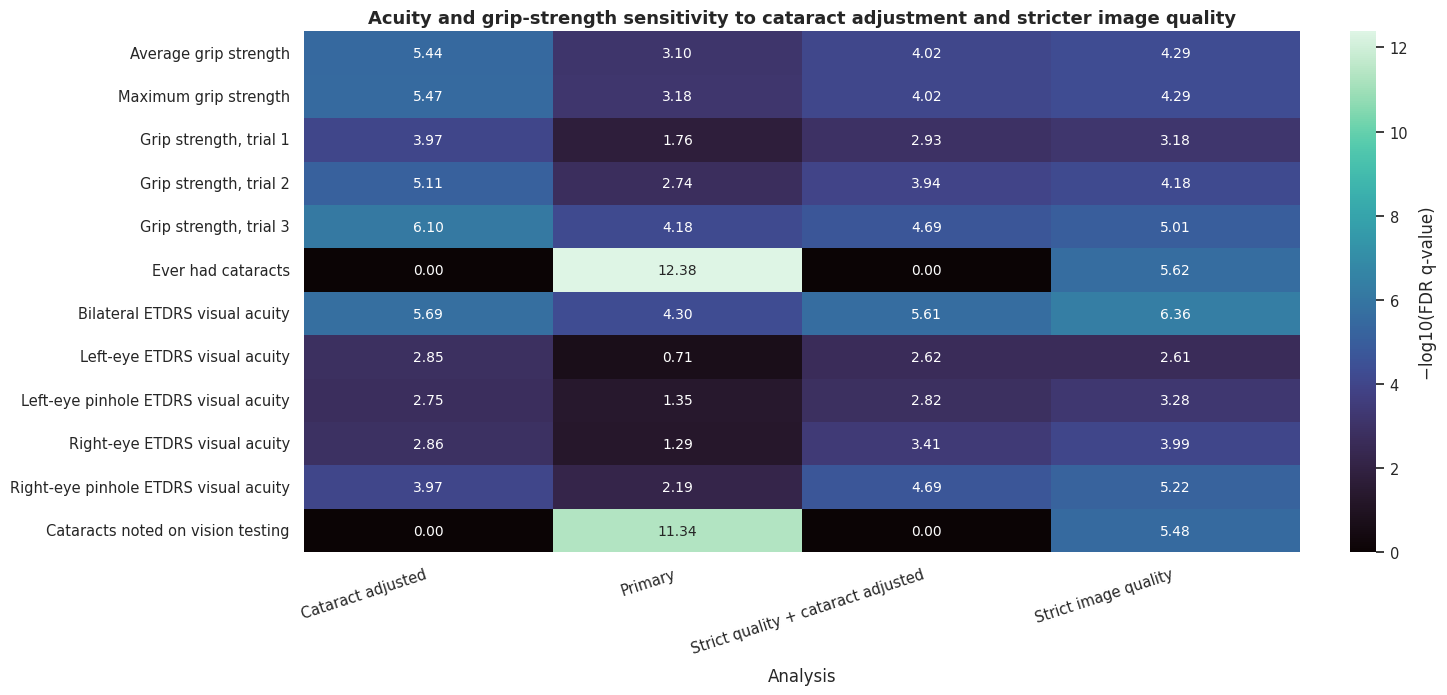

In [0]:
cataract_source_columns = [
    variable
    for variable in questionnaire_source_columns
    if cataract_status_pattern.search(variable)
]
if not cataract_source_columns:
    raise ValueError(
        "No ICQ_CATRCT/VIS_CATRCT variables were found in the "
        "baseline questionnaire"
    )
cataract_components = pd.DataFrame(
    {
        variable: coerce_binary(
            all_questionnaire_answers[variable]
        )
        for variable in cataract_source_columns
    }
)
cataract_any = cataract_components.max(axis=1, skipna=True)
cataract_any = cataract_any.mask(
    cataract_components.notna().sum(axis=1).eq(0)
)
cataract_status = all_questionnaire_answers[
    ["participant_id"]
].copy()
cataract_status["cataract_any"] = cataract_any
cataract_source_audit = pd.DataFrame(
    [
        {
            "variable": variable,
            "nonmissing": int(
                cataract_components[variable].notna().sum()
            ),
            "positive": int(
                cataract_components[variable].eq(1).sum()
            ),
            "prevalence": float(
                cataract_components[variable].mean()
            ),
        }
        for variable in cataract_source_columns
    ]
)
cataract_source_audit.loc[len(cataract_source_audit)] = {
    "variable": "combined_any_cataract",
    "nonmissing": int(cataract_any.notna().sum()),
    "positive": int(cataract_any.eq(1).sum()),
    "prevalence": float(cataract_any.mean()),
}
write_frame(
    cataract_source_audit,
    statistics_root / "cataract_construct_source_audit.csv",
)

sensitivity_frame = (
    questionnaire_analysis_frame.merge(
        cataract_status,
        on="participant_id",
        how="left",
        validate="one_to_one",
    ).merge(
        strict_baseline[
            [
                "participant_id",
                "z_retinal_acceleration_strict_quality",
            ]
        ],
        on="participant_id",
        how="left",
        validate="one_to_one",
    )
)
sensitivity_target_variables = [
    variable
    for variable in questionnaire_variable_types
    if (
        cataract_status_pattern.search(variable)
        or visual_acuity_score_pattern.search(variable)
        or grip_strength_pattern.search(variable)
    )
]
sensitivity_specs = [
    {
        "analysis": "primary_retinal_cataract_adjusted",
        "outcome": "z_retinal_acceleration",
        "extra_terms": ["cataract_any"],
    },
    {
        "analysis": "strict_quality_unadjusted",
        "outcome": "z_retinal_acceleration_strict_quality",
        "extra_terms": [],
    },
    {
        "analysis": "strict_quality_cataract_adjusted",
        "outcome": "z_retinal_acceleration_strict_quality",
        "extra_terms": ["cataract_any"],
    },
]
sensitivity_rows = []
sensitivity_failure_rows = []
for specification in sensitivity_specs:
    for variable in sensitivity_target_variables:
        if (
            specification["extra_terms"]
            and cataract_construct_pattern.search(variable)
        ):
            sensitivity_failure_rows.append(
                {
                    "analysis": specification["analysis"],
                    "variable": variable,
                    "status": "not_tested_conditioned_on_same_cataract_construct",
                }
            )
            continue
        variable_type = questionnaire_variable_types[variable]
        model_columns = [
            specification["outcome"],
            "chronological_age",
            "chronological_age_sq",
            "log_n_embedded_images",
            *association_categorical_columns,
            *specification["extra_terms"],
            variable,
        ]
        for continuous in ("bmi", "body_mass_index"):
            if continuous in association_covariate_terms:
                model_columns.append(continuous)
        work = sensitivity_frame[
            list(dict.fromkeys(model_columns))
        ].copy()
        outcome = specification["outcome"]
        work[outcome] = pd.to_numeric(
            work[outcome], errors="coerce"
        )
        if variable_type == "numeric":
            work["question_value_numeric"] = safe_zscore(
                pd.to_numeric(work[variable], errors="coerce")
            )
            question_term = "question_value_numeric"
            work = work.dropna(
                subset=[outcome, question_term]
                + specification["extra_terms"]
            )
            minimum_level_n = np.nan
        else:
            values = work[variable].astype("string").str.strip()
            counts = values.value_counts(dropna=True)
            frequent = counts[
                counts >= minimum_questionnaire_level_n
            ].index
            values = values.where(
                values.isna() | values.isin(frequent),
                "Other/low-frequency",
            )
            collapsed_counts = values.value_counts(dropna=True)
            if (
                "Other/low-frequency" in collapsed_counts
                and collapsed_counts["Other/low-frequency"]
                < minimum_questionnaire_level_n
            ):
                values = values.mask(
                    values.eq("Other/low-frequency")
                )
            work["question_value_categorical"] = pd.Categorical(
                values.astype("object")
            )
            question_term = "C(question_value_categorical)"
            work = work.dropna(
                subset=[outcome, "question_value_categorical"]
                + specification["extra_terms"]
            )
            level_counts = work[
                "question_value_categorical"
            ].value_counts()
            minimum_level_n = (
                int(level_counts.min())
                if not level_counts.empty
                else 0
            )
            if len(level_counts) < 2:
                sensitivity_failure_rows.append(
                    {
                        "analysis": specification["analysis"],
                        "variable": variable,
                        "status": "fewer_than_two_stable_levels",
                        "n": int(len(work)),
                    }
                )
                continue
        sensitivity_complete_columns = [
            outcome,
            "chronological_age",
            "chronological_age_sq",
            "log_n_embedded_images",
            *association_categorical_columns,
            *specification["extra_terms"],
            (
                "question_value_numeric"
                if variable_type == "numeric"
                else "question_value_categorical"
            ),
        ]
        for continuous in ("bmi", "body_mass_index"):
            if continuous in association_covariate_terms:
                sensitivity_complete_columns.append(continuous)
        work = work.dropna(
            subset=list(
                dict.fromkeys(sensitivity_complete_columns)
            )
        )
        for categorical_covariate in association_categorical_columns:
            if isinstance(
                work[categorical_covariate].dtype,
                pd.CategoricalDtype,
            ):
                work[categorical_covariate] = (
                    work[categorical_covariate]
                    .cat.remove_unused_categories()
                )
        if variable_type == "categorical":
            work["question_value_categorical"] = (
                work["question_value_categorical"]
                .cat.remove_unused_categories()
            )
            level_counts = work[
                "question_value_categorical"
            ].value_counts()
            minimum_level_n = (
                int(level_counts.min())
                if not level_counts.empty
                else 0
            )
            if len(level_counts) < 2:
                sensitivity_failure_rows.append(
                    {
                        "analysis": specification["analysis"],
                        "variable": variable,
                        "status": (
                            "fewer_than_two_complete_case_levels"
                        ),
                        "n": int(len(work)),
                    }
                )
                continue
        if len(work) < minimum_questionnaire_observed:
            sensitivity_failure_rows.append(
                {
                    "analysis": specification["analysis"],
                    "variable": variable,
                    "status": "insufficient_complete_cases",
                    "n": int(len(work)),
                }
            )
            continue
        base_terms = [
            *association_covariate_terms,
            *specification["extra_terms"],
        ]
        base_formula = outcome + " ~ " + " + ".join(base_terms)
        full_formula = base_formula + " + " + question_term
        try:
            base_model = smf.ols(base_formula, data=work)
            full_model = smf.ols(full_formula, data=work)
            base_rank = int(
                np.linalg.matrix_rank(base_model.exog)
            )
            full_rank = int(
                np.linalg.matrix_rank(full_model.exog)
            )
            if (
                base_rank < base_model.exog.shape[1]
                or full_rank < full_model.exog.shape[1]
            ):
                sensitivity_failure_rows.append(
                    {
                        "analysis": specification["analysis"],
                        "variable": variable,
                        "status": "skipped_rank_deficient_design",
                        "n": int(len(work)),
                        "base_rank": base_rank,
                        "base_columns": int(
                            base_model.exog.shape[1]
                        ),
                        "full_rank": full_rank,
                        "full_columns": int(
                            full_model.exog.shape[1]
                        ),
                    }
                )
                continue
            base_fit = base_model.fit()
            full_fit = full_model.fit()
            robust_fit = full_model.fit(cov_type="HC3")
            nested_f, nested_p, nested_df = (
                full_fit.compare_f_test(base_fit)
            )
            row = {
                "analysis": specification["analysis"],
                "variable": variable,
                "domain": (
                    "cataract"
                    if cataract_status_pattern.search(variable)
                    else (
                        "grip_strength"
                        if grip_strength_pattern.search(variable)
                        else "etdrs_visual_acuity"
                    )
                ),
                "analysis_type": variable_type,
                "n": int(full_fit.nobs),
                "minimum_modeled_level_n": minimum_level_n,
                "incremental_r2": float(
                    full_fit.rsquared - base_fit.rsquared
                ),
                "omnibus_f": float(nested_f),
                "p_value": float(nested_p),
                "df_difference": float(nested_df),
            }
            if variable_type == "numeric":
                confidence = robust_fit.conf_int().loc[
                    "question_value_numeric"
                ]
                row.update(
                    {
                        "standardized_coefficient": float(
                            robust_fit.params[
                                "question_value_numeric"
                            ]
                        ),
                        "coefficient_ci_low": float(
                            confidence.iloc[0]
                        ),
                        "coefficient_ci_high": float(
                            confidence.iloc[1]
                        ),
                        "robust_coefficient_p": float(
                            robust_fit.pvalues[
                                "question_value_numeric"
                            ]
                        ),
                    }
                )
            sensitivity_rows.append(row)
        except Exception as error:
            sensitivity_failure_rows.append(
                {
                    "analysis": specification["analysis"],
                    "variable": variable,
                    "status": f"failed:{type(error).__name__}",
                    "error_message": str(error)[:500],
                    "n": int(len(work)),
                }
            )

questionnaire_sensitivity = pd.DataFrame(sensitivity_rows)
questionnaire_sensitivity_failures = pd.DataFrame(
    sensitivity_failure_rows
)
if not questionnaire_sensitivity.empty:
    questionnaire_sensitivity["fdr_q_within_analysis"] = np.nan
    for analysis, index in questionnaire_sensitivity.groupby(
        "analysis"
    ).groups.items():
        questionnaire_sensitivity.loc[
            index,
            "fdr_q_within_analysis",
        ] = benjamini_hochberg(
            questionnaire_sensitivity.loc[
                index,
                "p_value",
            ].to_numpy(float)
        )
    questionnaire_sensitivity["manuscript_eligible"] = (
        questionnaire_sensitivity["n"].ge(
            minimum_questionnaire_manuscript_n
        )
        & (
            questionnaire_sensitivity["analysis_type"].eq(
                "numeric"
            )
            | questionnaire_sensitivity[
                "minimum_modeled_level_n"
            ].ge(minimum_questionnaire_level_n)
        )
    )
primary_target_results = questionnaire_tests[
    questionnaire_tests["outcome"].eq("z_retinal_acceleration")
    & questionnaire_tests["variable"].isin(
        sensitivity_target_variables
    )
][
    [
        "variable",
        "analysis_type",
        "n",
        "incremental_r2",
        "p_value",
        "fdr_q_global",
        "manuscript_eligible",
    ]
].copy()
primary_target_results["analysis"] = "primary_unadjusted"
primary_target_results = primary_target_results.rename(
    columns={"fdr_q_global": "fdr_q_within_analysis"}
)
questionnaire_sensitivity_with_primary = pd.concat(
    [primary_target_results, questionnaire_sensitivity],
    ignore_index=True,
    sort=False,
)
sensitivity_q_wide = (
    questionnaire_sensitivity_with_primary[
        ~questionnaire_sensitivity_with_primary["variable"].map(
            lambda value: bool(
                cataract_construct_pattern.search(str(value))
            )
        )
    ]
    .pivot_table(
        index="variable",
        columns="analysis",
        values="fdr_q_within_analysis",
        aggfunc="first",
    )
    .reset_index()
)
required_robustness_analyses = [
    "primary_unadjusted",
    "primary_retinal_cataract_adjusted",
    "strict_quality_unadjusted",
    "strict_quality_cataract_adjusted",
]
for analysis in required_robustness_analyses:
    if analysis not in sensitivity_q_wide.columns:
        sensitivity_q_wide[analysis] = np.nan
    sensitivity_q_wide[f"significant_{analysis}"] = (
        sensitivity_q_wide[analysis].lt(0.05)
    )
sensitivity_q_wide["robust_across_all_checks"] = (
    sensitivity_q_wide[
        [
            f"significant_{analysis}"
            for analysis in required_robustness_analyses
        ]
    ].all(axis=1)
)
write_frame(
    questionnaire_sensitivity_with_primary,
    statistics_root
    / "acuity_grip_cataract_quality_sensitivity.csv",
)
write_frame(
    questionnaire_sensitivity_failures,
    statistics_root
    / "acuity_grip_cataract_quality_sensitivity_failures.csv",
)
write_frame(
    sensitivity_q_wide,
    statistics_root
    / "acuity_grip_robustness_summary.csv",
)
display(
    questionnaire_sensitivity_with_primary.sort_values(
        ["variable", "analysis"]
    ).round(6)
)
display(
    sensitivity_q_wide.sort_values(
        ["robust_across_all_checks", "variable"],
        ascending=[False, True],
    )
)

if not questionnaire_sensitivity_with_primary.empty:
    sensitivity_plot = questionnaire_sensitivity_with_primary[
        questionnaire_sensitivity_with_primary[
            "manuscript_eligible"
        ].fillna(False)
    ].copy()
    sensitivity_plot["minus_log10_q"] = -np.log10(
        sensitivity_plot["fdr_q_within_analysis"].clip(
            lower=1e-300
        )
    )
    strongest_variables = (
        sensitivity_plot.groupby("variable")["minus_log10_q"]
        .max()
        .nlargest(20)
        .index
    )
    sensitivity_heatmap = (
        sensitivity_plot[
            sensitivity_plot["variable"].isin(
                strongest_variables
            )
        ]
        .pivot_table(
            index="variable",
            columns="analysis",
            values="minus_log10_q",
            aggfunc="first",
        )
        .fillna(0)
    )
    if not sensitivity_heatmap.empty:
        sensitivity_heatmap = sensitivity_heatmap.rename(
            index=lambda variable: publication_variable_label(
                variable,
                width=38,
            ),
            columns={
                "primary_unadjusted": "Primary",
                "primary_retinal_cataract_adjusted": "Cataract adjusted",
                "strict_quality_unadjusted": "Strict image quality",
                "strict_quality_cataract_adjusted": (
                    "Strict quality + cataract adjusted"
                ),
            },
        )
        figure, axis = plt.subplots(
            figsize=(14.5, max(7, 0.55 * len(sensitivity_heatmap))),
            layout="constrained",
        )
        sns.heatmap(
            sensitivity_heatmap,
            annot=True,
            fmt=".2f",
            cmap="mako",
            ax=axis,
            annot_kws={"fontsize": 10},
            cbar_kws={"label": "−log10(FDR q-value)"},
        )
        axis.set(
            title=(
                "Acuity and grip-strength sensitivity to cataract "
                "adjustment and stricter image quality"
            ),
            xlabel="Analysis",
            ylabel="",
        )
        axis.set_xticklabels(
            axis.get_xticklabels(),
            rotation=18,
            ha="right",
        )
        axis.set_yticklabels(
            axis.get_yticklabels(),
            rotation=0,
        )
        prepare_publication_figure(figure)
        figure.savefig(
            figure_root
            / "figure_11_cataract_quality_sensitivity.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.3,
        )
        plt.show()
        plt.close(figure)

## 16. Longitudinal retinal-aging trajectory

Baseline and F1 out-of-fold retinal predictions are calibrated jointly
with participant-grouped folds. Baseline epigenetic acceleration is then
tested against follow-up retinal acceleration while controlling for the
participant's baseline retinal acceleration. Because methylation is
baseline-only, this is a prospective association—not a comparison of
changes in both clocks.

In [ ]:
# Capture-only hook for Figure 5A; the producing cell still performs the fit once.
# Idempotently restore any earlier hook before installing this one.
_clsa_original_smf_ols = getattr(
    smf,
    "_clsa_original_ols",
    smf.ols,
)
smf.ols = _clsa_original_smf_ols
smf._clsa_original_ols = _clsa_original_smf_ols
_clsa_longitudinal_fit_capture = {}

def _clsa_capture_ols(formula, *args, **kwargs):
    model = _clsa_original_smf_ols(formula, *args, **kwargs)
    original_fit = model.fit

    def captured_fit(*fit_args, **fit_kwargs):
        result = original_fit(*fit_args, **fit_kwargs)
        if str(formula).startswith("retinal_acceleration_f1 ~"):
            _clsa_longitudinal_fit_capture[str(formula)] = result
        return result

    model.fit = captured_fit
    return model

smf.ols = _clsa_capture_ols


model,predictor,n,coefficient,ci_low,ci_high,p_value,outcome,fdr_q_value
mean_epigenetic_acceleration,z_epigenetic_mean_acceleration,1135,0.11767,-0.11256,0.3479,0.31648,follow-up retinal acceleration,0.52747
separate_epigenetic_clocks,z_horvath_acceleration,1135,-0.03532,-0.31165,0.24101,0.80219,follow-up retinal acceleration,0.80219
separate_epigenetic_clocks,z_hannum_acceleration,1135,0.16863,-0.0972,0.43446,0.21374,follow-up retinal acceleration,0.52747
orthogonal_shared_and_discordant,shared_aging_pc,1135,0.14773,-0.08872,0.38418,0.22073,follow-up retinal acceleration,0.52747
orthogonal_shared_and_discordant,retina_vs_epigenetic_pc,1135,1.07216,-1.77256,3.91687,0.46009,follow-up retinal acceleration,0.57511


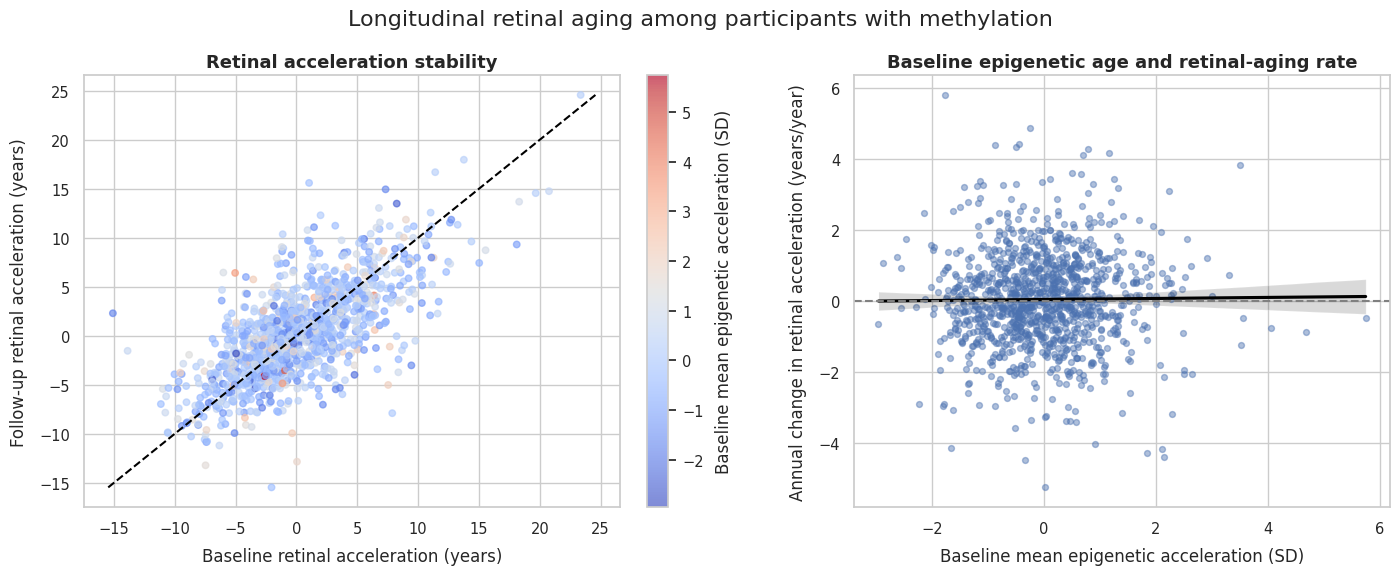

{'eye_level_reliability_available': False, 'reason': 'The configured RETFound input is already aggregated to one embedding per participant-visit. Left/right eye predictions must be computed from the image-level embedding batches.', 'participant_visit_longitudinal_analysis_available': True, 'n_longitudinal_three_clock_participants': 1135}


In [0]:
retinal_visit = chronological_oof[
    [
        "participant_id",
        "visit",
        "chronological_age",
        "retinal_age_oof",
    ]
].copy()
(
    retinal_visit["retinal_acceleration_cf_visit"],
    retinal_visit["retinal_expected_cf_visit"],
) = cross_fitted_spline_residual(
    retinal_visit,
    "retinal_age_oof",
    "chronological_age",
    "participant_id",
)
baseline_retinal = retinal_visit[
    retinal_visit["visit"].eq("BL")
].rename(
    columns={
        "chronological_age": "chronological_age_bl",
        "retinal_age_oof": "retinal_age_bl",
        "retinal_acceleration_cf_visit": (
            "retinal_acceleration_bl"
        ),
    }
)
followup_retinal = retinal_visit[
    retinal_visit["visit"].eq("F1")
].rename(
    columns={
        "chronological_age": "chronological_age_f1",
        "retinal_age_oof": "retinal_age_f1",
        "retinal_acceleration_cf_visit": (
            "retinal_acceleration_f1"
        ),
    }
)
longitudinal = baseline_retinal[
    [
        "participant_id",
        "chronological_age_bl",
        "retinal_age_bl",
        "retinal_acceleration_bl",
    ]
].merge(
    followup_retinal[
        [
            "participant_id",
            "chronological_age_f1",
            "retinal_age_f1",
            "retinal_acceleration_f1",
        ]
    ],
    on="participant_id",
    how="inner",
    validate="one_to_one",
)
longitudinal["followup_years"] = (
    longitudinal["chronological_age_f1"]
    - longitudinal["chronological_age_bl"]
)
longitudinal = longitudinal[
    longitudinal["followup_years"].between(0.25, 15)
].copy()
longitudinal["retinal_acceleration_change"] = (
    longitudinal["retinal_acceleration_f1"]
    - longitudinal["retinal_acceleration_bl"]
)
longitudinal["retinal_acceleration_change_per_year"] = (
    longitudinal["retinal_acceleration_change"]
    / longitudinal["followup_years"]
)
phenotype_columns = [
    "participant_id",
    "z_retinal_acceleration",
    "z_horvath_acceleration",
    "z_hannum_acceleration",
    "z_epigenetic_mean_acceleration",
    "shared_aging_pc",
    "retina_vs_epigenetic_pc",
    *association_categorical_columns,
]
longitudinal = longitudinal.merge(
    tri_age[phenotype_columns],
    on="participant_id",
    how="inner",
    validate="one_to_one",
)

longitudinal_model_definitions = {
    "mean_epigenetic_acceleration": [
        "z_epigenetic_mean_acceleration"
    ],
    "separate_epigenetic_clocks": [
        "z_horvath_acceleration",
        "z_hannum_acceleration",
    ],
    "orthogonal_shared_and_discordant": [
        "shared_aging_pc",
        "retina_vs_epigenetic_pc",
    ],
}
longitudinal_rows = []
longitudinal_failures = []
longitudinal_covariates = [
    "retinal_acceleration_bl",
    "chronological_age_bl",
    "followup_years",
    *[
        f"C({column})"
        for column in association_categorical_columns
    ],
]
for model_name, predictors in (
    longitudinal_model_definitions.items()
):
    formula = (
        "retinal_acceleration_f1 ~ "
        + " + ".join([*longitudinal_covariates, *predictors])
    )
    try:
        fit = smf.ols(
            formula,
            data=longitudinal,
            missing="drop",
        ).fit(cov_type="HC3")
        confidence = fit.conf_int()
        for predictor in predictors:
            longitudinal_rows.append(
                {
                    "model": model_name,
                    "predictor": predictor,
                    "n": int(fit.nobs),
                    "coefficient": float(fit.params[predictor]),
                    "ci_low": float(confidence.loc[predictor, 0]),
                    "ci_high": float(confidence.loc[predictor, 1]),
                    "p_value": float(fit.pvalues[predictor]),
                    "outcome": "follow-up retinal acceleration",
                }
            )
    except Exception as error:
        longitudinal_failures.append(
            {
                "model": model_name,
                "status": f"failed:{type(error).__name__}",
                "error_message": str(error)[:500],
            }
        )
longitudinal_associations = pd.DataFrame(longitudinal_rows)
if not longitudinal_associations.empty:
    longitudinal_associations["fdr_q_value"] = (
        benjamini_hochberg(
            longitudinal_associations[
                "p_value"
            ].to_numpy(float)
        )
    )
write_frame(
    longitudinal,
    private_root / "longitudinal_retinal_aging_private.parquet",
)
write_frame(
    longitudinal_associations,
    statistics_root
    / "baseline_epigenetic_to_followup_retinal_associations.csv",
)
write_frame(
    pd.DataFrame(longitudinal_failures),
    statistics_root / "longitudinal_model_failures.csv",
)
display(longitudinal_associations.round(5))

if not longitudinal.empty:
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.8),
        layout="constrained",
    )
    color = longitudinal["z_epigenetic_mean_acceleration"]
    scatter = axes[0].scatter(
        longitudinal["retinal_acceleration_bl"],
        longitudinal["retinal_acceleration_f1"],
        c=color,
        cmap="coolwarm",
        s=22,
        alpha=0.65,
    )
    limits = [
        float(
            longitudinal[
                [
                    "retinal_acceleration_bl",
                    "retinal_acceleration_f1",
                ]
            ].min().min()
        ),
        float(
            longitudinal[
                [
                    "retinal_acceleration_bl",
                    "retinal_acceleration_f1",
                ]
            ].max().max()
        ),
    ]
    axes[0].plot(limits, limits, "--", color="black")
    axes[0].set(
        title="Retinal acceleration stability",
        xlabel="Baseline retinal acceleration (years)",
        ylabel="Follow-up retinal acceleration (years)",
    )
    figure.colorbar(
        scatter,
        ax=axes[0],
        label="Baseline mean epigenetic acceleration (SD)",
    )
    sns.regplot(
        data=longitudinal,
        x="z_epigenetic_mean_acceleration",
        y="retinal_acceleration_change_per_year",
        scatter_kws={"s": 18, "alpha": 0.45},
        line_kws={"color": "black"},
        ax=axes[1],
    )
    axes[1].axhline(0, color="gray", linestyle="--")
    axes[1].set(
        title="Baseline epigenetic age and retinal-aging rate",
        xlabel="Baseline mean epigenetic acceleration (SD)",
        ylabel="Annual change in retinal acceleration (years/year)",
    )
    figure.suptitle(
        "Longitudinal retinal aging among participants with methylation",
    )
    prepare_publication_figure(figure)
    figure.savefig(
        figure_root / "figure_12_longitudinal_retinal_aging.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.25,
    )
    plt.show()
    plt.close(figure)

reliability_capability = {
    "eye_level_reliability_available": False,
    "reason": (
        "The configured RETFound input is already aggregated to one "
        "embedding per participant-visit. Left/right eye predictions "
        "must be computed from the image-level embedding batches."
    ),
    "participant_visit_longitudinal_analysis_available": bool(
        len(longitudinal) > 0
    ),
    "n_longitudinal_three_clock_participants": int(
        longitudinal["participant_id"].nunique()
    ),
}
write_json(
    reliability_capability,
    statistics_root / "reliability_capability.json",
)
print(reliability_capability)

In [ ]:
# Persistence-only Figure 5A coordinates from the already-computed fit.
# Restore statsmodels immediately; this cell does not fit or update a model.
smf.ols = _clsa_original_smf_ols
primary_longitudinal_formula = (
    "retinal_acceleration_f1 ~ "
    + " + ".join(
        [
            *longitudinal_covariates,
            "z_epigenetic_mean_acceleration",
        ]
    )
)
if primary_longitudinal_formula not in _clsa_longitudinal_fit_capture:
    raise RuntimeError(
        "The primary longitudinal fit was not captured. Re-run the capture "
        "cell immediately before notebook cell 39, then cell 39 itself."
    )
primary_longitudinal_fit = _clsa_longitudinal_fit_capture[
    primary_longitudinal_formula
]
primary_predictor = "z_epigenetic_mean_acceleration"
used_index = primary_longitudinal_fit.model.data.row_labels
used = longitudinal.loc[used_index, [primary_predictor]].copy()
used["model_residual"] = np.asarray(
    primary_longitudinal_fit.resid,
    dtype=float,
)
primary_beta = float(primary_longitudinal_fit.params[primary_predictor])
primary_ci = primary_longitudinal_fit.conf_int().loc[primary_predictor]
used["partial_residual_epigenetic"] = used[primary_predictor]
used["partial_residual_followup_retinal"] = (
    used["model_residual"]
    + primary_beta * used[primary_predictor]
)
used["fitted"] = primary_beta * used[primary_predictor]
ci_first = float(primary_ci.iloc[0]) * used[primary_predictor]
ci_second = float(primary_ci.iloc[1]) * used[primary_predictor]
used["ci_low"] = np.minimum(ci_first, ci_second)
used["ci_high"] = np.maximum(ci_first, ci_second)
write_frame(
    used[
        [
            "partial_residual_epigenetic",
            "partial_residual_followup_retinal",
            "fitted",
            "ci_low",
            "ci_high",
        ]
    ].sort_values(
        "partial_residual_epigenetic",
        kind="stable",
    ),
    statistics_root / "figure_05a_partial_residual_points.parquet",
)
write_frame(
    pd.DataFrame(
        [
            {
                "output": "figure_05a_partial_residual_points.parquet",
                "status": "captured_from_existing_primary_fit_without_refit",
                "source_cell": 39,
            }
        ]
    ),
    statistics_root / "figure_05a_partial_residual_status.csv",
)


## 17. Locked discovery/validation confirmation and calibration

A deterministic 70:30 participant split creates a locked validation set.
The age head is fit only in discovery participants; discovery predictions
are grouped out of fold and validation predictions come from the frozen
discovery model. A nonlinear calibration curve is learned from discovery
OOF predictions only, then applied unchanged to validation. This is the
internal confirmation analysis available in CLSA; it is not a substitute
for replication in an external cohort.

Resumed retfound_chronological_age_discovery_only: 37,471 OOF rows


analysis,n,target_mean,target_sd,prediction_mean,prediction_sd,mae,median_absolute_error,rmse,r2,pearson_r,pearson_p,spearman_rho,spearman_p,calibration_slope,calibration_intercept,mean_error,sd_error,ccc
Discovery grouped OOF: original,20164,62.7771,10.164,63.1715,8.4675,4.3411,3.5822,5.5259,0.7044,0.8402,0.0,0.8483,0.0,0.7,19.2293,0.3943,5.512,0.8257
Discovery grouped OOF: discovery-calibrated,20164,62.7771,10.164,62.7773,8.5857,4.2586,3.5045,5.4302,0.7146,0.8453,0.0,0.8482,0.0,0.714,17.9514,2.0E-4,5.4303,0.8334
Locked validation: original,8342,62.6932,10.1957,63.181,8.5017,4.3727,3.5839,5.5898,0.6994,0.8377,0.0,0.8449,0.0,0.6985,19.3901,0.4877,5.5688,0.8229
Locked validation: discovery-calibrated,8342,62.6932,10.1957,62.8077,8.6111,4.274,3.4623,5.4843,0.7106,0.8431,0.0,0.8449,0.0,0.712,18.1678,0.1145,5.4835,0.8311


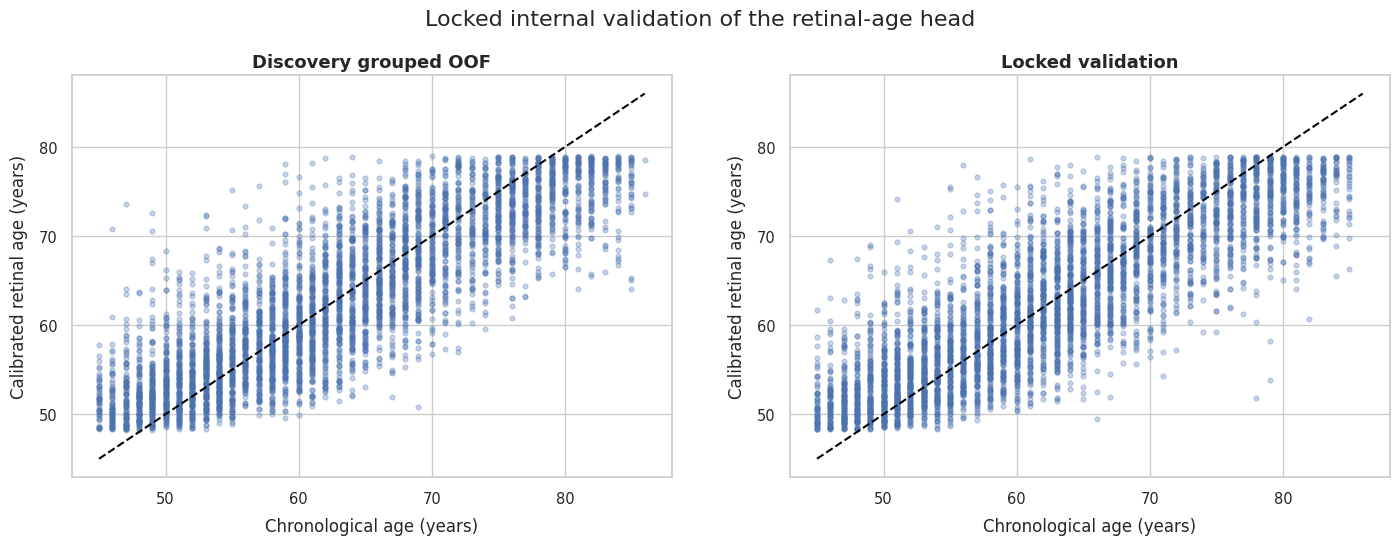

In [0]:
def deterministic_fraction(value, salt):
    digest = hashlib.sha256(
        f"{salt}|{value}".encode("utf-8")
    ).hexdigest()
    return int(digest[:16], 16) / float(16 ** 16)


baseline_model_frame = participant_visit[
    participant_visit["visit"].eq("BL")
    & participant_visit["chronological_age"].notna()
].copy()
all_model_participants = sorted(
    chronological_training["participant_id"].astype(str).unique()
)
validation_ids = {
    participant_id
    for participant_id in all_model_participants
    if deterministic_fraction(
        participant_id,
        "epigenetics-locked-validation-20260903",
    ) < locked_validation_fraction
}
discovery_ids = set(all_model_participants) - validation_ids
if not discovery_ids or not validation_ids:
    raise ValueError("The deterministic discovery/validation split is empty")

discovery_training = chronological_training[
    chronological_training["participant_id"].astype(str).isin(discovery_ids)
].copy()
discovery_oof_raw, discovery_bundle = fit_or_resume_head(
    discovery_training,
    "chronological_age",
    "retfound_chronological_age_discovery_only",
)
discovery_locked = discovery_oof_raw.rename(
    columns={
        "age": "chronological_age",
        "retinal_age_prediction_oof": "retinal_age_precalibration",
    }
)
discovery_locked["participant_id"] = normalize_identifier(
    discovery_locked["participant_id"]
)
discovery_locked["visit"] = normalize_visit(discovery_locked["visit"])
discovery_locked = discovery_locked[
    discovery_locked["visit"].eq("BL")
].copy()

validation_input = baseline_model_frame[
    baseline_model_frame["participant_id"].astype(str).isin(validation_ids)
][
    [
        "participant_id",
        "visit",
        "chronological_age",
        "embedding",
        "n_embedded_images",
    ]
].rename(columns={"chronological_age": "age"})
validation_locked = _fundus.predict_retinal_age(
    validation_input,
    discovery_bundle,
).rename(
    columns={
        "age": "chronological_age",
        "retinal_age_prediction": "retinal_age_precalibration",
    }
)

def make_age_calibrator():
    return Pipeline(
        [
            (
                "spline",
                SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False,
                    extrapolation="linear",
                ),
            ),
            ("ridge", Ridge(alpha=1.0)),
        ]
    )


discovery_locked["retinal_age_locked"] = np.nan
discovery_groups = discovery_locked["participant_id"].astype(str).to_numpy()
discovery_splitter = GroupKFold(
    n_splits=min(cv_folds, len(np.unique(discovery_groups)))
)
calibration_x = discovery_locked[
    ["retinal_age_precalibration"]
].to_numpy(float)
calibration_y = discovery_locked["chronological_age"].to_numpy(float)
for calibration_train, calibration_test in discovery_splitter.split(
    calibration_x,
    calibration_y,
    discovery_groups,
):
    fold_calibrator = make_age_calibrator()
    fold_calibrator.fit(
        calibration_x[calibration_train],
        calibration_y[calibration_train],
    )
    discovery_locked.iloc[
        calibration_test,
        discovery_locked.columns.get_loc("retinal_age_locked"),
    ] = fold_calibrator.predict(calibration_x[calibration_test])

frozen_calibrator = make_age_calibrator()
frozen_calibrator.fit(calibration_x, calibration_y)
validation_locked["retinal_age_locked"] = frozen_calibrator.predict(
    validation_locked[["retinal_age_precalibration"]].to_numpy(float)
)
for frame, phase in (
    (discovery_locked, "Discovery grouped OOF"),
    (validation_locked, "Locked validation"),
):
    frame["analysis_phase"] = phase
    frame["retinal_age_gap_locked"] = (
        frame["retinal_age_locked"] - frame["chronological_age"]
    )

locked_predictions = pd.concat(
    [discovery_locked, validation_locked],
    ignore_index=True,
)
locked_prediction_metrics = pd.DataFrame(
    [
        regression_metrics(
            frame,
            "chronological_age",
            prediction,
            f"{phase}: {label}",
        )
        for frame, phase in (
            (discovery_locked, "Discovery grouped OOF"),
            (validation_locked, "Locked validation"),
        )
        for prediction, label in (
            ("retinal_age_precalibration", "original"),
            ("retinal_age_locked", "discovery-calibrated"),
        )
    ]
)
write_frame(
    locked_predictions,
    private_root / "locked_discovery_validation_predictions_private.parquet",
)
write_frame(
    locked_prediction_metrics,
    statistics_root / "locked_discovery_validation_metrics.csv",
)
joblib.dump(
    {
        "age_head": discovery_bundle,
        "discovery_oof_calibrator": frozen_calibrator,
        "validation_fraction": locked_validation_fraction,
        "split_salt": "epigenetics-locked-validation-20260903",
    },
    model_root / "locked_discovery_age_model.joblib",
)
display(locked_prediction_metrics.round(4))

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    layout="constrained",
)
for axis, (phase, frame) in zip(
    axes,
    (
        ("Discovery grouped OOF", discovery_locked),
        ("Locked validation", validation_locked),
    ),
):
    sample = frame.sample(
        min(maximum_scatter_points, len(frame)),
        random_state=random_state,
    )
    axis.scatter(
        sample["chronological_age"],
        sample["retinal_age_locked"],
        s=12,
        alpha=0.30,
        color="#4C72B0",
    )
    lower = float(
        min(frame["chronological_age"].min(), frame["retinal_age_locked"].min())
    )
    upper = float(
        max(frame["chronological_age"].max(), frame["retinal_age_locked"].max())
    )
    axis.plot([lower, upper], [lower, upper], "--", color="black")
    axis.set(
        title=phase,
        xlabel="Chronological age (years)",
        ylabel="Calibrated retinal age (years)",
    )
figure.suptitle("Locked internal validation of the retinal-age head")
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_13_locked_internal_validation.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()
plt.close(figure)

In [ ]:
# Persistence-only input for Figure 1; identifiers are excluded.
write_frame(
    locked_predictions[
        ["analysis_phase", "chronological_age", "retinal_age_locked"]
    ].sort_values(
        ["analysis_phase", "chronological_age", "retinal_age_locked"],
        kind="stable",
    ),
    statistics_root / "figure_01_locked_validation_points.parquet",
)


## 18. Full-retinal-cohort questionnaire discovery and confirmation

The raw baseline file is checkpointed in narrow row batches for every
participant with a baseline retinal prediction. Variables are then read
in 50-column blocks. Discovery uses only discovery participants; candidate
constructs are collapsed before FDR using a Simes omnibus p-value, and
only the representative variable for a discovered construct is judged in
the locked validation set. This expands retinal-only analyses beyond the
1,406-person methylation subset while preserving the subset comparison.

In [0]:
locked_covariate_columns = [
    column
    for column in (
        "participant_id",
        "sex_labeled",
        "racial_background",
        "ethnicity_spirometry_labeled",
        "smoking_status",
        "bmi",
        "body_mass_index",
        "diabetes",
        "hypertension",
        "education_level_sap_harmonized",
        "household_income_band",
    )
    if column in baseline_model_frame.columns
]
locked_analysis = locked_predictions.merge(
    baseline_model_frame[locked_covariate_columns].drop_duplicates(
        "participant_id"
    ),
    on="participant_id",
    how="left",
    validate="one_to_one",
)
locked_analysis["is_epigenetic_subset"] = locked_analysis[
    "participant_id"
].isin(set(epigenetic["participant_id"].astype(str)))
locked_analysis["log_n_embedded_images"] = np.log1p(
    pd.to_numeric(locked_analysis["n_embedded_images"], errors="coerce")
)
for continuous_column in ("bmi", "body_mass_index"):
    if continuous_column in locked_analysis:
        locked_analysis[continuous_column] = pd.to_numeric(
            locked_analysis[continuous_column], errors="coerce"
        )
for binary_column in ("diabetes", "hypertension"):
    if binary_column in locked_analysis:
        locked_analysis[binary_column] = coerce_binary(
            locked_analysis[binary_column]
        )

retinal_scan_bmi_column = next(
    (
        column
        for column in ("bmi", "body_mass_index")
        if column in locked_analysis
        and locked_analysis[column].notna().sum() >= 100
        and locked_analysis[column].nunique(dropna=True) > 1
    ),
    None,
)
retinal_scan_continuous_covariates = [
    column
    for column in (
        retinal_scan_bmi_column,
        "diabetes",
        "hypertension",
    )
    if column is not None
    and column in locked_analysis
    and locked_analysis[column].notna().sum() >= 100
    and locked_analysis[column].nunique(dropna=True) > 1
]
retinal_scan_categorical_covariates = [
    column
    for column in (
        "sex_labeled",
        "racial_background",
        "ethnicity_spirometry_labeled",
        "smoking_status",
        "education_level_sap_harmonized",
        "household_income_band",
    )
    if column in locked_analysis
    and locked_analysis[column].notna().sum() >= 100
    and locked_analysis[column].nunique(dropna=True) > 1
]
retinal_scan_adjustment_columns = [
    *retinal_scan_categorical_covariates,
    *retinal_scan_continuous_covariates,
]

full_questionnaire_schema_token = hashlib.sha256(
    (
        source_signature(baseline_archive_path)
        + "|full-retinal|"
        + "|".join(questionnaire_source_columns)
    ).encode("utf-8")
).hexdigest()[:12]
full_questionnaire_batch_root = (
    checkpoint_root
    / "questionnaire_full_retinal_fields"
    / f"schema_{full_questionnaire_schema_token}"
)
full_questionnaire_ids = set(
    locked_analysis["participant_id"].astype(str)
)
full_questionnaire_cohort_token = hashlib.sha256(
    "|".join(sorted(full_questionnaire_ids)).encode("utf-8")
).hexdigest()[:12]
full_questionnaire_batch_root = (
    full_questionnaire_batch_root
    / f"cohort_{full_questionnaire_cohort_token}"
)
full_questionnaire_batch_root.mkdir(parents=True, exist_ok=True)
full_questionnaire_batch_paths = []
full_questionnaire_manifest_rows = []
scanned_full_rows = 0
with zipfile.ZipFile(baseline_archive_path) as archive:
    with archive.open(baseline_member) as stream:
        for batch_number, raw_chunk in enumerate(
            pd.read_csv(
                stream,
                dtype="string",
                chunksize=questionnaire_row_chunk_size,
                low_memory=False,
            ),
            1,
        ):
            start_row = scanned_full_rows
            scanned_full_rows += len(raw_chunk)
            stop_row = scanned_full_rows
            batch_path = full_questionnaire_batch_root / (
                f"rows_{start_row:09d}_{stop_row:09d}.parquet"
            )
            if resume_completed_outputs and batch_path.is_file():
                status = "resumed"
            else:
                raw_chunk[baseline_id_column] = normalize_identifier(
                    raw_chunk[baseline_id_column]
                )
                retained = raw_chunk[
                    raw_chunk[baseline_id_column].isin(full_questionnaire_ids)
                ].rename(columns={baseline_id_column: "participant_id"})
                retained.attrs = {}
                write_frame(retained, batch_path)
                status = "written"
            full_questionnaire_batch_paths.append(batch_path)
            retained_n = len(
                pd.read_parquet(batch_path, columns=["participant_id"])
            )
            full_questionnaire_manifest_rows.append(
                {
                    "batch_number": batch_number,
                    "start_row": start_row,
                    "stop_row": stop_row,
                    "retained_rows": retained_n,
                    "status": status,
                    "path": str(batch_path),
                }
            )
            if batch_number == 1 or batch_number % 10 == 0:
                print(
                    f"[full questionnaire rows {batch_number}] {status}; "
                    f"source rows {start_row:,}:{stop_row:,}",
                    flush=True,
                )
write_frame(
    pd.DataFrame(full_questionnaire_manifest_rows),
    statistics_root / "full_questionnaire_row_batch_manifest.csv",
)

def load_full_questionnaire_columns(columns):
    requested = ["participant_id", *list(dict.fromkeys(columns))]
    frames = [
        pd.read_parquet(path, columns=requested)
        for path in full_questionnaire_batch_paths
    ]
    result = pd.concat(frames, ignore_index=True)
    result["participant_id"] = normalize_identifier(result["participant_id"])
    if result["participant_id"].duplicated().any():
        result = result.groupby("participant_id", as_index=False).agg(
            {column: stable_value for column in requested[1:]}
        )
    return result


full_scan_root = checkpoint_root / "full_questionnaire_column_scans"
full_scan_model_version = "v3_rank_pruned_covariates"
full_scan_root = full_scan_root / full_scan_model_version
full_scan_root.mkdir(parents=True, exist_ok=True)
full_scan_rows = []
full_scan_failures = []
full_scan_result_columns = [
    "phase",
    "variable",
    "variable_label",
    "analysis_type",
    "construct_family",
    "n",
    "incremental_r2",
    "p_value",
    "df_difference",
    "is_epigenetic_subset_n",
    "adjustment_terms",
    "adjustment_terms_count",
    "standardized_coefficient",
    "coefficient_ci_low",
    "coefficient_ci_high",
]
full_scan_failure_columns = [
    "variable",
    "phase",
    "status",
    "error_message",
]
upper_missing_codes_full = {
    str(code).upper() for code in questionnaire_missing_codes
}

def fit_retinal_questionnaire_model(data, variable, phase):
    raw = data[variable].astype("string").str.strip()
    cleaned = raw.mask(
        raw.str.upper().isin(upper_missing_codes_full) | raw.isna()
    )
    observed = int(cleaned.notna().sum())
    unique = int(cleaned.nunique(dropna=True))
    if observed < minimum_questionnaire_observed or unique < 2:
        return None, "insufficient_data"
    numeric = pd.to_numeric(cleaned, errors="coerce")
    numeric_fraction = float(numeric.notna().sum() / observed)
    work = data[
        [
            "retinal_age_gap_locked",
            "chronological_age",
            "log_n_embedded_images",
            "is_epigenetic_subset",
        ]
        + retinal_scan_adjustment_columns
    ].copy()
    if numeric_fraction >= 0.95 and unique > 10:
        work["question_value"] = safe_zscore(numeric)
        variable_type = "numeric"
        question_term = "question_value"
    elif unique <= maximum_questionnaire_categorical_levels:
        counts = cleaned.value_counts()
        retained_levels = counts[
            counts >= minimum_questionnaire_level_n
        ].index
        collapsed = cleaned.where(
            cleaned.isna() | cleaned.isin(retained_levels),
            "Other/low-frequency",
        )
        work["question_category"] = collapsed.astype("object")
        if work["question_category"].nunique(dropna=True) < 2:
            return None, "fewer_than_two_levels"
        variable_type = "categorical"
        question_term = "C(question_category)"
    else:
        return None, "high_cardinality"

    work["chronological_age"] = pd.to_numeric(
        work["chronological_age"], errors="coerce"
    )
    work["log_n_embedded_images"] = pd.to_numeric(
        work["log_n_embedded_images"], errors="coerce"
    )
    for column in retinal_scan_categorical_covariates:
        work[column] = (
            work[column]
            .astype("string")
            .fillna("Missing")
            .astype(str)
        )
    for column in retinal_scan_continuous_covariates:
        work[column] = pd.to_numeric(work[column], errors="coerce")
        if work[column].notna().any():
            work[column] = work[column].fillna(work[column].median())

    question_column = (
        "question_value"
        if variable_type == "numeric"
        else "question_category"
    )
    complete_work = work.dropna(
        subset=[
            "retinal_age_gap_locked",
            "chronological_age",
            question_column,
        ]
    ).copy()
    if len(complete_work) < minimum_questionnaire_observed:
        return None, "insufficient_complete_cases"

    required_covariates = [
        "chronological_age",
        "I(chronological_age ** 2)",
    ]
    optional_covariates = []
    if complete_work["log_n_embedded_images"].nunique(dropna=True) > 1:
        optional_covariates.append("log_n_embedded_images")
    optional_covariates.extend(
        f"C({column})"
        for column in retinal_scan_categorical_covariates
        if complete_work[column].nunique(dropna=True) > 1
    )
    optional_covariates.extend(
        column
        for column in retinal_scan_continuous_covariates
        if complete_work[column].nunique(dropna=True) > 1
    )

    def full_rank(formula):
        candidate = smf.ols(formula, data=complete_work)
        return (
            np.linalg.matrix_rank(candidate.exog)
            == candidate.exog.shape[1]
        )


    selected_covariates = required_covariates.copy()
    minimal_full_formula = (
        "retinal_age_gap_locked ~ "
        + " + ".join([*selected_covariates, question_term])
    )
    if not full_rank(minimal_full_formula):
        return None, "question_or_required_terms_rank_deficient"
    for candidate_term in optional_covariates:
        candidate_formula = (
            "retinal_age_gap_locked ~ "
            + " + ".join(
                [*selected_covariates, candidate_term, question_term]
            )
        )
        if full_rank(candidate_formula):
            selected_covariates.append(candidate_term)

    base_formula = (
        "retinal_age_gap_locked ~ "
        + " + ".join(selected_covariates)
    )
    full_formula = base_formula + " + " + question_term
    base_model = smf.ols(base_formula, data=complete_work)
    full_model = smf.ols(full_formula, data=complete_work)
    base = base_model.fit()
    full = full_model.fit(cov_type="HC3")
    classical = full_model.fit()
    nested_f, nested_p, nested_df = classical.compare_f_test(base)
    row = {
        "phase": phase,
        "variable": variable,
        "variable_label": clsa_variable_label(variable),
        "analysis_type": variable_type,
        "construct_family": questionnaire_construct_family(variable),
        "n": int(classical.nobs),
        "incremental_r2": float(classical.rsquared - base.rsquared),
        "p_value": float(nested_p),
        "df_difference": float(nested_df),
        "is_epigenetic_subset_n": int(
            complete_work["is_epigenetic_subset"].sum()
        ),
        "adjustment_terms": " | ".join(selected_covariates),
        "adjustment_terms_count": int(len(selected_covariates)),
    }
    if variable_type == "numeric":
        confidence = full.conf_int().loc["question_value"]
        row.update(
            {
                "standardized_coefficient": float(full.params["question_value"]),
                "coefficient_ci_low": float(confidence.iloc[0]),
                "coefficient_ci_high": float(confidence.iloc[1]),
            }
        )
    return row, "analyzed"


excluded_full_questionnaire = (
    set(questionnaire_reserved_columns)
    | questionnaire_explicit_exclusions
)
for column_start in range(
    0,
    len(questionnaire_source_columns),
    full_questionnaire_column_batch_size,
):
    column_stop = min(
        column_start + full_questionnaire_column_batch_size,
        len(questionnaire_source_columns),
    )
    variables = questionnaire_source_columns[column_start:column_stop]
    batch_result_path = full_scan_root / (
        f"columns_{column_start:05d}_{column_stop:05d}.csv"
    )
    batch_failure_path = full_scan_root / (
        f"columns_{column_start:05d}_{column_stop:05d}_failures.csv"
    )
    if resume_completed_outputs and batch_result_path.is_file():
        try:
            batch_results = pd.read_csv(batch_result_path)
        except pd.errors.EmptyDataError:
            batch_results = pd.DataFrame()
        try:
            batch_failures = (
                pd.read_csv(batch_failure_path)
                if batch_failure_path.is_file()
                and batch_failure_path.stat().st_size > 0
                else pd.DataFrame()
            )
        except pd.errors.EmptyDataError:
            batch_failures = pd.DataFrame()
        status = "resumed"
    else:
        values = load_full_questionnaire_columns(variables)
        analysis_values = locked_analysis.merge(
            values,
            on="participant_id",
            how="left",
            validate="one_to_one",
        )
        result_rows = []
        failure_rows = []
        for variable in variables:
            if (
                variable in excluded_full_questionnaire
                or questionnaire_identifier_pattern.search(variable)
                or questionnaire_time_pattern.search(variable)
                or questionnaire_procedural_pattern.search(variable)
            ):
                failure_rows.append(
                    {"variable": variable, "status": "prespecified_exclusion"}
                )
                continue
            for phase in ("Discovery grouped OOF", "Locked validation"):
                phase_data = analysis_values[
                    analysis_values["analysis_phase"].eq(phase)
                ].copy()
                try:
                    result, model_status = fit_retinal_questionnaire_model(
                        phase_data,
                        variable,
                        phase,
                    )
                    if result is not None:
                        result_rows.append(result)
                    else:
                        failure_rows.append(
                            {
                                "variable": variable,
                                "phase": phase,
                                "status": model_status,
                            }
                        )
                except Exception as error:
                    failure_rows.append(
                        {
                            "variable": variable,
                            "phase": phase,
                            "status": f"failed:{type(error).__name__}",
                            "error_message": str(error)[:500],
                        }
                    )
        batch_results = pd.DataFrame(
            result_rows,
            columns=full_scan_result_columns,
        )
        batch_failures = pd.DataFrame(
            failure_rows,
            columns=full_scan_failure_columns,
        )
        write_frame(batch_results, batch_result_path)
        write_frame(batch_failures, batch_failure_path)
        status = "written"
        del values, analysis_values
        gc.collect()
    if not batch_results.empty:
        if "variable_label" not in batch_results.columns:
            batch_results["variable_label"] = (
                batch_results["variable"].map(clsa_variable_label)
            )
        full_scan_rows.append(batch_results)
    if not batch_failures.empty:
        full_scan_failures.append(batch_failures)
    print(
        f"[full questionnaire columns {column_start}:{column_stop}] "
        f"{status}; successful models={len(batch_results):,}; "
        f"skips/failures={len(batch_failures):,}",
        flush=True,
    )
    if batch_results.empty and not batch_failures.empty:
        print(
            batch_failures["status"]
            .fillna("unknown")
            .value_counts()
            .head(8)
            .to_dict(),
            flush=True,
        )

full_questionnaire_tests = (
    pd.concat(full_scan_rows, ignore_index=True)
    if full_scan_rows
    else pd.DataFrame()
)
if not full_questionnaire_tests.empty:
    full_questionnaire_tests["variable_label"] = (
        full_questionnaire_tests["variable"].map(clsa_variable_label)
    )
full_questionnaire_failures = (
    pd.concat(full_scan_failures, ignore_index=True)
    if full_scan_failures
    else pd.DataFrame(columns=full_scan_failure_columns)
)
write_frame(
    full_questionnaire_failures,
    statistics_root / "full_retinal_questionnaire_failures.csv",
)
if full_questionnaire_tests.empty:
    failure_summary = (
        full_questionnaire_failures["status"]
        .fillna("unknown")
        .value_counts(dropna=False)
        .rename_axis("status")
        .reset_index(name="variable_phase_count")
    )
    write_frame(
        failure_summary,
        statistics_root / "full_retinal_questionnaire_empty_scan_diagnostic.csv",
    )
    display(failure_summary)
    raise RuntimeError(
        "No full-retinal questionnaire models completed. The diagnostic "
        "table above and full_retinal_questionnaire_failures.csv contain "
        "the model-status distribution. Empty v1 checkpoints are not "
        "reused by the current scan version."
    )
discovery_questionnaire_tests = full_questionnaire_tests[
    full_questionnaire_tests["phase"].eq("Discovery grouped OOF")
].copy()
discovery_questionnaire_tests["construct_key"] = (
    discovery_questionnaire_tests["construct_family"].fillna(
        discovery_questionnaire_tests["variable"]
    )
)

def simes_p_value(values):
    p_values = np.sort(pd.to_numeric(values, errors="coerce").dropna().to_numpy(float))
    if len(p_values) == 0:
        return np.nan
    return float(min(1.0, np.min(p_values * len(p_values) / np.arange(1, len(p_values) + 1))))


construct_rows = []
for construct, group in discovery_questionnaire_tests.groupby("construct_key"):
    representative = group.sort_values("p_value").iloc[0]
    construct_rows.append(
        {
            "construct_key": construct,
            "representative_variable": representative["variable"],
            "representative_label": clsa_variable_label(
                representative["variable"]
            ),
            "representative_type": representative["analysis_type"],
            "discovery_n": int(representative["n"]),
            "discovery_coefficient": representative.get("standardized_coefficient", np.nan),
            "discovery_incremental_r2": float(representative["incremental_r2"]),
            "n_component_variables": int(len(group)),
            "discovery_construct_p": simes_p_value(group["p_value"]),
        }
    )
construct_confirmation = pd.DataFrame(construct_rows)
if not construct_confirmation.empty:
    construct_confirmation["discovery_fdr_q"] = benjamini_hochberg(
        construct_confirmation["discovery_construct_p"].to_numpy(float)
    )
    validation_lookup = full_questionnaire_tests[
        full_questionnaire_tests["phase"].eq("Locked validation")
    ].set_index("variable")
    construct_confirmation["validation_n"] = construct_confirmation[
        "representative_variable"
    ].map(validation_lookup["n"])
    construct_confirmation["validation_p"] = construct_confirmation[
        "representative_variable"
    ].map(validation_lookup["p_value"])
    construct_confirmation["validation_incremental_r2"] = construct_confirmation[
        "representative_variable"
    ].map(validation_lookup["incremental_r2"])
    construct_confirmation["validation_coefficient"] = construct_confirmation[
        "representative_variable"
    ].map(validation_lookup.get("standardized_coefficient", pd.Series(dtype=float)))
    discovered_count = max(
        1,
        int(construct_confirmation["discovery_fdr_q"].lt(0.05).sum()),
    )
    construct_confirmation["validation_bonferroni_threshold"] = 0.05 / discovered_count
    same_direction = (
        np.sign(construct_confirmation["discovery_coefficient"])
        == np.sign(construct_confirmation["validation_coefficient"])
    ) | construct_confirmation["representative_type"].eq("categorical")
    construct_confirmation["confirmed_locked_validation"] = (
        construct_confirmation["discovery_fdr_q"].lt(0.05)
        & construct_confirmation["validation_p"].lt(
            construct_confirmation["validation_bonferroni_threshold"]
        )
        & same_direction
    )
write_frame(
    full_questionnaire_tests,
    statistics_root / "full_retinal_questionnaire_variable_tests.csv",
)
write_frame(
    full_questionnaire_failures,
    statistics_root / "full_retinal_questionnaire_failures.csv",
)
write_frame(
    construct_confirmation,
    statistics_root / "locked_construct_confirmation.csv",
)
display(
    construct_confirmation.sort_values(
        ["confirmed_locked_validation", "discovery_fdr_q"],
        ascending=[False, True],
    ).head(50)
)

[full questionnaire rows 1] resumed; source rows 0:500
[full questionnaire rows 10] resumed; source rows 4,500:5,000
[full questionnaire rows 20] resumed; source rows 9,500:10,000
[full questionnaire rows 30] resumed; source rows 14,500:15,000
[full questionnaire rows 40] resumed; source rows 19,500:20,000
[full questionnaire rows 50] resumed; source rows 24,500:25,000
[full questionnaire rows 60] resumed; source rows 29,500:30,000
[full questionnaire columns 0:50] resumed; successful models=84; skips/failures=14
[full questionnaire columns 50:100] resumed; successful models=90; skips/failures=10
[full questionnaire columns 100:150] resumed; successful models=76; skips/failures=24
[full questionnaire columns 150:200] resumed; successful models=74; skips/failures=26
[full questionnaire columns 200:250] resumed; successful models=98; skips/failures=2
[full questionnaire columns 250:300] resumed; successful models=97; skips/failures=3
[full questionnaire columns 300:350] resumed; successf

construct_key,representative_variable,representative_label,representative_type,discovery_n,discovery_coefficient,discovery_incremental_r2,n_component_variables,discovery_construct_p,discovery_fdr_q,validation_n,validation_p,validation_incremental_r2,validation_coefficient,validation_bonferroni_threshold,confirmed_locked_validation
cataract,ICQ_CATRCT_COM,Ever had cataracts,categorical,19840,null,0.0267084249372678,3,1.0037270484470807E-167,2.7150816660493532E-164,8205.0,2.5363258561489378E-74,0.028274596188522,null,1.5015015015015017E-4,true
BAL_BEST_COM,BAL_BEST_COM,Best attained time - Standing Balance,numeric,19262,-0.6945429287204028,0.0111003969420084,1,1.0478135990923215E-67,1.4171678927723648E-64,7959.0,7.228228039578757E-29,0.0110111660076407,-0.6946627403177823,1.5015015015015017E-4,true
VIS_SGHT_COM,VIS_SGHT_COM,Eyesight rating,categorical,20162,null,0.0075867218352851,1,1.7737356128710107E-45,1.5993182776053612E-42,8342.0,2.0394495460981908E-18,0.0077039951890344,null,1.5015015015015017E-4,true
SN_DADLT_COM,SN_DADLT_COM,SN_DADLT_COM,categorical,20164,null,0.0067199036818438,1,1.7446491913276903E-38,1.1798190156353506E-35,8342.0,8.130136260070049E-6,0.0028074222864843,null,1.5015015015015017E-4,true
etdrs_visual_acuity,VA_ETDRS_R_PO_NB_COM,Last row all 5 letters identified correctly - Right eye with pinhole (20/),numeric,19969,0.4190056798982206,0.0056801048089955,5,1.5776649567766844E-36,7.112639513468219E-34,8262.0,2.356636316825091E-7,0.0022566511466881,0.2626045887429638,1.5015015015015017E-4,true
INC_PSRCE_OLD_COM,INC_PSRCE_OLD_COM,INC_PSRCE_OLD_COM,categorical,20164,null,0.0052182527272555,1,1.1408635542639604E-34,4.408622734691447E-32,8342.0,9.555318837868849E-8,0.0023800026666639,null,1.5015015015015017E-4,true
HCU_OPTO_MCQ,HCU_OPTO_MCQ,HCU_OPTO_MCQ,categorical,19336,null,0.0049899939825873,1,1.4612315804046722E-30,4.940789281243298E-28,7984.0,1.6617468227264473E-9,0.0035412330126853,null,1.5015015015015017E-4,true
GEOSTRATA_COM,GEOSTRATA_COM,GEOSTRATA_COM,categorical,20164,null,0.0055287640899293,1,8.131019863722987E-30,2.4438231923745203E-27,8342.0,9.2887805314871E-18,0.008423787846829,null,1.5015015015015017E-4,true
grip_strength,GS_EXAM_MAX_COM,Max grip strength attained on all trials,numeric,18793,-0.6094987779046507,0.0044643758582526,5,1.779494289498142E-27,4.813532053092474E-25,7773.0,3.5261361525502844E-16,0.0059616545815291,-0.7071542980953442,1.5015015015015017E-4,true
SPR_FVC_T2_COM,SPR_FVC_T2_COM,SPR_FVC_T2_COM,numeric,15306,-0.6006373267638201,0.0048662828352071,1,1.395966682250573E-24,3.432808977716182E-22,6338.0,1.651078575713432E-6,0.0025495488049577,-0.4370107792037401,1.5015015015015017E-4,true


## 19. Quality-threshold curve, continuous adjustment, and blinded review packet

The chronological head is rebuilt at five prespecified quality-retention
thresholds. Each threshold has its own resumable participant-vector
rollup and grouped-OOF model. The same analysis also adjusts the locked
retinal-age gap for continuous quality and produces a randomized,
identifier-free manual review form. Human grades remain blank until a
masked reviewer supplies them.

[quality curve 50%] resumed rollup
Resumed retfound_age_quality_retain_50pct_719b57cd: 18,637 OOF rows
[quality curve 60%] resumed rollup
Resumed retfound_age_quality_retain_60pct_dc185292: 21,245 OOF rows
[quality curve 70%] resumed rollup
Resumed retfound_age_quality_retain_70pct_b3704547: 23,466 OOF rows
[quality curve 80%] resumed rollup
Resumed retfound_age_quality_retain_80pct_802aa241: 25,501 OOF rows
[quality curve 90%] resumed rollup
Resumed retfound_age_quality_retain_90pct_d8ee4269: 27,224 OOF rows


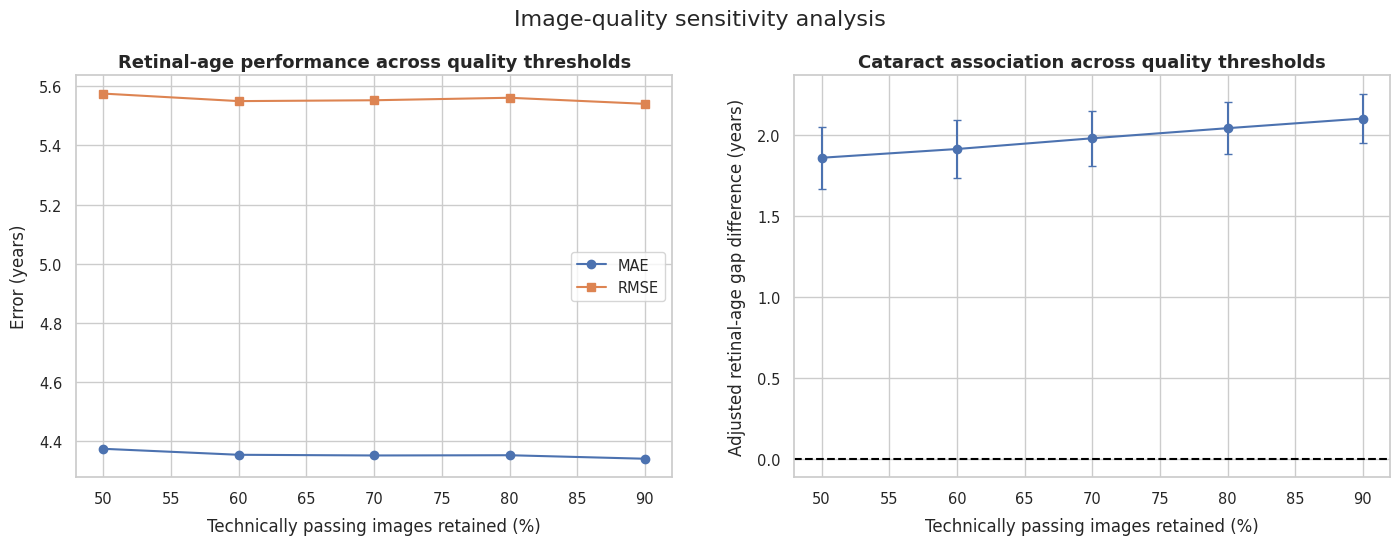

In [0]:
full_quality_frames = [pd.read_parquet(quality_path)]
for cached_quality_path in sorted(
    fairness_quality_root.glob("batch_*/fundus_quality_manifest.parquet")
):
    full_quality_frames.append(pd.read_parquet(cached_quality_path))
full_image_quality = pd.concat(full_quality_frames, ignore_index=True)
full_image_quality.attrs = {}
if "participant_id" not in full_image_quality:
    full_image_quality = full_image_quality.rename(
        columns={"participant_id_parsed": "participant_id"}
    )
full_image_quality["participant_id"] = normalize_identifier(
    full_image_quality["participant_id"]
)
full_image_quality["visit"] = normalize_visit(full_image_quality["visit"])
full_image_quality["image_path"] = full_image_quality["image_path"].astype(str)
full_image_quality = full_image_quality.drop_duplicates(
    "image_path", keep="last"
)
full_image_quality["technical_quality_pass"] = normalized_code(
    full_image_quality["quality_pass"]
).isin({"1", "TRUE", "T", "Y", "YES"})
full_image_quality = full_image_quality[
    full_image_quality["technical_quality_pass"]
].copy()

full_quality_components = []
for metric in strict_quality_metrics:
    values = pd.to_numeric(full_image_quality[metric], errors="coerce")
    if metric in high_is_good_metrics:
        component = values.rank(pct=True)
    elif metric in low_is_good_metrics:
        component = (-values).rank(pct=True)
    else:
        component = (-abs(values - float(values.median()))).rank(pct=True)
    component_name = f"publication_component_{metric}"
    full_image_quality[component_name] = component
    full_quality_components.append(component_name)
full_image_quality["publication_quality_component_count"] = (
    full_image_quality[full_quality_components].notna().sum(axis=1)
)
full_image_quality["publication_quality_score"] = full_image_quality[
    full_quality_components
].mean(axis=1, skipna=True)
full_image_quality = full_image_quality[
    full_image_quality["publication_quality_component_count"].ge(
        max(2, math.ceil(len(full_quality_components) / 2))
    )
].copy()
quality_score_lookup = full_image_quality.set_index("image_path")[
    "publication_quality_score"
]
quality_threshold_values = {
    retained_fraction: float(
        full_image_quality["publication_quality_score"].quantile(
            1 - retained_fraction
        )
    )
    for retained_fraction in quality_threshold_retained_fractions
}

quality_curve_rows = []
quality_cataract_rows = []
quality_curve_source_token = hashlib.sha256(
    (
        source_signature(quality_path)
        + "|"
        + "|".join(source_signature(path) for path in embedding_paths)
    ).encode("utf-8")
).hexdigest()
baseline_age_lookup = baseline_model_frame.set_index(
    ["participant_id", "visit"]
)["chronological_age"]
all_retinal_ids = set(baseline_model_frame["participant_id"].astype(str))
cataract_columns_full = [
    column
    for column in baseline_header
    if cataract_status_pattern.search(column)
    and not questionnaire_procedural_pattern.search(column)
]
cataract_values_full = load_full_questionnaire_columns(
    cataract_columns_full
)
cataract_binary_columns = []
for cataract_column in cataract_columns_full:
    binary_name = f"binary__{cataract_column}"
    cataract_values_full[binary_name] = coerce_binary(
        cataract_values_full[cataract_column]
    )
    cataract_binary_columns.append(binary_name)
cataract_values_full["combined_cataract_status"] = (
    cataract_values_full[cataract_binary_columns].max(axis=1, skipna=True)
    if cataract_binary_columns
    else np.nan
)

for retained_fraction, threshold in quality_threshold_values.items():
    threshold_label = int(round(100 * retained_fraction))
    threshold_root = checkpoint_root / (
        f"quality_curve_retain_{threshold_label:02d}pct"
    )
    threshold_root.mkdir(parents=True, exist_ok=True)
    threshold_rollup_path = threshold_root / "participant_visit_embeddings.parquet"
    threshold_metadata_path = threshold_root / "rollup_metadata.json"
    threshold_signature = hashlib.sha256(
        (
            quality_curve_source_token
            + f"|fraction={retained_fraction}|threshold={threshold:.12g}"
        ).encode("utf-8")
    ).hexdigest()
    threshold_can_resume = False
    if (
        resume_completed_outputs
        and threshold_rollup_path.is_file()
        and threshold_metadata_path.is_file()
    ):
        threshold_can_resume = (
            json.loads(threshold_metadata_path.read_text()).get("signature")
            == threshold_signature
        )
    if threshold_can_resume:
        threshold_rollup = pd.read_parquet(threshold_rollup_path)
        print(f"[quality curve {threshold_label}%] resumed rollup")
    else:
        accumulators = {}
        seen_paths = set()
        for path_index, embedding_path in enumerate(embedding_paths, 1):
            embedded = pd.read_parquet(
                embedding_path,
                columns=["image_path", "participant_id", "visit", "embedding"],
            )
            embedded["image_path"] = embedded["image_path"].astype(str)
            embedded["participant_id"] = normalize_identifier(
                embedded["participant_id"]
            )
            embedded["visit"] = normalize_visit(embedded["visit"])
            embedded["quality_score"] = embedded["image_path"].map(
                quality_score_lookup
            )
            embedded = embedded[
                embedded["quality_score"].ge(threshold)
                & embedded["participant_id"].isin(all_retinal_ids)
                & ~embedded["image_path"].isin(seen_paths)
            ]
            for record in embedded.itertuples(index=False):
                vector = np.asarray(record.embedding, dtype=np.float32).reshape(-1)
                if vector.size != expected_embedding_dim:
                    continue
                key = (str(record.participant_id), str(record.visit))
                if key not in accumulators:
                    accumulators[key] = [vector.copy(), 1]
                else:
                    accumulators[key][0] += vector
                    accumulators[key][1] += 1
            seen_paths.update(embedded["image_path"].astype(str))
            if path_index == 1 or path_index % 25 == 0:
                print(
                    f"[quality curve {threshold_label}% {path_index}/"
                    f"{len(embedding_paths)}] {len(seen_paths):,} images",
                    flush=True,
                )
            del embedded
        threshold_rollup = pd.DataFrame(
            [
                {
                    "participant_id": participant_id,
                    "visit": visit,
                    "embedding": (vector_sum / image_count).astype(np.float32),
                    "n_embedded_images": image_count,
                }
                for (participant_id, visit), (vector_sum, image_count)
                in accumulators.items()
            ]
        )
        threshold_rollup["chronological_age"] = [
            baseline_age_lookup.get((participant_id, visit), np.nan)
            for participant_id, visit in threshold_rollup[
                ["participant_id", "visit"]
            ].itertuples(index=False, name=None)
        ]
        threshold_rollup = threshold_rollup.dropna(
            subset=["chronological_age"]
        )
        write_frame(threshold_rollup, threshold_rollup_path)
        write_json(
            {
                "signature": threshold_signature,
                "retained_fraction": retained_fraction,
                "quality_threshold": threshold,
                "participant_visits": int(len(threshold_rollup)),
                "images_represented": int(
                    threshold_rollup["n_embedded_images"].sum()
                ),
            },
            threshold_metadata_path,
        )
        del accumulators
        gc.collect()

    threshold_oof, _ = fit_or_resume_head(
        threshold_rollup,
        "chronological_age",
        (
            f"retfound_age_quality_retain_{threshold_label:02d}pct_"
            f"{threshold_signature[:8]}"
        ),
    )
    threshold_oof = threshold_oof.rename(
        columns={
            "age": "chronological_age",
            "retinal_age_prediction_oof": "retinal_age_oof",
        }
    )
    threshold_oof["participant_id"] = normalize_identifier(
        threshold_oof["participant_id"]
    )
    threshold_oof["visit"] = normalize_visit(threshold_oof["visit"])
    threshold_participant = (
        threshold_oof.assign(
            _visit_priority=lambda frame: frame["visit"].map(visit_priority).fillna(99)
        )
        .sort_values(["participant_id", "_visit_priority"])
        .drop_duplicates("participant_id")
    )
    threshold_metric = regression_metrics(
        threshold_participant,
        "chronological_age",
        "retinal_age_oof",
        f"Retain best {threshold_label}%",
    )
    threshold_metric.update(
        {
            "retained_fraction": retained_fraction,
            "quality_threshold": threshold,
            "images_represented": int(threshold_rollup["n_embedded_images"].sum()),
            "participants": int(threshold_participant["participant_id"].nunique()),
        }
    )
    quality_curve_rows.append(threshold_metric)

    cataract_work = threshold_participant.merge(
        cataract_values_full[["participant_id", "combined_cataract_status"]],
        on="participant_id",
        how="left",
        validate="one_to_one",
    )
    cataract_work["retinal_age_gap"] = (
        cataract_work["retinal_age_oof"] - cataract_work["chronological_age"]
    )
    cataract_work = cataract_work.dropna(
        subset=["retinal_age_gap", "combined_cataract_status"]
    )
    if (
        len(cataract_work) >= minimum_questionnaire_observed
        and cataract_work["combined_cataract_status"].nunique() == 2
    ):
        cataract_fit = smf.ols(
            "retinal_age_gap ~ combined_cataract_status + chronological_age "
            "+ I(chronological_age ** 2)",
            data=cataract_work,
        ).fit(cov_type="HC3")
        interval = cataract_fit.conf_int().loc["combined_cataract_status"]
        quality_cataract_rows.append(
            {
                "retained_fraction": retained_fraction,
                "n": int(cataract_fit.nobs),
                "cataract_coefficient_years": float(
                    cataract_fit.params["combined_cataract_status"]
                ),
                "ci_low": float(interval.iloc[0]),
                "ci_high": float(interval.iloc[1]),
                "p_value": float(cataract_fit.pvalues["combined_cataract_status"]),
            }
        )
    del threshold_rollup, threshold_oof, threshold_participant
    gc.collect()

quality_threshold_curve = pd.DataFrame(quality_curve_rows)
cataract_quality_curve = pd.DataFrame(quality_cataract_rows)
write_frame(
    quality_threshold_curve,
    statistics_root / "quality_threshold_performance_curve.csv",
)
write_frame(
    cataract_quality_curve,
    statistics_root / "cataract_effect_across_quality_thresholds.csv",
)

participant_mean_quality = (
    full_image_quality[
        full_image_quality["visit"].eq("BL")
    ]
    .groupby("participant_id", as_index=False)
    .agg(
        mean_quality_score=("publication_quality_score", "mean"),
        minimum_quality_score=("publication_quality_score", "min"),
        quality_images=("image_path", "nunique"),
    )
)
quality_adjustment_work = locked_analysis.merge(
    participant_mean_quality,
    on="participant_id",
    how="left",
    validate="one_to_one",
).merge(
    cataract_values_full[["participant_id", "combined_cataract_status"]],
    on="participant_id",
    how="left",
    validate="one_to_one",
)
quality_adjustment_fit = smf.ols(
    "retinal_age_gap_locked ~ mean_quality_score + minimum_quality_score "
    "+ combined_cataract_status + chronological_age "
    "+ I(chronological_age ** 2) + C(analysis_phase)",
    data=quality_adjustment_work,
    missing="drop",
).fit(cov_type="HC3")
quality_adjustment_coefficients = pd.DataFrame(
    {
        "term": quality_adjustment_fit.params.index,
        "coefficient": quality_adjustment_fit.params.values,
        "standard_error": quality_adjustment_fit.bse.values,
        "p_value": quality_adjustment_fit.pvalues.values,
        "ci_low": quality_adjustment_fit.conf_int().iloc[:, 0].values,
        "ci_high": quality_adjustment_fit.conf_int().iloc[:, 1].values,
        "n": int(quality_adjustment_fit.nobs),
    }
)
write_frame(
    quality_adjustment_coefficients,
    statistics_root / "continuous_quality_adjustment.csv",
)

review_root = private_root / "manual_quality_review"
review_image_root = review_root / "images"
review_image_root.mkdir(parents=True, exist_ok=True)
review_candidates = full_image_quality[
    full_image_quality["visit"].eq("BL")
].merge(
    cataract_values_full[["participant_id", "combined_cataract_status"]],
    on="participant_id",
    how="left",
)
review_candidates["quality_decile"] = pd.qcut(
    review_candidates["publication_quality_score"],
    q=10,
    labels=False,
    duplicates="drop",
)
review_candidates["review_stratum"] = (
    review_candidates["quality_decile"].astype("Int64").astype(str)
    + "|cataract="
    + review_candidates["combined_cataract_status"].fillna(-1).astype(int).astype(str)
)
review_per_stratum = max(
    1,
    math.ceil(
        manual_quality_review_n
        / max(1, review_candidates["review_stratum"].nunique())
    ),
)
sampled_review = pd.concat(
    [
        group.sample(
            min(len(group), review_per_stratum),
            random_state=random_state,
        )
        for _, group in review_candidates.groupby(
            "review_stratum",
            sort=True,
        )
    ],
    ignore_index=True,
).head(manual_quality_review_n)
sampled_review["review_id"] = [
    f"MQ{index:04d}" for index in range(1, len(sampled_review) + 1)
]
review_mapping_rows = []
for row in sampled_review.itertuples(index=False):
    source = Path(row.image_path)
    suffix = source.suffix.lower() if source.suffix else ".jpeg"
    destination = review_image_root / f"{row.review_id}{suffix}"
    copy_status = "already_present"
    if not destination.is_file():
        try:
            publish_file(source, destination)
            copy_status = "copied"
        except Exception as error:
            copy_status = f"failed:{type(error).__name__}"
    review_mapping_rows.append(
        {
            "review_id": row.review_id,
            "image_path": row.image_path,
            "participant_id": row.participant_id,
            "quality_score": row.publication_quality_score,
            "combined_cataract_status": row.combined_cataract_status,
            "copy_status": copy_status,
        }
    )
manual_quality_mapping = pd.DataFrame(review_mapping_rows)
manual_quality_form = manual_quality_mapping[["review_id"]].copy()
for column in (
    "gradable_0_1",
    "blur_grade_0_to_3",
    "media_opacity_grade_0_to_3",
    "field_definition_grade_0_to_3",
    "artifact_grade_0_to_3",
    "reviewer_comments",
):
    manual_quality_form[column] = ""
write_frame(
    manual_quality_mapping,
    review_root / "manual_quality_review_mapping_PRIVATE.csv",
)
write_frame(
    manual_quality_form,
    review_root / "manual_quality_review_form_BLINDED.csv",
)

figure, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")
axes[0].plot(
    100 * quality_threshold_curve["retained_fraction"],
    quality_threshold_curve["mae"],
    marker="o",
    label="MAE",
)
axes[0].plot(
    100 * quality_threshold_curve["retained_fraction"],
    quality_threshold_curve["rmse"],
    marker="s",
    label="RMSE",
)
axes[0].set(
    title="Retinal-age performance across quality thresholds",
    xlabel="Technically passing images retained (%)",
    ylabel="Error (years)",
)
axes[0].legend()
if not cataract_quality_curve.empty:
    x = 100 * cataract_quality_curve["retained_fraction"]
    y = cataract_quality_curve["cataract_coefficient_years"]
    axes[1].errorbar(
        x,
        y,
        yerr=np.maximum(
            0,
            np.vstack([y - cataract_quality_curve["ci_low"], cataract_quality_curve["ci_high"] - y]),
        ),
        fmt="o-",
        capsize=3,
    )
    axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(
    title="Cataract association across quality thresholds",
    xlabel="Technically passing images retained (%)",
    ylabel="Adjusted retinal-age gap difference (years)",
)
figure.suptitle("Image-quality sensitivity analysis")
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_14_quality_threshold_curve.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()
plt.close(figure)

## 20. Image- and eye-level reliability and laterality

Image-level vectors are scored in resumable batches and then collapsed by
participant, visit, and eye. Inter-eye agreement is reported at baseline.
ETDRS measurements are paired to the corresponding eye when explicit
left/right fields are present. Cataract is treated as participant-level
unless the source file contains an unambiguous eye-specific field.

n_paired_participants,pearson_r,ccc,mean_right_minus_left_years,sd_right_minus_left_years,mae_between_eyes_years
26789,0.848,0.8473,-0.3017,4.8302,3.7296


variable,eye,n,coefficient_years_per_sd,ci_low,ci_high,p_value,fdr_q_value
VA_ETDRS_R_NB_COM,R,27719,0.37834,0.27092,0.48576,0.0,0.0
VA_ETDRS_L_NB_COM,L,27190,0.38351,0.28425,0.48276,0.0,0.0
VA_ETDRS_R_PO_NB_COM,R,27699,0.40282,0.25386,0.55178,0.0,0.0
VA_ETDRS_L_PO_NB_COM,L,27161,0.38936,0.23229,0.54643,0.0,0.0


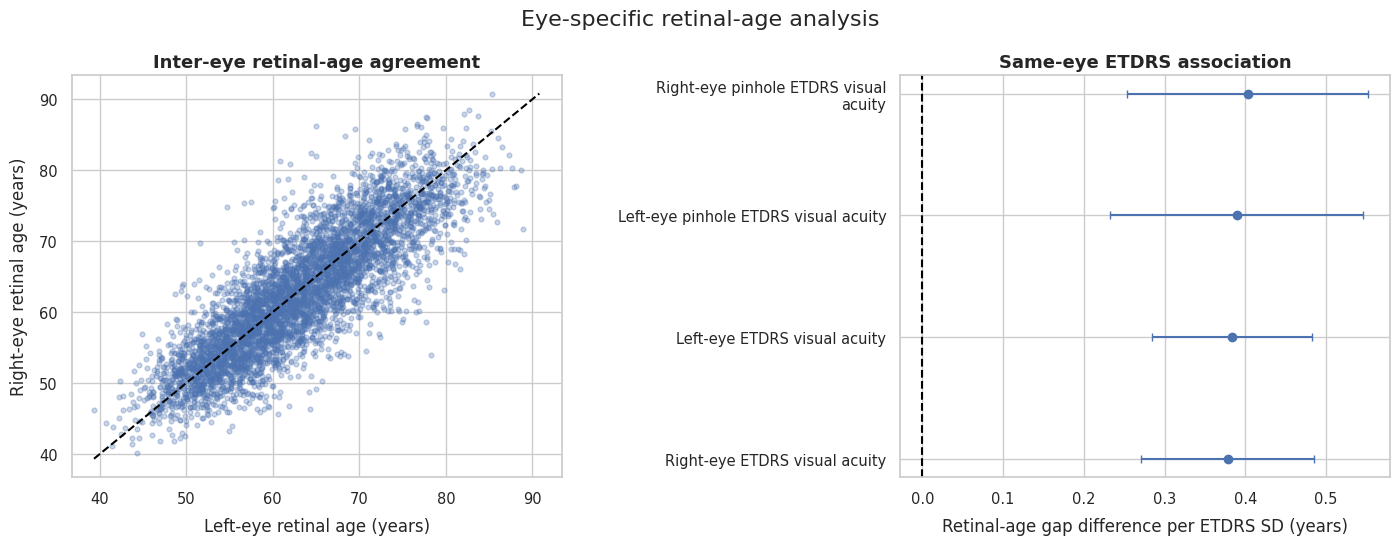

In [0]:
eye_prediction_root = checkpoint_root / "image_level_retinal_predictions"
eye_prediction_root.mkdir(parents=True, exist_ok=True)
eye_prediction_paths = []
for batch_index, embedding_path in enumerate(embedding_paths, 1):
    batch_key = hashlib.sha256(
        (
            source_signature(embedding_path)
            + "|"
            + str(chronological_bundle.get("training_signature", "legacy"))
        ).encode("utf-8")
    ).hexdigest()[:16]
    prediction_path = eye_prediction_root / f"{batch_key}_predictions.parquet"
    if resume_completed_outputs and prediction_path.is_file():
        eye_prediction_paths.append(prediction_path)
        continue
    embedded = pd.read_parquet(embedding_path)
    required_eye_columns = {
        "image_path", "participant_id", "visit", "eye", "embedding"
    }
    if not required_eye_columns.issubset(embedded.columns):
        print(
            f"[eye {batch_index}/{len(embedding_paths)}] skipped missing columns: "
            f"{embedding_path}",
            flush=True,
        )
        continue
    embedded["participant_id"] = normalize_identifier(embedded["participant_id"])
    embedded["visit"] = normalize_visit(embedded["visit"])
    embedded = embedded[
        embedded["participant_id"].isin(all_retinal_ids)
    ].drop_duplicates("image_path")
    if embedded.empty:
        continue
    scored = _fundus.predict_retinal_age(
        embedded[
            ["image_path", "participant_id", "visit", "eye", "embedding"]
        ],
        chronological_bundle,
    )
    write_frame(scored, prediction_path)
    eye_prediction_paths.append(prediction_path)
    if batch_index == 1 or batch_index % 25 == 0:
        print(
            f"[eye {batch_index}/{len(embedding_paths)}] saved {len(scored):,}",
            flush=True,
        )
    del embedded, scored
    gc.collect()

image_predictions = pd.concat(
    [pd.read_parquet(path) for path in eye_prediction_paths],
    ignore_index=True,
)
image_predictions = image_predictions.drop_duplicates(
    "image_path", keep="last"
)
image_predictions["eye_standardized"] = (
    image_predictions["eye"].astype("string").str.strip().str.upper().replace(
        {"LEFT": "L", "RIGHT": "R", "OS": "L", "OD": "R"}
    )
)
image_predictions = image_predictions[
    image_predictions["eye_standardized"].isin(["L", "R"])
]
eye_predictions = (
    image_predictions.groupby(
        ["participant_id", "visit", "eye_standardized"],
        as_index=False,
    )
    .agg(
        retinal_age_eye=("retinal_age_prediction", "mean"),
        eye_images=("image_path", "nunique"),
    )
    .merge(
        baseline_model_frame[
            ["participant_id", "visit", "chronological_age"]
        ],
        on=["participant_id", "visit"],
        how="left",
        validate="many_to_one",
    )
)
eye_predictions["retinal_age_gap_eye"] = (
    eye_predictions["retinal_age_eye"] - eye_predictions["chronological_age"]
)
baseline_eye_wide = eye_predictions[
    eye_predictions["visit"].eq("BL")
].pivot(
    index="participant_id",
    columns="eye_standardized",
    values="retinal_age_eye",
).dropna(subset=["L", "R"])
paired_left = baseline_eye_wide["L"].to_numpy(float)
paired_right = baseline_eye_wide["R"].to_numpy(float)
difference = paired_right - paired_left
paired_eye_sufficient = len(baseline_eye_wide) >= 3
inter_eye_metrics = pd.DataFrame(
    [
        {
            "n_paired_participants": int(len(baseline_eye_wide)),
            "pearson_r": (
                float(stats.pearsonr(paired_left, paired_right).statistic)
                if paired_eye_sufficient else np.nan
            ),
            "ccc": (
                concordance_correlation(paired_left, paired_right)
                if paired_eye_sufficient else np.nan
            ),
            "mean_right_minus_left_years": (
                float(np.mean(difference)) if paired_eye_sufficient else np.nan
            ),
            "sd_right_minus_left_years": (
                float(np.std(difference, ddof=1))
                if paired_eye_sufficient else np.nan
            ),
            "mae_between_eyes_years": (
                float(np.mean(np.abs(difference)))
                if paired_eye_sufficient else np.nan
            ),
        }
    ]
)
reliability_capability.update(
    {
        "eye_level_reliability_available": True,
        "reason": "Image-level embedding batches were rescored and paired by eye.",
        "n_paired_eye_participants": int(len(baseline_eye_wide)),
        "inter_eye_ccc": float(inter_eye_metrics["ccc"].iloc[0]),
    }
)
write_json(
    reliability_capability,
    statistics_root / "reliability_capability.json",
)

etdrs_eye_columns = [
    column
    for column in baseline_header
    if visual_acuity_score_pattern.search(column)
    and re.search(r"(?i)^VA_ETDRS_[LR](?:_PO)?_NB_COM$", column)
]
eye_variable_audit = pd.DataFrame(
    [
        {
            "variable": column,
            "eye": "L" if re.search(r"(?i)^VA_ETDRS_L", column) else "R",
            "construct": "ETDRS visual acuity",
        }
        for column in etdrs_eye_columns
    ]
)
eye_questionnaire = load_full_questionnaire_columns(etdrs_eye_columns)
eye_association_rows = []
for record in eye_variable_audit.itertuples(index=False):
    eye_work = eye_predictions[
        eye_predictions["visit"].eq("BL")
        & eye_predictions["eye_standardized"].eq(record.eye)
    ].merge(
        eye_questionnaire[["participant_id", record.variable]],
        on="participant_id",
        how="left",
        validate="one_to_one",
    ).merge(
        cataract_values_full[["participant_id", "combined_cataract_status"]],
        on="participant_id",
        how="left",
        validate="one_to_one",
    )
    eye_work["etdrs_z"] = safe_zscore(
        pd.to_numeric(eye_work[record.variable], errors="coerce")
    )
    eye_work = eye_work.dropna(
        subset=["retinal_age_gap_eye", "etdrs_z"]
    )
    if len(eye_work) < minimum_questionnaire_observed:
        continue
    eye_fit = smf.ols(
        "retinal_age_gap_eye ~ etdrs_z + chronological_age "
        "+ I(chronological_age ** 2) + combined_cataract_status",
        data=eye_work,
        missing="drop",
    ).fit(cov_type="HC3")
    interval = eye_fit.conf_int().loc["etdrs_z"]
    eye_association_rows.append(
        {
            "variable": record.variable,
            "eye": record.eye,
            "n": int(eye_fit.nobs),
            "coefficient_years_per_sd": float(eye_fit.params["etdrs_z"]),
            "ci_low": float(interval.iloc[0]),
            "ci_high": float(interval.iloc[1]),
            "p_value": float(eye_fit.pvalues["etdrs_z"]),
        }
    )
eye_specific_associations = pd.DataFrame(eye_association_rows)
if not eye_specific_associations.empty:
    eye_specific_associations["fdr_q_value"] = benjamini_hochberg(
        eye_specific_associations["p_value"].to_numpy(float)
    )
write_frame(
    eye_predictions,
    private_root / "eye_level_retinal_age_private.parquet",
)
write_frame(
    inter_eye_metrics,
    statistics_root / "inter_eye_reliability.csv",
)
write_frame(
    eye_variable_audit,
    statistics_root / "eye_specific_variable_mapping.csv",
)
write_frame(
    eye_specific_associations,
    statistics_root / "eye_specific_etdrs_associations.csv",
)
display(inter_eye_metrics.round(4))
display(eye_specific_associations.round(5))

figure, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")
sample_eye = baseline_eye_wide.sample(
    min(maximum_scatter_points, len(baseline_eye_wide)),
    random_state=random_state,
)
if not sample_eye.empty:
    axes[0].scatter(sample_eye["L"], sample_eye["R"], s=12, alpha=0.30)
    lower = float(min(sample_eye["L"].min(), sample_eye["R"].min()))
    upper = float(max(sample_eye["L"].max(), sample_eye["R"].max()))
    axes[0].plot([lower, upper], [lower, upper], "--", color="black")
else:
    axes[0].text(
        0.5,
        0.5,
        "No paired left/right predictions available",
        ha="center",
        va="center",
        transform=axes[0].transAxes,
    )
axes[0].set(
    title="Inter-eye retinal-age agreement",
    xlabel="Left-eye retinal age (years)",
    ylabel="Right-eye retinal age (years)",
)
if not eye_specific_associations.empty:
    plot = eye_specific_associations.sort_values("coefficient_years_per_sd")
    y = np.arange(len(plot))
    center = plot["coefficient_years_per_sd"].to_numpy(float)
    axes[1].errorbar(
        center,
        y,
        xerr=np.maximum(
            0,
            np.vstack([center - plot["ci_low"], plot["ci_high"] - center]),
        ),
        fmt="o",
        capsize=3,
    )
    axes[1].set_yticks(
        y,
        [
            publication_variable_label(variable, width=36)
            for variable in plot["variable"]
        ],
    )
    axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(
    title="Same-eye ETDRS association",
    xlabel="Retinal-age gap difference per ETDRS SD (years)",
    ylabel="",
)
figure.suptitle("Eye-specific retinal-age analysis")
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_15_eye_specific_analysis.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()
plt.close(figure)

In [ ]:
# Persistence-only input for Figure 4A; identifiers are excluded.
write_frame(
    baseline_eye_wide[["R", "L"]]
    .rename(
        columns={
            "R": "right_retinal_age",
            "L": "left_retinal_age",
        }
    )
    .sort_values(
        ["right_retinal_age", "left_retinal_age"],
        kind="stable",
    ),
    statistics_root / "figure_04_inter_eye_points.parquet",
)


## 21. Epigenetic-target prediction beyond chronological age

The retinal heads trained on absolute Horvath and Hannum age are secondary
prediction analyses. Because both targets are strongly related to chronological
age, performance is benchmarked against a chronological-age-only model in the
same outer folds. A combined age-plus-retinal model estimates incremental
out-of-fold information, and a leakage-safe outer-fold analysis tests whether
RETFound embeddings predict the age-residualized clock component directly.

These analyses do not replace the primary comparison of independently derived
retinal and epigenetic acceleration. They test whether retinal representations
contain methylation-clock information beyond chronological age.


clock,clock_label,n,age_only_oof_r2,retfound_only_oof_r2,age_plus_retfound_oof_r2,delta_r2_beyond_age,age_only_oof_mae,retfound_only_oof_mae,age_plus_retfound_oof_mae,mae_improvement_beyond_age,partial_r_retfound_clock_given_age,partial_r_ci_low,partial_r_ci_high,residual_head_oof_r2,residual_head_oof_mae,residual_head_oof_r,residual_head_r_ci_low,residual_head_r_ci_high,residual_head_age_stratified_permutation_p,delta_r2_ci_low,delta_r2_ci_high,mae_improvement_ci_low,mae_improvement_ci_high,increment_beyond_age_supported
epigenetic_dnam_age,Horvath DNAm age,1406,0.74281,0.45121,0.74531,0.0025,3.42503,5.10801,3.41447,0.01056,0.03599,-0.01632,0.08811,-0.53982,4.31729,0.07617,0.02399,0.12794,0.0034,8.0E-5,0.00472,-0.0114,0.03236,false
epigenetic_hannum_age,Hannum epigenetic age,1406,0.71583,0.42096,0.71588,5.0E-5,5.03907,7.27975,5.03692,0.00215,0.01954,-0.03278,0.07174,-0.59522,6.44548,0.03949,-0.01281,0.09158,0.13889,-0.0019,0.00209,-0.01823,0.02465,false


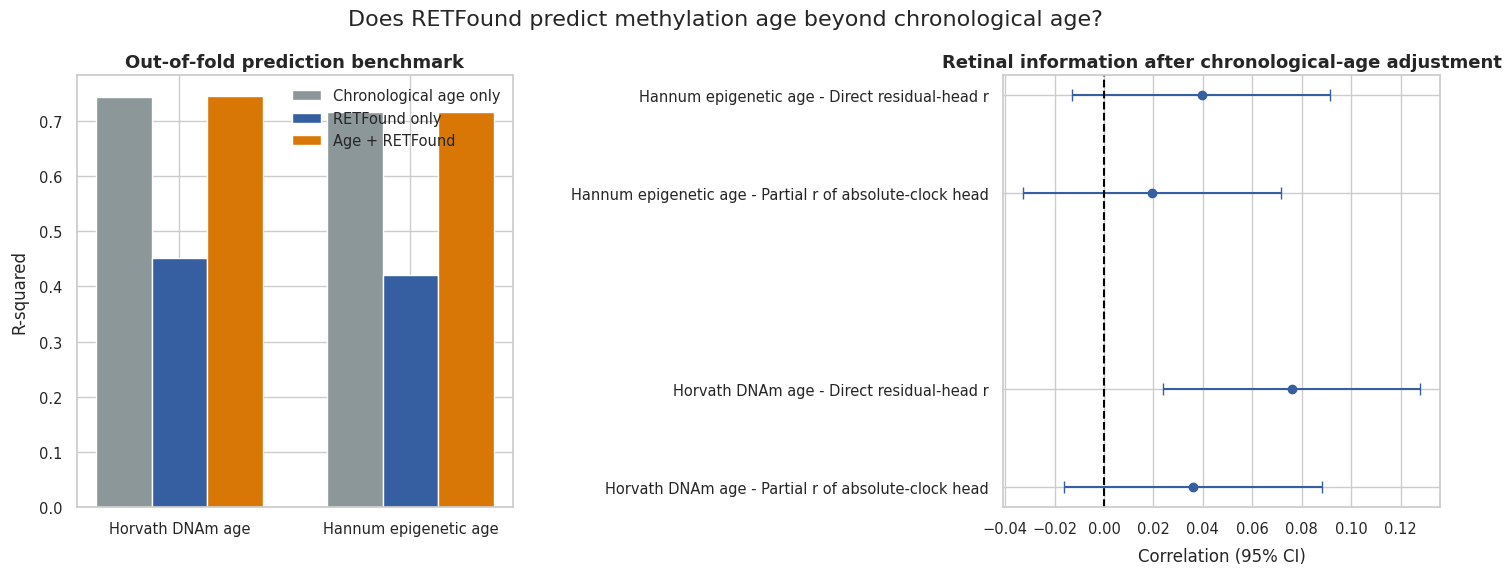

In [0]:
def _stack_embedding_series(series):
    matrix = np.vstack(
        series.map(
            lambda value: np.asarray(value, dtype=np.float64).reshape(-1)
        ).to_numpy()
    )
    if matrix.shape[1] != expected_embedding_dim:
        raise ValueError(
            f"Unexpected benchmark embedding dimension: {matrix.shape[1]}"
        )
    return matrix


def _fisher_interval(correlation, n, alpha=0.05):
    if n <= 3 or not np.isfinite(correlation):
        return np.nan, np.nan
    clipped = float(np.clip(correlation, -0.999999, 0.999999))
    z_value = np.arctanh(clipped)
    half_width = stats.norm.ppf(1 - alpha / 2) / np.sqrt(n - 3)
    return tuple(np.tanh([z_value - half_width, z_value + half_width]))


def _bootstrap_prediction_increment(
    target,
    age_prediction,
    combined_prediction,
    repetitions,
    seed,
):
    target = np.asarray(target, dtype=float)
    age_prediction = np.asarray(age_prediction, dtype=float)
    combined_prediction = np.asarray(combined_prediction, dtype=float)
    rng = np.random.default_rng(seed)
    delta_r2 = np.empty(repetitions, dtype=float)
    mae_improvement = np.empty(repetitions, dtype=float)
    for repetition in range(repetitions):
        sampled = rng.integers(0, len(target), len(target))
        y_sample = target[sampled]
        age_sample = age_prediction[sampled]
        combined_sample = combined_prediction[sampled]
        delta_r2[repetition] = (
            r2_score(y_sample, combined_sample)
            - r2_score(y_sample, age_sample)
        )
        mae_improvement[repetition] = (
            mean_absolute_error(y_sample, age_sample)
            - mean_absolute_error(y_sample, combined_sample)
        )
    return {
        "delta_r2_ci_low": float(np.quantile(delta_r2, 0.025)),
        "delta_r2_ci_high": float(np.quantile(delta_r2, 0.975)),
        "mae_improvement_ci_low": float(
            np.quantile(mae_improvement, 0.025)
        ),
        "mae_improvement_ci_high": float(
            np.quantile(mae_improvement, 0.975)
        ),
    }


def _stratified_correlation_permutation(
    prediction,
    target,
    chronological_age,
    repetitions,
    seed,
):
    prediction = np.asarray(prediction, dtype=float)
    target = np.asarray(target, dtype=float)
    chronological_age = np.asarray(chronological_age, dtype=float)
    observed = float(stats.pearsonr(prediction, target).statistic)
    age_strata = pd.qcut(
        chronological_age,
        q=min(10, len(np.unique(chronological_age))),
        labels=False,
        duplicates="drop",
    )
    strata_indices = [
        np.flatnonzero(np.asarray(age_strata) == stratum)
        for stratum in np.unique(age_strata)
    ]
    rng = np.random.default_rng(seed)
    exceed = 1
    for _ in range(repetitions):
        permuted = target.copy()
        for indices in strata_indices:
            permuted[indices] = rng.permutation(target[indices])
        permuted_r = float(stats.pearsonr(prediction, permuted).statistic)
        exceed += abs(permuted_r) >= abs(observed)
    return observed, float(exceed / (repetitions + 1))


epigenetic_target_benchmark_rows = []
epigenetic_target_benchmark_predictions = []
for clock_index, (clock_column, clock_label) in enumerate(
    ABSOLUTE_CLOCKS.items()
):
    retinal_oof = epigenetic_oof[clock_column][
        [
            "participant_id",
            "retinal_age_prediction_oof",
        ]
    ].rename(
        columns={
            "retinal_age_prediction_oof": "retinal_clock_prediction_oof"
        }
    )
    benchmark = baseline_vectors[
        [
            "participant_id",
            "visit",
            "chronological_age",
            clock_column,
            "embedding",
        ]
    ].merge(
        retinal_oof,
        on="participant_id",
        how="inner",
        validate="one_to_one",
    ).dropna(
        subset=[
            "chronological_age",
            clock_column,
            "embedding",
            "retinal_clock_prediction_oof",
        ]
    ).reset_index(drop=True)
    if benchmark["participant_id"].duplicated().any():
        raise ValueError(f"{clock_label} benchmark is not participant-unique")

    target = benchmark[clock_column].to_numpy(float)
    chronological_age = benchmark["chronological_age"].to_numpy(float)
    retinal_prediction = benchmark[
        "retinal_clock_prediction_oof"
    ].to_numpy(float)
    embeddings_matrix = _stack_embedding_series(benchmark["embedding"])
    groups = benchmark["participant_id"].astype(str).to_numpy()
    splitter = GroupKFold(
        n_splits=min(cv_folds, len(np.unique(groups)))
    )

    age_only_oof = np.full(len(benchmark), np.nan)
    combined_oof = np.full(len(benchmark), np.nan)
    clock_residual_oof = np.full(len(benchmark), np.nan)
    retinal_prediction_residual_oof = np.full(len(benchmark), np.nan)
    residual_head_oof = np.full(len(benchmark), np.nan)
    outer_fold = np.zeros(len(benchmark), dtype=int)

    for fold_number, (train_index, test_index) in enumerate(
        splitter.split(embeddings_matrix, target, groups),
        1,
    ):
        outer_fold[test_index] = fold_number
        age_basis = SplineTransformer(
            n_knots=4,
            degree=3,
            include_bias=False,
        )
        age_train = age_basis.fit_transform(
            chronological_age[train_index, None]
        )
        age_test = age_basis.transform(
            chronological_age[test_index, None]
        )

        age_model = Ridge(alpha=1.0)
        age_model.fit(age_train, target[train_index])
        age_train_prediction = age_model.predict(age_train)
        age_test_prediction = age_model.predict(age_test)
        age_only_oof[test_index] = age_test_prediction
        clock_residual_oof[test_index] = (
            target[test_index] - age_test_prediction
        )

        combined_scaler = StandardScaler()
        combined_train = combined_scaler.fit_transform(
            np.column_stack(
                [age_train, retinal_prediction[train_index]]
            )
        )
        combined_test = combined_scaler.transform(
            np.column_stack(
                [age_test, retinal_prediction[test_index]]
            )
        )
        combined_model = Ridge(alpha=1.0)
        combined_model.fit(combined_train, target[train_index])
        combined_oof[test_index] = combined_model.predict(combined_test)

        retinal_age_model = Ridge(alpha=1.0)
        retinal_age_model.fit(
            age_train,
            retinal_prediction[train_index],
        )
        retinal_prediction_residual_oof[test_index] = (
            retinal_prediction[test_index]
            - retinal_age_model.predict(age_test)
        )

        embedding_scaler = StandardScaler()
        embedding_train = embedding_scaler.fit_transform(
            embeddings_matrix[train_index]
        )
        embedding_test = embedding_scaler.transform(
            embeddings_matrix[test_index]
        )
        residual_head = Ridge(alpha=ridge_alpha)
        residual_head.fit(
            embedding_train,
            target[train_index] - age_train_prediction,
        )
        residual_head_oof[test_index] = residual_head.predict(
            embedding_test
        )

    if not np.all(outer_fold > 0):
        raise RuntimeError(f"Incomplete outer-fold predictions for {clock_label}")

    age_r2 = float(r2_score(target, age_only_oof))
    retinal_r2 = float(r2_score(target, retinal_prediction))
    combined_r2 = float(r2_score(target, combined_oof))
    age_mae = float(mean_absolute_error(target, age_only_oof))
    retinal_mae = float(mean_absolute_error(target, retinal_prediction))
    combined_mae = float(mean_absolute_error(target, combined_oof))
    partial_r = float(
        stats.pearsonr(
            clock_residual_oof,
            retinal_prediction_residual_oof,
        ).statistic
    )
    partial_low, partial_high = _fisher_interval(
        partial_r,
        len(benchmark),
    )
    residual_r, residual_permutation_p = (
        _stratified_correlation_permutation(
            residual_head_oof,
            clock_residual_oof,
            chronological_age,
            permutation_repetitions,
            random_state + 25000 + clock_index,
        )
    )
    residual_low, residual_high = _fisher_interval(
        residual_r,
        len(benchmark),
    )
    increment_ci = _bootstrap_prediction_increment(
        target,
        age_only_oof,
        combined_oof,
        publication_bootstrap_repetitions,
        random_state + 26000 + clock_index,
    )
    epigenetic_target_benchmark_rows.append(
        {
            "clock": clock_column,
            "clock_label": clock_label,
            "n": int(len(benchmark)),
            "age_only_oof_r2": age_r2,
            "retfound_only_oof_r2": retinal_r2,
            "age_plus_retfound_oof_r2": combined_r2,
            "delta_r2_beyond_age": combined_r2 - age_r2,
            "age_only_oof_mae": age_mae,
            "retfound_only_oof_mae": retinal_mae,
            "age_plus_retfound_oof_mae": combined_mae,
            "mae_improvement_beyond_age": age_mae - combined_mae,
            "partial_r_retfound_clock_given_age": partial_r,
            "partial_r_ci_low": partial_low,
            "partial_r_ci_high": partial_high,
            "residual_head_oof_r2": float(
                r2_score(clock_residual_oof, residual_head_oof)
            ),
            "residual_head_oof_mae": float(
                mean_absolute_error(clock_residual_oof, residual_head_oof)
            ),
            "residual_head_oof_r": residual_r,
            "residual_head_r_ci_low": residual_low,
            "residual_head_r_ci_high": residual_high,
            "residual_head_age_stratified_permutation_p": (
                residual_permutation_p
            ),
            **increment_ci,
        }
    )
    epigenetic_target_benchmark_predictions.append(
        benchmark[
            ["participant_id", "chronological_age", clock_column]
        ].assign(
            clock=clock_column,
            outer_fold=outer_fold,
            age_only_prediction_oof=age_only_oof,
            retfound_clock_prediction_oof=retinal_prediction,
            age_plus_retfound_prediction_oof=combined_oof,
            clock_residual_outer_fold=clock_residual_oof,
            retfound_prediction_residual_outer_fold=(
                retinal_prediction_residual_oof
            ),
            residual_head_prediction_oof=residual_head_oof,
        )
    )

epigenetic_target_benchmark = pd.DataFrame(
    epigenetic_target_benchmark_rows
)
epigenetic_target_benchmark_prediction_table = pd.concat(
    epigenetic_target_benchmark_predictions,
    ignore_index=True,
)
epigenetic_target_benchmark[
    "increment_beyond_age_supported"
] = (
    epigenetic_target_benchmark["delta_r2_ci_low"].gt(0)
    & epigenetic_target_benchmark["mae_improvement_ci_low"].gt(0)
    & epigenetic_target_benchmark[
        "residual_head_age_stratified_permutation_p"
    ].lt(0.05)
)
write_frame(
    epigenetic_target_benchmark,
    statistics_root / "epigenetic_target_prediction_beyond_age.csv",
)
write_frame(
    epigenetic_target_benchmark_prediction_table,
    private_root / "epigenetic_target_prediction_oof_private.parquet",
)
display(epigenetic_target_benchmark.round(5))

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    layout="constrained",
)
clock_labels = epigenetic_target_benchmark["clock_label"].tolist()
positions = np.arange(len(clock_labels))
bar_width = 0.24
for offset, column, label, color in (
    (-bar_width, "age_only_oof_r2", "Chronological age only", "#8C9799"),
    (0.0, "retfound_only_oof_r2", "RETFound only", "#355FA0"),
    (bar_width, "age_plus_retfound_oof_r2", "Age + RETFound", "#D97706"),
):
    axes[0].bar(
        positions + offset,
        epigenetic_target_benchmark[column],
        width=bar_width,
        label=label,
        color=color,
    )
axes[0].set_xticks(positions, clock_labels)
axes[0].set(
    title="Out-of-fold prediction benchmark",
    ylabel="R-squared",
    xlabel="",
)
axes[0].legend(frameon=False)

metric_positions = []
metric_values = []
metric_low = []
metric_high = []
metric_labels = []
for row_index, row in epigenetic_target_benchmark.iterrows():
    for metric_index, (
        value_column,
        low_column,
        high_column,
        metric_label,
    ) in enumerate(
        (
            (
                "partial_r_retfound_clock_given_age",
                "partial_r_ci_low",
                "partial_r_ci_high",
                "Partial r of absolute-clock head",
            ),
            (
                "residual_head_oof_r",
                "residual_head_r_ci_low",
                "residual_head_r_ci_high",
                "Direct residual-head r",
            ),
        )
    ):
        position = row_index * 3 + metric_index
        metric_positions.append(position)
        metric_values.append(row[value_column])
        metric_low.append(row[low_column])
        metric_high.append(row[high_column])
        metric_labels.append(f"{row['clock_label']} - {metric_label}")
metric_values = np.asarray(metric_values, dtype=float)
axes[1].errorbar(
    metric_values,
    metric_positions,
    xerr=np.maximum(
        0,
        np.vstack(
            [
                metric_values - np.asarray(metric_low),
                np.asarray(metric_high) - metric_values,
            ]
        ),
    ),
    fmt="o",
    color="#355FA0",
    capsize=4,
)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_yticks(metric_positions, metric_labels)
axes[1].set(
    title="Retinal information after chronological-age adjustment",
    xlabel="Correlation (95% CI)",
    ylabel="",
)
figure.suptitle(
    "Does RETFound predict methylation age beyond chronological age?"
)
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_20_epigenetic_target_increment_beyond_age.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3,
)
plt.show()
plt.close(figure)


## 22. Robustness across released epigenetic-acceleration definitions

The representative epigenetic associations are repeated across the released
acceleration difference, residual acceleration, IEAA, and EEAA measures, as
well as separately cross-fitted Horvath and Hannum acceleration. This tests
whether the phenotypic pattern depends on a particular clock or on the handling
of age-related blood-cell composition. The original global phenome scan remains
the discovery analysis; this is a restricted sensitivity analysis.


outcome,outcome_label,variable,variable_label,publication_label,analysis_type,n,minimum_modeled_level_n,incremental_r2,omnibus_f,p_value,df_difference,fdr_q_global_sensitivity,fdr_q_within_epigenetic_definition,globally_robust_fdr_0_05
z_epigenetic_mean_acceleration,Mean Horvath-Hannum acceleration,CR2_DEVC_WK_COM,Used a walker,Walker use,categorical,1406,41,0.010364,15.961263,6.8E-5,1.0,7.94E-4,1.13E-4,true
z_hannum_acceleration,Cross-fitted Hannum acceleration,CR2_DEVC_WK_COM,Used a walker,Walker use,categorical,1406,41,0.006598,10.09458,0.00152,1.0,0.002659,0.002258,true
z_horvath_acceleration,Cross-fitted Horvath acceleration,CR2_DEVC_WK_COM,Used a walker,Walker use,categorical,1406,41,0.009437,14.027785,1.87E-4,1.0,9.04E-4,5.58E-4,true
z_sensitivity_epigenetic_age_acceleration_difference,Released acceleration difference,CR2_DEVC_WK_COM,Used a walker,Walker use,categorical,1406,41,0.0065,12.924221,3.36E-4,1.0,9.04E-4,7.54E-4,true
z_sensitivity_epigenetic_age_acceleration_residual,Released residual acceleration,CR2_DEVC_WK_COM,Used a walker,Walker use,categorical,1406,41,0.008703,12.924221,3.36E-4,1.0,9.04E-4,7.54E-4,true
z_sensitivity_epigenetic_eeaa,EEAA,CR2_DEVC_WK_COM,Used a walker,Walker use,categorical,1406,41,0.006979,10.812581,0.001033,1.0,0.001903,0.001722,true
z_sensitivity_epigenetic_ieaa,IEAA,CR2_DEVC_WK_COM,Used a walker,Walker use,categorical,1406,41,0.005144,7.428501,0.0065,1.0,0.008125,0.016251,true
z_epigenetic_mean_acceleration,Mean Horvath-Hannum acceleration,CR2_FAM_ML_COM,Received nonprofessional help with meal preparation,Help with meal preparation,categorical,1406,79,0.01083,16.688303,4.7E-5,1.0,7.94E-4,1.13E-4,true
z_hannum_acceleration,Cross-fitted Hannum acceleration,CR2_FAM_ML_COM,Received nonprofessional help with meal preparation,Help with meal preparation,categorical,1406,79,0.00846,12.970251,3.28E-4,1.0,9.04E-4,8.19E-4,true
z_horvath_acceleration,Cross-fitted Horvath acceleration,CR2_FAM_ML_COM,Received nonprofessional help with meal preparation,Help with meal preparation,categorical,1406,79,0.008166,12.121307,5.14E-4,1.0,0.001058,8.56E-4,true


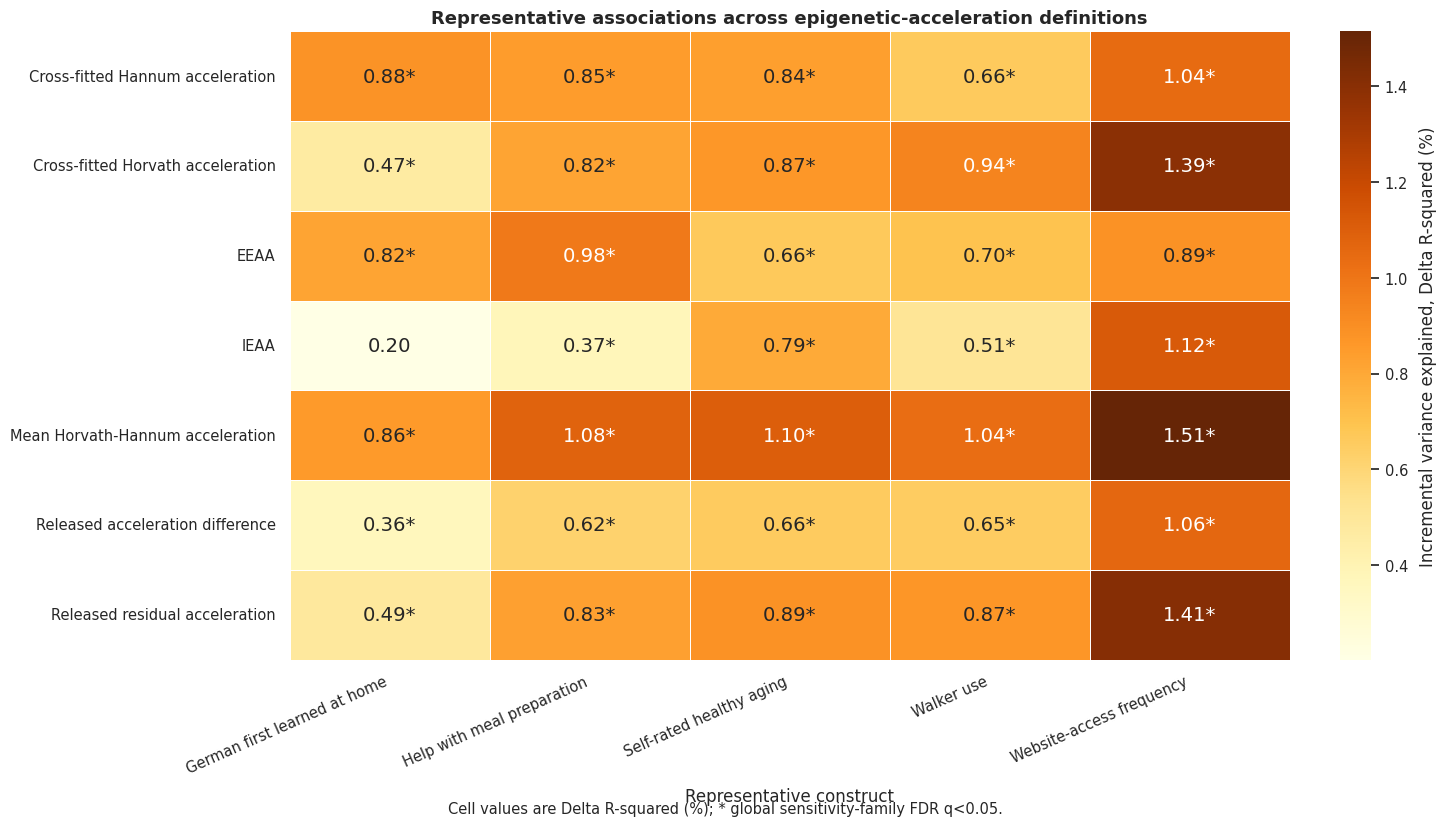

In [0]:
representative_epigenetic_constructs = [
    "CR2_FAM_ML_COM",
    "CR2_DEVC_WK_COM",
    "INT_FRQWBSTS_MCQ",
    "SDC_FTLG_DE_COM",
    "GEN_OWNAG_COM",
]
missing_representative_constructs = set(
    representative_epigenetic_constructs
) - set(questionnaire_clean.columns)
if missing_representative_constructs:
    raise ValueError(
        "Representative epigenetic constructs are missing from the "
        f"questionnaire extract: {sorted(missing_representative_constructs)}"
    )

released_definition_columns = {
    "epigenetic_age_acceleration_difference": (
        "Released acceleration difference"
    ),
    "epigenetic_age_acceleration_residual": (
        "Released residual acceleration"
    ),
    "epigenetic_ieaa": "IEAA",
    "epigenetic_eeaa": "EEAA",
}
definition_source_columns = [
    *released_definition_columns,
    "z_horvath_acceleration",
    "z_hannum_acceleration",
]
definition_frame = questionnaire_analysis_frame.merge(
    tri_age[
        ["participant_id", *definition_source_columns]
    ],
    on="participant_id",
    how="left",
    validate="one_to_one",
)
epigenetic_definition_outcomes = {
    "z_epigenetic_mean_acceleration": "Mean Horvath-Hannum acceleration",
    "z_horvath_acceleration": "Cross-fitted Horvath acceleration",
    "z_hannum_acceleration": "Cross-fitted Hannum acceleration",
}
for source_column, label in released_definition_columns.items():
    standardized_column = f"z_sensitivity_{source_column}"
    definition_frame[standardized_column] = safe_zscore(
        definition_frame[source_column]
    )
    epigenetic_definition_outcomes[standardized_column] = label

epigenetic_definition_rows = []
epigenetic_definition_failures = []
for outcome, outcome_label in epigenetic_definition_outcomes.items():
    for variable in representative_epigenetic_constructs:
        variable_type = questionnaire_variable_types.get(variable)
        if variable_type not in {"numeric", "categorical"}:
            epigenetic_definition_failures.append(
                {
                    "outcome": outcome,
                    "variable": variable,
                    "status": "missing_analysis_type",
                }
            )
            continue
        model_columns = [
            outcome,
            "chronological_age",
            "chronological_age_sq",
            "log_n_embedded_images",
            *association_categorical_columns,
            variable,
        ]
        for continuous in ("bmi", "body_mass_index"):
            if continuous in association_covariate_terms:
                model_columns.append(continuous)
        work = definition_frame[
            list(dict.fromkeys(model_columns))
        ].copy()
        work[outcome] = pd.to_numeric(work[outcome], errors="coerce")

        if variable_type == "numeric":
            work["question_value_numeric"] = safe_zscore(
                pd.to_numeric(work[variable], errors="coerce")
            )
            question_term = "question_value_numeric"
            work = work.dropna(subset=[outcome, question_term])
            minimum_level_n = np.nan
        else:
            values = work[variable].astype("string").str.strip()
            counts = values.value_counts(dropna=True)
            frequent_levels = counts[
                counts >= minimum_questionnaire_level_n
            ].index
            values = values.where(
                values.isna() | values.isin(frequent_levels),
                "Other/low-frequency",
            )
            collapsed_counts = values.value_counts(dropna=True)
            if (
                "Other/low-frequency" in collapsed_counts
                and collapsed_counts["Other/low-frequency"]
                < minimum_questionnaire_level_n
            ):
                values = values.mask(values.eq("Other/low-frequency"))
            work["question_value_categorical"] = pd.Categorical(
                values.astype("object")
            )
            question_term = "C(question_value_categorical)"
            work = work.dropna(
                subset=[outcome, "question_value_categorical"]
            )
            level_counts = work[
                "question_value_categorical"
            ].value_counts()
            minimum_level_n = (
                int(level_counts.min()) if not level_counts.empty else 0
            )
            if len(level_counts) < 2:
                epigenetic_definition_failures.append(
                    {
                        "outcome": outcome,
                        "variable": variable,
                        "status": "fewer_than_two_stable_levels",
                        "n": int(len(work)),
                    }
                )
                continue

        complete_case_columns = [
            outcome,
            "chronological_age",
            "chronological_age_sq",
            "log_n_embedded_images",
            *association_categorical_columns,
            (
                "question_value_numeric"
                if variable_type == "numeric"
                else "question_value_categorical"
            ),
        ]
        for continuous in ("bmi", "body_mass_index"):
            if continuous in association_covariate_terms:
                complete_case_columns.append(continuous)
        work = work.dropna(
            subset=list(dict.fromkeys(complete_case_columns))
        )
        for categorical_covariate in association_categorical_columns:
            if isinstance(
                work[categorical_covariate].dtype,
                pd.CategoricalDtype,
            ):
                work[categorical_covariate] = (
                    work[categorical_covariate]
                    .cat.remove_unused_categories()
                )
        if variable_type == "categorical":
            work["question_value_categorical"] = (
                work["question_value_categorical"]
                .cat.remove_unused_categories()
            )
            level_counts = work[
                "question_value_categorical"
            ].value_counts()
            minimum_level_n = (
                int(level_counts.min()) if not level_counts.empty else 0
            )
            if len(level_counts) < 2:
                epigenetic_definition_failures.append(
                    {
                        "outcome": outcome,
                        "variable": variable,
                        "status": "fewer_than_two_complete_case_levels",
                        "n": int(len(work)),
                    }
                )
                continue
        if len(work) < minimum_questionnaire_observed:
            epigenetic_definition_failures.append(
                {
                    "outcome": outcome,
                    "variable": variable,
                    "status": "insufficient_complete_cases",
                    "n": int(len(work)),
                }
            )
            continue

        base_formula = outcome + " ~ " + " + ".join(
            association_covariate_terms
        )
        full_formula = base_formula + " + " + question_term
        try:
            base_model = smf.ols(base_formula, data=work)
            full_model = smf.ols(full_formula, data=work)
            if (
                np.linalg.matrix_rank(base_model.exog)
                < base_model.exog.shape[1]
                or np.linalg.matrix_rank(full_model.exog)
                < full_model.exog.shape[1]
            ):
                epigenetic_definition_failures.append(
                    {
                        "outcome": outcome,
                        "variable": variable,
                        "status": "rank_deficient_design",
                        "n": int(len(work)),
                    }
                )
                continue
            base_fit = base_model.fit()
            full_fit = full_model.fit()
            robust_fit = full_model.fit(cov_type="HC3")
            nested_f, nested_p, nested_df = full_fit.compare_f_test(base_fit)
            result = {
                "outcome": outcome,
                "outcome_label": outcome_label,
                "variable": variable,
                "variable_label": clsa_variable_label(variable),
                "publication_label": PUBLICATION_SHORT_LABELS.get(
                    variable,
                    clsa_variable_label(variable),
                ),
                "analysis_type": variable_type,
                "n": int(full_fit.nobs),
                "minimum_modeled_level_n": minimum_level_n,
                "incremental_r2": float(
                    full_fit.rsquared - base_fit.rsquared
                ),
                "omnibus_f": float(nested_f),
                "p_value": float(nested_p),
                "df_difference": float(nested_df),
            }
            if variable_type == "numeric":
                interval = robust_fit.conf_int().loc[
                    "question_value_numeric"
                ]
                result.update(
                    {
                        "standardized_coefficient": float(
                            robust_fit.params["question_value_numeric"]
                        ),
                        "coefficient_ci_low": float(interval.iloc[0]),
                        "coefficient_ci_high": float(interval.iloc[1]),
                        "robust_coefficient_p": float(
                            robust_fit.pvalues["question_value_numeric"]
                        ),
                    }
                )
            epigenetic_definition_rows.append(result)
        except Exception as error:
            epigenetic_definition_failures.append(
                {
                    "outcome": outcome,
                    "variable": variable,
                    "status": f"failed:{type(error).__name__}",
                    "error_message": str(error)[:500],
                    "n": int(len(work)),
                }
            )

epigenetic_definition_robustness = pd.DataFrame(
    epigenetic_definition_rows
)
epigenetic_definition_robustness_failures = pd.DataFrame(
    epigenetic_definition_failures
)
if not epigenetic_definition_robustness.empty:
    epigenetic_definition_robustness["fdr_q_global_sensitivity"] = (
        benjamini_hochberg(
            epigenetic_definition_robustness["p_value"].to_numpy(float)
        )
    )
    epigenetic_definition_robustness[
        "fdr_q_within_epigenetic_definition"
    ] = np.nan
    for outcome, indices in epigenetic_definition_robustness.groupby(
        "outcome"
    ).groups.items():
        epigenetic_definition_robustness.loc[
            indices,
            "fdr_q_within_epigenetic_definition",
        ] = benjamini_hochberg(
            epigenetic_definition_robustness.loc[
                indices,
                "p_value",
            ].to_numpy(float)
        )
    epigenetic_definition_robustness["globally_robust_fdr_0_05"] = (
        epigenetic_definition_robustness[
            "fdr_q_global_sensitivity"
        ].lt(0.05)
    )
write_frame(
    epigenetic_definition_robustness,
    statistics_root / "epigenetic_definition_construct_robustness.csv",
)
write_frame(
    epigenetic_definition_robustness_failures,
    statistics_root
    / "epigenetic_definition_construct_robustness_failures.csv",
)
display(
    epigenetic_definition_robustness.sort_values(
        ["variable", "outcome"]
    ).round(6)
)

if not epigenetic_definition_robustness.empty:
    heatmap_values = epigenetic_definition_robustness.pivot_table(
        index="outcome_label",
        columns="publication_label",
        values="incremental_r2",
        aggfunc="first",
    ) * 100
    annotation = heatmap_values.copy().astype(object)
    q_values = epigenetic_definition_robustness.pivot_table(
        index="outcome_label",
        columns="publication_label",
        values="fdr_q_global_sensitivity",
        aggfunc="first",
    ).reindex_like(heatmap_values)
    for row_label in heatmap_values.index:
        for column_label in heatmap_values.columns:
            value = heatmap_values.loc[row_label, column_label]
            q_value = q_values.loc[row_label, column_label]
            annotation.loc[row_label, column_label] = (
                ""
                if pd.isna(value)
                else f"{value:.2f}{'*' if pd.notna(q_value) and q_value < 0.05 else ''}"
            )
    figure, axis = plt.subplots(
        figsize=(14.5, 8.2),
        layout="constrained",
    )
    sns.heatmap(
        heatmap_values,
        annot=annotation,
        fmt="",
        cmap="YlOrBr",
        linewidths=0.5,
        linecolor="white",
        ax=axis,
        cbar_kws={"label": "Incremental variance explained, Delta R-squared (%)"},
    )
    axis.set(
        title=(
            "Representative associations across epigenetic-acceleration definitions"
        ),
        xlabel="Representative construct",
        ylabel="",
    )
    axis.set_xticklabels(
        axis.get_xticklabels(),
        rotation=24,
        ha="right",
    )
    axis.set_yticklabels(axis.get_yticklabels(), rotation=0)
    figure.text(
        0.5,
        0.005,
        "Cell values are Delta R-squared (%); * global sensitivity-family FDR q<0.05.",
        ha="center",
        fontsize=10.5,
    )
    prepare_publication_figure(figure)
    figure.savefig(
        figure_root / "figure_21_epigenetic_definition_robustness.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.35,
    )
    plt.show()
    plt.close(figure)


## 23. Longitudinal retinal-age change repeatability

The longitudinal analysis is extended with EyeAge-style participant-identity
controls. Observed chronological-age change is compared with predicted
retinal-age change, directional ordering is reported with exact binomial
confidence intervals, and within-participant acceleration stability is compared
with age- and interval-matched random pairings. Same-eye analyses and technical
quality drift are retained as sensitivity checks. CLSA follow-up intervals are
not interpreted as evidence of subannual aging detection.


analysis,n,mean_followup_years,mean_predicted_change_years,change_mae_years,change_mae_ci_low,change_mae_ci_high,change_bias_years,change_bias_ci_low,change_bias_ci_high,change_pearson_r,change_pearson_p,change_calibration_slope,change_calibration_intercept,acceleration_stability_r,acceleration_stability_p,direction_correct_proportion,direction_correct_ci_low,direction_correct_ci_high,direction_correct_binomial_p,direction_correct_bootstrap_ci_low,direction_correct_bootstrap_ci_high
All participants with baseline and F1 retinal predictions,23503,2.9221,2.02306,2.88985,2.8595,2.92232,-0.89904,-0.94389,-0.84919,0.01305,0.04545,0.1042,1.71858,0.66825,0.0,0.73884,0.73409,1.0,0.0,0.73335,0.74459
"Baseline age: (44.999, 54.0]",6249,2.97584,1.68673,2.82537,2.76493,2.88624,-1.2891,-1.37557,-1.2019,0.00898,0.47768,0.06606,1.49015,0.69464,0.0,0.72028,0.71078,1.0,0.0,0.70907,0.73196
"Baseline age: (54.0, 61.0]",5536,2.93027,2.17545,2.71442,2.65608,2.77932,-0.75483,-0.84002,-0.66706,0.01191,0.37582,0.09024,1.91102,0.723,0.0,0.76319,0.7536,1.0,0.0,0.75234,0.77403
"Baseline age: (61.0, 69.0]",5979,2.90249,2.36538,2.77842,2.71921,2.83737,-0.53711,-0.62447,-0.45075,0.01737,0.17921,0.13801,1.96482,0.68501,0.0,0.77036,0.76124,1.0,0.0,0.75949,0.78074
"Baseline age: (69.0, 86.0]",5739,2.87611,1.88562,3.24538,3.17497,3.31953,-0.99049,-1.09047,-0.88316,0.02476,0.06074,0.22509,1.23825,0.56723,0.0,0.70274,0.69265,1.0,0.0,0.69071,0.71424
"Follow-up interval: (0.999, 3.0]",22052,2.84777,2.02349,2.85764,2.82365,2.89034,-0.82428,-0.87161,-0.77682,0.01557,0.02076,0.15639,1.57812,0.67173,0.0,0.73943,0.73453,1.0,0.0,0.73394,0.74519
"Follow-up interval: (3.0, 6.0]",1451,4.05169,2.01646,3.3794,3.23833,3.52129,-2.03523,-2.238,-1.82611,0.05486,0.03668,0.90907,-1.6668,0.6283,0.0,0.72984,0.70999,1.0,0.0,0.7071,0.75327


n_matched_participants,observed_same_participant_stability_r,random_matched_r_mean,random_matched_r_95_low,random_matched_r_95_high,same_participant_r_empirical_p,observed_same_participant_acceleration_mae,random_matched_mae_mean,same_participant_mae_empirical_p
23502,0.6683,-0.00119,-0.01305,0.01099,0.001,2.78239,5.06007,0.001


No same-eye longitudinal subgroup met the minimum sample-size threshold; the same-eye table is empty.


term,coefficient,standard_error,p_value,n,ci_low,ci_high
Intercept,1.89262,0.35407,0.0,23503,1.19865,2.5866
retinal_acceleration_bl,0.67187,0.00569,0.0,23503,0.66073,0.68301
followup_years,-0.51987,0.0479,0.0,23503,-0.61374,-0.42599
quality_score_bl,0.10138,0.27425,0.71164,23503,-0.43614,0.63889
quality_score_change,-2.74776,0.31535,0.0,23503,-3.36583,-2.12969
quality_image_count_bl,-0.22267,0.16187,0.16893,23503,-0.53992,0.09458
quality_image_count_change,-0.10564,0.12149,0.38455,23503,-0.34375,0.13247


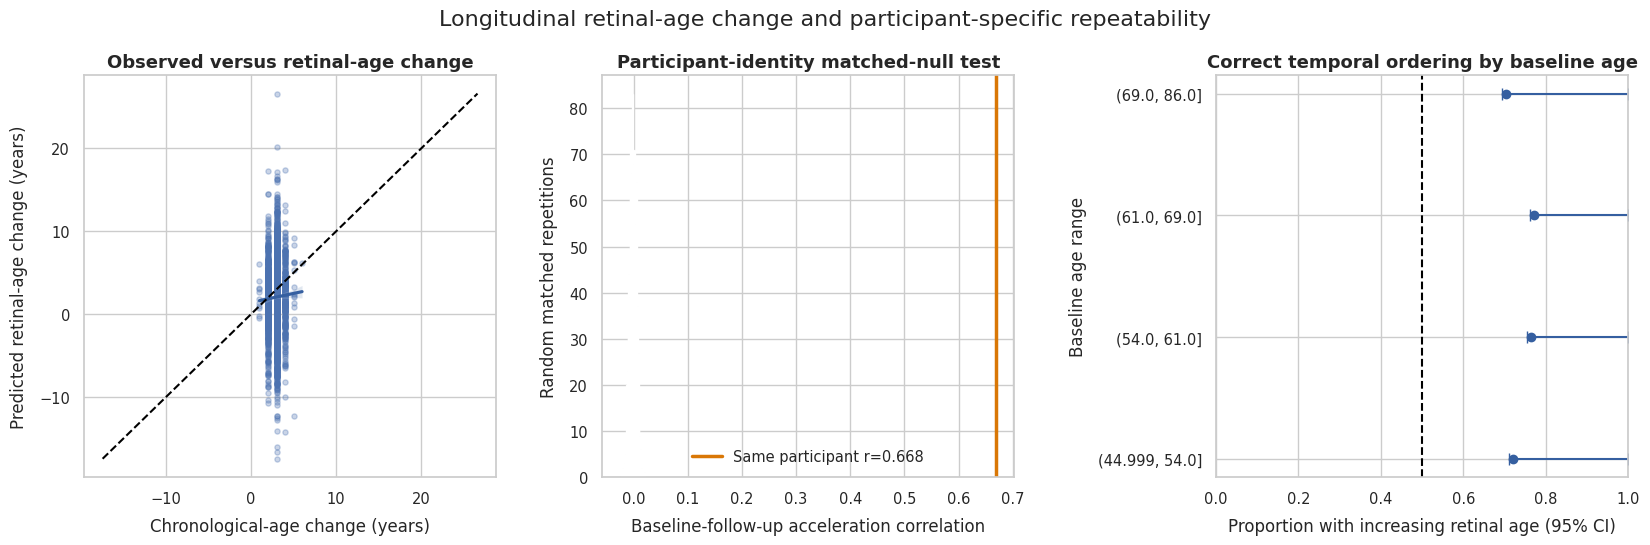

In [0]:
retinal_longitudinal_repeatability = baseline_retinal[
    [
        "participant_id",
        "chronological_age_bl",
        "retinal_age_bl",
        "retinal_acceleration_bl",
    ]
].merge(
    followup_retinal[
        [
            "participant_id",
            "chronological_age_f1",
            "retinal_age_f1",
            "retinal_acceleration_f1",
        ]
    ],
    on="participant_id",
    how="inner",
    validate="one_to_one",
)
retinal_longitudinal_repeatability["followup_years"] = (
    retinal_longitudinal_repeatability["chronological_age_f1"]
    - retinal_longitudinal_repeatability["chronological_age_bl"]
)
retinal_longitudinal_repeatability = retinal_longitudinal_repeatability[
    retinal_longitudinal_repeatability["followup_years"].between(0.25, 15)
].dropna().copy()
retinal_longitudinal_repeatability["observed_age_change"] = (
    retinal_longitudinal_repeatability["followup_years"]
)
retinal_longitudinal_repeatability["predicted_retinal_age_change"] = (
    retinal_longitudinal_repeatability["retinal_age_f1"]
    - retinal_longitudinal_repeatability["retinal_age_bl"]
)
retinal_longitudinal_repeatability["retinal_change_error"] = (
    retinal_longitudinal_repeatability["predicted_retinal_age_change"]
    - retinal_longitudinal_repeatability["observed_age_change"]
)
retinal_longitudinal_repeatability["direction_correct"] = (
    retinal_longitudinal_repeatability["predicted_retinal_age_change"] > 0
)


def _repeatability_summary(frame, analysis, seed):
    observed_change = frame["observed_age_change"].to_numpy(float)
    predicted_change = frame[
        "predicted_retinal_age_change"
    ].to_numpy(float)
    acceleration_bl = frame["retinal_acceleration_bl"].to_numpy(float)
    acceleration_f1 = frame["retinal_acceleration_f1"].to_numpy(float)
    change_correlation = stats.pearsonr(
        observed_change,
        predicted_change,
    )
    stability_correlation = stats.pearsonr(
        acceleration_bl,
        acceleration_f1,
    )
    direction_count = int(np.sum(predicted_change > 0))
    direction_test = stats.binomtest(
        direction_count,
        len(frame),
        p=0.5,
        alternative="greater",
    )
    direction_interval = direction_test.proportion_ci(
        confidence_level=0.95,
        method="exact",
    )
    rng = np.random.default_rng(seed)
    bootstrap_mae = np.empty(
        publication_bootstrap_repetitions,
        dtype=float,
    )
    bootstrap_bias = np.empty_like(bootstrap_mae)
    bootstrap_direction = np.empty_like(bootstrap_mae)
    for repetition in range(publication_bootstrap_repetitions):
        sampled = rng.integers(0, len(frame), len(frame))
        bootstrap_mae[repetition] = mean_absolute_error(
            observed_change[sampled],
            predicted_change[sampled],
        )
        bootstrap_bias[repetition] = np.mean(
            predicted_change[sampled] - observed_change[sampled]
        )
        bootstrap_direction[repetition] = np.mean(
            predicted_change[sampled] > 0
        )
    slope, intercept = np.polyfit(observed_change, predicted_change, 1)
    return {
        "analysis": analysis,
        "n": int(len(frame)),
        "mean_followup_years": float(np.mean(observed_change)),
        "mean_predicted_change_years": float(np.mean(predicted_change)),
        "change_mae_years": float(
            mean_absolute_error(observed_change, predicted_change)
        ),
        "change_mae_ci_low": float(np.quantile(bootstrap_mae, 0.025)),
        "change_mae_ci_high": float(np.quantile(bootstrap_mae, 0.975)),
        "change_bias_years": float(
            np.mean(predicted_change - observed_change)
        ),
        "change_bias_ci_low": float(np.quantile(bootstrap_bias, 0.025)),
        "change_bias_ci_high": float(np.quantile(bootstrap_bias, 0.975)),
        "change_pearson_r": float(change_correlation.statistic),
        "change_pearson_p": float(change_correlation.pvalue),
        "change_calibration_slope": float(slope),
        "change_calibration_intercept": float(intercept),
        "acceleration_stability_r": float(stability_correlation.statistic),
        "acceleration_stability_p": float(stability_correlation.pvalue),
        "direction_correct_proportion": float(direction_count / len(frame)),
        "direction_correct_ci_low": float(direction_interval.low),
        "direction_correct_ci_high": float(direction_interval.high),
        "direction_correct_binomial_p": float(direction_test.pvalue),
        "direction_correct_bootstrap_ci_low": float(
            np.quantile(bootstrap_direction, 0.025)
        ),
        "direction_correct_bootstrap_ci_high": float(
            np.quantile(bootstrap_direction, 0.975)
        ),
    }


longitudinal_repeatability_rows = [
    _repeatability_summary(
        retinal_longitudinal_repeatability,
        "All participants with baseline and F1 retinal predictions",
        random_state + 27000,
    )
]
retinal_longitudinal_repeatability["baseline_age_stratum"] = pd.qcut(
    retinal_longitudinal_repeatability["chronological_age_bl"],
    q=4,
    duplicates="drop",
)
retinal_longitudinal_repeatability["followup_interval_stratum"] = pd.qcut(
    retinal_longitudinal_repeatability["followup_years"],
    q=4,
    duplicates="drop",
)
for stratum_column, label_prefix in (
    ("baseline_age_stratum", "Baseline age"),
    ("followup_interval_stratum", "Follow-up interval"),
):
    for stratum_index, (stratum, subset) in enumerate(
        retinal_longitudinal_repeatability.groupby(
            stratum_column,
            observed=True,
        )
    ):
        if len(subset) < minimum_age_bin_n:
            continue
        longitudinal_repeatability_rows.append(
            _repeatability_summary(
                subset,
                f"{label_prefix}: {stratum}",
                random_state + 27100 + 10 * stratum_index,
            )
        )
longitudinal_repeatability_summary = pd.DataFrame(
    longitudinal_repeatability_rows
)

# Compare true within-participant acceleration stability with random
# follow-up assignments matched on baseline age and follow-up interval.
null_work = retinal_longitudinal_repeatability.copy()
null_work["age_match_bin"] = (
    np.floor(null_work["chronological_age_bl"] / 2) * 2
)
null_work["interval_match_bin"] = pd.qcut(
    null_work["followup_years"],
    q=min(5, null_work["followup_years"].nunique()),
    labels=False,
    duplicates="drop",
)
null_work["match_stratum"] = (
    null_work["age_match_bin"].astype(str)
    + "|"
    + null_work["interval_match_bin"].astype(str)
)
match_groups = [
    indices.to_numpy()
    for _, indices in null_work.groupby("match_stratum").groups.items()
    if len(indices) >= 2
]
eligible_indices = np.sort(np.concatenate(match_groups))
baseline_acceleration = null_work.loc[
    eligible_indices,
    "retinal_acceleration_bl",
].to_numpy(float)
followup_acceleration = null_work.loc[
    eligible_indices,
    "retinal_acceleration_f1",
].to_numpy(float)
observed_identity_r = float(
    stats.pearsonr(baseline_acceleration, followup_acceleration).statistic
)
observed_identity_mae = float(
    mean_absolute_error(baseline_acceleration, followup_acceleration)
)
global_to_eligible = {
    global_index: local_index
    for local_index, global_index in enumerate(eligible_indices)
}
local_match_groups = [
    np.asarray([global_to_eligible[index] for index in indices], dtype=int)
    for indices in match_groups
]
rng = np.random.default_rng(random_state + 28000)
matched_null_rows = []
for repetition in range(publication_bootstrap_repetitions):
    randomized_followup = followup_acceleration.copy()
    for indices in local_match_groups:
        permuted_order = rng.permutation(indices)
        randomized_followup[permuted_order] = np.roll(
            followup_acceleration[permuted_order],
            1,
        )
    matched_null_rows.append(
        {
            "repetition": repetition + 1,
            "random_matched_stability_r": float(
                stats.pearsonr(
                    baseline_acceleration,
                    randomized_followup,
                ).statistic
            ),
            "random_matched_acceleration_mae": float(
                mean_absolute_error(
                    baseline_acceleration,
                    randomized_followup,
                )
            ),
        }
    )
longitudinal_matched_null = pd.DataFrame(matched_null_rows)
longitudinal_identity_test = pd.DataFrame(
    [
        {
            "n_matched_participants": int(len(eligible_indices)),
            "observed_same_participant_stability_r": observed_identity_r,
            "random_matched_r_mean": float(
                longitudinal_matched_null[
                    "random_matched_stability_r"
                ].mean()
            ),
            "random_matched_r_95_low": float(
                longitudinal_matched_null[
                    "random_matched_stability_r"
                ].quantile(0.025)
            ),
            "random_matched_r_95_high": float(
                longitudinal_matched_null[
                    "random_matched_stability_r"
                ].quantile(0.975)
            ),
            "same_participant_r_empirical_p": float(
                (
                    1
                    + longitudinal_matched_null[
                        "random_matched_stability_r"
                    ].ge(observed_identity_r).sum()
                )
                / (len(longitudinal_matched_null) + 1)
            ),
            "observed_same_participant_acceleration_mae": (
                observed_identity_mae
            ),
            "random_matched_mae_mean": float(
                longitudinal_matched_null[
                    "random_matched_acceleration_mae"
                ].mean()
            ),
            "same_participant_mae_empirical_p": float(
                (
                    1
                    + longitudinal_matched_null[
                        "random_matched_acceleration_mae"
                    ].le(observed_identity_mae).sum()
                )
                / (len(longitudinal_matched_null) + 1)
            ),
        }
    ]
)

# Same-eye repeatability prevents changes in eye availability from masquerading
# as within-person retinal-age change.
baseline_eye_longitudinal = eye_predictions[
    eye_predictions["visit"].eq("BL")
][
    [
        "participant_id",
        "eye_standardized",
        "chronological_age",
        "retinal_age_eye",
    ]
].rename(
    columns={
        "chronological_age": "chronological_age_bl",
        "retinal_age_eye": "retinal_age_eye_bl",
    }
)
followup_eye_longitudinal = eye_predictions[
    eye_predictions["visit"].eq("F1")
][
    [
        "participant_id",
        "eye_standardized",
        "chronological_age",
        "retinal_age_eye",
    ]
].rename(
    columns={
        "chronological_age": "chronological_age_f1",
        "retinal_age_eye": "retinal_age_eye_f1",
    }
)
same_eye_longitudinal = baseline_eye_longitudinal.merge(
    followup_eye_longitudinal,
    on=["participant_id", "eye_standardized"],
    how="inner",
    validate="one_to_one",
)
same_eye_longitudinal["observed_age_change"] = (
    same_eye_longitudinal["chronological_age_f1"]
    - same_eye_longitudinal["chronological_age_bl"]
)
same_eye_longitudinal["predicted_retinal_age_change"] = (
    same_eye_longitudinal["retinal_age_eye_f1"]
    - same_eye_longitudinal["retinal_age_eye_bl"]
)
same_eye_longitudinal = same_eye_longitudinal[
    same_eye_longitudinal["observed_age_change"].between(0.25, 15)
].dropna().copy()
same_eye_repeatability_rows = []
for eye, subset in same_eye_longitudinal.groupby("eye_standardized"):
    if len(subset) < minimum_age_bin_n:
        continue
    direction_count = int(
        subset["predicted_retinal_age_change"].gt(0).sum()
    )
    direction_interval = stats.binomtest(
        direction_count,
        len(subset),
        p=0.5,
        alternative="greater",
    ).proportion_ci(confidence_level=0.95, method="exact")
    same_eye_repeatability_rows.append(
        {
            "eye": eye,
            "n_eye_pairs": int(len(subset)),
            "n_unique_participants": int(
                subset["participant_id"].nunique()
            ),
            "change_mae_years": float(
                mean_absolute_error(
                    subset["observed_age_change"],
                    subset["predicted_retinal_age_change"],
                )
            ),
            "change_pearson_r": float(
                stats.pearsonr(
                    subset["observed_age_change"],
                    subset["predicted_retinal_age_change"],
                ).statistic
            ),
            "direction_correct_proportion": float(
                direction_count / len(subset)
            ),
            "direction_correct_ci_low": float(direction_interval.low),
            "direction_correct_ci_high": float(direction_interval.high),
        }
    )
same_eye_repeatability = pd.DataFrame(same_eye_repeatability_rows)

# Quantify visit-related technical drift using the available quality ledger.
longitudinal_quality_source = pd.concat(
    quality_frames,
    ignore_index=True,
).drop_duplicates("image_path", keep="last")
if "participant_id" not in longitudinal_quality_source.columns:
    if "participant_id_parsed" in longitudinal_quality_source.columns:
        longitudinal_quality_source = longitudinal_quality_source.rename(
            columns={"participant_id_parsed": "participant_id"}
        )
    else:
        raise ValueError("Quality ledger has no participant identifier")
longitudinal_quality_source["participant_id"] = normalize_identifier(
    longitudinal_quality_source["participant_id"]
)
longitudinal_quality_source["visit"] = normalize_visit(
    longitudinal_quality_source["visit"]
)
longitudinal_quality_source["technical_quality_pass"] = normalized_code(
    longitudinal_quality_source["quality_pass"]
).isin({"1", "TRUE", "T", "Y", "YES"})
longitudinal_ids = set(
    retinal_longitudinal_repeatability["participant_id"].astype(str)
)
longitudinal_quality_source = longitudinal_quality_source[
    longitudinal_quality_source["technical_quality_pass"]
    & longitudinal_quality_source["participant_id"].isin(longitudinal_ids)
    & longitudinal_quality_source["visit"].isin(["BL", "F1"])
].copy()
quality_drift_component_columns = []
for metric in strict_quality_metrics:
    values = pd.to_numeric(
        longitudinal_quality_source[metric],
        errors="coerce",
    )
    if metric in high_is_good_metrics:
        component = values.rank(pct=True)
    elif metric in low_is_good_metrics:
        component = (-values).rank(pct=True)
    else:
        baseline_center = float(
            values[
                longitudinal_quality_source["visit"].eq("BL")
            ].median()
        )
        component = (-abs(values - baseline_center)).rank(pct=True)
    component_column = f"longitudinal_quality_component_{metric}"
    longitudinal_quality_source[component_column] = component
    quality_drift_component_columns.append(component_column)
longitudinal_quality_source["longitudinal_quality_score"] = (
    longitudinal_quality_source[
        quality_drift_component_columns
    ].mean(axis=1, skipna=True)
)
longitudinal_quality_by_visit = (
    longitudinal_quality_source.groupby(
        ["participant_id", "visit"],
        as_index=False,
    )
    .agg(
        mean_quality_score=("longitudinal_quality_score", "mean"),
        quality_image_count=("image_path", "nunique"),
    )
)
quality_bl = longitudinal_quality_by_visit[
    longitudinal_quality_by_visit["visit"].eq("BL")
].drop(columns="visit").rename(
    columns={
        "mean_quality_score": "quality_score_bl",
        "quality_image_count": "quality_image_count_bl",
    }
)
quality_f1 = longitudinal_quality_by_visit[
    longitudinal_quality_by_visit["visit"].eq("F1")
].drop(columns="visit").rename(
    columns={
        "mean_quality_score": "quality_score_f1",
        "quality_image_count": "quality_image_count_f1",
    }
)
longitudinal_quality_drift = retinal_longitudinal_repeatability.merge(
    quality_bl,
    on="participant_id",
    how="left",
    validate="one_to_one",
).merge(
    quality_f1,
    on="participant_id",
    how="left",
    validate="one_to_one",
)
longitudinal_quality_drift["quality_score_change"] = (
    longitudinal_quality_drift["quality_score_f1"]
    - longitudinal_quality_drift["quality_score_bl"]
)
longitudinal_quality_drift["quality_image_count_change"] = (
    longitudinal_quality_drift["quality_image_count_f1"]
    - longitudinal_quality_drift["quality_image_count_bl"]
)
quality_adjusted_work = longitudinal_quality_drift.dropna(
    subset=[
        "retinal_acceleration_bl",
        "retinal_acceleration_f1",
        "followup_years",
        "quality_score_bl",
        "quality_score_change",
        "quality_image_count_bl",
        "quality_image_count_change",
    ]
).copy()
if len(quality_adjusted_work) >= minimum_questionnaire_observed:
    quality_adjusted_stability_fit = smf.ols(
        "retinal_acceleration_f1 ~ retinal_acceleration_bl "
        "+ followup_years + quality_score_bl + quality_score_change "
        "+ quality_image_count_bl + quality_image_count_change",
        data=quality_adjusted_work,
    ).fit(cov_type="HC3")
    quality_adjusted_stability = pd.DataFrame(
        {
            "term": quality_adjusted_stability_fit.params.index,
            "coefficient": quality_adjusted_stability_fit.params.values,
            "standard_error": quality_adjusted_stability_fit.bse.values,
            "p_value": quality_adjusted_stability_fit.pvalues.values,
            "n": int(quality_adjusted_stability_fit.nobs),
        }
    )
    confidence = quality_adjusted_stability_fit.conf_int()
    quality_adjusted_stability["ci_low"] = confidence.iloc[:, 0].to_numpy()
    quality_adjusted_stability["ci_high"] = confidence.iloc[:, 1].to_numpy()
else:
    quality_adjusted_stability = pd.DataFrame()

write_frame(
    retinal_longitudinal_repeatability.drop(
        columns=[
            "baseline_age_stratum",
            "followup_interval_stratum",
        ],
        errors="ignore",
    ),
    private_root / "retinal_longitudinal_repeatability_private.parquet",
)
write_frame(
    longitudinal_repeatability_summary,
    statistics_root / "longitudinal_retinal_change_repeatability.csv",
)
write_frame(
    longitudinal_identity_test,
    statistics_root / "longitudinal_same_person_matched_null_test.csv",
)
write_frame(
    longitudinal_matched_null,
    statistics_root / "longitudinal_matched_null_distribution.csv",
)
write_frame(
    same_eye_repeatability,
    statistics_root / "longitudinal_same_eye_repeatability.csv",
)
write_frame(
    quality_adjusted_stability,
    statistics_root / "longitudinal_quality_adjusted_stability.csv",
)
display(longitudinal_repeatability_summary.round(5))
display(longitudinal_identity_test.round(5))
if same_eye_repeatability.empty:
    print(
        "No same-eye longitudinal subgroup met the minimum sample-size "
        "threshold; the same-eye table is empty."
    )
else:
    display(same_eye_repeatability.round(5))
if quality_adjusted_stability.empty:
    print(
        "Too few complete quality-linked longitudinal observations for "
        "the quality-adjusted model; the result table is empty."
    )
else:
    display(quality_adjusted_stability.round(5))

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16.5, 5.5),
    layout="constrained",
)
plot_repeatability = retinal_longitudinal_repeatability.sample(
    min(maximum_scatter_points, len(retinal_longitudinal_repeatability)),
    random_state=random_state,
)
sns.regplot(
    data=plot_repeatability,
    x="observed_age_change",
    y="predicted_retinal_age_change",
    scatter_kws={"s": 14, "alpha": 0.30},
    line_kws={"color": "#355FA0"},
    ax=axes[0],
)
change_lower = float(
    min(
        plot_repeatability["observed_age_change"].min(),
        plot_repeatability["predicted_retinal_age_change"].min(),
    )
)
change_upper = float(
    max(
        plot_repeatability["observed_age_change"].max(),
        plot_repeatability["predicted_retinal_age_change"].max(),
    )
)
axes[0].plot(
    [change_lower, change_upper],
    [change_lower, change_upper],
    "--",
    color="black",
)
axes[0].set(
    title="Observed versus retinal-age change",
    xlabel="Chronological-age change (years)",
    ylabel="Predicted retinal-age change (years)",
)

axes[1].hist(
    longitudinal_matched_null["random_matched_stability_r"],
    bins=35,
    color="#AAB4B6",
    edgecolor="white",
)
axes[1].axvline(
    observed_identity_r,
    color="#D97706",
    linewidth=2.5,
    label=f"Same participant r={observed_identity_r:.3f}",
)
axes[1].set(
    title="Participant-identity matched-null test",
    xlabel="Baseline-follow-up acceleration correlation",
    ylabel="Random matched repetitions",
)
axes[1].legend(frameon=False)

direction_plot = longitudinal_repeatability_summary[
    longitudinal_repeatability_summary["analysis"].str.startswith(
        "Baseline age:"
    )
].copy()
direction_positions = np.arange(len(direction_plot))
direction_center = direction_plot[
    "direction_correct_proportion"
].to_numpy(float)
axes[2].errorbar(
    direction_center,
    direction_positions,
    xerr=np.maximum(
        0,
        np.vstack(
            [
                direction_center
                - direction_plot["direction_correct_ci_low"],
                direction_plot["direction_correct_ci_high"]
                - direction_center,
            ]
        ),
    ),
    fmt="o",
    color="#355FA0",
    capsize=4,
)
axes[2].axvline(0.5, color="black", linestyle="--")
axes[2].set_yticks(
    direction_positions,
    direction_plot["analysis"].str.replace(
        "Baseline age: ",
        "",
        regex=False,
    ),
)
axes[2].set(
    title="Correct temporal ordering by baseline age",
    xlabel="Proportion with increasing retinal age (95% CI)",
    ylabel="Baseline age range",
    xlim=(0, 1),
)
figure.suptitle(
    "Longitudinal retinal-age change and participant-specific repeatability"
)
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_22_longitudinal_repeatability_identity_test.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3,
)
plt.show()
plt.close(figure)


In [ ]:
# Persistence-only input for Figure 4C; identifiers are excluded.
write_frame(
    retinal_longitudinal_repeatability[
        ["retinal_acceleration_bl", "retinal_acceleration_f1"]
    ].sort_values(
        ["retinal_acceleration_bl", "retinal_acceleration_f1"],
        kind="stable",
    ),
    statistics_root / "figure_04_longitudinal_points.parquet",
)
annualized_change_for_figure = (
    retinal_longitudinal_repeatability["predicted_retinal_age_change"]
    / retinal_longitudinal_repeatability["followup_years"]
)
write_frame(
    pd.DataFrame(
        {
            "annualized_retinal_age_change": annualized_change_for_figure,
        }
    ),
    statistics_root / "figure_S11_annualized_change.csv",
)
write_frame(
    pd.DataFrame(
        [
            {
                "stage": 1,
                "label": "Baseline retinal prediction",
                "n": int(baseline_retinal["participant_id"].nunique()),
            },
            {
                "stage": 2,
                "label": "Follow-up retinal prediction",
                "n": int(followup_retinal["participant_id"].nunique()),
            },
            {
                "stage": 3,
                "label": "Valid baseline-follow-up pair",
                "n": int(
                    retinal_longitudinal_repeatability[
                        "participant_id"
                    ].nunique()
                ),
            },
        ]
    ),
    statistics_root / "figure_S11_attrition.csv",
)


## 24. Selection, transportability, nonlinear, uncertainty, and power audits

Selection into the methylation subset is modeled from observed baseline
covariates. Stabilized inverse-probability weights are trimmed at the 1st
and 99th percentiles. The section compares included and excluded retinal
participants, tests coefficient transport for discovered numeric
constructs, bootstraps incremental R-squared, checks nonlinear splines,
quantifies negative-control metadata associations, and reports approximate
minimum detectable standardized effects. Repeated methylation and external
validation are explicitly marked unavailable rather than inferred.

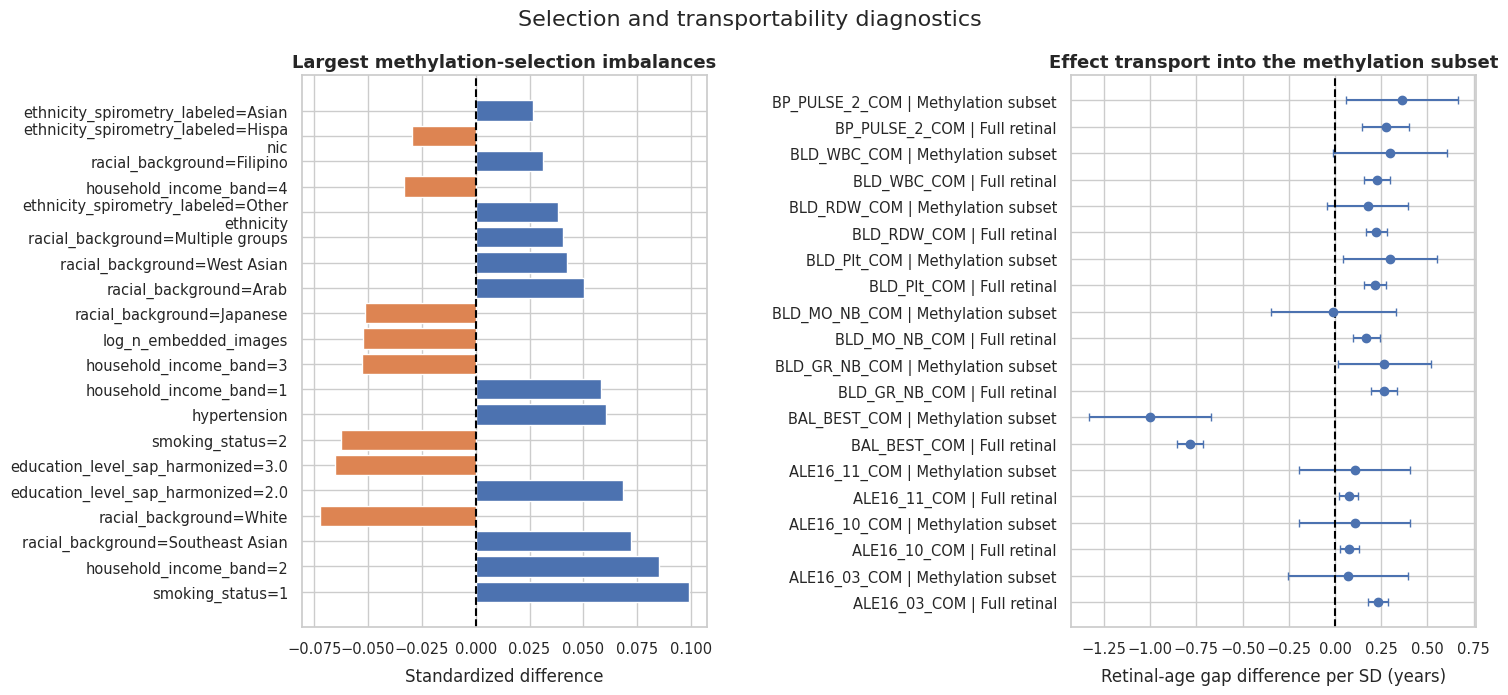

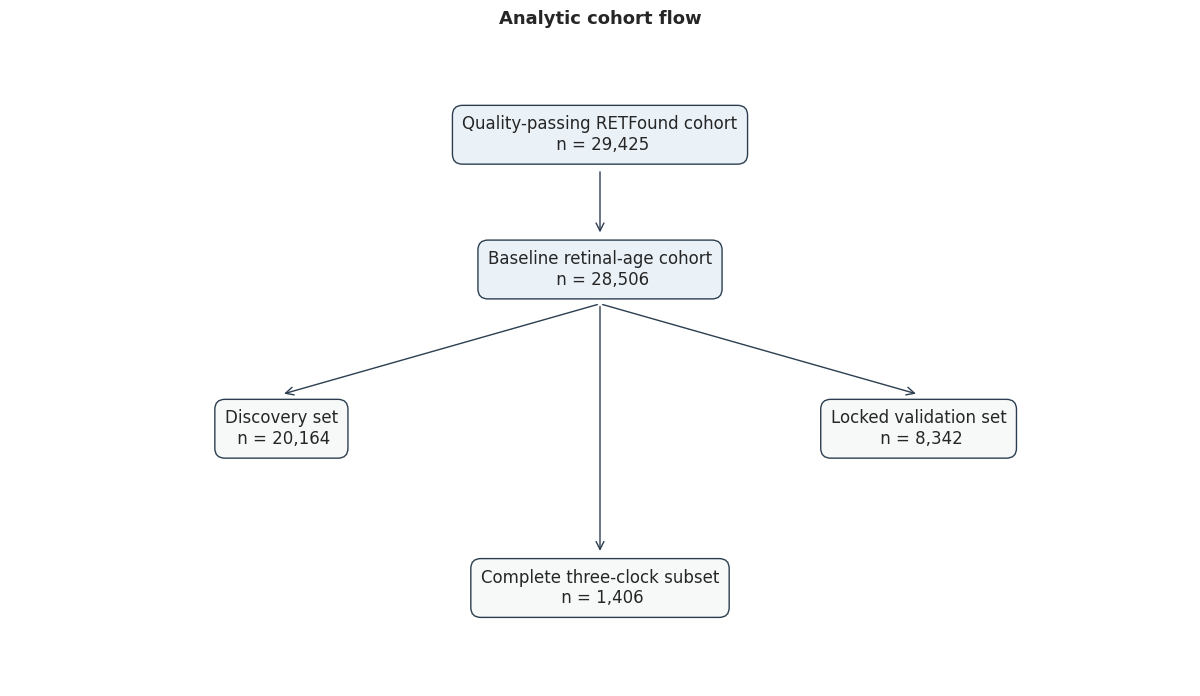

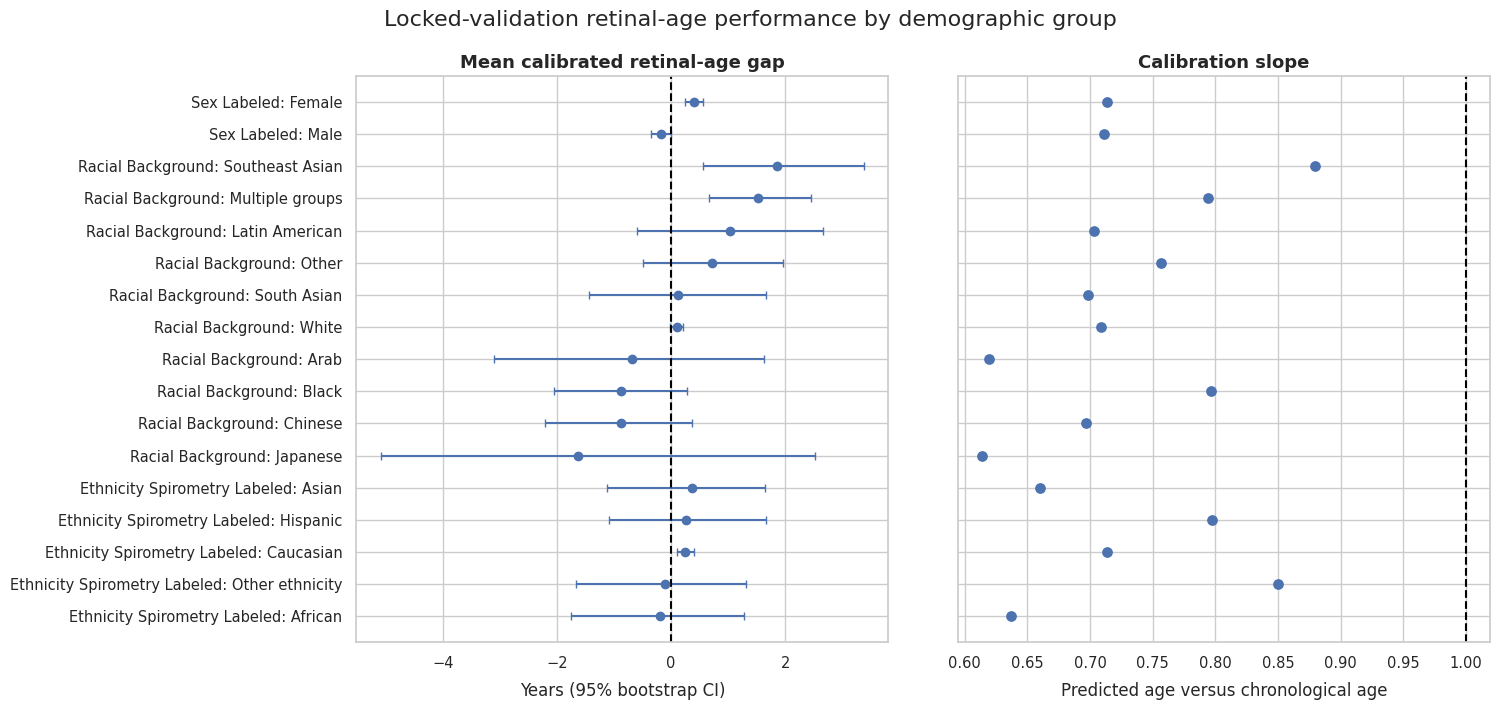

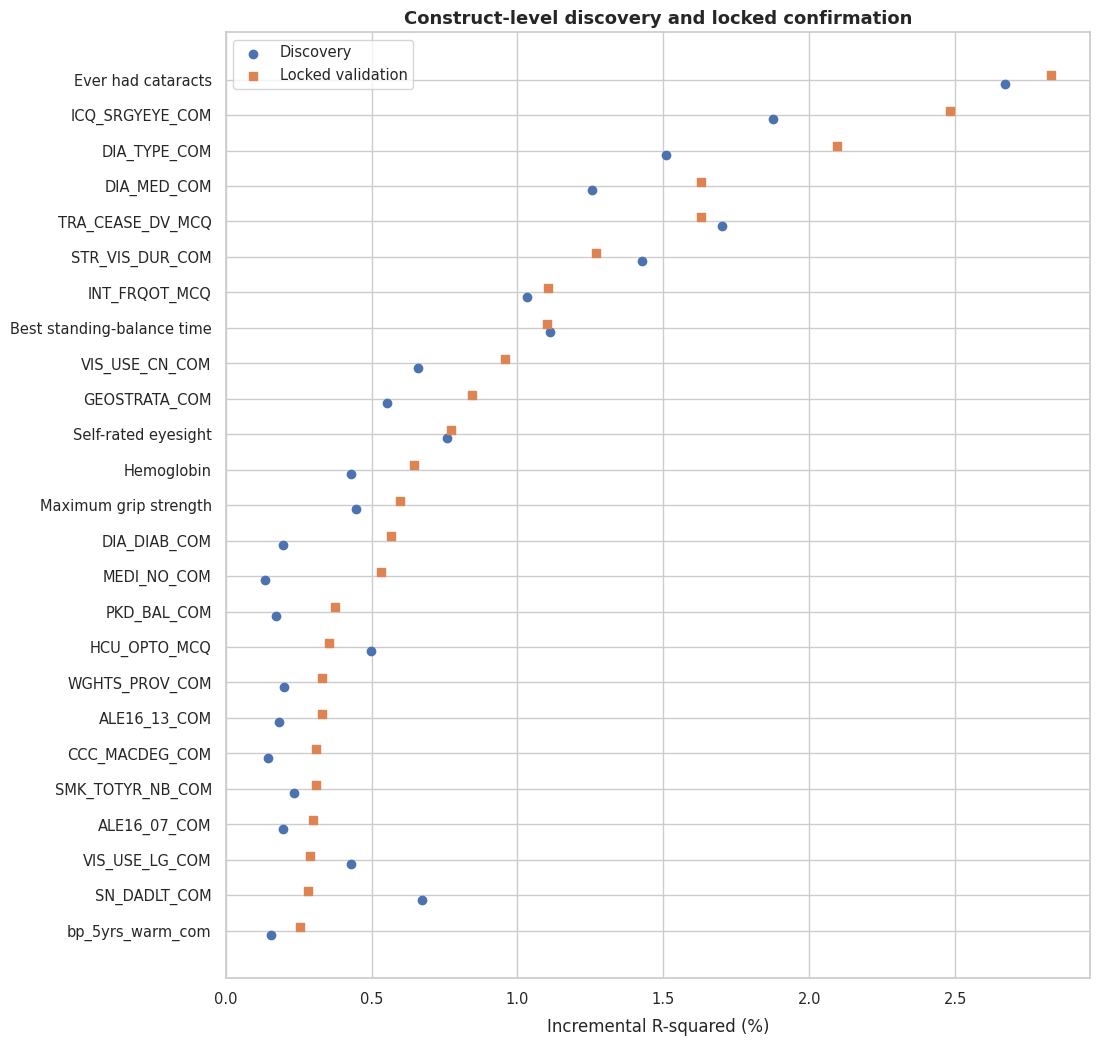

Methylation selection OOF AUC: 0.535


analysis,available,reason
External validation,false,No independent external retinal-plus-methylation cohort was supplied.
Repeated methylation change,false,Released methylation phenotypes are baseline-only.
Manual image grades,false,A blinded review packet was generated; grades must be supplied by masked reviewers.
Site/device heterogeneity,false,"Candidate questionnaire fields exist but are not treated as image-device metadata: INJ_SITE_ML_COM, INJ_SITE_EYE_COM, INJ_SITE_HD_COM, INJ_SITE_NE_COM, INJ_SITE_SH_COM, INJ_SITE_EL_COM, INJ_SITE_WR_COM, INJ_SITE_HIP_COM, INJ_SITE_TH_COM, INJ_SITE_KN_COM, INJ_SITE_AN_COM, INJ_SITE_UP_COM, INJ_SITE_LO_COM, INJ_SITE_CH_COM, INJ_SITE_AB_COM, INJ_SITE_OT_COM, INJ_SITE_DK_NA_COM, INJ_SITE_REFUSED_COM, INJ_SITE_OTSP_COM, INJ_SITE_FN_COM"


cohort,n,alpha_definition,alpha,approximate_mde_standardized_beta,target_power
Full baseline retinal,28506,nominal_0.05,0.05,0.01659,0.8
Full baseline retinal,28506,construct_bonferroni,2.0E-5,0.03035,0.8
Discovery,20164,nominal_0.05,0.05,0.01973,0.8
Discovery,20164,construct_bonferroni,2.0E-5,0.03609,0.8
Locked validation,8342,nominal_0.05,0.05,0.03067,0.8
Locked validation,8342,construct_bonferroni,2.0E-5,0.0561,0.8
Methylation subset,1406,nominal_0.05,0.05,0.07472,0.8
Methylation subset,1406,construct_bonferroni,2.0E-5,0.13665,0.8


In [0]:
selection_frame = locked_analysis.copy()
selection_frame["selected_for_methylation"] = selection_frame[
    "is_epigenetic_subset"
].astype(int)
selection_numeric = [
    column
    for column in (
        "chronological_age",
        "log_n_embedded_images",
        "bmi",
        "body_mass_index",
        "diabetes",
        "hypertension",
    )
    if column in selection_frame
    and pd.to_numeric(selection_frame[column], errors="coerce").notna().sum() >= 100
]
selection_categorical = [
    column
    for column in (
        "sex_labeled",
        "racial_background",
        "ethnicity_spirometry_labeled",
        "smoking_status",
        "education_level_sap_harmonized",
        "household_income_band",
    )
    if column in selection_frame
    and selection_frame[column].notna().sum() >= 100
    and selection_frame[column].nunique(dropna=True) > 1
]
for column in selection_numeric:
    selection_frame[column] = pd.to_numeric(
        selection_frame[column], errors="coerce"
    )
for column in selection_categorical:
    selection_frame[column] = (
        selection_frame[column]
        .astype("object")
        .where(selection_frame[column].notna(), np.nan)
    )
selection_preprocessor = ColumnTransformer(
    [
        (
            "numeric",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            selection_numeric,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "encode",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=20,
                        ),
                    ),
                ]
            ),
            selection_categorical,
        ),
    ],
    remainder="drop",
)
selection_model = Pipeline(
    [
        ("preprocess", selection_preprocessor),
        (
            "logistic",
            LogisticRegression(
                max_iter=2000,
                random_state=random_state,
            ),
        ),
    ]
)
selection_x = selection_frame[
    [*selection_numeric, *selection_categorical]
]
selection_y = selection_frame["selected_for_methylation"].to_numpy(int)
selection_splitter = StratifiedKFold(
    n_splits=cv_folds,
    shuffle=True,
    random_state=random_state,
)
selection_probability = cross_val_predict(
    selection_model,
    selection_x,
    selection_y,
    cv=selection_splitter,
    method="predict_proba",
)[:, 1]
selection_probability = np.clip(selection_probability, 0.01, 0.99)
selection_frame["methylation_selection_probability_oof"] = selection_probability
selected_prevalence = float(np.mean(selection_y))
selection_frame["stabilized_ipw"] = np.where(
    selection_y == 1,
    selected_prevalence / selection_probability,
    (1 - selected_prevalence) / (1 - selection_probability),
)
lower_weight, upper_weight = np.quantile(
    selection_frame["stabilized_ipw"], [0.01, 0.99]
)
selection_frame["stabilized_ipw_trimmed"] = selection_frame[
    "stabilized_ipw"
].clip(lower_weight, upper_weight)
selection_auc = float(roc_auc_score(selection_y, selection_probability))

baseline_comparison_rows = []
for column in selection_numeric:
    values = pd.to_numeric(selection_frame[column], errors="coerce")
    selected_values = values[selection_y == 1].dropna()
    excluded_values = values[selection_y == 0].dropna()
    pooled_sd = np.sqrt(
        (selected_values.var(ddof=1) + excluded_values.var(ddof=1)) / 2
    )
    baseline_comparison_rows.append(
        {
            "variable": column,
            "type": "numeric",
            "methylation_n": int(len(selected_values)),
            "other_retinal_n": int(len(excluded_values)),
            "methylation_value": float(selected_values.mean()),
            "other_retinal_value": float(excluded_values.mean()),
            "standardized_difference": float(
                (selected_values.mean() - excluded_values.mean()) / pooled_sd
            ) if pooled_sd > 0 else np.nan,
        }
    )
for column in selection_categorical:
    for level in sorted(selection_frame[column].dropna().astype(str).unique()):
        selected_level = (
            selection_frame.loc[selection_y == 1, column].astype(str).eq(level)
        )
        excluded_level = (
            selection_frame.loc[selection_y == 0, column].astype(str).eq(level)
        )
        p1 = float(selected_level.mean())
        p0 = float(excluded_level.mean())
        pooled = (p1 + p0) / 2
        denominator = np.sqrt(max(pooled * (1 - pooled), 1e-12))
        baseline_comparison_rows.append(
            {
                "variable": f"{column}={level}",
                "type": "categorical_level",
                "methylation_n": int((selection_y == 1).sum()),
                "other_retinal_n": int((selection_y == 0).sum()),
                "methylation_value": p1,
                "other_retinal_value": p0,
                "standardized_difference": (p1 - p0) / denominator,
            }
        )
baseline_selection_comparison = pd.DataFrame(baseline_comparison_rows)

selected_constructs = construct_confirmation[
    construct_confirmation["discovery_fdr_q"].lt(0.05)
].copy()
transport_rows = []
nonlinear_rows = []
bootstrap_rows = []
for construct_index, selected in selected_constructs.head(30).iterrows():
    variable = selected["representative_variable"]
    if selected["representative_type"] != "numeric":
        continue
    values = load_full_questionnaire_columns([variable])
    work = locked_analysis.merge(
        values,
        on="participant_id",
        how="left",
        validate="one_to_one",
    )
    work["question_value"] = safe_zscore(
        pd.to_numeric(work[variable], errors="coerce")
    )
    work = work.dropna(
        subset=["retinal_age_gap_locked", "question_value", "chronological_age"]
    )
    coefficient_fits = {}
    for cohort_label, cohort_mask in (
        ("Full retinal", pd.Series(True, index=work.index)),
        ("Methylation subset", work["is_epigenetic_subset"]),
    ):
        cohort = work[cohort_mask].copy()
        if len(cohort) < minimum_questionnaire_observed:
            continue
        fit = smf.ols(
            "retinal_age_gap_locked ~ question_value + chronological_age "
            "+ I(chronological_age ** 2) + log_n_embedded_images",
            data=cohort,
        ).fit(cov_type="HC3")
        interval = fit.conf_int().loc["question_value"]
        coefficient_fits[cohort_label] = fit
        transport_rows.append(
            {
                "construct": selected["construct_key"],
                "variable": variable,
                "cohort": cohort_label,
                "n": int(fit.nobs),
                "coefficient": float(fit.params["question_value"]),
                "standard_error": float(fit.bse["question_value"]),
                "ci_low": float(interval.iloc[0]),
                "ci_high": float(interval.iloc[1]),
                "p_value": float(fit.pvalues["question_value"]),
            }
        )
    if len(coefficient_fits) == 2:
        interaction_fit = smf.ols(
            "retinal_age_gap_locked ~ question_value * is_epigenetic_subset "
            "+ chronological_age + I(chronological_age ** 2) "
            "+ log_n_embedded_images",
            data=work,
        ).fit(cov_type="HC3")
        interaction_term = "question_value:is_epigenetic_subset[T.True]"
        if interaction_term not in interaction_fit.params:
            interaction_term = "question_value:is_epigenetic_subset"
        interaction_interval = interaction_fit.conf_int().loc[
            interaction_term
        ]
        transport_rows.append(
            {
                "construct": selected["construct_key"],
                "variable": variable,
                "cohort": "Methylation interaction vs other retinal",
                "n": int(interaction_fit.nobs),
                "coefficient": float(
                    interaction_fit.params[interaction_term]
                ),
                "standard_error": float(
                    interaction_fit.bse[interaction_term]
                ),
                "ci_low": float(interaction_interval.iloc[0]),
                "ci_high": float(interaction_interval.iloc[1]),
                "p_value": float(
                    interaction_fit.pvalues[interaction_term]
                ),
            }
        )

    linear = smf.ols(
        "retinal_age_gap_locked ~ question_value + chronological_age "
        "+ I(chronological_age ** 2) + log_n_embedded_images",
        data=work,
    ).fit()
    spline = smf.ols(
        "retinal_age_gap_locked ~ bs(question_value, df=4, degree=3) "
        "+ chronological_age + I(chronological_age ** 2) "
        "+ log_n_embedded_images",
        data=work,
    ).fit()
    nonlinear_f, nonlinear_p, nonlinear_df = spline.compare_f_test(linear)
    nonlinear_rows.append(
        {
            "construct": selected["construct_key"],
            "variable": variable,
            "n": int(spline.nobs),
            "nonlinear_incremental_r2": float(spline.rsquared - linear.rsquared),
            "f_statistic": float(nonlinear_f),
            "p_value": float(nonlinear_p),
            "df_difference": float(nonlinear_df),
        }
    )

    rng = np.random.default_rng(random_state + int(construct_index))
    bootstrap_increment = []
    for _ in range(publication_bootstrap_repetitions):
        sampled_index = rng.integers(0, len(work), len(work))
        sampled = work.iloc[sampled_index]
        try:
            base = smf.ols(
                "retinal_age_gap_locked ~ chronological_age "
                "+ I(chronological_age ** 2) + log_n_embedded_images",
                data=sampled,
            ).fit()
            full = smf.ols(
                "retinal_age_gap_locked ~ question_value + chronological_age "
                "+ I(chronological_age ** 2) + log_n_embedded_images",
                data=sampled,
            ).fit()
            bootstrap_increment.append(full.rsquared - base.rsquared)
        except Exception:
            continue
    bootstrap_rows.append(
        {
            "construct": selected["construct_key"],
            "variable": variable,
            "n": int(len(work)),
            "incremental_r2": float(linear.rsquared - smf.ols(
                "retinal_age_gap_locked ~ chronological_age "
                "+ I(chronological_age ** 2) + log_n_embedded_images",
                data=work,
            ).fit().rsquared),
            "bootstrap_ci_low": float(np.quantile(bootstrap_increment, 0.025)),
            "bootstrap_ci_high": float(np.quantile(bootstrap_increment, 0.975)),
            "successful_bootstraps": int(len(bootstrap_increment)),
        }
    )

coefficient_transport = pd.DataFrame(transport_rows)
nonlinear_checks = pd.DataFrame(nonlinear_rows)
if not nonlinear_checks.empty:
    nonlinear_checks["fdr_q_value"] = benjamini_hochberg(
        nonlinear_checks["p_value"].to_numpy(float)
    )
incremental_r2_bootstrap = pd.DataFrame(bootstrap_rows)

negative_control_variables = [
    column
    for column in questionnaire_source_columns
    if questionnaire_procedural_pattern.search(column)
]
negative_control_rows = []
if negative_control_variables:
    negative_values = load_full_questionnaire_columns(
        negative_control_variables
    )
    negative_data = locked_analysis.merge(
        negative_values,
        on="participant_id",
        how="left",
        validate="one_to_one",
    )
    for variable in negative_control_variables:
        for phase in ("Discovery grouped OOF", "Locked validation"):
            try:
                result, status = fit_retinal_questionnaire_model(
                    negative_data[negative_data["analysis_phase"].eq(phase)],
                    variable,
                    phase,
                )
                if result is not None:
                    result["negative_control_reason"] = (
                        "assessment completion or recording metadata"
                    )
                    negative_control_rows.append(result)
            except Exception as error:
                negative_control_rows.append(
                    {
                        "variable": variable,
                        "phase": phase,
                        "status": f"failed:{type(error).__name__}",
                    }
                )
negative_control_audit = pd.DataFrame(negative_control_rows)
if not negative_control_audit.empty and "p_value" in negative_control_audit:
    valid_negative = negative_control_audit["p_value"].notna()
    negative_control_audit.loc[valid_negative, "fdr_q_value"] = (
        benjamini_hochberg(
            negative_control_audit.loc[valid_negative, "p_value"].to_numpy(float)
        )
    )

power_rows = []
alpha_levels = {
    "nominal_0.05": 0.05,
    "construct_bonferroni": 0.05 / max(1, len(construct_confirmation)),
}
for cohort_name, cohort_n in {
    "Full baseline retinal": len(locked_analysis),
    "Discovery": len(discovery_locked),
    "Locked validation": len(validation_locked),
    "Methylation subset": int(selection_y.sum()),
}.items():
    for alpha_name, alpha in alpha_levels.items():
        z_alpha = stats.norm.ppf(1 - alpha / 2)
        z_power = stats.norm.ppf(0.80)
        power_rows.append(
            {
                "cohort": cohort_name,
                "n": int(cohort_n),
                "alpha_definition": alpha_name,
                "alpha": alpha,
                "approximate_mde_standardized_beta": float(
                    (z_alpha + z_power) / np.sqrt(max(cohort_n, 1))
                ),
                "target_power": 0.80,
            }
        )
power_mde = pd.DataFrame(power_rows)

demographic_performance_rows = []
for phase, phase_frame in locked_analysis.groupby("analysis_phase"):
    for group_column in (
        "sex_labeled",
        "racial_background",
        "ethnicity_spirometry_labeled",
    ):
        if group_column not in phase_frame:
            continue
        for level, group in phase_frame.groupby(group_column, dropna=True):
            if len(group) < minimum_reporting_group_n:
                continue
            metrics = regression_metrics(
                group,
                "chronological_age",
                "retinal_age_locked",
                f"{phase}: {group_column}={level}",
            )
            low, high = bootstrap_mean_ci(
                group["retinal_age_gap_locked"],
                publication_bootstrap_repetitions,
                random_state + len(demographic_performance_rows),
            )
            demographic_performance_rows.append(
                {
                    **metrics,
                    "phase": phase,
                    "group_variable": group_column,
                    "group_level": str(level),
                    "mean_gap_ci_low": low,
                    "mean_gap_ci_high": high,
                }
            )
locked_demographic_performance = pd.DataFrame(
    demographic_performance_rows
)

interaction_rows = []
for group_column in (
    "sex_labeled",
    "racial_background",
    "ethnicity_spirometry_labeled",
):
    if group_column not in validation_locked.columns:
        validation_interaction = validation_locked.merge(
            baseline_model_frame[
                ["participant_id", group_column]
            ].drop_duplicates("participant_id"),
            on="participant_id",
            how="left",
        ) if group_column in baseline_model_frame else pd.DataFrame()
    else:
        validation_interaction = validation_locked.copy()
    if (
        validation_interaction.empty
        or validation_interaction[group_column].notna().sum()
        < minimum_questionnaire_observed
        or validation_interaction[group_column].nunique(dropna=True) < 2
    ):
        continue
    validation_interaction["demographic_group"] = (
        validation_interaction[group_column]
        .astype("string")
        .str.strip()
        .fillna("Missing")
        .astype(str)
        .astype("object")
    )
    reduced = smf.ols(
        f"retinal_age_gap_locked ~ chronological_age + "
        "I(chronological_age ** 2) + C(demographic_group)",
        data=validation_interaction,
        missing="drop",
    ).fit()
    expanded = smf.ols(
        f"retinal_age_gap_locked ~ chronological_age + "
        "I(chronological_age ** 2) + C(demographic_group) "
        "+ chronological_age:C(demographic_group)",
        data=validation_interaction,
        missing="drop",
    ).fit()
    f_statistic, p_value, df_difference = expanded.compare_f_test(reduced)
    interaction_rows.append(
        {
            "group_variable": group_column,
            "n": int(expanded.nobs),
            "incremental_r2": float(expanded.rsquared - reduced.rsquared),
            "interaction_f": float(f_statistic),
            "p_value": float(p_value),
            "df_difference": float(df_difference),
        }
    )
demographic_age_interactions = pd.DataFrame(interaction_rows)
if not demographic_age_interactions.empty:
    demographic_age_interactions["fdr_q_value"] = benjamini_hochberg(
        demographic_age_interactions["p_value"].to_numpy(float)
    )

partial_clock_rows = []
clock_acceleration_candidates = {
    "Horvath cross-fitted acceleration": "z_horvath_acceleration",
    "Hannum cross-fitted acceleration": "z_hannum_acceleration",
    "Released acceleration difference": "epigenetic_age_acceleration_difference",
    "Released acceleration residual": "epigenetic_age_acceleration_residual",
    "IEAA": "epigenetic_ieaa",
    "EEAA": "epigenetic_eeaa",
}
partial_covariate_terms = ["chronological_age", "I(chronological_age ** 2)"]
for column in association_categorical_columns:
    partial_covariate_terms.append(f"C({column})")
for label, clock_column in clock_acceleration_candidates.items():
    if clock_column not in tri_age:
        continue
    partial_work = tri_age[
        [
            "z_retinal_acceleration",
            clock_column,
            "chronological_age",
            *association_categorical_columns,
        ]
    ].dropna().copy()
    if len(partial_work) < minimum_questionnaire_observed:
        continue
    retinal_residual = smf.ols(
        "z_retinal_acceleration ~ " + " + ".join(partial_covariate_terms),
        data=partial_work,
    ).fit().resid
    clock_residual = smf.ols(
        f"{clock_column} ~ " + " + ".join(partial_covariate_terms),
        data=partial_work,
    ).fit().resid
    correlation = stats.pearsonr(retinal_residual, clock_residual)
    partial_clock_rows.append(
        {
            "epigenetic_measure": label,
            "source_column": clock_column,
            "n": int(len(partial_work)),
            "partial_r": float(correlation.statistic),
            "p_value": float(correlation.pvalue),
        }
    )
partial_clock_correlations = pd.DataFrame(partial_clock_rows)
if not partial_clock_correlations.empty:
    partial_clock_correlations["fdr_q_value"] = benjamini_hochberg(
        partial_clock_correlations["p_value"].to_numpy(float)
    )

reliability_sensitivity_rows = []
retinal_reliability = float(inter_eye_metrics["ccc"].iloc[0])
if np.isfinite(retinal_reliability) and retinal_reliability > 0:
    for record in partial_clock_correlations.itertuples(index=False):
        for assumed_epigenetic_reliability in (0.80, 0.90, 0.95):
            corrected = record.partial_r / np.sqrt(
                retinal_reliability * assumed_epigenetic_reliability
            )
            reliability_sensitivity_rows.append(
                {
                    "epigenetic_measure": record.epigenetic_measure,
                    "observed_partial_r": record.partial_r,
                    "empirical_retinal_inter_eye_ccc": retinal_reliability,
                    "assumed_epigenetic_reliability": assumed_epigenetic_reliability,
                    "attenuation_corrected_r_sensitivity": float(
                        np.clip(corrected, -1, 1)
                    ),
                    "interpretation": (
                        "Sensitivity analysis only; epigenetic reliability was not observed in CLSA"
                    ),
                }
            )
reliability_correction_sensitivity = pd.DataFrame(
    reliability_sensitivity_rows
)

weighted_clock_work = tri_age.merge(
    selection_frame[
        ["participant_id", "stabilized_ipw_trimmed"]
    ],
    on="participant_id",
    how="left",
    validate="one_to_one",
).dropna(
    subset=[
        "z_retinal_acceleration",
        "z_epigenetic_mean_acceleration",
        "stabilized_ipw_trimmed",
    ]
)
weighted_clock_rows = []
for weighting, weights in (
    ("Unweighted", np.ones(len(weighted_clock_work))),
    ("Selection-IPW", weighted_clock_work["stabilized_ipw_trimmed"]),
):
    fit = smf.wls(
        "z_retinal_acceleration ~ z_epigenetic_mean_acceleration "
        "+ chronological_age + I(chronological_age ** 2)",
        data=weighted_clock_work,
        weights=weights,
    ).fit(cov_type="HC3")
    interval = fit.conf_int().loc["z_epigenetic_mean_acceleration"]
    weighted_clock_rows.append(
        {
            "weighting": weighting,
            "n": int(fit.nobs),
            "coefficient": float(fit.params["z_epigenetic_mean_acceleration"]),
            "ci_low": float(interval.iloc[0]),
            "ci_high": float(interval.iloc[1]),
            "p_value": float(fit.pvalues["z_epigenetic_mean_acceleration"]),
        }
    )
selection_weighted_clock_association = pd.DataFrame(weighted_clock_rows)

f1_covariates = participant_visit[
    participant_visit["visit"].eq("F1")
].drop_duplicates("participant_id")
prospective_rows = []
for source_column, outcome_label in COMORBIDITY_LABELS.items():
    baseline_binary = f"{source_column}_binary"
    if source_column not in f1_covariates or baseline_binary not in tri_age:
        continue
    future = tri_age[
        [
            "participant_id",
            baseline_binary,
            "z_retinal_acceleration",
            "z_epigenetic_mean_acceleration",
            "chronological_age",
        ]
    ].merge(
        f1_covariates[["participant_id", source_column]],
        on="participant_id",
        how="inner",
        validate="one_to_one",
    )
    future["followup_outcome"] = coerce_binary(future[source_column])
    future = future[
        future[baseline_binary].eq(0)
    ].dropna(
        subset=[
            "followup_outcome",
            "z_retinal_acceleration",
            "z_epigenetic_mean_acceleration",
        ]
    )
    events = int(future["followup_outcome"].eq(1).sum())
    if min(events, len(future) - events) < minimum_binary_outcome_events:
        continue
    fit = smf.glm(
        "followup_outcome ~ z_retinal_acceleration "
        "+ z_epigenetic_mean_acceleration + chronological_age",
        data=future,
        family=sm.families.Binomial(),
    ).fit(cov_type="HC3")
    confidence = fit.conf_int()
    for predictor in (
        "z_retinal_acceleration",
        "z_epigenetic_mean_acceleration",
    ):
        prospective_rows.append(
            {
                "outcome": source_column,
                "outcome_label": outcome_label,
                "predictor": predictor,
                "n_at_risk": int(fit.nobs),
                "incident_events": events,
                "odds_ratio_per_sd": float(np.exp(fit.params[predictor])),
                "ci_low": float(np.exp(confidence.loc[predictor, 0])),
                "ci_high": float(np.exp(confidence.loc[predictor, 1])),
                "p_value": float(fit.pvalues[predictor]),
            }
        )
prospective_comorbidity_associations = pd.DataFrame(prospective_rows)
if not prospective_comorbidity_associations.empty:
    prospective_comorbidity_associations["fdr_q_value"] = benjamini_hochberg(
        prospective_comorbidity_associations["p_value"].to_numpy(float)
    )

anatomic_output_root = (
    derived_root
    / "Age_Glaucoma"
    / "14_clsa_anatomic_explainability"
)
anatomic_artifact_rows = []
for artifact_group, artifact_directory in (
    ("figure", anatomic_output_root / "04_figures"),
    ("statistics", anatomic_output_root / "03_statistics"),
):
    if not artifact_directory.is_dir():
        continue
    for artifact_path in sorted(artifact_directory.glob("*")):
        if artifact_path.is_file():
            anatomic_artifact_rows.append(
                {
                    "artifact_group": artifact_group,
                    "filename": artifact_path.name,
                    "path": str(artifact_path),
                    "bytes": int(artifact_path.stat().st_size),
                    "source_notebook": "09_clsa_anatomic_explainability",
                }
            )
anatomic_publication_artifacts = pd.DataFrame(anatomic_artifact_rows)

capability_audit = pd.DataFrame(
    [
        {
            "analysis": "External validation",
            "available": False,
            "reason": "No independent external retinal-plus-methylation cohort was supplied.",
        },
        {
            "analysis": "Repeated methylation change",
            "available": False,
            "reason": "Released methylation phenotypes are baseline-only.",
        },
        {
            "analysis": "Manual image grades",
            "available": False,
            "reason": "A blinded review packet was generated; grades must be supplied by masked reviewers.",
        },
        {
            "analysis": "Site/device heterogeneity",
            "available": False,
            "reason": "No validated site/device field is attached to the image-level embedding ledger.",
        },
    ]
)
site_device_candidates = [
    column
    for column in baseline_header
    if re.search(r"(?i)(site|centre|center|device|camera|instrument)", column)
]
if site_device_candidates:
    capability_audit.loc[
        capability_audit["analysis"].eq("Site/device heterogeneity"),
        "reason",
    ] = (
        "Candidate questionnaire fields exist but are not treated as image-device metadata: "
        + ", ".join(site_device_candidates[:20])
    )

write_frame(
    selection_frame.drop(columns=[], errors="ignore"),
    private_root / "methylation_selection_ipw_private.parquet",
)
write_frame(
    baseline_selection_comparison,
    statistics_root / "table_1_methylation_included_vs_excluded.csv",
)
write_frame(
    coefficient_transport,
    statistics_root / "full_vs_methylation_coefficient_transport.csv",
)
write_frame(
    nonlinear_checks,
    statistics_root / "nonlinear_construct_checks.csv",
)
write_frame(
    incremental_r2_bootstrap,
    statistics_root / "incremental_r2_bootstrap_intervals.csv",
)
write_frame(
    negative_control_audit,
    statistics_root / "procedural_negative_control_audit.csv",
)
write_frame(
    power_mde,
    statistics_root / "power_minimum_detectable_effects.csv",
)
write_frame(
    locked_demographic_performance,
    statistics_root / "locked_demographic_performance.csv",
)
write_frame(
    demographic_age_interactions,
    statistics_root / "locked_demographic_age_interactions.csv",
)
write_frame(
    partial_clock_correlations,
    statistics_root / "partial_clock_acceleration_correlations.csv",
)
write_frame(
    reliability_correction_sensitivity,
    statistics_root / "measurement_error_correction_sensitivity.csv",
)
write_frame(
    selection_weighted_clock_association,
    statistics_root / "selection_ipw_clock_association.csv",
)
write_frame(
    prospective_comorbidity_associations,
    statistics_root / "prospective_comorbidity_associations.csv",
)
write_frame(
    anatomic_publication_artifacts,
    statistics_root / "anatomic_explainability_artifact_index.csv",
)
write_frame(
    capability_audit,
    statistics_root / "unavailable_analysis_capabilities.csv",
)
write_json(
    {
        "selection_model_oof_auc": selection_auc,
        "selected_prevalence": selected_prevalence,
        "weight_trim_limits": [float(lower_weight), float(upper_weight)],
        "selection_covariates": [*selection_numeric, *selection_categorical],
    },
    statistics_root / "methylation_selection_model.json",
)

top_balance = baseline_selection_comparison.assign(
    absolute_smd=lambda frame: frame["standardized_difference"].abs()
).nlargest(20, "absolute_smd")
figure, axes = plt.subplots(1, 2, figsize=(15, 7), layout="constrained")
axes[0].barh(
    np.arange(len(top_balance)),
    top_balance["standardized_difference"],
    color=np.where(
        top_balance["standardized_difference"].ge(0),
        "#4C72B0",
        "#DD8452",
    ),
)
axes[0].set_yticks(
    np.arange(len(top_balance)),
    [
        publication_variable_label(variable, width=34)
        for variable in top_balance["variable"]
    ],
)
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set(
    title="Largest methylation-selection imbalances",
    xlabel="Standardized difference",
    ylabel="",
)
if not coefficient_transport.empty:
    forest = coefficient_transport[
        coefficient_transport["cohort"].isin(["Full retinal", "Methylation subset"])
    ].head(20)
    positions = np.arange(len(forest))
    center = forest["coefficient"].to_numpy(float)
    axes[1].errorbar(
        center,
        positions,
        xerr=np.maximum(
            0,
            np.vstack([center - forest["ci_low"], forest["ci_high"] - center]),
        ),
        fmt="o",
        capsize=3,
    )
    axes[1].set_yticks(
        positions,
        (forest["construct"].astype(str) + " | " + forest["cohort"]).str.slice(0, 55),
    )
    axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(
    title="Effect transport into the methylation subset",
    xlabel="Retinal-age gap difference per SD (years)",
    ylabel="",
)
figure.suptitle("Selection and transportability diagnostics")
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_16_selection_transportability.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3,
)
plt.show()
plt.close(figure)

flow_nodes = {
    "all": (
        0.50,
        4.5,
        "Quality-passing RETFound cohort",
        int(participant_visit["participant_id"].nunique()),
    ),
    "baseline": (
        0.50,
        3.4,
        "Baseline retinal-age cohort",
        int(locked_analysis["participant_id"].nunique()),
    ),
    "discovery": (
        0.23,
        2.1,
        "Discovery set",
        int(discovery_locked["participant_id"].nunique()),
    ),
    "validation": (
        0.77,
        2.1,
        "Locked validation set",
        int(validation_locked["participant_id"].nunique()),
    ),
    "three_clock": (
        0.50,
        0.8,
        "Complete three-clock subset",
        int(tri_age["participant_id"].nunique()),
    ),
}
flow_edges = [
    ("all", "baseline"),
    ("baseline", "discovery"),
    ("baseline", "validation"),
    ("baseline", "three_clock"),
]
figure, axis = plt.subplots(figsize=(12, 7), layout="constrained")
axis.set_xlim(0, 1)
axis.set_ylim(0, 5.2)
axis.axis("off")
for source, destination in flow_edges:
    x0, y0, _, _ = flow_nodes[source]
    x1, y1, _, _ = flow_nodes[destination]
    axis.annotate(
        "",
        xy=(x1, y1 + 0.28),
        xytext=(x0, y0 - 0.28),
        arrowprops={"arrowstyle": "->", "color": "#2C3E50"},
    )
for node_name, (x, y, label, count) in flow_nodes.items():
    axis.text(
        x,
        y,
        f"{label}\n n = {count:,}",
        ha="center",
        va="center",
        fontsize=12,
        bbox={
            "boxstyle": "round,pad=0.6",
            "facecolor": (
                "#EAF2F8" if node_name in {"all", "baseline"} else "#F7F9F9"
            ),
            "edgecolor": "#2C3E50",
        },
    )
axis.set_title("Analytic cohort flow", pad=18)
prepare_publication_figure(figure)
figure.savefig(
    figure_root / "figure_17_analytic_cohort_flow.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3,
)
plt.show()
plt.close(figure)

validation_demographics = locked_demographic_performance[
    locked_demographic_performance["phase"].eq("Locked validation")
].copy()
if not validation_demographics.empty:
    validation_demographics["display_label"] = (
        validation_demographics["group_variable"].str.replace("_", " ").str.title()
        + ": "
        + validation_demographics["group_level"].astype(str)
    )
    validation_demographics = validation_demographics.sort_values(
        ["group_variable", "mean_error"]
    )
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(15, max(6, 0.42 * len(validation_demographics))),
        layout="constrained",
    )
    positions = np.arange(len(validation_demographics))
    gap = validation_demographics["mean_error"].to_numpy(float)
    axes[0].errorbar(
        gap,
        positions,
        xerr=np.maximum(
            0,
            np.vstack(
                [
                    gap - validation_demographics["mean_gap_ci_low"],
                    validation_demographics["mean_gap_ci_high"] - gap,
                ]
            ),
        ),
        fmt="o",
        capsize=3,
    )
    axes[0].set_yticks(positions, validation_demographics["display_label"])
    axes[0].axvline(0, color="black", linestyle="--")
    axes[0].set(
        title="Mean calibrated retinal-age gap",
        xlabel="Years (95% bootstrap CI)",
        ylabel="",
    )
    axes[1].scatter(
        validation_demographics["calibration_slope"],
        positions,
        s=45,
    )
    axes[1].axvline(1, color="black", linestyle="--")
    axes[1].set_yticks(positions, [])
    axes[1].set(
        title="Calibration slope",
        xlabel="Predicted age versus chronological age",
        ylabel="",
    )
    figure.suptitle(
        "Locked-validation retinal-age performance by demographic group",
    )
    prepare_publication_figure(figure)
    figure.savefig(
        figure_root / "figure_18_demographic_calibration.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.3,
    )
    plt.show()
    plt.close(figure)

if not construct_confirmation.empty:
    construct_plot = construct_confirmation[
        construct_confirmation["discovery_fdr_q"].lt(0.05)
    ].sort_values("validation_incremental_r2").tail(25)
    if not construct_plot.empty:
        figure, axis = plt.subplots(
            figsize=(11, max(6, 0.42 * len(construct_plot))),
            layout="constrained",
        )
        positions = np.arange(len(construct_plot))
        axis.scatter(
            100 * construct_plot["discovery_incremental_r2"],
            positions - 0.12,
            label="Discovery",
            marker="o",
        )
        axis.scatter(
            100 * construct_plot["validation_incremental_r2"],
            positions + 0.12,
            label="Locked validation",
            marker="s",
        )
        axis.set_yticks(
            positions,
            [
                publication_variable_label(variable, width=40)
                for variable in construct_plot[
                    "representative_variable"
                ]
            ],
        )
        axis.set(
            title="Construct-level discovery and locked confirmation",
            xlabel="Incremental R-squared (%)",
            ylabel="",
        )
        axis.legend()
        prepare_publication_figure(figure)
        figure.savefig(
            figure_root / "figure_19_construct_confirmation.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.3,
        )
        plt.show()
        plt.close(figure)

publication_tables = {
    "table_1": str(statistics_root / "table_1_methylation_included_vs_excluded.csv"),
    "locked_validation": str(statistics_root / "locked_construct_confirmation.csv"),
    "quality_curve": str(statistics_root / "quality_threshold_performance_curve.csv"),
    "eye_specific": str(statistics_root / "eye_specific_etdrs_associations.csv"),
    "transportability": str(statistics_root / "full_vs_methylation_coefficient_transport.csv"),
    "nonlinear_checks": str(statistics_root / "nonlinear_construct_checks.csv"),
    "bootstrap_intervals": str(statistics_root / "incremental_r2_bootstrap_intervals.csv"),
    "negative_controls": str(statistics_root / "procedural_negative_control_audit.csv"),
    "power": str(statistics_root / "power_minimum_detectable_effects.csv"),
    "demographic_performance": str(statistics_root / "locked_demographic_performance.csv"),
    "demographic_interactions": str(statistics_root / "locked_demographic_age_interactions.csv"),
    "partial_clock_correlations": str(statistics_root / "partial_clock_acceleration_correlations.csv"),
    "measurement_error_sensitivity": str(statistics_root / "measurement_error_correction_sensitivity.csv"),
    "selection_ipw": str(statistics_root / "selection_ipw_clock_association.csv"),
    "prospective_comorbidity": str(statistics_root / "prospective_comorbidity_associations.csv"),
    "epigenetic_target_benchmark": str(statistics_root / "epigenetic_target_prediction_beyond_age.csv"),
    "epigenetic_definition_robustness": str(statistics_root / "epigenetic_definition_construct_robustness.csv"),
    "longitudinal_repeatability": str(statistics_root / "longitudinal_retinal_change_repeatability.csv"),
    "longitudinal_identity_null": str(statistics_root / "longitudinal_same_person_matched_null_test.csv"),
    "longitudinal_same_eye": str(statistics_root / "longitudinal_same_eye_repeatability.csv"),
    "longitudinal_quality_adjusted": str(statistics_root / "longitudinal_quality_adjusted_stability.csv"),
    "anatomic_explainability": str(statistics_root / "anatomic_explainability_artifact_index.csv"),
}
write_json(publication_tables, statistics_root / "publication_table_index.json")
publication_figures = {
    "main_model_diagnostics": str(figure_root / "figure_1_oof_model_performance.png"),
    "main_age_operating_range": str(figure_root / "figure_2_chronological_age_operating_range.png"),
    "main_epigenetic_vs_chronological": str(figure_root / "figure_3_epigenetic_vs_chronological_age.png"),
    "main_cross_clock_projections": str(figure_root / "figure_5b_three_age_pairwise_projections.png"),
    "main_representative_associations": str(figure_root / "figure_10a_main_representative_associations.png"),
    "supplement_complete_questionnaire_associations": str(figure_root / "figure_10b_complete_questionnaire_associations.png"),
    "supplement_quality_sensitivity": str(figure_root / "figure_11_cataract_quality_sensitivity.png"),
    "supplement_longitudinal": str(figure_root / "figure_12_longitudinal_retinal_aging.png"),
    "supplement_locked_validation": str(figure_root / "figure_13_locked_internal_validation.png"),
    "supplement_quality_threshold": str(figure_root / "figure_14_quality_threshold_curve.png"),
    "supplement_eye_specific": str(figure_root / "figure_15_eye_specific_analysis.png"),
    "supplement_selection_transportability": str(figure_root / "figure_16_selection_transportability.png"),
    "supplement_cohort_flow": str(figure_root / "figure_17_analytic_cohort_flow.png"),
    "supplement_demographic_calibration": str(figure_root / "figure_18_demographic_calibration.png"),
    "supplement_construct_confirmation": str(figure_root / "figure_19_construct_confirmation.png"),
    "supplement_epigenetic_target_benchmark": str(figure_root / "figure_20_epigenetic_target_increment_beyond_age.png"),
    "supplement_epigenetic_definition_robustness": str(figure_root / "figure_21_epigenetic_definition_robustness.png"),
    "supplement_longitudinal_repeatability": str(figure_root / "figure_22_longitudinal_repeatability_identity_test.png"),
}
write_json(publication_figures, statistics_root / "publication_figure_index.json")
print("Methylation selection OOF AUC:", round(selection_auc, 4))
display(capability_audit)
display(power_mde.round(5))

In [ ]:
# Persistence-only cohort counts for Figure 1A.
write_frame(
    pd.DataFrame(
        [
            {
                "stage": 1,
                "label": "Quality-passing RETFound cohort",
                "n": int(chronological_participant["participant_id"].nunique()),
            },
            {
                "stage": 2,
                "label": "Baseline retinal-age cohort",
                "n": int(locked_analysis["participant_id"].nunique()),
            },
            {
                "stage": 3,
                "label": "Discovery",
                "n": int(discovery_locked["participant_id"].nunique()),
            },
            {
                "stage": 4,
                "label": "Locked validation",
                "n": int(validation_locked["participant_id"].nunique()),
            },
            {
                "stage": 5,
                "label": "Complete three-clock subset",
                "n": int(len(tri_age)),
            },
        ]
    ),
    statistics_root / "figure_01_cohort_flow.csv",
)


## 25. Final run summary

The generated README provides exact cohort counts, primary metrics,
significant demographic contributions, paired-test conclusions, paths,
and interpretation limitations for manuscript development.

In [0]:
significant_demographics = (
    demographic_models[
        demographic_models.get(
            "significant_fdr_0_05",
            pd.Series(False, index=demographic_models.index),
        ).fillna(False)
    ][
        [
            "demographic_label",
            "outcome_label",
            "n",
            "incremental_r2",
            "fdr_q_value",
        ]
    ].to_dict("records")
    if not demographic_models.empty
    else []
)
supported_distance_hypotheses = distance_tests[
    distance_tests["supports_closer_after_fdr"]
].to_dict("records")
age_stratified_statistical_findings = (
    age_stratified_distance_tests[
        age_stratified_distance_tests[
            "supports_closer_statistically"
        ]
    ].to_dict("records")
    if not age_stratified_distance_tests.empty
    else []
)
calibration_sensitive_tail_findings = (
    age_stratified_distance_tests[
        age_stratified_distance_tests[
            "supports_closer_statistically"
        ]
        & age_stratified_distance_tests[
            "tail_calibration_warning"
        ]
    ].to_dict("records")
    if not age_stratified_distance_tests.empty
    else []
)
publication_supported_age_stratified_findings = (
    age_stratified_distance_tests[
        age_stratified_distance_tests[
            "publication_support_flag"
        ]
    ].to_dict("records")
    if not age_stratified_distance_tests.empty
    else []
)
significant_comorbidity_clock_associations = (
    comorbidity_associations[
        comorbidity_associations.get(
            "significant_fdr_0_05",
            pd.Series(
                False,
                index=comorbidity_associations.index,
            ),
        ).fillna(False)
    ].to_dict("records")
    if not comorbidity_associations.empty
    else []
)
significant_multimorbidity_associations = (
    multimorbidity_associations[
        multimorbidity_associations.get(
            "fdr_q_value",
            pd.Series(
                np.nan,
                index=multimorbidity_associations.index,
            ),
        ).lt(0.05)
    ].to_dict("records")
    if not multimorbidity_associations.empty
    else []
)
significant_longitudinal_associations = (
    longitudinal_associations[
        longitudinal_associations.get(
            "fdr_q_value",
            pd.Series(
                np.nan,
                index=longitudinal_associations.index,
            ),
        ).lt(0.05)
    ].to_dict("records")
    if not longitudinal_associations.empty
    else []
)
best_predictive_increments = (
    predictive_metrics[
        predictive_metrics.get(
            "delta_auc_vs_base",
            pd.Series(
                np.nan,
                index=predictive_metrics.index,
            ),
        ).notna()
    ]
    .sort_values("delta_auc_vs_base", ascending=False)
    .groupby("outcome", as_index=False)
    .head(1)
    .to_dict("records")
    if not predictive_metrics.empty
    else []
)
significant_questionnaire_associations = (
    manuscript_questionnaire_tests[
        manuscript_questionnaire_tests.get(
            "significant_global_fdr_0_05",
            pd.Series(
                False,
                index=manuscript_questionnaire_tests.index,
            ),
        ).fillna(False)
    ]
    .sort_values(["fdr_q_global", "p_value"])
    .head(50)
    .to_dict("records")
    if not manuscript_questionnaire_tests.empty
    else []
)
significant_sensitivity_associations = (
    questionnaire_sensitivity[
        questionnaire_sensitivity.get(
            "manuscript_eligible",
            pd.Series(
                False,
                index=questionnaire_sensitivity.index,
            ),
        ).fillna(False)
        & questionnaire_sensitivity.get(
            "fdr_q_within_analysis",
            pd.Series(
                np.nan,
                index=questionnaire_sensitivity.index,
            ),
        ).lt(0.05)
    ]
    .sort_values(["analysis", "fdr_q_within_analysis"])
    .to_dict("records")
    if not questionnaire_sensitivity.empty
    else []
)
robust_acuity_grip_variables = (
    sensitivity_q_wide.loc[
        sensitivity_q_wide["robust_across_all_checks"],
        "variable",
    ].astype(str).tolist()
    if not sensitivity_q_wide.empty
    else []
)
questionnaire_analysis_counts = (
    questionnaire_variable_audit[
        questionnaire_variable_audit["analyzed"].fillna(False)
    ]
    .groupby("analysis_type")
    .size()
    .astype(int)
    .to_dict()
)
any_epigenetic_n = int(
    epigenetic["any_epigenetic_measure"].sum()
)
chronological_participant_metric = model_metrics[
    model_metrics["analysis"].eq(
        "Chronological age head: participant"
    )
].iloc[0]
readme = f'''# CLSA retinal and epigenetic aging run

## Cohort and inputs

- Quality-passing images represented by the RETFound rollup:
  {int(participant_visit["n_embedded_images"].sum()):,}
- Participant-visits with embeddings: {len(participant_visit):,}
- Unique participants with embeddings:
  {participant_visit["participant_id"].nunique():,}
- Participants with at least one released epigenetic phenotype:
  {any_epigenetic_n:,}
- Baseline participants with OOF retinal age and any epigenetic phenotype:
  {len(master):,}

## Chronological-age head

- Participant-level OOF MAE:
  {chronological_participant_metric["mae"]:.3f} years
- Participant-level OOF RMSE:
  {chronological_participant_metric["rmse"]:.3f} years
- Participant-level OOF R-squared:
  {chronological_participant_metric["r2"]:.4f}
- Pearson correlation:
  {chronological_participant_metric["pearson_r"]:.4f}
- Calibration slope:
  {chronological_participant_metric["calibration_slope"]:.4f}
- Central-age range (10th to 90th percentile):
  {age_q10:.2f} to {age_q90:.2f} years

## Primary paired-distance conclusion

The primary comparison uses retinal age from the chronological-age head.
Supported hypotheses require a negative bootstrap confidence interval and
both one-sided Wilcoxon and sign-flip FDR q-values below 0.05.

Supported hypotheses: {json.dumps(supported_distance_hypotheses, default=str)}

## Age-tail sensitivity

Tail analyses are exploratory. A statistically positive tail result is
marked calibration-sensitive when the chronological RETFound model has
an absolute mean error of at least two years in that age stratum. Such
results are retained in the audit table but are excluded from
manuscript-support flags because regression to the cohort mean can make
two underestimated ages appear artificially close.

Statistically positive age-stratified findings:
{json.dumps(age_stratified_statistical_findings, default=str)}

Calibration-sensitive tail findings:
{json.dumps(calibration_sensitive_tail_findings, default=str)}

Age-stratified findings suitable for manuscript support:
{json.dumps(publication_supported_age_stratified_findings, default=str)}

## Demographic explanatory contribution

Demographic factors are evaluated separately in adjusted nested models.
Incremental R-squared is variance added beyond age, available
cardiometabolic comorbidities, and complementary demographic covariates.

FDR-significant demographic models:
{json.dumps(significant_demographics, default=str)}

## Patient-level three-clock phenotypes

Acceleration residuals were estimated with participant-grouped,
cross-fitted chronological-age splines before standardization. The
primary continuous phenotypes separate shared aging, retina-specific
discordance, epigenetic-specific discordance, and overall three-clock
dispersion. Percentile-based profiles are descriptive only.

Profile summary:
{json.dumps(profile_summary.to_dict("records"), default=str)}

## Comorbidity associations

Binary comorbidities were modeled as outcomes using mutually adjusted
retinal and mean epigenetic acceleration and, separately, orthogonal
three-clock components. Reported associations are cross-sectional.

FDR-significant clock-comorbidity associations:
{json.dumps(significant_comorbidity_clock_associations, default=str)}

FDR-significant multimorbidity associations:
{json.dumps(significant_multimorbidity_associations, default=str)}

Best out-of-fold disease-prediction increments:
{json.dumps(best_predictive_increments, default=str)}

## Questionnaire-wide phenome scan

All raw baseline CoPv7_Qx_CANUE_PA_BS questionnaire fields were loaded
for the three-clock cohort in resumable row batches. Identifiers,
age/date leakage, prior adjustment variables, and fields failing the
prespecified completeness/cardinality rules were audited but not tested.
This is an exploratory association scan; global FDR is the primary
multiplicity correction.

Raw questionnaire fields loaded:
{len(questionnaire_source_columns):,}

Analyzable fields by type:
{json.dumps(questionnaire_analysis_counts, default=str)}

Total questionnaire-aging tests:
{len(questionnaire_tests):,}

Globally FDR-significant questionnaire-aging associations (first 50):
{json.dumps(significant_questionnaire_associations, default=str)}

Model failures/skips recorded:
{len(questionnaire_failures):,}

Cataract is represented once as a combined ICQ/VIS construct. Variables
encoding visual-acuity test completion or Rey audio-recording metadata
are excluded as procedural artifacts. Findings with fewer than
{minimum_questionnaire_manuscript_n:,} complete participants, including
CCC_CANTP_LK_COM at its observed sample size, remain exploratory and are
excluded from the manuscript-candidate table.

## Cataract and image-quality sensitivity

Visual-acuity and grip-strength candidates were retested after adjustment
for combined cataract status and after rebuilding the age model from the
strongest {strict_quality_retained_fraction:.0%} of technically passing
images. Significant manuscript-eligible sensitivity associations:
{json.dumps(significant_sensitivity_associations, default=str)}

Acuity/grip variables significant in the original scan, after cataract
adjustment, in the strict-quality cohort, and after both restrictions:
{json.dumps(robust_acuity_grip_variables, default=str)}

## Longitudinal retinal aging

Baseline epigenetic acceleration was tested against F1 retinal
acceleration while controlling for baseline retinal acceleration,
chronological age, follow-up duration, and available demographics.

Participants with baseline and F1 retinal predictions plus epigenetics:
{longitudinal["participant_id"].nunique():,}

FDR-significant longitudinal associations:
{json.dumps(significant_longitudinal_associations, default=str)}

Image-level embedding batches were rescored and left/right predictions
were paired. Inter-eye reliability and same-eye ETDRS associations are
reported in `inter_eye_reliability.csv` and
`eye_specific_etdrs_associations.csv`.

## Publication validation package

- Locked validation participants:
  {validation_locked["participant_id"].nunique():,}
- Constructs confirmed in the locked validation set:
  {int(construct_confirmation.get("confirmed_locked_validation", pd.Series(dtype=bool)).sum()):,}
- Full baseline retinal participants scanned against questionnaire fields:
  {locked_analysis["participant_id"].nunique():,}
- Paired-eye participants used for reliability:
  {int(inter_eye_metrics["n_paired_participants"].iloc[0]):,}
- Methylation-selection model OOF AUC: {selection_auc:.4f}

Quality performance was re-estimated after retaining the best 50%, 60%,
70%, 80%, and 90% of technically passing images. Cataract effects were
traced over the same thresholds and continuous quality was included in a
separate adjusted model. A {len(manual_quality_form):,}-image blinded
review form was generated; it remains incomplete until human graders
supply the prespecified scores.

Partial retinal/epigenetic clock correlations, selection-IPW estimates,
nonlinear checks, bootstrap confidence intervals, demographic calibration,
prospective F1 comorbidity models, negative controls, and minimum
detectable effects are indexed in `publication_table_index.json`.


## Completeness extensions inspired by retinal-aging literature

Absolute epigenetic-age retinal heads were compared with chronological-age-only
models in the same outer folds. Support requires positive bootstrap intervals
for both Delta R-squared and MAE improvement plus a significant age-stratified
permutation test of the directly predicted residual component.

Epigenetic target benchmarks:
{json.dumps(epigenetic_target_benchmark.to_dict("records"), default=str)}

The five representative epigenetic constructs were repeated across released
acceleration difference, residual acceleration, IEAA, EEAA, and separate
cross-fitted Horvath and Hannum acceleration definitions.

Sensitivity-family globally significant associations:
{json.dumps(epigenetic_definition_robustness[epigenetic_definition_robustness.get("globally_robust_fdr_0_05", pd.Series(False, index=epigenetic_definition_robustness.index)).fillna(False)].to_dict("records"), default=str)}

Longitudinal change accuracy, temporal ordering, participant-identity matched
null tests, same-eye estimates, and quality-adjusted stability are reported in
the publication table index. These analyses do not imply subannual aging
detection because CLSA follow-up intervals are substantially longer.

Longitudinal identity test:
{json.dumps(longitudinal_identity_test.to_dict("records"), default=str)}

## Interpretation

Retinal and epigenetic ages are related biomarkers, not interchangeable
measurements. A smaller retinal-epigenetic distance does not prove a shared
causal aging mechanism. The epigenetic-trained retinal heads are secondary
prediction analyses and must not be used as the primary evidence of
retinal-epigenetic convergence. Released racial/cultural background is
self-report and is not genetic ancestry. Spirometry ethnicity is a
separate operational variable and should not be substituted for race.
Cross-sectional differences can reflect cohort composition, health,
imaging, selection, and residual confounding.
'''
readme = "\n".join(
    line.strip() for line in readme.splitlines()
).strip() + "\n"
(output_root / "RUN_README.md").write_text(
    readme,
    encoding="utf-8",
)
write_json(
    {
        "completed": True,
        "output_root": str(output_root),
        "participant_embedding_path": str(participant_embedding_path),
        "baseline_member": baseline_member,
        "n_images_represented": int(
            participant_visit["n_embedded_images"].sum()
        ),
        "n_embedding_participants": int(
            participant_visit["participant_id"].nunique()
        ),
        "n_any_epigenetic": any_epigenetic_n,
        "n_baseline_three_age": int(len(master)),
        "absolute_clocks": ABSOLUTE_CLOCKS,
        "acceleration_measures": ACCELERATION_MEASURES,
        "primary_retinal_age_model_target": "chronological_age",
        "participant_grouped_oof": True,
        "supported_distance_hypotheses": supported_distance_hypotheses,
        "age_stratified_statistical_findings": (
            age_stratified_statistical_findings
        ),
        "calibration_sensitive_tail_findings": (
            calibration_sensitive_tail_findings
        ),
        "publication_supported_age_stratified_findings": (
            publication_supported_age_stratified_findings
        ),
        "significant_demographic_models": significant_demographics,
        "three_clock_profile_summary": profile_summary.to_dict(
            "records"
        ),
        "significant_comorbidity_clock_associations": (
            significant_comorbidity_clock_associations
        ),
        "significant_multimorbidity_associations": (
            significant_multimorbidity_associations
        ),
        "best_predictive_increments": best_predictive_increments,
        "n_raw_questionnaire_fields": int(
            len(questionnaire_source_columns)
        ),
        "questionnaire_analysis_counts": (
            questionnaire_analysis_counts
        ),
        "n_questionnaire_aging_tests": int(
            len(questionnaire_tests)
        ),
        "significant_questionnaire_associations": (
            significant_questionnaire_associations
        ),
        "procedural_questionnaire_patterns_excluded": [
            "VA_DONE_*",
            "COG_REY*_META_AUDIO_STATUS",
        ],
        "minimum_questionnaire_manuscript_n": int(
            minimum_questionnaire_manuscript_n
        ),
        "minimum_questionnaire_level_n": int(
            minimum_questionnaire_level_n
        ),
        "n_questionnaire_model_failures_or_skips": int(
            len(questionnaire_failures)
        ),
        "cataract_source_variables": cataract_source_columns,
        "strict_quality_images": int(len(strict_quality_paths)),
        "strict_quality_retained_fraction_target": float(
            strict_quality_retained_fraction
        ),
        "significant_cataract_quality_sensitivity_associations": (
            significant_sensitivity_associations
        ),
        "robust_acuity_grip_variables": (
            robust_acuity_grip_variables
        ),
        "n_longitudinal_three_clock_participants": int(
            longitudinal["participant_id"].nunique()
        ),
        "significant_longitudinal_associations": (
            significant_longitudinal_associations
        ),
        "locked_validation_fraction": float(locked_validation_fraction),
        "n_locked_validation_participants": int(
            validation_locked["participant_id"].nunique()
        ),
        "n_constructs_confirmed_locked_validation": int(
            construct_confirmation.get(
                "confirmed_locked_validation",
                pd.Series(dtype=bool),
            ).sum()
        ),
        "n_full_retinal_questionnaire_participants": int(
            locked_analysis["participant_id"].nunique()
        ),
        "n_paired_eye_participants": int(
            inter_eye_metrics["n_paired_participants"].iloc[0]
        ),
        "methylation_selection_oof_auc": float(selection_auc),
        "quality_threshold_retained_fractions": list(
            quality_threshold_retained_fractions
        ),
        "manual_quality_review_images": int(len(manual_quality_form)),
        "publication_table_index": publication_tables,
    },
    output_root / "run_manifest.json",
)
print(readme)
print("Epigenetics notebook complete:", output_root)

# CLSA retinal and epigenetic aging run

## Cohort and inputs

- Quality-passing images represented by the RETFound rollup:
102,368
- Participant-visits with embeddings: 52,928
- Unique participants with embeddings:
29,425
- Participants with at least one released epigenetic phenotype:
1,445
- Baseline participants with OOF retinal age and any epigenetic phenotype:
1,406

## Chronological-age head

- Participant-level OOF MAE:
4.348 years
- Participant-level OOF RMSE:
5.545 years
- Participant-level OOF R-squared:
0.7061
- Pearson correlation:
0.8410
- Calibration slope:
0.6992
- Central-age range (10th to 90th percentile):
50.00 to 78.00 years

## Primary paired-distance conclusion

The primary comparison uses retinal age from the chronological-age head.
Supported hypotheses require a negative bootstrap confidence interval and
both one-sided Wilcoxon and sign-flip FDR q-values below 0.05.

Supported hypotheses: []

## Age-tail sensitivity

Tail analyses are exploratory. A statisticall

## 26. Deterministic manuscript and slide figure exports

This section imports the shared renderer. It reads only persisted artifacts
from `03_statistics`; it does not fit or update a statistical model. Publication
PDF/TIFF and slide PNG outputs are produced from the same panel functions.


In [ ]:
renderer_root = repo_root / "Age_Glaucoma" / "Algorithm Fairness"
if str(renderer_root) not in sys.path:
    sys.path.insert(0, str(renderer_root))

from clsa_figure_renderer import render_all

renderer_acceptance = render_all(figure_root)
display(renderer_acceptance)
